# Spectral_Analysis — part 7 of 7

This notebook was automatically split from a larger notebook.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Phase-locking value</h3><p>PLV measures concentration of instantaneous phase differences across samples, trials, or windows. It is insensitive to amplitude and equals one only when the phase difference is constant over the averaging ensemble.</p><p><b>Cell role.</b> This code applies that theory to the notebook's existing EEG-derived data and preserves the surrounding notebook's plotting/output conventions. Numerical shortcuts selected by a speed mode change sampling density, iteration counts, or visualization resolution; they do not change the defining formula above.</p></div>

$$\\operatorname{PLV}=\\left|\\frac1N\\sum_{n=1}^{N}e^{i(\\phi_x[n]-\\phi_y[n])}\\right|.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Phase-locking value measures how consistent the phase difference between two signals is across samples, trials, or windows. Each phase difference is converted to a unit complex number on the circle and these vectors are averaged. If phase differences are almost identical, the vectors point in the same direction and the average magnitude approaches one. If phase differences are widely spread, they cancel and the magnitude approaches zero. PLV ignores amplitude and does not establish causal influence.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. An exponential describes multiplicative growth or decay. In dynamical systems, a positive exponent corresponds to growth with time and a negative exponent to decay. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


Loaded feature sources:
  Loaded traveling-wave trajectory: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_alpha_traveling_wave_atlas/traveling_wave_trajectory.csv
  Loaded PLV dict: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_phase_locking_value_atlas/plv_output_dict.npy
  Loaded AES dict: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_amplitude_envelope_synchrony/aes_output_dict.npy
  Loaded resonance NPZ: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_resonance_cfc_wavelet_adaptive_stft_FIXED/resonance_cfc_wavelet_adaptive_stft_outputs.npz
Features used: 28
Selected number of regimes: 3
Raw regime counts:
  R0: 116 windows (12.0%)
  R1: 38 windows (3.9%)
  R2: 812 windows (84.1%)
Cleaned regime counts:
  R0: 40 windows (4.1%)
  R1: 114 windows (11.8%)
  R2: 812 windows (84.1%)
Saved summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_multimodal_regime_atlas/multim

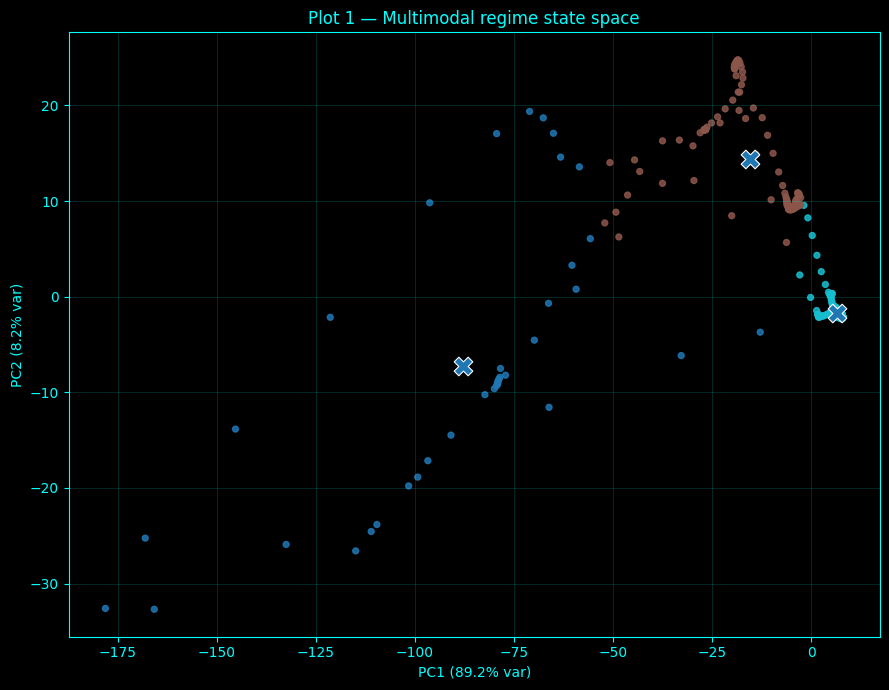

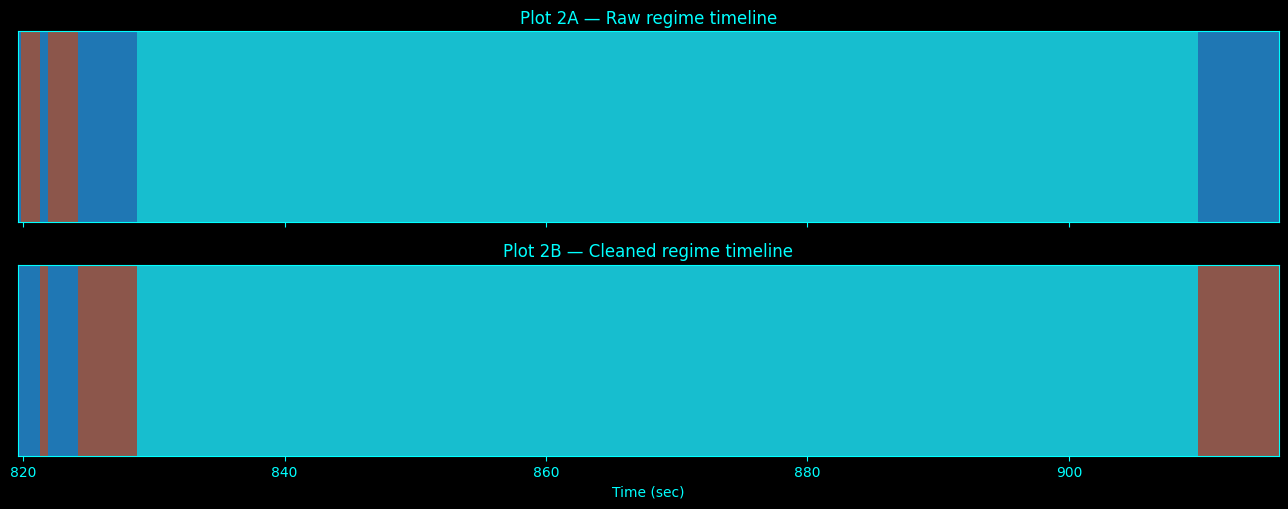

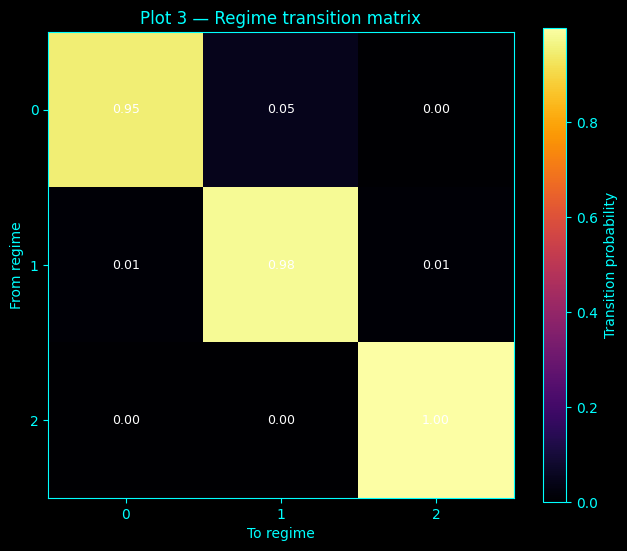

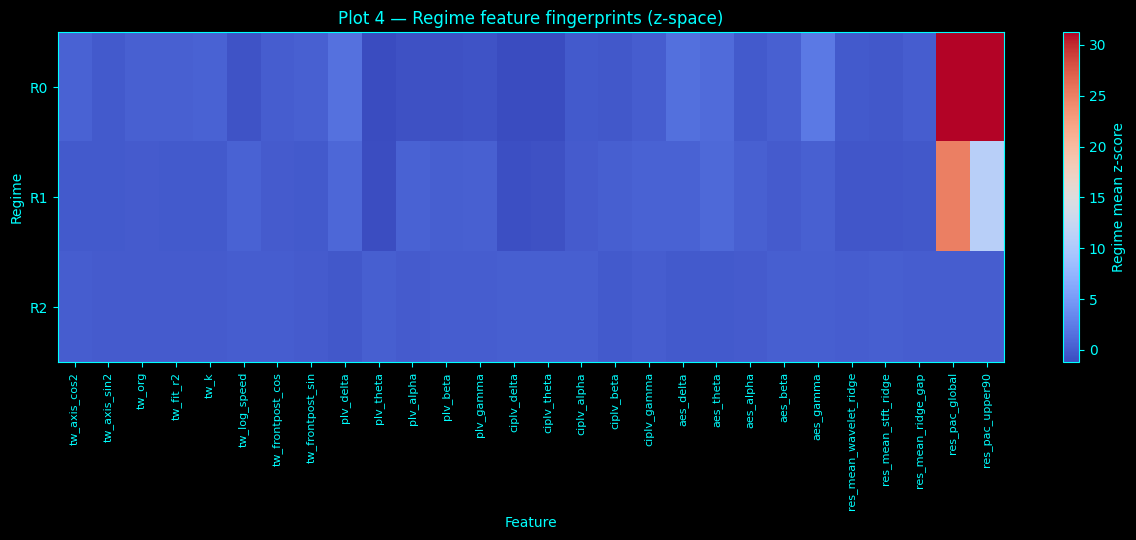

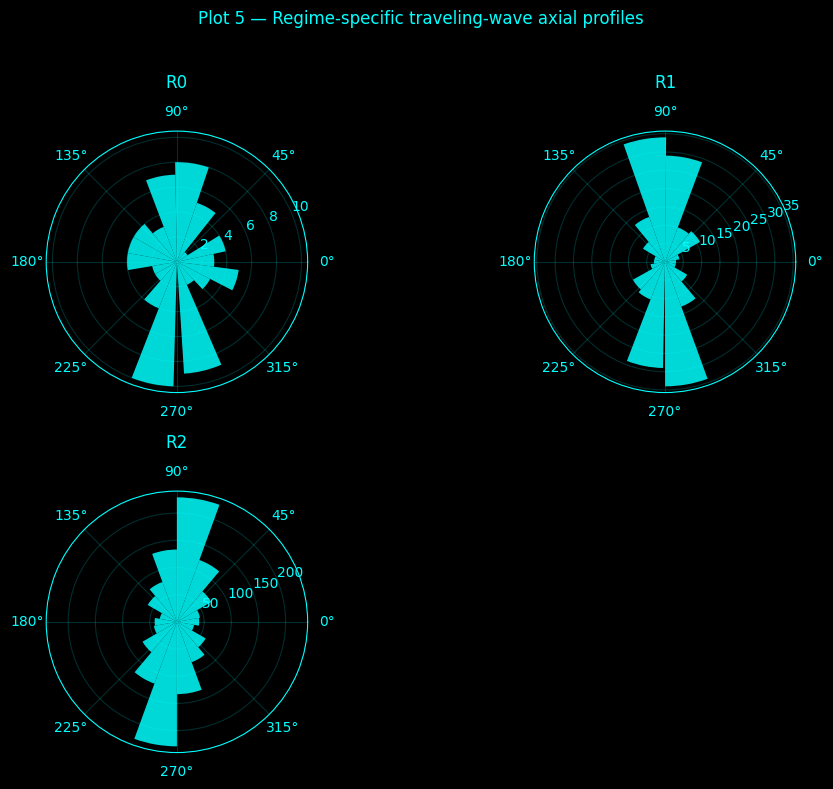

Saved plot 1: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_multimodal_regime_atlas/plots/plot1_pca_regime_state_space.png
Saved plot 2: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_multimodal_regime_atlas/plots/plot2_regime_timeline.png
Saved plot 3: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_multimodal_regime_atlas/plots/plot3_regime_transition_matrix.png
Saved plot 4: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_multimodal_regime_atlas/plots/plot4_regime_feature_fingerprints.png
Saved plot 5: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_multimodal_regime_atlas/plots/plot5_regime_axial_direction_profiles.png
Done.


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.vq import kmeans2

# -------------------------------------------------------
# CONFIG — FILE PATHS ONLY, NO NOTEBOOK MEMORY
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
results_dir = os.path.join(base_dir, "results")

out_dir = os.path.join(results_dir, "exploratory_multimodal_regime_atlas")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

# Candidate upstream outputs from earlier blocks
traveling_wave_csv_candidates = [
    os.path.join(results_dir, "exploratory_alpha_traveling_wave_atlas", "traveling_wave_trajectory.csv"),
    "/mnt/data/traveling_wave_trajectory.csv",
]

plv_dict_candidates = [
    os.path.join(results_dir, "exploratory_phase_locking_value_atlas", "plv_output_dict.npy"),
]

aes_dict_candidates = [
    os.path.join(results_dir, "exploratory_amplitude_envelope_synchrony", "aes_output_dict.npy"),
]

resonance_npz_candidates = [
    os.path.join(results_dir, "exploratory_resonance_cfc_wavelet_adaptive_stft_FIXED", "resonance_cfc_wavelet_adaptive_stft_outputs.npz"),
    os.path.join(results_dir, "exploratory_resonance_cfc_wavelet_adaptive_stft", "resonance_cfc_wavelet_adaptive_stft_outputs.npz"),
]

# Regime settings
candidate_k_values = [3, 4, 5, 6]
default_k_if_selection_fails = 4
min_regime_duration_sec = 0.50

# Data-quality / edge handling
min_feature_valid_fraction = 0.50
min_time_valid_fraction = 0.60
edge_trim_sec = 2.0

ACCENT = "cyan"
BG = "black"
eps = 1e-12

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
    "font.size": 10,
})

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
def style_ax(ax, heatmap=False):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)
    if heatmap:
        ax.grid(False)
    else:
        ax.grid(True, alpha=0.18, color=ACCENT, linewidth=0.6)

# -------------------------------------------------------
# IO HELPERS
# -------------------------------------------------------
def first_existing(paths):
    for p in paths:
        if os.path.exists(p):
            return p
    return None

def load_dict_npy(path):
    obj = np.load(path, allow_pickle=True)
    if isinstance(obj, np.ndarray) and obj.shape == ():
        return obj.item()
    try:
        return obj.item()
    except Exception:
        return obj

# -------------------------------------------------------
# NUMERIC HELPERS
# -------------------------------------------------------
def smooth_1d(x, win=7):
    x = np.asarray(x, dtype=float)
    if win <= 1 or len(x) < win:
        return x
    kernel = np.ones(win, dtype=float) / win
    return np.convolve(x, kernel, mode="same")

def percentile_limits(x, lo=2, hi=98):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return None, None
    return float(np.percentile(x, lo)), float(np.percentile(x, hi))

def circular_interp(times_old, values_old, times_new):
    times_old = np.asarray(times_old, dtype=float)
    values_old = np.asarray(values_old, dtype=float)
    times_new = np.asarray(times_new, dtype=float)

    mask = np.isfinite(times_old) & np.isfinite(values_old)
    if np.sum(mask) < 2:
        return np.full(len(times_new), np.nan)

    t = times_old[mask]
    v = values_old[mask]
    s = np.sin(v)
    c = np.cos(v)

    s_i = np.interp(times_new, t, s, left=np.nan, right=np.nan)
    c_i = np.interp(times_new, t, c, left=np.nan, right=np.nan)
    return np.arctan2(s_i, c_i)

def linear_interp(times_old, values_old, times_new):
    times_old = np.asarray(times_old, dtype=float)
    values_old = np.asarray(values_old, dtype=float)
    times_new = np.asarray(times_new, dtype=float)

    mask = np.isfinite(times_old) & np.isfinite(values_old)
    if np.sum(mask) < 2:
        return np.full(len(times_new), np.nan)

    return np.interp(times_new, times_old[mask], values_old[mask], left=np.nan, right=np.nan)

def robust_scale_matrix(X):
    X = np.asarray(X, dtype=float)
    med = np.nanmedian(X, axis=0)
    q25 = np.nanpercentile(X, 25, axis=0)
    q75 = np.nanpercentile(X, 75, axis=0)
    iqr = q75 - q25
    sd = np.nanstd(X, axis=0)
    scale = np.where(iqr > 1e-8, iqr, np.where(sd > 1e-8, sd, 1.0))
    Z = (X - med) / scale
    return Z, med, scale

def fill_missing_columns(X):
    X = np.asarray(X, dtype=float).copy()
    for j in range(X.shape[1]):
        col = X[:, j]
        mask = np.isfinite(col)
        if np.sum(mask) == 0:
            continue
        if np.sum(mask) == 1:
            X[:, j] = col[mask][0]
            continue
        idx = np.arange(len(col))
        X[:, j] = np.interp(idx, idx[mask], col[mask])
    return X

def pca_svd(X, n_components=5):
    X = np.asarray(X, dtype=float)
    Xc = X - np.mean(X, axis=0, keepdims=True)
    U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
    scores = U[:, :n_components] * S[:n_components]
    loadings = Vt[:n_components].T
    ev = (S ** 2) / max(X.shape[0] - 1, 1)
    evr = ev / (np.sum(ev) + eps)
    return scores, loadings, evr[:n_components]

def calinski_harabasz_score(X, labels):
    X = np.asarray(X, dtype=float)
    labels = np.asarray(labels)
    uniq = np.unique(labels)
    n = len(labels)
    k = len(uniq)

    if k < 2 or k >= n:
        return np.nan

    overall_mean = np.mean(X, axis=0)
    B = 0.0
    W = 0.0

    for lab in uniq:
        Xi = X[labels == lab]
        if len(Xi) == 0:
            continue
        mean_i = np.mean(Xi, axis=0)
        B += len(Xi) * np.sum((mean_i - overall_mean) ** 2)
        W += np.sum((Xi - mean_i) ** 2)

    if W <= 0:
        return np.nan

    return (B / max(k - 1, 1)) / (W / max(n - k, 1))

def relabel_by_first_appearance(labels):
    labels = np.asarray(labels, dtype=int)
    order = []
    for x in labels:
        if x not in order:
            order.append(x)
    mapping = {old: new for new, old in enumerate(order)}
    return np.array([mapping[x] for x in labels], dtype=int)

def merge_short_runs(labels, min_run_len):
    labels = np.asarray(labels, dtype=int).copy()
    changed = True

    while changed:
        changed = False
        n = len(labels)
        start = 0

        while start < n:
            end = start + 1
            while end < n and labels[end] == labels[start]:
                end += 1

            run_len = end - start
            if run_len < min_run_len:
                left_lab = labels[start - 1] if start > 0 else None
                right_lab = labels[end] if end < n else None

                if left_lab is not None and right_lab is not None:
                    replacement = left_lab if run_len <= 2 else right_lab
                elif left_lab is not None:
                    replacement = left_lab
                elif right_lab is not None:
                    replacement = right_lab
                else:
                    replacement = labels[start]

                labels[start:end] = replacement
                changed = True
                break

            start = end

    return labels

# -------------------------------------------------------
# FEATURE LOADING
# -------------------------------------------------------
feature_series = {}
feature_notes = []
common_time = None

# ---------------------------
# traveling-wave features
# ---------------------------
travel_csv_path = first_existing(traveling_wave_csv_candidates)
if travel_csv_path is not None:
    tw = pd.read_csv(travel_csv_path)
    common_time = tw["time_sec"].values.astype(float)

    # axial encoding for direction
    theta = np.radians(tw["wave_direction_deg"].values.astype(float))
    feature_series["tw_axis_cos2"] = np.cos(2.0 * theta)
    feature_series["tw_axis_sin2"] = np.sin(2.0 * theta)

    feature_series["tw_org"] = tw["organization_score_s"].values.astype(float)
    feature_series["tw_fit_r2"] = tw["fit_r2_s"].values.astype(float)
    feature_series["tw_k"] = tw["wavenumber_rad_per_unit_s"].values.astype(float)

    speed = tw["phase_velocity_units_per_sec_s"].values.astype(float)
    finite_speed = speed[np.isfinite(speed)]
    if len(finite_speed) > 0:
        speed_clip = np.nanpercentile(finite_speed, 95)
        speed = np.where(np.isfinite(speed), np.clip(speed, 0.0, speed_clip), np.nan)
    feature_series["tw_log_speed"] = np.log1p(speed)

    phase_diff = tw["front_minus_post_phase_diff_rad"].values.astype(float)
    feature_series["tw_frontpost_cos"] = np.cos(phase_diff)
    feature_series["tw_frontpost_sin"] = np.sin(phase_diff)

    feature_notes.append(f"Loaded traveling-wave trajectory: {travel_csv_path}")

# ---------------------------
# PLV features
# ---------------------------
plv_dict_path = first_existing(plv_dict_candidates)
if plv_dict_path is not None:
    plv_dict = load_dict_npy(plv_dict_path)
    t_old = np.asarray(plv_dict["dynamic_time_sec_abs"], dtype=float)

    dyn_plv = plv_dict.get("dynamic_global_plv_dict", {})
    dyn_ciplv = plv_dict.get("dynamic_global_ciplv_dict", {})

    if common_time is None:
        common_time = t_old.copy()

    for band_name, series in dyn_plv.items():
        feature_series[f"plv_{band_name}"] = linear_interp(t_old, np.asarray(series, dtype=float), common_time)

    for band_name, series in dyn_ciplv.items():
        feature_series[f"ciplv_{band_name}"] = linear_interp(t_old, np.asarray(series, dtype=float), common_time)

    feature_notes.append(f"Loaded PLV dict: {plv_dict_path}")

# ---------------------------
# AES features
# ---------------------------
aes_dict_path = first_existing(aes_dict_candidates)
if aes_dict_path is not None:
    aes_dict = load_dict_npy(aes_dict_path)
    t_old = np.asarray(aes_dict["dynamic_time_sec_abs"], dtype=float)
    dyn_aes = aes_dict.get("dynamic_global_dict", {})

    if common_time is None:
        common_time = t_old.copy()

    for band_name, series in dyn_aes.items():
        feature_series[f"aes_{band_name}"] = linear_interp(t_old, np.asarray(series, dtype=float), common_time)

    feature_notes.append(f"Loaded AES dict: {aes_dict_path}")

# ---------------------------
# resonance / PAC features
# ---------------------------
res_npz_path = first_existing(resonance_npz_candidates)
if res_npz_path is not None:
    R = np.load(res_npz_path, allow_pickle=True)
    t_old = np.asarray(R["common_time_sec_abs"], dtype=float)

    wavelet_ridge = np.asarray(R["wavelet_ridge_hz"], dtype=float)   # time x ch
    stft_ridge = np.asarray(R["stft_ridge_hz"], dtype=float)         # time x ch
    dynamic_pac = np.asarray(R["dynamic_pac_matrix"], dtype=float)   # time x ch

    if common_time is None:
        common_time = t_old.copy()

    mean_wavelet = np.nanmean(wavelet_ridge, axis=1)
    mean_stft = np.nanmean(stft_ridge, axis=1)
    ridge_gap = np.nanmean(np.abs(wavelet_ridge - stft_ridge), axis=1)
    pac_global = np.nanmean(dynamic_pac, axis=1)
    pac_upper = np.nanpercentile(dynamic_pac, 90, axis=1)

    feature_series["res_mean_wavelet_ridge"] = linear_interp(t_old, mean_wavelet, common_time)
    feature_series["res_mean_stft_ridge"] = linear_interp(t_old, mean_stft, common_time)
    feature_series["res_mean_ridge_gap"] = linear_interp(t_old, ridge_gap, common_time)
    feature_series["res_pac_global"] = linear_interp(t_old, pac_global, common_time)
    feature_series["res_pac_upper90"] = linear_interp(t_old, pac_upper, common_time)

    feature_notes.append(f"Loaded resonance NPZ: {res_npz_path}")

if common_time is None or len(feature_series) == 0:
    raise FileNotFoundError(
        "No upstream feature files found. Run the traveling-wave block first, "
        "and optionally the PLV/AES/resonance blocks."
    )

# -------------------------------------------------------
# BUILD FEATURE TABLE
# -------------------------------------------------------
feature_df = pd.DataFrame({"time_sec": common_time})
for name, series in feature_series.items():
    feature_df[name] = np.asarray(series, dtype=float)

feature_cols = [c for c in feature_df.columns if c != "time_sec"]

# feature validity filter
valid_frac_by_feature = feature_df[feature_cols].notna().mean(axis=0)
feature_cols = [c for c in feature_cols if valid_frac_by_feature[c] >= min_feature_valid_fraction]
feature_df = feature_df[["time_sec"] + feature_cols].copy()

# time validity filter
valid_frac_by_time = feature_df[feature_cols].notna().mean(axis=1)
keep_time_mask = valid_frac_by_time >= min_time_valid_fraction
feature_df = feature_df.loc[keep_time_mask].reset_index(drop=True)

# trim edges to suppress interpolation / boundary artifacts
tmin = feature_df["time_sec"].min()
tmax = feature_df["time_sec"].max()
edge_keep = (
    (feature_df["time_sec"] >= tmin + edge_trim_sec) &
    (feature_df["time_sec"] <= tmax - edge_trim_sec)
)
feature_df = feature_df.loc[edge_keep].reset_index(drop=True)

common_time = feature_df["time_sec"].values.astype(float)
X_raw = feature_df[feature_cols].values.astype(float)

if X_raw.shape[0] < 20 or X_raw.shape[1] < 2:
    raise ValueError("Not enough valid multimodal data left after filtering to build a regime atlas.")

# fill missing
X_filled = fill_missing_columns(X_raw)

# light temporal smoothing before clustering
for j in range(X_filled.shape[1]):
    X_filled[:, j] = smooth_1d(X_filled[:, j], win=5)

# robust scaling
X_scaled, feat_med, feat_scale = robust_scale_matrix(X_filled)

# PCA
n_components = min(5, X_scaled.shape[1], X_scaled.shape[0])
scores, loadings, evr = pca_svd(X_scaled, n_components=n_components)

# -------------------------------------------------------
# REGIME SELECTION
# -------------------------------------------------------
best_k = None
best_labels = None
best_score = -np.inf

pc_use = min(4, n_components)
X_cluster = scores[:, :pc_use]

for k in candidate_k_values:
    if k >= len(X_cluster):
        continue
    try:
        centroids, labels = kmeans2(X_cluster, k, minit="points", iter=60)
        ch = calinski_harabasz_score(X_cluster, labels)
        if np.isfinite(ch) and ch > best_score:
            best_score = ch
            best_k = k
            best_labels = labels.copy()
    except Exception:
        pass

if best_labels is None:
    _, labels = kmeans2(X_cluster, default_k_if_selection_fails, minit="points", iter=60)
    best_k = default_k_if_selection_fails
    best_labels = labels.copy()

# preserve raw labels
labels_raw = relabel_by_first_appearance(best_labels)

# gentle cleanup
dt = np.nanmedian(np.diff(common_time))
if not np.isfinite(dt) or dt <= 0:
    dt = 0.10

min_run_len = max(int(round(min_regime_duration_sec / dt)), 1)
labels_clean = merge_short_runs(labels_raw, min_run_len=min_run_len)
labels_clean = relabel_by_first_appearance(labels_clean)

n_regimes = len(np.unique(labels_clean))

# -------------------------------------------------------
# REGIME SUMMARIES
# -------------------------------------------------------
regime_summary_rows = []
for r in range(n_regimes):
    mask = labels_clean == r
    row = {
        "regime": r,
        "n_windows": int(np.sum(mask)),
        "fraction_of_time": float(np.mean(mask)),
        "start_time_sec": float(common_time[np.where(mask)[0][0]]) if np.any(mask) else np.nan,
    }
    for j, feat in enumerate(feature_cols):
        row[f"{feat}_mean"] = float(np.mean(X_filled[mask, j]))
        row[f"{feat}_zmean"] = float(np.mean(X_scaled[mask, j]))
    regime_summary_rows.append(row)

regime_summary_df = pd.DataFrame(regime_summary_rows)

# transition matrix
T = np.zeros((n_regimes, n_regimes), dtype=int)
for a, b in zip(labels_clean[:-1], labels_clean[1:]):
    T[a, b] += 1

T_prob = T.astype(float)
row_sums = T_prob.sum(axis=1, keepdims=True)
T_prob = np.divide(T_prob, np.maximum(row_sums, 1), where=row_sums > 0)

# dwell table
dwell_rows = []
start = 0
for i in range(1, len(labels_clean) + 1):
    if i == len(labels_clean) or labels_clean[i] != labels_clean[start]:
        regime = labels_clean[start]
        t0 = common_time[start]
        t1 = common_time[i - 1]
        dwell_rows.append({
            "regime": int(regime),
            "start_time_sec": float(t0),
            "end_time_sec": float(t1),
            "duration_sec": float(max(t1 - t0 + dt, dt)),
        })
        start = i

dwell_df = pd.DataFrame(dwell_rows)

fingerprint = np.vstack([
    regime_summary_df[[f"{feat}_zmean" for feat in feature_cols]].iloc[r].values
    for r in range(n_regimes)
])

# -------------------------------------------------------
# SAVE OUTPUTS
# -------------------------------------------------------
summary_csv_path = os.path.join(out_dir, "multimodal_regime_summary.csv")
dwell_csv_path = os.path.join(out_dir, "multimodal_regime_dwells.csv")
feature_csv_path = os.path.join(out_dir, "multimodal_regime_features_used.csv")
trajectory_csv_path = os.path.join(out_dir, "multimodal_regime_trajectory.csv")
npz_path = os.path.join(out_dir, "multimodal_regime_outputs.npz")
notes_txt_path = os.path.join(out_dir, "multimodal_regime_notes.txt")

plot1_path = os.path.join(plots_dir, "plot1_pca_regime_state_space.png")
plot2_path = os.path.join(plots_dir, "plot2_regime_timeline.png")
plot3_path = os.path.join(plots_dir, "plot3_regime_transition_matrix.png")
plot4_path = os.path.join(plots_dir, "plot4_regime_feature_fingerprints.png")
plot5_path = os.path.join(plots_dir, "plot5_regime_axial_direction_profiles.png")

feature_used_df = pd.DataFrame({
    "feature": feature_cols,
    "median": feat_med[:len(feature_cols)],
    "scale": feat_scale[:len(feature_cols)],
    "pc1_loading": loadings[:, 0] if n_components >= 1 else np.nan,
    "pc2_loading": loadings[:, 1] if n_components >= 2 else np.nan,
})

trajectory_df = pd.DataFrame({
    "time_sec": common_time,
    "regime_raw": labels_raw,
    "regime_clean": labels_clean,
    **{f"PC{i+1}": scores[:, i] for i in range(n_components)}
})

regime_summary_df.to_csv(summary_csv_path, index=False)
dwell_df.to_csv(dwell_csv_path, index=False)
feature_used_df.to_csv(feature_csv_path, index=False)
trajectory_df.to_csv(trajectory_csv_path, index=False)

np.savez_compressed(
    npz_path,
    time_sec=common_time,
    labels_raw=labels_raw,
    labels_clean=labels_clean,
    scores=scores,
    evr=evr,
    transition_counts=T,
    transition_prob=T_prob,
    feature_names=np.array(feature_cols, dtype=object),
    fingerprint=fingerprint,
)

with open(notes_txt_path, "w") as f:
    f.write("Exploratory multimodal regime atlas\n")
    f.write("==================================\n\n")
    f.write("This atlas fuses whichever upstream outputs are available from prior analyses:\n")
    f.write("- traveling-wave features\n")
    f.write("- PLV / ciPLV dynamics\n")
    f.write("- AES dynamics\n")
    f.write("- resonance / PAC dynamics\n\n")
    f.write("Important diagnostics:\n")
    f.write("- traveling-wave direction is encoded axially as cos(2θ), sin(2θ)\n")
    f.write("- edge windows are trimmed to reduce interpolation artifacts\n")
    f.write("- both raw and cleaned regime timelines are saved\n\n")
    f.write("Loaded sources:\n")
    for note in feature_notes:
        f.write(f"  - {note}\n")
    f.write("\n")
    f.write(f"Features used: {len(feature_cols)}\n")
    f.write(f"Selected number of regimes: {n_regimes}\n")
    f.write(f"Selection score (Calinski-Harabasz): {best_score}\n")
    f.write(f"PCA explained variance ratios: {evr.tolist()}\n")

print("Loaded feature sources:")
for note in feature_notes:
    print(" ", note)

print(f"Features used: {len(feature_cols)}")
print(f"Selected number of regimes: {n_regimes}")

print("Raw regime counts:")
for r in np.unique(labels_raw):
    print(f"  R{r}: {np.sum(labels_raw == r)} windows ({100*np.mean(labels_raw == r):.1f}%)")

print("Cleaned regime counts:")
for r in np.unique(labels_clean):
    print(f"  R{r}: {np.sum(labels_clean == r)} windows ({100*np.mean(labels_clean == r):.1f}%)")

print(f"Saved summary CSV: {summary_csv_path}")
print(f"Saved dwell CSV: {dwell_csv_path}")
print(f"Saved feature CSV: {feature_csv_path}")
print(f"Saved trajectory CSV: {trajectory_csv_path}")
print(f"Saved NPZ: {npz_path}")
print(f"Saved notes TXT: {notes_txt_path}")

# -------------------------------------------------------
# PLOT 1 — PCA STATE SPACE
# -------------------------------------------------------
fig1, ax1 = plt.subplots(figsize=(9, 7), facecolor=BG)
style_ax(ax1)

if n_components >= 2:
    ax1.scatter(
        scores[:, 0],
        scores[:, 1],
        c=labels_clean,
        cmap="tab10",
        s=18,
        alpha=0.85,
    )

    for r in range(n_regimes):
        m = labels_clean == r
        ax1.scatter(
            np.mean(scores[m, 0]),
            np.mean(scores[m, 1]),
            s=180,
            marker="X",
            c=[r],
            cmap="tab10",
            edgecolors="white",
            linewidths=0.8,
        )

    ax1.set_xlabel(f"PC1 ({100 * evr[0]:.1f}% var)")
    ax1.set_ylabel(f"PC2 ({100 * evr[1]:.1f}% var)")
    ax1.set_title("Plot 1 — Multimodal regime state space")
else:
    ax1.scatter(np.arange(len(scores)), scores[:, 0], c=labels_clean, cmap="tab10", s=18, alpha=0.85)
    ax1.set_xlabel("Window index")
    ax1.set_ylabel("PC1")
    ax1.set_title("Plot 1 — Multimodal regime state axis")

fig1.tight_layout()
fig1.savefig(plot1_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig1)

# -------------------------------------------------------
# PLOT 2 — REGIME TIMELINE (RAW + CLEANED)
# -------------------------------------------------------
fig2, axes2 = plt.subplots(2, 1, figsize=(13, 5.2), facecolor=BG, sharex=True)
axes2 = np.atleast_1d(axes2)

for ax in axes2:
    style_ax(ax, heatmap=True)

raw_img = labels_raw[np.newaxis, :]
clean_img = labels_clean[np.newaxis, :]

axes2[0].imshow(
    raw_img,
    aspect="auto",
    interpolation="nearest",
    cmap="tab10",
    extent=[common_time[0], common_time[-1], 0, 1],
)
axes2[0].set_title("Plot 2A — Raw regime timeline")
axes2[0].set_yticks([])

axes2[1].imshow(
    clean_img,
    aspect="auto",
    interpolation="nearest",
    cmap="tab10",
    extent=[common_time[0], common_time[-1], 0, 1],
)
axes2[1].set_title("Plot 2B — Cleaned regime timeline")
axes2[1].set_xlabel("Time (sec)")
axes2[1].set_yticks([])

fig2.tight_layout()
fig2.savefig(plot2_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig2)

# -------------------------------------------------------
# PLOT 3 — TRANSITION MATRIX
# -------------------------------------------------------
fig3, ax3 = plt.subplots(figsize=(6.5, 5.5), facecolor=BG)
style_ax(ax3, heatmap=True)

im3 = ax3.imshow(T_prob, cmap="inferno", interpolation="nearest", aspect="equal")
ax3.set_title("Plot 3 — Regime transition matrix")
ax3.set_xlabel("To regime")
ax3.set_ylabel("From regime")
ax3.set_xticks(np.arange(n_regimes))
ax3.set_yticks(np.arange(n_regimes))

for i in range(n_regimes):
    for j in range(n_regimes):
        ax3.text(j, i, f"{T_prob[i, j]:.2f}", ha="center", va="center", color="white", fontsize=9)

cbar3 = plt.colorbar(im3, ax=ax3)
cbar3.set_label("Transition probability", color=ACCENT)
cbar3.outline.set_edgecolor(ACCENT)
cbar3.ax.tick_params(color=ACCENT)
for label in cbar3.ax.get_yticklabels():
    label.set_color(ACCENT)

fig3.tight_layout()
fig3.savefig(plot3_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig3)

# -------------------------------------------------------
# PLOT 4 — FEATURE FINGERPRINTS
# -------------------------------------------------------
fig4, ax4 = plt.subplots(figsize=(max(10, 0.45 * len(feature_cols)), 5.5), facecolor=BG)
style_ax(ax4, heatmap=True)

vmin4, vmax4 = percentile_limits(fingerprint, lo=2, hi=98)
if vmin4 is None or vmax4 is None:
    vmin4, vmax4 = -2.0, 2.0

im4 = ax4.imshow(
    fingerprint,
    cmap="coolwarm",
    interpolation="nearest",
    aspect="auto",
    vmin=vmin4,
    vmax=vmax4,
)

ax4.set_title("Plot 4 — Regime feature fingerprints (z-space)")
ax4.set_xlabel("Feature")
ax4.set_ylabel("Regime")
ax4.set_xticks(np.arange(len(feature_cols)))
ax4.set_xticklabels(feature_cols, rotation=90, fontsize=8)
ax4.set_yticks(np.arange(n_regimes))
ax4.set_yticklabels([f"R{r}" for r in range(n_regimes)])

cbar4 = plt.colorbar(im4, ax=ax4)
cbar4.set_label("Regime mean z-score", color=ACCENT)
cbar4.outline.set_edgecolor(ACCENT)
cbar4.ax.tick_params(color=ACCENT)
for label in cbar4.ax.get_yticklabels():
    label.set_color(ACCENT)

fig4.tight_layout()
fig4.savefig(plot4_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig4)

# -------------------------------------------------------
# PLOT 5 — REGIME AXIAL DIRECTION PROFILES
# -------------------------------------------------------
fig5 = plt.figure(figsize=(10, 8), facecolor=BG)

has_axial = ("tw_axis_cos2" in feature_df.columns) and ("tw_axis_sin2" in feature_df.columns)

if has_axial:
    n_cols = 2
    n_rows = int(np.ceil(n_regimes / n_cols))

    tw_cos = feature_df["tw_axis_cos2"].values
    tw_sin = feature_df["tw_axis_sin2"].values

    for r in range(n_regimes):
        ax = fig5.add_subplot(n_rows, n_cols, r + 1, projection="polar")
        ax.set_facecolor(BG)

        m = labels_clean == r
        ang_axial = 0.5 * np.arctan2(tw_sin[m], tw_cos[m])
        ang_axial = ang_axial[np.isfinite(ang_axial)]

        if len(ang_axial) > 0:
            theta = np.concatenate([ang_axial, ang_axial + np.pi])
            ax.hist(theta, bins=18, color=ACCENT, alpha=0.85)

        ax.set_title(f"R{r}", color=ACCENT, pad=12)
        ax.tick_params(colors=ACCENT)
        ax.grid(True, alpha=0.18, color=ACCENT)

    fig5.suptitle("Plot 5 — Regime-specific traveling-wave axial profiles", color=ACCENT, y=0.98)
else:
    ax = fig5.add_subplot(111)
    style_ax(ax)
    ax.text(0.5, 0.5, "Traveling-wave axial features not available", ha="center", va="center", fontsize=12, color="white")
    ax.set_xticks([])
    ax.set_yticks([])

fig5.tight_layout(rect=[0, 0, 1, 0.96])
fig5.savefig(plot5_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig5)

print(f"Saved plot 1: {plot1_path}")
print(f"Saved plot 2: {plot2_path}")
print(f"Saved plot 3: {plot3_path}")
print(f"Saved plot 4: {plot4_path}")
print(f"Saved plot 5: {plot5_path}")
print("Done.")

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Phase-locking value</h3><p>PLV measures concentration of instantaneous phase differences across samples, trials, or windows. It is insensitive to amplitude and equals one only when the phase difference is constant over the averaging ensemble.</p><p><b>Cell role.</b> This code applies that theory to the notebook's existing EEG-derived data and preserves the surrounding notebook's plotting/output conventions. Numerical shortcuts selected by a speed mode change sampling density, iteration counts, or visualization resolution; they do not change the defining formula above.</p></div>

$$\\operatorname{PLV}=\\left|\\frac1N\\sum_{n=1}^{N}e^{i(\\phi_x[n]-\\phi_y[n])}\\right|.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Phase-locking value measures how consistent the phase difference between two signals is across samples, trials, or windows. Each phase difference is converted to a unit complex number on the circle and these vectors are averaged. If phase differences are almost identical, the vectors point in the same direction and the average magnitude approaches one. If phase differences are widely spread, they cancel and the magnitude approaches zero. PLV ignores amplitude and does not establish causal influence.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. An exponential describes multiplicative growth or decay. In dynamical systems, a positive exponent corresponds to growth with time and a negative exponent to decay. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


/tmp/ipykernel_11984/2617836061.py:659: RuntimeWarning: Mean of empty slice
  mean_plv_alpha = float(np.nanmean(linear_interp(plv_time, plv_alpha, burst_time))) if plv_time is not None else np.nan
/tmp/ipykernel_11984/2617836061.py:660: RuntimeWarning: Mean of empty slice
  mean_ciplv_alpha = float(np.nanmean(linear_interp(plv_time, ciplv_alpha, burst_time))) if plv_time is not None else np.nan
/tmp/ipykernel_11984/2617836061.py:661: RuntimeWarning: Mean of empty slice
  mean_aes_alpha = float(np.nanmean(linear_interp(aes_time, aes_alpha, burst_time))) if aes_time is not None else np.nan


Posterior alpha peak: 10.803 Hz
Individualized alpha band: [9.303, 12.303] Hz
Bursts found: 24
Selected archetypes: 2
Minimum bursts per archetype: 3
  Archetype 0: 13 bursts
  Archetype 1: 11 bursts
Saved burst CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_alpha_burst_multimodal_atlas/alpha_burst_summary.csv
Saved descriptor CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_alpha_burst_multimodal_atlas/alpha_burst_descriptors_used.csv
Saved locked NPZ: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_alpha_burst_multimodal_atlas/alpha_burst_locked_trajectories.npz
Saved notes TXT: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_alpha_burst_multimodal_atlas/alpha_burst_notes.txt


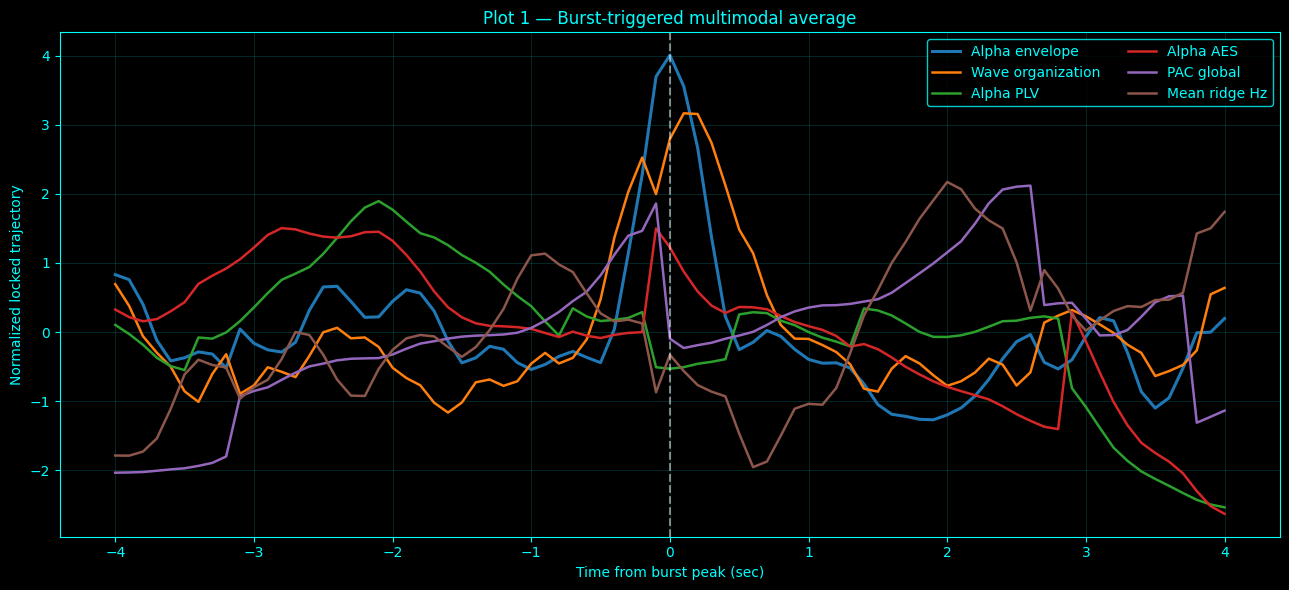

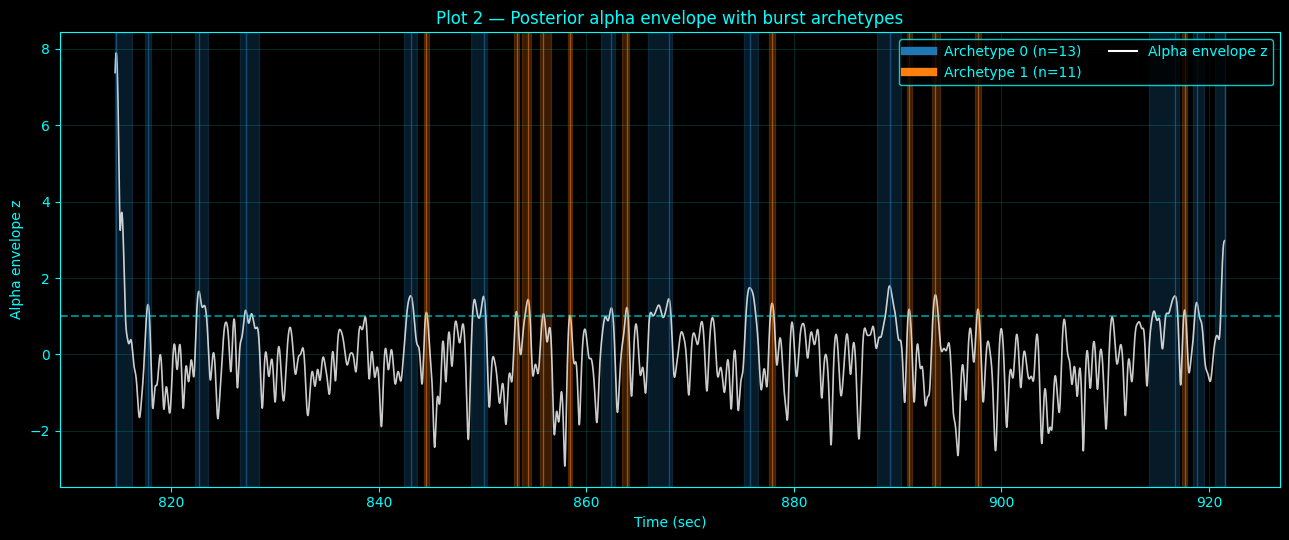

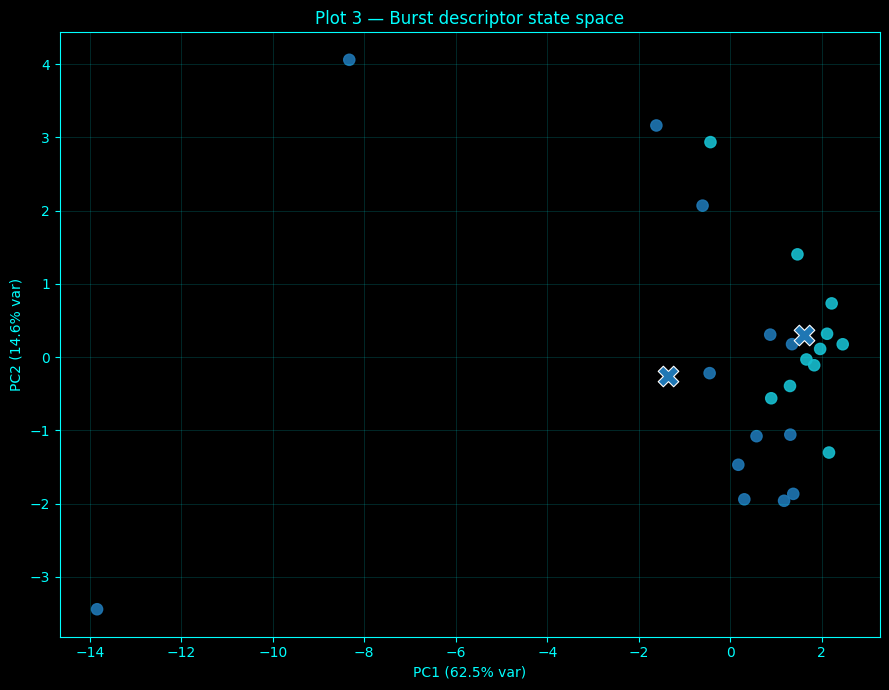

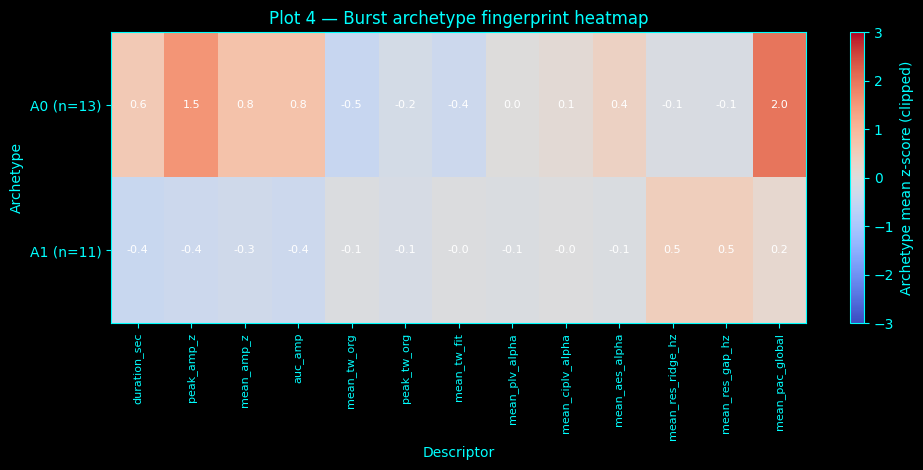

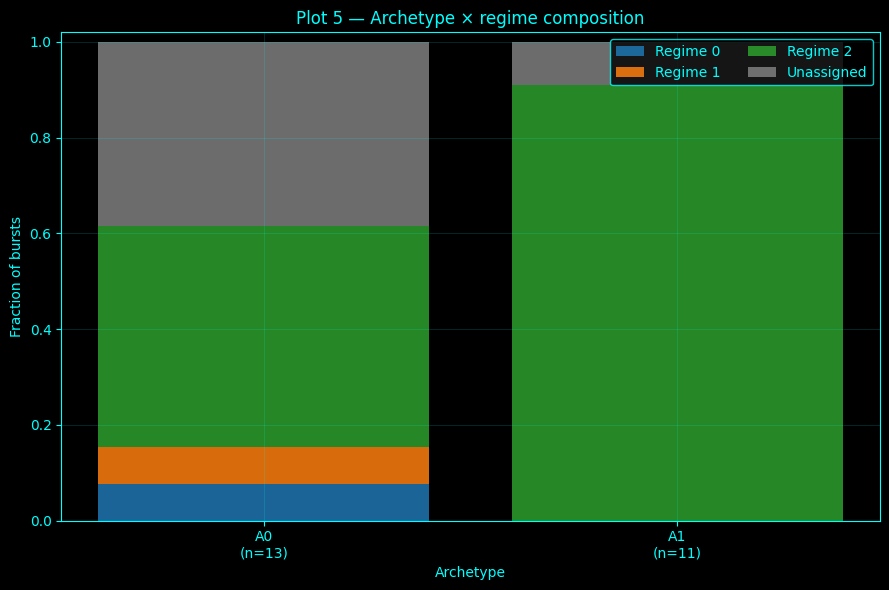

Saved plot 1: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_alpha_burst_multimodal_atlas/plots/plot1_burst_triggered_multimodal_average.png
Saved plot 2: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_alpha_burst_multimodal_atlas/plots/plot2_alpha_envelope_with_burst_archetypes.png
Saved plot 3: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_alpha_burst_multimodal_atlas/plots/plot3_burst_descriptor_state_space.png
Saved plot 4: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_alpha_burst_multimodal_atlas/plots/plot4_archetype_fingerprint_heatmap.png
Saved plot 5: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_alpha_burst_multimodal_atlas/plots/plot5_archetype_regime_composition.png
Done.


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from scipy.cluster.vq import kmeans2

# -------------------------------------------------------
# CONFIG — FILE PATHS ONLY, NO NOTEBOOK MEMORY
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")
results_dir = os.path.join(base_dir, "results")

out_dir = os.path.join(results_dir, "exploratory_alpha_burst_multimodal_atlas")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

# Candidate upstream outputs
traveling_wave_csv_candidates = [
    os.path.join(results_dir, "exploratory_alpha_traveling_wave_atlas", "traveling_wave_trajectory.csv"),
    "/mnt/data/traveling_wave_trajectory.csv",
]

plv_dict_candidates = [
    os.path.join(results_dir, "exploratory_phase_locking_value_atlas", "plv_output_dict.npy"),
]

aes_dict_candidates = [
    os.path.join(results_dir, "exploratory_amplitude_envelope_synchrony", "aes_output_dict.npy"),
]

resonance_npz_candidates = [
    os.path.join(results_dir, "exploratory_resonance_cfc_wavelet_adaptive_stft_FIXED", "resonance_cfc_wavelet_adaptive_stft_outputs.npz"),
    os.path.join(results_dir, "exploratory_resonance_cfc_wavelet_adaptive_stft", "resonance_cfc_wavelet_adaptive_stft_outputs.npz"),
]

regime_traj_candidates = [
    os.path.join(results_dir, "exploratory_multimodal_regime_atlas", "multimodal_regime_trajectory.csv"),
]

# Segment config
sampling_rate = 1000
start_time, end_time = 814.571, 921.515
start_index, end_index = int(start_time * sampling_rate), int(end_time * sampling_rate)

apply_common_average_reference = False
detrend_mode = "constant"
zscore_each_channel = False

analysis_downsample_factor = 4
fs_analysis = sampling_rate / analysis_downsample_factor  # 250 Hz

# Alpha burst settings
alpha_search_band = (7.0, 13.0)
alpha_halfwidth_hz = 1.5
posterior_alpha_channels = ["P3", "Pz", "P4", "POz", "O1", "Oz", "O2"]

# Burst detection on posterior consensus alpha envelope
burst_high_z = 1.0
burst_low_z = 0.25
min_burst_duration_sec = 0.20
merge_gap_sec = 0.15

# Event-locking window around burst peak
lock_window_sec = (-4.0, 4.0)
lock_step_sec = 0.10

# Archetype clustering
candidate_k_values = [2, 3, 4, 5]
default_k_if_selection_fails = 3
fingerprint_clip_z = 3.0

# Plotting / style
ACCENT = "cyan"
BG = "black"
eps = 1e-12

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
    "font.size": 10,
})

eeg_channel_names = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
def style_ax(ax, heatmap=False):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)
    if heatmap:
        ax.grid(False)
    else:
        ax.grid(True, alpha=0.18, color=ACCENT, linewidth=0.6)

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def first_existing(paths):
    for p in paths:
        if os.path.exists(p):
            return p
    return None

def load_dict_npy(path):
    obj = np.load(path, allow_pickle=True)
    if isinstance(obj, np.ndarray) and obj.shape == ():
        return obj.item()
    try:
        return obj.item()
    except Exception:
        return obj

def ensure_time_channel_layout(x, n_channels_expected):
    x = np.asarray(x, dtype=float)
    if x.ndim != 2:
        raise ValueError(f"Expected 2D EEG array, got shape {x.shape}")
    if x.shape[1] == n_channels_expected:
        return x
    if x.shape[0] == n_channels_expected:
        return x.T
    raise ValueError(f"Unexpected EEG shape {x.shape}; cannot identify channel axis.")

def maybe_common_average_reference(x, enabled=False):
    if not enabled:
        return x
    return x - np.mean(x, axis=1, keepdims=True)

def preprocess_channel(y, detrend_mode="constant", zscore=False):
    y = np.asarray(y, dtype=float)
    if detrend_mode is not None:
        y = signal.detrend(y, type=detrend_mode)
    if zscore:
        sd = np.std(y)
        y = (y - np.mean(y)) / (sd + eps)
    return y

def smooth_1d(x, win=7):
    x = np.asarray(x, dtype=float)
    if win <= 1 or len(x) < win:
        return x
    kernel = np.ones(win, dtype=float) / win
    return np.convolve(x, kernel, mode="same")

def percentile_limits(x, lo=2, hi=98):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return None, None
    return float(np.percentile(x, lo)), float(np.percentile(x, hi))

def bandpass_sos(lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = max(lowcut / nyq, 1e-6)
    high = min(highcut / nyq, 0.999)
    if not (low < high):
        raise ValueError(f"Invalid band {lowcut}-{highcut} Hz for fs={fs}")
    return signal.butter(order, [low, high], btype="bandpass", output="sos")

def lowpass_sos(cutoff_hz, fs, order=4):
    nyq = 0.5 * fs
    cutoff = min(cutoff_hz / nyq, 0.999)
    return signal.butter(order, cutoff, btype="lowpass", output="sos")

def compute_welch_psd(y, fs, window_sec=4.0, overlap=0.5, nfft=8192):
    nperseg = min(int(round(window_sec * fs)), len(y))
    nperseg = max(nperseg, min(256, len(y)))
    noverlap = min(int(round(overlap * nperseg)), nperseg - 1)
    f, pxx = signal.welch(
        y, fs=fs, window="hann", nperseg=nperseg, noverlap=noverlap,
        detrend="constant", scaling="density", nfft=nfft
    )
    return f, pxx

def robust_alpha_peak(freqs_hz, psd_1d, band=(7.0, 13.0)):
    mask = (freqs_hz >= band[0]) & (freqs_hz <= band[1]) & np.isfinite(psd_1d)
    if np.sum(mask) < 5:
        return np.nan
    f = freqs_hz[mask]
    y = psd_1d[mask]
    idx = int(np.nanargmax(y))
    return float(f[idx])

def linear_interp(times_old, values_old, times_new):
    times_old = np.asarray(times_old, dtype=float)
    values_old = np.asarray(values_old, dtype=float)
    times_new = np.asarray(times_new, dtype=float)
    mask = np.isfinite(times_old) & np.isfinite(values_old)
    if np.sum(mask) < 2:
        return np.full(len(times_new), np.nan)
    return np.interp(times_new, times_old[mask], values_old[mask], left=np.nan, right=np.nan)

def nearest_categorical_lookup(times_ref, values_ref, times_query, max_gap_sec=None):
    times_ref = np.asarray(times_ref, dtype=float)
    values_ref = np.asarray(values_ref)
    times_query = np.asarray(times_query, dtype=float)

    if len(times_ref) == 0:
        return np.full(len(times_query), np.nan)

    idx = np.searchsorted(times_ref, times_query, side="left")
    idx = np.clip(idx, 0, len(times_ref) - 1)

    left_idx = np.clip(idx - 1, 0, len(times_ref) - 1)
    right_idx = idx

    left_dist = np.abs(times_query - times_ref[left_idx])
    right_dist = np.abs(times_query - times_ref[right_idx])

    choose_left = left_dist <= right_dist
    nearest_idx = np.where(choose_left, left_idx, right_idx)

    out = values_ref[nearest_idx].astype(float)

    if max_gap_sec is not None:
        nearest_dist = np.minimum(left_dist, right_dist)
        out = np.where(nearest_dist <= max_gap_sec, out, np.nan)

    return out

def robust_scale_matrix(X):
    X = np.asarray(X, dtype=float)
    med = np.nanmedian(X, axis=0)
    q25 = np.nanpercentile(X, 25, axis=0)
    q75 = np.nanpercentile(X, 75, axis=0)
    iqr = q75 - q25
    sd = np.nanstd(X, axis=0)
    scale = np.where(iqr > 1e-8, iqr, np.where(sd > 1e-8, sd, 1.0))
    Z = (X - med) / scale
    return Z, med, scale

def fill_missing_columns(X):
    X = np.asarray(X, dtype=float).copy()
    for j in range(X.shape[1]):
        col = X[:, j]
        mask = np.isfinite(col)
        if np.sum(mask) == 0:
            continue
        if np.sum(mask) == 1:
            X[:, j] = col[mask][0]
            continue
        idx = np.arange(len(col))
        X[:, j] = np.interp(idx, idx[mask], col[mask])
    return X

def winsorize_columns(X, low=2, high=98):
    X = np.asarray(X, dtype=float).copy()
    for j in range(X.shape[1]):
        col = X[:, j]
        finite = np.isfinite(col)
        if np.sum(finite) < 3:
            continue
        lo = np.percentile(col[finite], low)
        hi = np.percentile(col[finite], high)
        X[finite, j] = np.clip(col[finite], lo, hi)
    return X

def pca_svd(X, n_components=5):
    X = np.asarray(X, dtype=float)
    Xc = X - np.mean(X, axis=0, keepdims=True)
    U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
    scores = U[:, :n_components] * S[:n_components]
    loadings = Vt[:n_components].T
    ev = (S ** 2) / max(X.shape[0] - 1, 1)
    evr = ev / (np.sum(ev) + eps)
    return scores, loadings, evr[:n_components]

def calinski_harabasz_score(X, labels):
    X = np.asarray(X, dtype=float)
    labels = np.asarray(labels)
    uniq = np.unique(labels)
    n = len(labels)
    k = len(uniq)
    if k < 2 or k >= n:
        return np.nan

    overall_mean = np.mean(X, axis=0)
    B = 0.0
    W = 0.0
    for lab in uniq:
        Xi = X[labels == lab]
        if len(Xi) == 0:
            continue
        mean_i = np.mean(Xi, axis=0)
        B += len(Xi) * np.sum((mean_i - overall_mean) ** 2)
        W += np.sum((Xi - mean_i) ** 2)

    if W <= 0:
        return np.nan
    return (B / max(k - 1, 1)) / (W / max(n - k, 1))

def relabel_by_first_appearance(labels):
    labels = np.asarray(labels, dtype=int)
    order = []
    for x in labels:
        if x not in order:
            order.append(x)
    mapping = {old: new for new, old in enumerate(order)}
    return np.array([mapping[x] for x in labels], dtype=int)

def choose_kmeans_labels(X, candidate_k_values, default_k, min_cluster_size=2):
    best_k = None
    best_labels = None
    best_score = -np.inf

    for k in candidate_k_values:
        if k < 2 or k >= len(X):
            continue
        try:
            _, labels = kmeans2(X, k, minit="points", iter=60)
            counts = np.bincount(labels, minlength=k)
            if np.min(counts) < min_cluster_size:
                continue
            score = calinski_harabasz_score(X, labels)
            if np.isfinite(score) and score > best_score:
                best_score = score
                best_k = k
                best_labels = labels.copy()
        except Exception:
            pass

    if best_labels is None:
        k = min(default_k, max(2, len(X) - 1))
        _, labels = kmeans2(X, k, minit="points", iter=60)
        best_k = k
        best_labels = labels.copy()
        best_score = calinski_harabasz_score(X, best_labels)

    return best_k, relabel_by_first_appearance(best_labels), best_score

def merge_small_clusters(X, labels, min_size=2):
    X = np.asarray(X, dtype=float)
    labels = np.asarray(labels, dtype=int).copy()

    while True:
        uniq, counts = np.unique(labels, return_counts=True)
        if len(uniq) <= 1 or np.min(counts) >= min_size:
            break

        small_lab = uniq[np.argmin(counts)]
        large_labs = uniq[uniq != small_lab]

        cent_small = np.mean(X[labels == small_lab], axis=0)
        dists = []
        for lab in large_labs:
            cent_lab = np.mean(X[labels == lab], axis=0)
            dists.append(np.linalg.norm(cent_small - cent_lab))
        target_lab = large_labs[int(np.argmin(dists))]

        labels[labels == small_lab] = target_lab
        labels = relabel_by_first_appearance(labels)

    return labels

def mode_or_nan(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return np.nan
    vals, counts = np.unique(x.astype(int), return_counts=True)
    return float(vals[np.argmax(counts)])

def contiguous_runs(mask):
    mask = np.asarray(mask, dtype=bool)
    runs = []
    in_run = False
    start = None
    for i, v in enumerate(mask):
        if v and not in_run:
            start = i
            in_run = True
        elif not v and in_run:
            runs.append((start, i - 1))
            in_run = False
    if in_run:
        runs.append((start, len(mask) - 1))
    return runs

def detect_hysteresis_bursts(env_z, fs, high_z=1.0, low_z=0.25, min_duration_sec=0.2, merge_gap_sec=0.15):
    env_z = np.asarray(env_z, dtype=float)
    n = len(env_z)
    high_mask = env_z >= high_z
    burst_runs = []

    for h_start, h_end in contiguous_runs(high_mask):
        start = h_start
        while start > 0 and np.isfinite(env_z[start - 1]) and env_z[start - 1] >= low_z:
            start -= 1

        end = h_end
        while end < n - 1 and np.isfinite(env_z[end + 1]) and env_z[end + 1] >= low_z:
            end += 1

        burst_runs.append((start, end))

    if len(burst_runs) == 0:
        return []

    burst_runs = sorted(burst_runs, key=lambda x: x[0])
    merged = [burst_runs[0]]
    max_gap = int(round(merge_gap_sec * fs))

    for start, end in burst_runs[1:]:
        prev_start, prev_end = merged[-1]
        if start - prev_end <= max_gap:
            merged[-1] = (prev_start, max(prev_end, end))
        else:
            merged.append((start, end))

    min_len = int(round(min_duration_sec * fs))
    merged = [(s, e) for s, e in merged if (e - s + 1) >= min_len]
    return merged

# -------------------------------------------------------
# LOAD RAW EEG AND BUILD POSTERIOR ALPHA CONSENSUS ENVELOPE
# -------------------------------------------------------
eeg = np.load(eeg_path, allow_pickle=True)
eeg = ensure_time_channel_layout(eeg, len(eeg_channel_names))

if end_index > eeg.shape[0]:
    raise ValueError("Requested segment exceeds data length.")

segment = eeg[start_index:end_index, :].copy()
segment = maybe_common_average_reference(segment, enabled=apply_common_average_reference)

segment_ds = signal.resample_poly(segment, up=1, down=analysis_downsample_factor, axis=0)
segment_ds = np.asarray(segment_ds, dtype=float)

for ch in range(segment_ds.shape[1]):
    segment_ds[:, ch] = preprocess_channel(
        segment_ds[:, ch],
        detrend_mode=detrend_mode,
        zscore=zscore_each_channel,
    )

n_samples, n_channels = segment_ds.shape
time_sec = start_time + np.arange(n_samples) / fs_analysis

posterior_idx = [eeg_channel_names.index(ch) for ch in posterior_alpha_channels if ch in eeg_channel_names]
posterior_mean = np.nanmean(segment_ds[:, posterior_idx], axis=1)

freqs_hz, pxx = compute_welch_psd(posterior_mean, fs_analysis, window_sec=4.0, overlap=0.5, nfft=8192)
alpha_peak_hz = robust_alpha_peak(freqs_hz, pxx, band=alpha_search_band)
if not np.isfinite(alpha_peak_hz):
    alpha_peak_hz = 10.0

alpha_band = (
    max(alpha_search_band[0], alpha_peak_hz - alpha_halfwidth_hz),
    min(alpha_search_band[1], alpha_peak_hz + alpha_halfwidth_hz),
)

sos_alpha = bandpass_sos(alpha_band[0], alpha_band[1], fs_analysis, order=4)
sos_env = lowpass_sos(2.0, fs_analysis, order=4)

posterior_envs = []
for ch_i in posterior_idx:
    y = signal.sosfiltfilt(sos_alpha, segment_ds[:, ch_i])
    env = np.abs(signal.hilbert(y))
    env = signal.sosfiltfilt(sos_env, env)
    posterior_envs.append(env)

posterior_env = np.nanmean(np.vstack(posterior_envs), axis=0)
posterior_env_log = np.log10(posterior_env + eps)
posterior_env_z = (posterior_env_log - np.nanmean(posterior_env_log)) / (np.nanstd(posterior_env_log) + eps)

burst_runs = detect_hysteresis_bursts(
    posterior_env_z,
    fs=fs_analysis,
    high_z=burst_high_z,
    low_z=burst_low_z,
    min_duration_sec=min_burst_duration_sec,
    merge_gap_sec=merge_gap_sec,
)

if len(burst_runs) < 4:
    raise ValueError(
        f"Only found {len(burst_runs)} bursts. "
        "Try lowering burst_high_z or widening the alpha band if needed."
    )

# -------------------------------------------------------
# LOAD UPSTREAM MODALITIES
# -------------------------------------------------------
travel_path = first_existing(traveling_wave_csv_candidates)
plv_path = first_existing(plv_dict_candidates)
aes_path = first_existing(aes_dict_candidates)
res_path = first_existing(resonance_npz_candidates)
regime_path = first_existing(regime_traj_candidates)

tw_df = pd.read_csv(travel_path) if travel_path is not None else None
plv_dict = load_dict_npy(plv_path) if plv_path is not None else None
aes_dict = load_dict_npy(aes_path) if aes_path is not None else None
res_npz = np.load(res_path, allow_pickle=True) if res_path is not None else None
regime_df = pd.read_csv(regime_path) if regime_path is not None else None

# traveling-wave time series
if tw_df is not None:
    tw_time = tw_df["time_sec"].values.astype(float)
    tw_org = tw_df["organization_score_s"].values.astype(float)
    tw_fit = tw_df["fit_r2_s"].values.astype(float)
    tw_k = tw_df["wavenumber_rad_per_unit_s"].values.astype(float)
    tw_speed = tw_df["phase_velocity_units_per_sec_s"].values.astype(float)
else:
    tw_time = tw_org = tw_fit = tw_k = tw_speed = None

# PLV / ciPLV
if plv_dict is not None:
    plv_time = np.asarray(plv_dict["dynamic_time_sec_abs"], dtype=float)
    dyn_plv = plv_dict.get("dynamic_global_plv_dict", {})
    dyn_ciplv = plv_dict.get("dynamic_global_ciplv_dict", {})
    plv_alpha = np.asarray(dyn_plv.get("alpha", np.full(len(plv_time), np.nan)), dtype=float)
    ciplv_alpha = np.asarray(dyn_ciplv.get("alpha", np.full(len(plv_time), np.nan)), dtype=float)
else:
    plv_time = plv_alpha = ciplv_alpha = None

# AES
if aes_dict is not None:
    aes_time = np.asarray(aes_dict["dynamic_time_sec_abs"], dtype=float)
    dyn_aes = aes_dict.get("dynamic_global_dict", {})
    aes_alpha = np.asarray(dyn_aes.get("alpha", np.full(len(aes_time), np.nan)), dtype=float)
else:
    aes_time = aes_alpha = None

# resonance / PAC
if res_npz is not None:
    res_time = np.asarray(res_npz["common_time_sec_abs"], dtype=float)
    wavelet_ridge = np.asarray(res_npz["wavelet_ridge_hz"], dtype=float)
    stft_ridge = np.asarray(res_npz["stft_ridge_hz"], dtype=float)
    dynamic_pac = np.asarray(res_npz["dynamic_pac_matrix"], dtype=float)

    res_ridge_mean = np.nanmean(wavelet_ridge, axis=1)
    res_ridge_gap = np.nanmean(np.abs(wavelet_ridge - stft_ridge), axis=1)
    res_pac_global = np.nanmean(dynamic_pac, axis=1)
else:
    res_time = res_ridge_mean = res_ridge_gap = res_pac_global = None

# regime
if regime_df is not None:
    regime_time = regime_df["time_sec"].values.astype(float)
    if "regime_clean" in regime_df.columns:
        regime_clean = regime_df["regime_clean"].values.astype(float)
    elif "regime" in regime_df.columns:
        regime_clean = regime_df["regime"].values.astype(float)
    else:
        regime_clean = None
else:
    regime_time = regime_clean = None

# -------------------------------------------------------
# BURST-LOCKED MULTIMODAL EXTRACTION
# -------------------------------------------------------
lock_rel_time = np.arange(lock_window_sec[0], lock_window_sec[1] + lock_step_sec / 2, lock_step_sec)
n_lock = len(lock_rel_time)

burst_rows = []
locked = {
    "alpha_env_z": [],
    "tw_org": [],
    "tw_fit": [],
    "tw_k": [],
    "tw_speed": [],
    "plv_alpha": [],
    "ciplv_alpha": [],
    "aes_alpha": [],
    "res_ridge_mean": [],
    "res_ridge_gap": [],
    "res_pac_global": [],
}

for b_i, (s, e) in enumerate(burst_runs):
    burst_time = time_sec[s:e+1]
    burst_env = posterior_env_z[s:e+1]

    peak_rel_idx = int(np.nanargmax(burst_env))
    peak_idx = s + peak_rel_idx
    peak_time = time_sec[peak_idx]
    lock_abs_time = peak_time + lock_rel_time

    locked["alpha_env_z"].append(linear_interp(time_sec, posterior_env_z, lock_abs_time))

    if tw_time is not None:
        locked["tw_org"].append(linear_interp(tw_time, tw_org, lock_abs_time))
        locked["tw_fit"].append(linear_interp(tw_time, tw_fit, lock_abs_time))
        locked["tw_k"].append(linear_interp(tw_time, tw_k, lock_abs_time))
        locked["tw_speed"].append(linear_interp(tw_time, tw_speed, lock_abs_time))
    else:
        for k in ["tw_org", "tw_fit", "tw_k", "tw_speed"]:
            locked[k].append(np.full(n_lock, np.nan))

    if plv_time is not None:
        locked["plv_alpha"].append(linear_interp(plv_time, plv_alpha, lock_abs_time))
        locked["ciplv_alpha"].append(linear_interp(plv_time, ciplv_alpha, lock_abs_time))
    else:
        locked["plv_alpha"].append(np.full(n_lock, np.nan))
        locked["ciplv_alpha"].append(np.full(n_lock, np.nan))

    if aes_time is not None:
        locked["aes_alpha"].append(linear_interp(aes_time, aes_alpha, lock_abs_time))
    else:
        locked["aes_alpha"].append(np.full(n_lock, np.nan))

    if res_time is not None:
        locked["res_ridge_mean"].append(linear_interp(res_time, res_ridge_mean, lock_abs_time))
        locked["res_ridge_gap"].append(linear_interp(res_time, res_ridge_gap, lock_abs_time))
        locked["res_pac_global"].append(linear_interp(res_time, res_pac_global, lock_abs_time))
    else:
        locked["res_ridge_mean"].append(np.full(n_lock, np.nan))
        locked["res_ridge_gap"].append(np.full(n_lock, np.nan))
        locked["res_pac_global"].append(np.full(n_lock, np.nan))

    # FIX: categorical regime lookup with nearest-neighbor, not linear interpolation
    if regime_time is not None and regime_clean is not None:
        regime_vals_burst = nearest_categorical_lookup(
            regime_time,
            regime_clean,
            burst_time,
            max_gap_sec=0.50
        )
        regime_vals_peak = nearest_categorical_lookup(
            regime_time,
            regime_clean,
            np.array([peak_time]),
            max_gap_sec=0.50
        )
        regime_at_burst = mode_or_nan(regime_vals_burst)
        regime_at_peak = mode_or_nan(regime_vals_peak)
    else:
        regime_at_burst = np.nan
        regime_at_peak = np.nan

    duration_sec = len(burst_time) / fs_analysis
    peak_amp_z = float(np.nanmax(burst_env))
    mean_amp_z = float(np.nanmean(burst_env))
    auc_amp = float(np.trapz(np.maximum(burst_env, 0.0), dx=1.0 / fs_analysis))

    mean_tw_org = float(np.nanmean(linear_interp(tw_time, tw_org, burst_time))) if tw_time is not None else np.nan
    peak_tw_org = float(np.nanmax(linear_interp(tw_time, tw_org, burst_time))) if tw_time is not None else np.nan
    mean_tw_fit = float(np.nanmean(linear_interp(tw_time, tw_fit, burst_time))) if tw_time is not None else np.nan

    mean_plv_alpha = float(np.nanmean(linear_interp(plv_time, plv_alpha, burst_time))) if plv_time is not None else np.nan
    mean_ciplv_alpha = float(np.nanmean(linear_interp(plv_time, ciplv_alpha, burst_time))) if plv_time is not None else np.nan
    mean_aes_alpha = float(np.nanmean(linear_interp(aes_time, aes_alpha, burst_time))) if aes_time is not None else np.nan

    mean_res_ridge = float(np.nanmean(linear_interp(res_time, res_ridge_mean, burst_time))) if res_time is not None else np.nan
    mean_res_gap = float(np.nanmean(linear_interp(res_time, res_ridge_gap, burst_time))) if res_time is not None else np.nan
    mean_pac = float(np.nanmean(linear_interp(res_time, res_pac_global, burst_time))) if res_time is not None else np.nan

    burst_rows.append({
        "burst_index": b_i,
        "start_time_sec": float(time_sec[s]),
        "end_time_sec": float(time_sec[e]),
        "peak_time_sec": float(peak_time),
        "duration_sec": float(duration_sec),
        "peak_amp_z": peak_amp_z,
        "mean_amp_z": mean_amp_z,
        "auc_amp": auc_amp,
        "mean_tw_org": mean_tw_org,
        "peak_tw_org": peak_tw_org,
        "mean_tw_fit": mean_tw_fit,
        "mean_plv_alpha": mean_plv_alpha,
        "mean_ciplv_alpha": mean_ciplv_alpha,
        "mean_aes_alpha": mean_aes_alpha,
        "mean_res_ridge_hz": mean_res_ridge,
        "mean_res_gap_hz": mean_res_gap,
        "mean_pac_global": mean_pac,
        "regime_mode_during_burst": regime_at_burst,
        "regime_mode_at_peak": regime_at_peak,
    })

burst_df = pd.DataFrame(burst_rows)

for k in locked.keys():
    locked[k] = np.asarray(locked[k], dtype=float)

# -------------------------------------------------------
# BURST ARCHETYPES
# -------------------------------------------------------
descriptor_cols = [
    "duration_sec",
    "peak_amp_z",
    "mean_amp_z",
    "auc_amp",
    "mean_tw_org",
    "peak_tw_org",
    "mean_tw_fit",
    "mean_plv_alpha",
    "mean_ciplv_alpha",
    "mean_aes_alpha",
    "mean_res_ridge_hz",
    "mean_res_gap_hz",
    "mean_pac_global",
]

descriptor_df = burst_df[descriptor_cols].copy()
valid_frac = descriptor_df.notna().mean(axis=0)
descriptor_cols = [c for c in descriptor_cols if valid_frac[c] >= 0.50]

X_desc = descriptor_df[descriptor_cols].values.astype(float)
X_desc = fill_missing_columns(X_desc)

# robustify before clustering
X_desc = winsorize_columns(X_desc, low=2, high=98)

X_desc_z, desc_med, desc_scale = robust_scale_matrix(X_desc)

min_bursts_per_archetype = max(3, int(np.ceil(0.08 * len(X_desc_z))))

if len(X_desc_z) >= 4:
    k_arch, labels_arch, ch_score = choose_kmeans_labels(
        X_desc_z,
        candidate_k_values=candidate_k_values,
        default_k=default_k_if_selection_fails,
        min_cluster_size=min_bursts_per_archetype,
    )
    labels_arch = merge_small_clusters(X_desc_z, labels_arch, min_size=min_bursts_per_archetype)
    labels_arch = relabel_by_first_appearance(labels_arch)
else:
    k_arch = 1
    labels_arch = np.zeros(len(X_desc_z), dtype=int)
    ch_score = np.nan

burst_df["archetype"] = labels_arch

scores_burst, loadings_burst, evr_burst = pca_svd(
    X_desc_z,
    n_components=min(5, X_desc_z.shape[1], X_desc_z.shape[0])
)

n_arch = len(np.unique(labels_arch))
arch_counts = np.array([np.sum(labels_arch == a) for a in range(n_arch)], dtype=int)

arch_fingerprint = np.vstack([
    np.nanmean(X_desc_z[labels_arch == a, :], axis=0)
    for a in range(n_arch)
])

# display-clipped fingerprint only for plotting
arch_fingerprint_display = np.clip(arch_fingerprint, -fingerprint_clip_z, fingerprint_clip_z)

# archetype-locked averages
arch_locked = {}
for key, arr in locked.items():
    arch_locked[key] = []
    for a in range(n_arch):
        m = labels_arch == a
        if np.sum(m) == 0:
            arch_locked[key].append(np.full(arr.shape[1], np.nan))
        else:
            arch_locked[key].append(np.nanmean(arr[m], axis=0))
    arch_locked[key] = np.asarray(arch_locked[key], dtype=float)

# -------------------------------------------------------
# SAVE OUTPUTS
# -------------------------------------------------------
burst_csv_path = os.path.join(out_dir, "alpha_burst_summary.csv")
descriptor_csv_path = os.path.join(out_dir, "alpha_burst_descriptors_used.csv")
trajectory_npz_path = os.path.join(out_dir, "alpha_burst_locked_trajectories.npz")
notes_txt_path = os.path.join(out_dir, "alpha_burst_notes.txt")

plot1_path = os.path.join(plots_dir, "plot1_burst_triggered_multimodal_average.png")
plot2_path = os.path.join(plots_dir, "plot2_alpha_envelope_with_burst_archetypes.png")
plot3_path = os.path.join(plots_dir, "plot3_burst_descriptor_state_space.png")
plot4_path = os.path.join(plots_dir, "plot4_archetype_fingerprint_heatmap.png")
plot5_path = os.path.join(plots_dir, "plot5_archetype_regime_composition.png")

burst_df.to_csv(burst_csv_path, index=False)

pd.DataFrame({
    "descriptor": descriptor_cols,
    "median": desc_med[:len(descriptor_cols)],
    "scale": desc_scale[:len(descriptor_cols)],
    "pc1_loading": loadings_burst[:, 0] if scores_burst.shape[1] >= 1 else np.nan,
    "pc2_loading": loadings_burst[:, 1] if scores_burst.shape[1] >= 2 else np.nan,
}).to_csv(descriptor_csv_path, index=False)

np.savez_compressed(
    trajectory_npz_path,
    lock_rel_time=lock_rel_time,
    alpha_peak_hz=alpha_peak_hz,
    alpha_band=np.array(alpha_band, dtype=float),
    descriptor_cols=np.array(descriptor_cols, dtype=object),
    burst_labels=labels_arch,
    scores_burst=scores_burst,
    arch_counts=arch_counts,
    arch_fingerprint=arch_fingerprint,
    arch_fingerprint_display=arch_fingerprint_display,
    **{f"locked_{k}": v for k, v in locked.items()},
    **{f"arch_locked_{k}": v for k, v in arch_locked.items()},
)

with open(notes_txt_path, "w") as f:
    f.write("Exploratory alpha burst multimodal atlas\n")
    f.write("=======================================\n\n")
    f.write("Key fixes in this version:\n")
    f.write("1. Regime labels are categorical and are now matched by nearest-neighbor lookup, not linear interpolation.\n")
    f.write("2. Descriptor clustering is winsorized before scaling to reduce outlier-driven archetypes.\n")
    f.write("3. Tiny archetypes are prevented / merged using a minimum cluster size rule.\n")
    f.write("4. Fingerprint heatmap display is clipped for readability without altering saved raw values.\n")
    f.write("5. Plot 5 includes explicit unassigned fractions if regime mapping is unavailable.\n\n")
    f.write(f"Posterior alpha peak: {alpha_peak_hz:.3f} Hz\n")
    f.write(f"Individualized alpha band: [{alpha_band[0]:.3f}, {alpha_band[1]:.3f}] Hz\n")
    f.write(f"Bursts found: {len(burst_df)}\n")
    f.write(f"Selected archetypes: {n_arch}\n")
    f.write(f"Minimum bursts per archetype: {min_bursts_per_archetype}\n")
    f.write(f"CH score: {ch_score}\n")
    for a in range(n_arch):
        f.write(f"  Archetype {a}: {arch_counts[a]} bursts\n")

print(f"Posterior alpha peak: {alpha_peak_hz:.3f} Hz")
print(f"Individualized alpha band: [{alpha_band[0]:.3f}, {alpha_band[1]:.3f}] Hz")
print(f"Bursts found: {len(burst_df)}")
print(f"Selected archetypes: {n_arch}")
print(f"Minimum bursts per archetype: {min_bursts_per_archetype}")
for a in range(n_arch):
    print(f"  Archetype {a}: {arch_counts[a]} bursts")
print(f"Saved burst CSV: {burst_csv_path}")
print(f"Saved descriptor CSV: {descriptor_csv_path}")
print(f"Saved locked NPZ: {trajectory_npz_path}")
print(f"Saved notes TXT: {notes_txt_path}")

# -------------------------------------------------------
# PLOT 1 — BURST-TRIGGERED MULTIMODAL AVERAGE
# -------------------------------------------------------
fig1, ax1 = plt.subplots(figsize=(13, 6), facecolor=BG)
style_ax(ax1)

def norm_for_plot(x):
    x = np.asarray(x, dtype=float)
    mu = np.nanmean(x)
    sd = np.nanstd(x) + eps
    return (x - mu) / sd

avg_alpha = np.nanmean(locked["alpha_env_z"], axis=0)
ax1.plot(lock_rel_time, norm_for_plot(avg_alpha), linewidth=2.2, label="Alpha envelope")

if np.any(np.isfinite(locked["tw_org"])):
    ax1.plot(lock_rel_time, norm_for_plot(np.nanmean(locked["tw_org"], axis=0)), linewidth=1.8, label="Wave organization")

if np.any(np.isfinite(locked["plv_alpha"])):
    ax1.plot(lock_rel_time, norm_for_plot(np.nanmean(locked["plv_alpha"], axis=0)), linewidth=1.8, label="Alpha PLV")

if np.any(np.isfinite(locked["aes_alpha"])):
    ax1.plot(lock_rel_time, norm_for_plot(np.nanmean(locked["aes_alpha"], axis=0)), linewidth=1.8, label="Alpha AES")

if np.any(np.isfinite(locked["res_pac_global"])):
    ax1.plot(lock_rel_time, norm_for_plot(np.nanmean(locked["res_pac_global"], axis=0)), linewidth=1.8, label="PAC global")

if np.any(np.isfinite(locked["res_ridge_mean"])):
    ax1.plot(lock_rel_time, norm_for_plot(np.nanmean(locked["res_ridge_mean"], axis=0)), linewidth=1.8, label="Mean ridge Hz")

ax1.axvline(0.0, color="white", linestyle="--", alpha=0.5)
ax1.set_title("Plot 1 — Burst-triggered multimodal average")
ax1.set_xlabel("Time from burst peak (sec)")
ax1.set_ylabel("Normalized locked trajectory")
ax1.legend(loc="upper right", ncol=2)

fig1.tight_layout()
fig1.savefig(plot1_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig1)

# -------------------------------------------------------
# PLOT 2 — ALPHA ENVELOPE WITH BURST ARCHETYPES
# -------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(13, 5.5), facecolor=BG)
style_ax(ax2)

ax2.plot(time_sec, posterior_env_z, linewidth=1.2, color="white", alpha=0.8, label="Posterior alpha envelope z")
ax2.axhline(burst_high_z, color=ACCENT, linestyle="--", alpha=0.5, label="High threshold")

cmap = plt.cm.tab10
for _, row in burst_df.iterrows():
    a = int(row["archetype"])
    ax2.axvspan(row["start_time_sec"], row["end_time_sec"], color=cmap(a), alpha=0.22)
    ax2.axvline(row["peak_time_sec"], color=cmap(a), alpha=0.55, linewidth=1.0)

ax2.set_title("Plot 2 — Posterior alpha envelope with burst archetypes")
ax2.set_xlabel("Time (sec)")
ax2.set_ylabel("Alpha envelope z")

legend_handles = []
legend_labels = []
for a in range(n_arch):
    legend_handles.append(plt.Line2D([0], [0], color=cmap(a), linewidth=6))
    legend_labels.append(f"Archetype {a} (n={arch_counts[a]})")
legend_handles.append(plt.Line2D([0], [0], color="white", linewidth=1.5))
legend_labels.append("Alpha envelope z")
ax2.legend(legend_handles, legend_labels, loc="upper right", ncol=2)

fig2.tight_layout()
fig2.savefig(plot2_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig2)

# -------------------------------------------------------
# PLOT 3 — BURST DESCRIPTOR STATE SPACE
# -------------------------------------------------------
fig3, ax3 = plt.subplots(figsize=(9, 7), facecolor=BG)
style_ax(ax3)

if scores_burst.shape[1] >= 2:
    ax3.scatter(
        scores_burst[:, 0],
        scores_burst[:, 1],
        c=labels_arch,
        cmap="tab10",
        s=65,
        alpha=0.9,
    )
    for a in range(n_arch):
        m = labels_arch == a
        ax3.scatter(
            np.mean(scores_burst[m, 0]),
            np.mean(scores_burst[m, 1]),
            c=[a],
            cmap="tab10",
            s=220,
            marker="X",
            edgecolors="white",
            linewidths=0.8,
        )
    ax3.set_xlabel(f"PC1 ({100*evr_burst[0]:.1f}% var)")
    ax3.set_ylabel(f"PC2 ({100*evr_burst[1]:.1f}% var)")
else:
    ax3.scatter(np.arange(len(scores_burst)), scores_burst[:, 0], c=labels_arch, cmap="tab10", s=65, alpha=0.9)
    ax3.set_xlabel("Burst index")
    ax3.set_ylabel("PC1")

ax3.set_title("Plot 3 — Burst descriptor state space")

fig3.tight_layout()
fig3.savefig(plot3_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig3)

# -------------------------------------------------------
# PLOT 4 — ARCHETYPE FINGERPRINT HEATMAP
# -------------------------------------------------------
fig4, ax4 = plt.subplots(figsize=(max(10, 0.55 * len(descriptor_cols)), 4.8), facecolor=BG)
style_ax(ax4, heatmap=True)

im4 = ax4.imshow(
    arch_fingerprint_display,
    cmap="coolwarm",
    aspect="auto",
    interpolation="nearest",
    vmin=-fingerprint_clip_z,
    vmax=fingerprint_clip_z,
)

ax4.set_title("Plot 4 — Burst archetype fingerprint heatmap")
ax4.set_xlabel("Descriptor")
ax4.set_ylabel("Archetype")
ax4.set_xticks(np.arange(len(descriptor_cols)))
ax4.set_xticklabels(descriptor_cols, rotation=90, fontsize=8)
ax4.set_yticks(np.arange(n_arch))
ax4.set_yticklabels([f"A{a} (n={arch_counts[a]})" for a in range(n_arch)])

# annotate cells for readability
for i in range(n_arch):
    for j in range(len(descriptor_cols)):
        ax4.text(
            j, i,
            f"{arch_fingerprint_display[i, j]:.1f}",
            ha="center", va="center",
            fontsize=8,
            color="white"
        )

cbar4 = plt.colorbar(im4, ax=ax4)
cbar4.set_label("Archetype mean z-score (clipped)", color=ACCENT)
cbar4.outline.set_edgecolor(ACCENT)
cbar4.ax.tick_params(color=ACCENT)
for label in cbar4.ax.get_yticklabels():
    label.set_color(ACCENT)

fig4.tight_layout()
fig4.savefig(plot4_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig4)

# -------------------------------------------------------
# PLOT 5 — ARCHETYPE × REGIME COMPOSITION
# -------------------------------------------------------
fig5, ax5 = plt.subplots(figsize=(9, 6), facecolor=BG)
style_ax(ax5)

regime_vals = burst_df["regime_mode_at_peak"].values.astype(float)
has_any_regime = np.any(np.isfinite(regime_vals))

if has_any_regime:
    regimes = np.sort(pd.Series(regime_vals[np.isfinite(regime_vals)].astype(int)).unique())
    bottoms = np.zeros(n_arch, dtype=float)

    for r in regimes:
        vals = []
        for a in range(n_arch):
            sub = burst_df[burst_df["archetype"] == a]
            total = len(sub)
            if total == 0:
                vals.append(0.0)
            else:
                vals.append(np.sum(sub["regime_mode_at_peak"].values == r) / total)
        vals = np.asarray(vals, dtype=float)

        ax5.bar(
            np.arange(n_arch),
            vals,
            bottom=bottoms,
            label=f"Regime {int(r)}",
            alpha=0.85,
        )
        bottoms += vals

    # explicit unassigned fraction
    unknown_vals = []
    for a in range(n_arch):
        sub = burst_df[burst_df["archetype"] == a]
        total = len(sub)
        if total == 0:
            unknown_vals.append(0.0)
        else:
            unknown_vals.append(np.mean(~np.isfinite(sub["regime_mode_at_peak"].values)))
    unknown_vals = np.asarray(unknown_vals, dtype=float)

    if np.any(unknown_vals > 0):
        ax5.bar(
            np.arange(n_arch),
            unknown_vals,
            bottom=bottoms,
            color="gray",
            alpha=0.85,
            label="Unassigned"
        )
        bottoms += unknown_vals

    ax5.set_title("Plot 5 — Archetype × regime composition")
    ax5.set_xlabel("Archetype")
    ax5.set_ylabel("Fraction of bursts")
    ax5.set_xticks(np.arange(n_arch))
    ax5.set_xticklabels([f"A{a}\n(n={arch_counts[a]})" for a in range(n_arch)])
    ax5.set_ylim(0, 1.02)
    ax5.legend(loc="upper right", ncol=2)
else:
    counts = np.array([np.sum(labels_arch == a) for a in range(n_arch)], dtype=float)
    mean_durs = np.array([np.nanmean(burst_df.loc[labels_arch == a, "duration_sec"]) for a in range(n_arch)], dtype=float)

    ax5.bar(np.arange(n_arch) - 0.18, counts, width=0.36, label="Burst count", alpha=0.85)
    ax5.bar(np.arange(n_arch) + 0.18, mean_durs, width=0.36, label="Mean duration (sec)", alpha=0.85)

    ax5.set_title("Plot 5 — Archetype abundance and duration")
    ax5.set_xlabel("Archetype")
    ax5.set_ylabel("Value")
    ax5.set_xticks(np.arange(n_arch))
    ax5.set_xticklabels([f"A{a}\n(n={arch_counts[a]})" for a in range(n_arch)])
    ax5.legend(loc="upper right")

fig5.tight_layout()
fig5.savefig(plot5_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig5)

print(f"Saved plot 1: {plot1_path}")
print(f"Saved plot 2: {plot2_path}")
print(f"Saved plot 3: {plot3_path}")
print(f"Saved plot 4: {plot4_path}")
print(f"Saved plot 5: {plot5_path}")
print("Done.")

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — visualization and finite-sample summaries</h3><p>This cell is primarily a data-reduction/visualization stage rather than a new mathematical estimator. It loads or receives quantities computed elsewhere, applies explicit finite-sample summaries (such as means, standard deviations, ranks, or normalized display coordinates when present in the code), and renders them using the notebook's established visual style. No additional theoretical formula should be inferred from the plot itself; the scientific meaning comes from the quantity on the axes/color scale.</p><p><b>Cell role.</b> The implementation uses the same dataset, channel ordering, result directories, and plotting conventions as the rest of this notebook.</p></div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Loaded RQA: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_alpha_recurrence_texture_atlas_CYCLE_ALIGNED_v2/alpha_recurrence_windowed_metrics.csv
Loaded state cloud: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_alpha_recurrence_texture_atlas_CYCLE_ALIGNED_v2/alpha_cycle_state_recurrence_density.csv
Loaded burst-locked NPZ: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_alpha_recurrence_texture_atlas_CYCLE_ALIGNED_v2/alpha_recurrence_burst_locked.npz


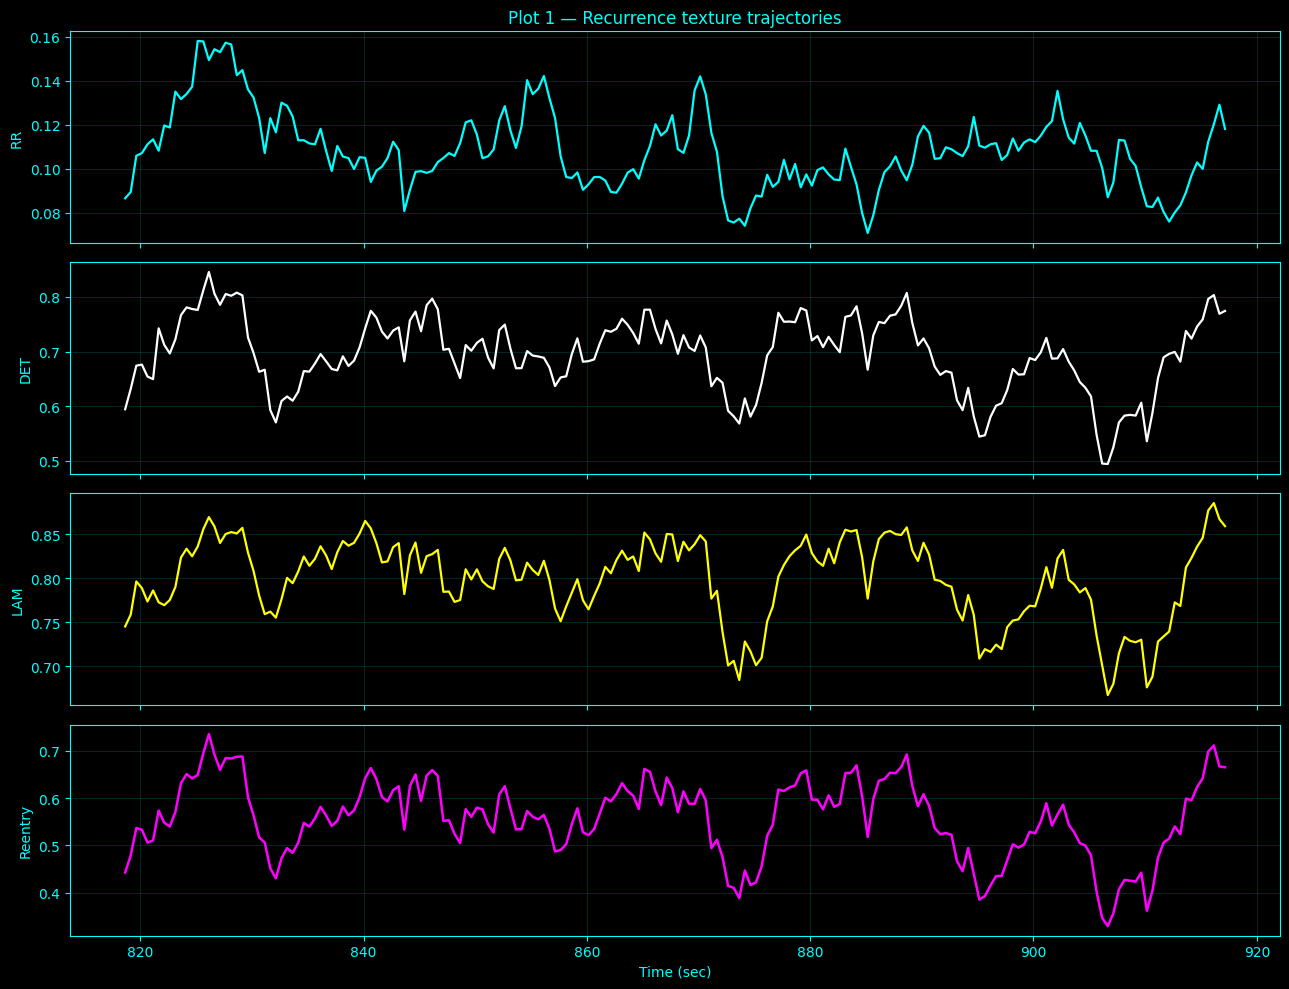

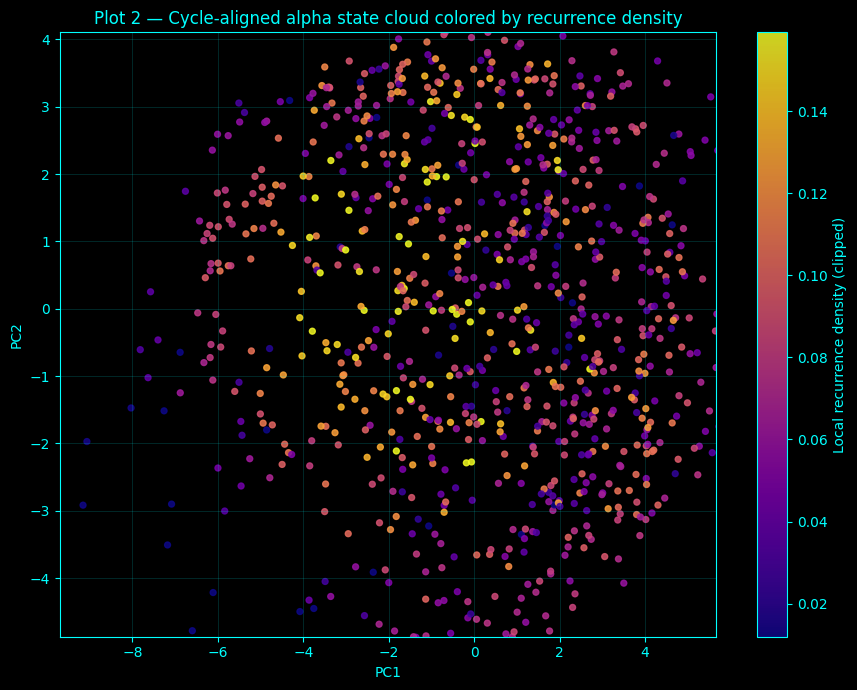

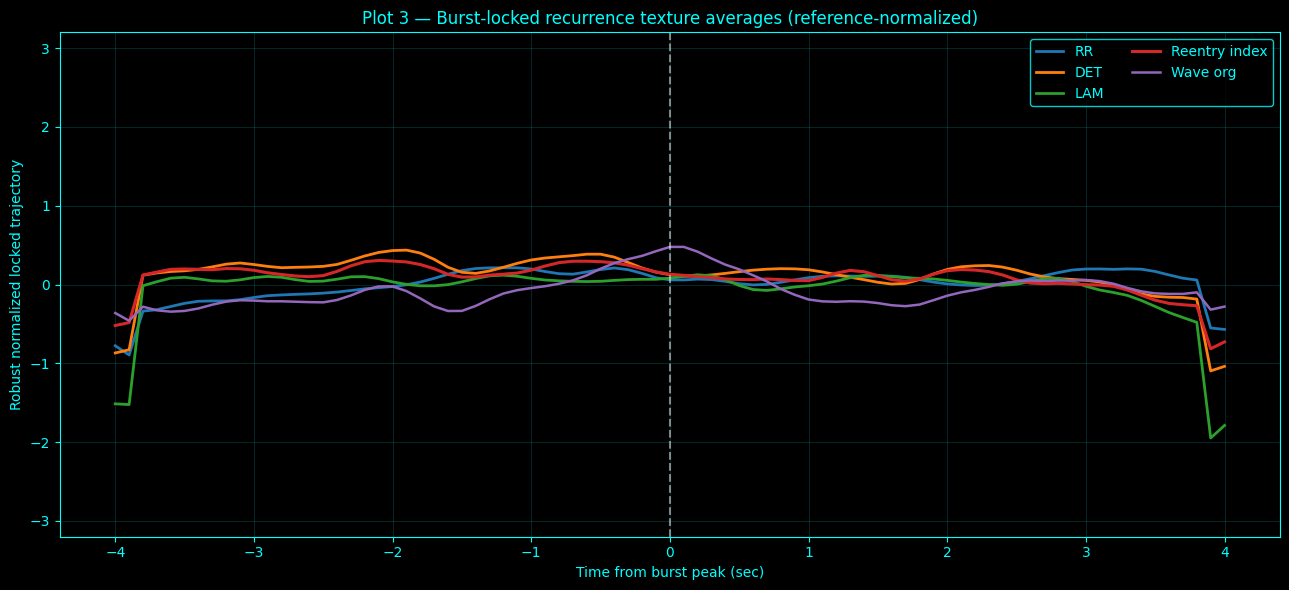

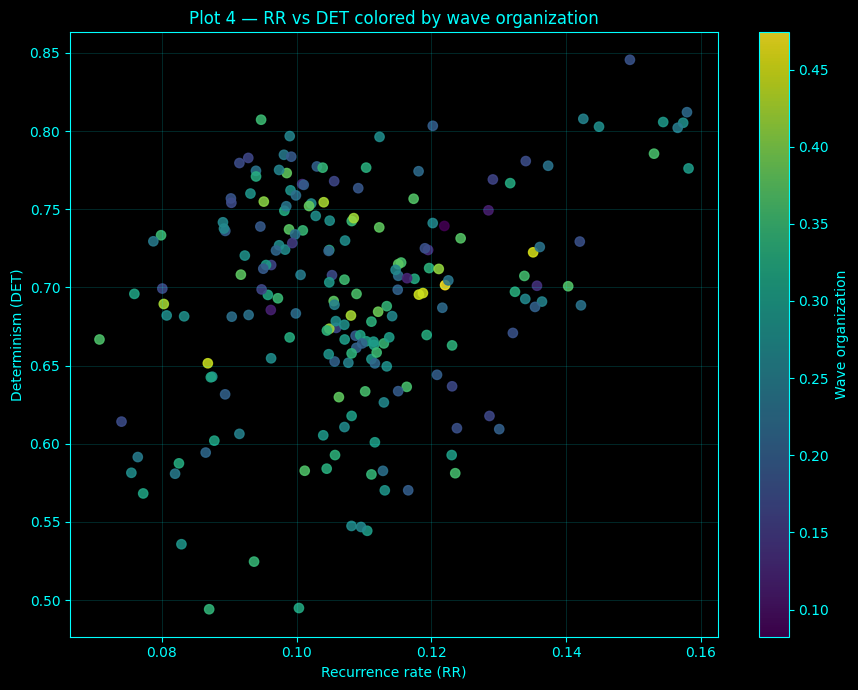

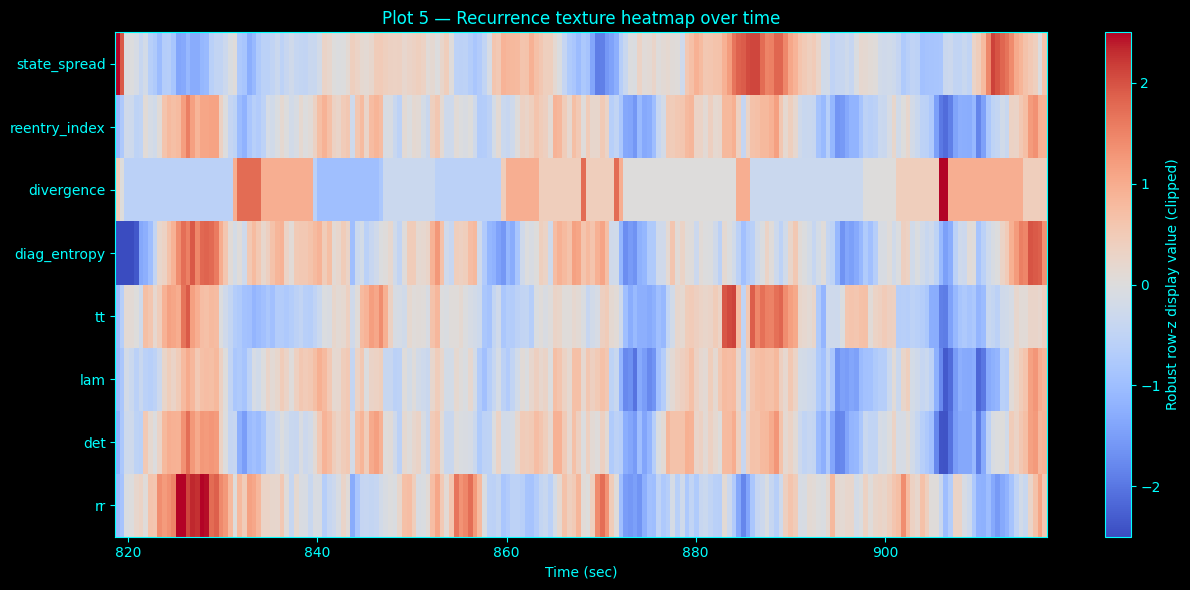

Saved plot 1: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_alpha_recurrence_texture_atlas_CYCLE_ALIGNED_v2/plots_rebuilt/plot1_recurrence_metric_trajectories.png
Saved plot 2: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_alpha_recurrence_texture_atlas_CYCLE_ALIGNED_v2/plots_rebuilt/plot2_state_cloud_recurrence_density.png
Saved plot 3: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_alpha_recurrence_texture_atlas_CYCLE_ALIGNED_v2/plots_rebuilt/plot3_burst_locked_recurrence_averages_FIXED.png
Saved plot 4: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_alpha_recurrence_texture_atlas_CYCLE_ALIGNED_v2/plots_rebuilt/plot4_rr_vs_det_colored_by_wave_org.png
Saved plot 5: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_alpha_recurrence_texture_atlas_CYCLE_ALIGNED_v2/plots_rebuilt/plot5_recurrence_metric_heatmap_over_time.png
Done.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------
# CONFIG — FILE PATHS ONLY
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
results_dir = os.path.join(base_dir, "results")

candidate_dirs = [
    os.path.join(results_dir, "exploratory_alpha_recurrence_texture_atlas_CYCLE_ALIGNED_v2"),
    os.path.join(results_dir, "exploratory_alpha_recurrence_texture_atlas_CYCLE_ALIGNED"),
    os.path.join(results_dir, "exploratory_alpha_recurrence_texture_atlas_FIXED"),
]

# fallback to uploaded files if needed
fallback_rqa_csv = "/mnt/data/alpha_recurrence_windowed_metrics.csv"
fallback_state_csv = "/mnt/data/alpha_cycle_state_recurrence_density.csv"
fallback_locked_npz = "/mnt/data/alpha_recurrence_burst_locked.npz"

plot_out_dir = None
rqa_csv_path = None
state_csv_path = None
locked_npz_path = None

for d in candidate_dirs:
    a = os.path.join(d, "alpha_recurrence_windowed_metrics.csv")
    b = os.path.join(d, "alpha_cycle_state_recurrence_density.csv")
    c = os.path.join(d, "alpha_recurrence_burst_locked.npz")
    if os.path.exists(a) and os.path.exists(b) and os.path.exists(c):
        rqa_csv_path = a
        state_csv_path = b
        locked_npz_path = c
        plot_out_dir = os.path.join(d, "plots_rebuilt")
        break

if rqa_csv_path is None:
    rqa_csv_path = fallback_rqa_csv
    state_csv_path = fallback_state_csv
    locked_npz_path = fallback_locked_npz
    plot_out_dir = "/mnt/data/recurrence_plots_rebuilt"

os.makedirs(plot_out_dir, exist_ok=True)

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
ACCENT = "cyan"
BG = "black"
eps = 1e-12

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
    "font.size": 10,
})

def style_ax(ax, heatmap=False):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)
    if heatmap:
        ax.grid(False)
    else:
        ax.grid(True, alpha=0.18, color=ACCENT, linewidth=0.6)

def smooth_1d_nanaware(x, win=3):
    x = np.asarray(x, dtype=float)
    if win <= 1 or len(x) < win:
        return x.copy()

    out = x.copy()
    finite = np.isfinite(x)
    if np.sum(finite) < 3:
        return out

    idx = np.arange(len(x))
    filled = np.interp(idx, idx[finite], x[finite])
    kernel = np.ones(win, dtype=float) / win
    smoothed = np.convolve(filled, kernel, mode="same")
    out[finite] = smoothed[finite]
    return out

def robust_row_z(row, clip=2.5):
    row = np.asarray(row, dtype=float)
    med = np.nanmedian(row)
    q25 = np.nanpercentile(row, 25)
    q75 = np.nanpercentile(row, 75)
    scale = (q75 - q25) if (q75 - q25) > 1e-8 else (np.nanstd(row) + eps)
    z = (row - med) / scale
    return np.clip(z, -clip, clip)

def normalize_locked_against_reference(center_curve, reference_series, support_frac=None,
                                       min_support=0.40, clip=3.0, smooth_win=3):
    """
    Key fix:
    normalize the burst-locked center curve against the full RQA trajectory
    for the same metric, not against the locked curve itself.
    """
    center_curve = np.asarray(center_curve, dtype=float).copy()
    ref = np.asarray(reference_series, dtype=float)

    finite_ref = np.isfinite(ref)
    if np.sum(finite_ref) < 5:
        return np.full_like(center_curve, np.nan)

    med = np.nanmedian(ref)
    q25 = np.nanpercentile(ref, 25)
    q75 = np.nanpercentile(ref, 75)
    scale = (q75 - q25) if (q75 - q25) > 1e-8 else (np.nanstd(ref) + eps)

    y = (center_curve - med) / scale

    if support_frac is not None:
        support_frac = np.asarray(support_frac, dtype=float)
        y[support_frac < min_support] = np.nan

    y = smooth_1d_nanaware(y, win=smooth_win)

    if support_frac is not None:
        y[support_frac < min_support] = np.nan

    return np.clip(y, -clip, clip)

def center_and_mask_locked(arr, stat="median", min_fraction=0.40, smooth_win=3):
    arr = np.asarray(arr, dtype=float)
    if arr.ndim != 2 or arr.shape[0] == 0:
        n = arr.shape[1] if arr.ndim == 2 else 0
        return np.full(n, np.nan), np.zeros(n)

    support = np.sum(np.isfinite(arr), axis=0).astype(float)
    max_support = np.nanmax(support) if len(support) > 0 else 0.0
    needed = max(1, int(np.ceil(min_fraction * max_support))) if max_support > 0 else 1

    if stat == "median":
        center = np.nanmedian(arr, axis=0)
    else:
        center = np.nanmean(arr, axis=0)

    center[support < needed] = np.nan
    center = smooth_1d_nanaware(center, win=smooth_win)
    center[support < needed] = np.nan

    support_frac = support / (max_support + eps) if max_support > 0 else np.zeros_like(support)
    return center, support_frac

# -------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------
rqa_df = pd.read_csv(rqa_csv_path)
state_df = pd.read_csv(state_csv_path)
locked_npz = np.load(locked_npz_path, allow_pickle=True)

print(f"Loaded RQA: {rqa_csv_path}")
print(f"Loaded state cloud: {state_csv_path}")
print(f"Loaded burst-locked NPZ: {locked_npz_path}")

# -------------------------------------------------------
# PLOT PATHS
# -------------------------------------------------------
plot1_path = os.path.join(plot_out_dir, "plot1_recurrence_metric_trajectories.png")
plot2_path = os.path.join(plot_out_dir, "plot2_state_cloud_recurrence_density.png")
plot3_path = os.path.join(plot_out_dir, "plot3_burst_locked_recurrence_averages_FIXED.png")
plot4_path = os.path.join(plot_out_dir, "plot4_rr_vs_det_colored_by_wave_org.png")
plot5_path = os.path.join(plot_out_dir, "plot5_recurrence_metric_heatmap_over_time.png")

# -------------------------------------------------------
# PLOT 1 — RECURRENCE TRAJECTORIES
# -------------------------------------------------------
fig1, axes1 = plt.subplots(4, 1, figsize=(13, 10), facecolor=BG, sharex=True)
axes1 = np.atleast_1d(axes1)

for ax in axes1:
    style_ax(ax)

axes1[0].plot(rqa_df["time_sec"], rqa_df["rr"], linewidth=1.6, color=ACCENT)
axes1[0].set_ylabel("RR")
axes1[0].set_title("Plot 1 — Recurrence texture trajectories")

axes1[1].plot(rqa_df["time_sec"], rqa_df["det"], linewidth=1.6, color="white")
axes1[1].set_ylabel("DET")

axes1[2].plot(rqa_df["time_sec"], rqa_df["lam"], linewidth=1.6, color="yellow")
axes1[2].set_ylabel("LAM")

axes1[3].plot(rqa_df["time_sec"], rqa_df["reentry_index"], linewidth=1.8, color="magenta")
axes1[3].set_ylabel("Reentry")
axes1[3].set_xlabel("Time (sec)")

fig1.tight_layout()
fig1.savefig(plot1_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig1)

# -------------------------------------------------------
# PLOT 2 — STATE CLOUD RECURRENCE DENSITY
# -------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(9, 7), facecolor=BG)
style_ax(ax2)

x = state_df["PC1"].values
y = state_df["PC2"].values
dens = state_df["recurrence_density"].values

finite_dens = dens[np.isfinite(dens)]
if len(finite_dens) > 0:
    lo, hi = np.percentile(finite_dens, [2, 98])
    dens_display = np.clip(dens, lo, hi)
else:
    dens_display = dens

sc = ax2.scatter(
    x, y,
    c=dens_display,
    s=18,
    alpha=0.85,
    cmap="plasma",
)

xlo, xhi = np.percentile(x[np.isfinite(x)], [1, 99])
ylo, yhi = np.percentile(y[np.isfinite(y)], [1, 99])
ax2.set_xlim(xlo, xhi)
ax2.set_ylim(ylo, yhi)

pc1_label = "PC1"
pc2_label = "PC2"
if "PC1" in state_df.columns and "PC2" in state_df.columns:
    pc1_label = "PC1"
    pc2_label = "PC2"

ax2.set_title("Plot 2 — Cycle-aligned alpha state cloud colored by recurrence density")
ax2.set_xlabel(pc1_label)
ax2.set_ylabel(pc2_label)

cbar2 = plt.colorbar(sc, ax=ax2)
cbar2.set_label("Local recurrence density (clipped)", color=ACCENT)
cbar2.outline.set_edgecolor(ACCENT)
cbar2.ax.tick_params(color=ACCENT)
for label in cbar2.ax.get_yticklabels():
    label.set_color(ACCENT)

fig2.tight_layout()
fig2.savefig(plot2_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig2)

# -------------------------------------------------------
# PLOT 3 — BURST-LOCKED RECURRENCE AVERAGES (FIXED)
# -------------------------------------------------------
lock_rel_time = locked_npz["lock_rel_time"]

# use saved centers/support if present, otherwise reconstruct
if "rr_center" in locked_npz.files:
    rr_center = locked_npz["rr_center"]
    det_center = locked_npz["det_center"]
    lam_center = locked_npz["lam_center"]
    reentry_center = locked_npz["reentry_center"]
    wave_center = locked_npz["wave_center"]

    rr_support = locked_npz["rr_support"]
    det_support = locked_npz["det_support"]
    lam_support = locked_npz["lam_support"]
    reentry_support = locked_npz["reentry_support"]
    wave_support = locked_npz["wave_support"]
else:
    rr_center, rr_support = center_and_mask_locked(locked_npz["locked_rr"])
    det_center, det_support = center_and_mask_locked(locked_npz["locked_det"])
    lam_center, lam_support = center_and_mask_locked(locked_npz["locked_lam"])
    reentry_center, reentry_support = center_and_mask_locked(locked_npz["locked_reentry"])
    wave_center, wave_support = center_and_mask_locked(locked_npz["locked_wave_org"])

# FIX: normalize against full RQA trajectory, not against the locked curve itself
rr_plot = normalize_locked_against_reference(
    rr_center, rqa_df["rr"].values, rr_support, min_support=0.40, clip=3.0, smooth_win=3
)
det_plot = normalize_locked_against_reference(
    det_center, rqa_df["det"].values, det_support, min_support=0.40, clip=3.0, smooth_win=3
)
lam_plot = normalize_locked_against_reference(
    lam_center, rqa_df["lam"].values, lam_support, min_support=0.40, clip=3.0, smooth_win=3
)
reentry_plot = normalize_locked_against_reference(
    reentry_center, rqa_df["reentry_index"].values, reentry_support, min_support=0.40, clip=3.0, smooth_win=3
)

if "wave_org" in rqa_df.columns and np.any(np.isfinite(rqa_df["wave_org"].values)):
    wave_plot = normalize_locked_against_reference(
        wave_center, rqa_df["wave_org"].values, wave_support, min_support=0.40, clip=3.0, smooth_win=3
    )
else:
    wave_plot = np.full_like(lock_rel_time, np.nan)

fig3, ax3 = plt.subplots(figsize=(13, 6), facecolor=BG)
style_ax(ax3)

ax3.plot(lock_rel_time, rr_plot, linewidth=2.0, label="RR")
ax3.plot(lock_rel_time, det_plot, linewidth=2.0, label="DET")
ax3.plot(lock_rel_time, lam_plot, linewidth=2.0, label="LAM")
ax3.plot(lock_rel_time, reentry_plot, linewidth=2.2, label="Reentry index")

if np.any(np.isfinite(wave_plot)):
    ax3.plot(lock_rel_time, wave_plot, linewidth=1.8, label="Wave org")

ax3.axvline(0.0, color="white", linestyle="--", alpha=0.5)
ax3.set_ylim(-3.2, 3.2)
ax3.set_title("Plot 3 — Burst-locked recurrence texture averages (reference-normalized)")
ax3.set_xlabel("Time from burst peak (sec)")
ax3.set_ylabel("Robust normalized locked trajectory")
ax3.legend(loc="upper right", ncol=2)

fig3.tight_layout()
fig3.savefig(plot3_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig3)

# -------------------------------------------------------
# PLOT 4 — RR VS DET COLORED BY WAVE ORGANIZATION
# -------------------------------------------------------
fig4, ax4 = plt.subplots(figsize=(9, 7), facecolor=BG)
style_ax(ax4)

cvals = rqa_df["wave_org"].values if "wave_org" in rqa_df.columns else np.full(len(rqa_df), np.nan)
if np.any(np.isfinite(cvals)):
    sc4 = ax4.scatter(
        rqa_df["rr"].values,
        rqa_df["det"].values,
        c=cvals,
        cmap="viridis",
        s=45,
        alpha=0.85,
    )
    cbar4 = plt.colorbar(sc4, ax=ax4)
    cbar4.set_label("Wave organization", color=ACCENT)
    cbar4.outline.set_edgecolor(ACCENT)
    cbar4.ax.tick_params(color=ACCENT)
    for label in cbar4.ax.get_yticklabels():
        label.set_color(ACCENT)
else:
    ax4.scatter(
        rqa_df["rr"].values,
        rqa_df["det"].values,
        s=45,
        alpha=0.85,
    )

ax4.set_title("Plot 4 — RR vs DET colored by wave organization")
ax4.set_xlabel("Recurrence rate (RR)")
ax4.set_ylabel("Determinism (DET)")

fig4.tight_layout()
fig4.savefig(plot4_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig4)

# -------------------------------------------------------
# PLOT 5 — METRIC HEATMAP OVER TIME
# -------------------------------------------------------
heat_cols = ["rr", "det", "lam", "tt", "diag_entropy", "divergence", "reentry_index", "state_spread"]
heat_mat = rqa_df[heat_cols].values.T.astype(float)

heat_display = np.vstack([robust_row_z(row, clip=2.5) for row in heat_mat])

fig5, ax5 = plt.subplots(figsize=(13, 6), facecolor=BG)
style_ax(ax5, heatmap=True)

im5 = ax5.imshow(
    heat_display,
    aspect="auto",
    interpolation="nearest",
    cmap="coolwarm",
    extent=[rqa_df["time_sec"].iloc[0], rqa_df["time_sec"].iloc[-1], 0, len(heat_cols)],
    origin="lower",
    vmin=-2.5,
    vmax=2.5,
)

ax5.set_title("Plot 5 — Recurrence texture heatmap over time")
ax5.set_xlabel("Time (sec)")
ax5.set_yticks(np.arange(len(heat_cols)) + 0.5)
ax5.set_yticklabels(heat_cols)

cbar5 = plt.colorbar(im5, ax=ax5)
cbar5.set_label("Robust row-z display value (clipped)", color=ACCENT)
cbar5.outline.set_edgecolor(ACCENT)
cbar5.ax.tick_params(color=ACCENT)
for label in cbar5.ax.get_yticklabels():
    label.set_color(ACCENT)

fig5.tight_layout()
fig5.savefig(plot5_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig5)

print(f"Saved plot 1: {plot1_path}")
print(f"Saved plot 2: {plot2_path}")
print(f"Saved plot 3: {plot3_path}")
print(f"Saved plot 4: {plot4_path}")
print(f"Saved plot 5: {plot5_path}")
print("Done.")

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Transfer entropy</h3><p>Transfer entropy is a conditional mutual information that measures whether the past of a source $X$ improves prediction of the next target value $Y_{t+1}$ beyond the target's own past. It is directional and depends on the history lengths, lag, estimator, and any discretization used by the implementation.</p><p><b>Cell role.</b> This code applies that theory to the notebook's existing EEG-derived data and preserves the surrounding notebook's plotting/output conventions. Numerical shortcuts selected by a speed mode change sampling density, iteration counts, or visualization resolution; they do not change the defining formula above.</p></div>

$$T_{X\\to Y}=\\sum p(y_{t+1},y_t^{(k)},x_t^{(l)})\\log\\frac{p(y_{t+1}\\mid y_t^{(k)},x_t^{(l)})}{p(y_{t+1}\\mid y_t^{(k)})}.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Mutual information measures how much knowing one variable reduces uncertainty about another. Unlike linear correlation, it can capture nonlinear statistical dependence. In delay-selection problems, mutual information between a signal and a delayed copy is examined as the delay changes; a local minimum is often used as a compromise between coordinates that are too redundant and coordinates that are almost unrelated. The estimate is sensitive to finite sample size and to how probability densities are estimated.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


## Complete implementation of the additional spectral-theory catalogue — methods 1–377

Every numbered method below is now **self-contained**. Each code cell performs its own EEG loading/preparation, contains the mathematical definitions it directly requires, computes the method without calling a shared catalogue dispatcher, and prints its own result.

Plots use the notebook’s **black / cyan** style. A plot is shown only when the method result contains **at least two finite numerical values**; a genuinely single-number result is printed without a plot. The existing **full / balanced / fast / ultra** speed convention is retained independently in every method cell.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">1. Multitaper power spectral density</h3>
<p>Thomson multitaper estimation multiplies the record by \(K\) discrete prolate spheroidal (DPSS/Slepian) tapers and averages their eigenspectra, \(\hat S(f)=K^{-1}\sum_{k=1}^{K}|X_k(f)|^2\). The DPSS tapers maximize spectral concentration in a prescribed half-bandwidth \(W\), reducing leakage without relying on a single window.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A power spectral density describes how signal power is distributed over frequency. Welch's method divides the time series into overlapping segments, windows each segment to reduce edge discontinuities, computes a periodogram for each segment, and averages the results. Averaging reduces the variance of the spectral estimate at the cost of some frequency resolution. The area under the PSD over a frequency band corresponds to power in that band, subject to the normalization convention used by the implementation.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


Multitaper power spectral density
  NW: 3.5
  K: 6
  alpha_power: 0.04892505957899816


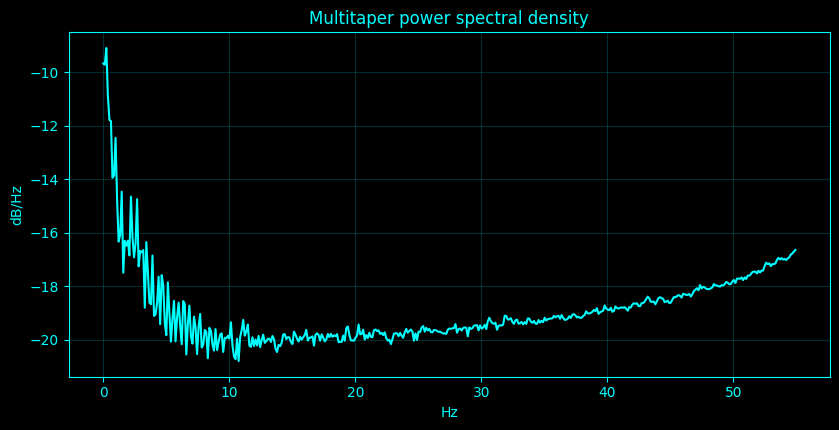

In [11]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _multitaper_psd(data=None, NW=3.5, K=None, adaptive=False):
    Y = X if data is None else np.asarray(data, float)
    if Y.ndim == 1:
        Y = Y[:, None]
    n = min(N if data is None else len(Y), int(_SPEED['nperseg'] * 2))
    n = max(64, n)
    Y = Y[:n] - np.mean(Y[:n], axis=0, keepdims=True)
    K = int(K or max(3, 2 * NW - 1))
    tap, eigs = signal.windows.dpss(n, NW, Kmax=K, return_ratios=True)
    F = np.fft.rfft(Y[:, None, :] * tap.T[:, :, None], axis=0)
    scale = _fs * np.sum(tap ** 2, axis=1)
    P = np.abs(F) ** 2 / scale[None, :, None]
    if adaptive:
        w = eigs / (np.sum(eigs) + EPS)
        Pm = np.sum(P * w[None, :, None], axis=1)
    else:
        Pm = np.mean(P, axis=1)
    f = np.fft.rfftfreq(n, 1 / _fs)
    keep = f <= min(55, 0.49 * _fs)
    return (f[keep], Pm[keep], F[keep], eigs, tap)

# Method-specific calculation.
def _compute_method_1():
    idx = 1
    name = 'Multitaper power spectral density'
    __plot_spec = None
    f, P, F, eigs, tapers = _multitaper_psd(adaptive=idx == 9)
    __plot_spec = ('summary', 10 * np.log10(P[:, 0] + EPS), name, f, 'Hz', 'dB/Hz')
    return ({'NW': 3.5, 'K': len(eigs), 'alpha_power': float(_band_integral(P, f, BANDS['alpha'])[0])}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_1,_plot_spec=_compute_method_1()
print('Multitaper power spectral density')
if isinstance(result_1,dict):
    for _k,_v in result_1.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_1)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_1)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Multitaper power spectral density',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Multitaper power spectral density',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Multitaper power spectral density',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">2. Thomson multitaper spectrum</h3>
<p>Thomson multitaper estimation multiplies the record by \(K\) discrete prolate spheroidal (DPSS/Slepian) tapers and averages their eigenspectra, \(\hat S(f)=K^{-1}\sum_{k=1}^{K}|X_k(f)|^2\). The DPSS tapers maximize spectral concentration in a prescribed half-bandwidth \(W\), reducing leakage without relying on a single window.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


Thomson multitaper spectrum
  NW: 3.5
  K: 6
  alpha_power: 0.04892505957899816


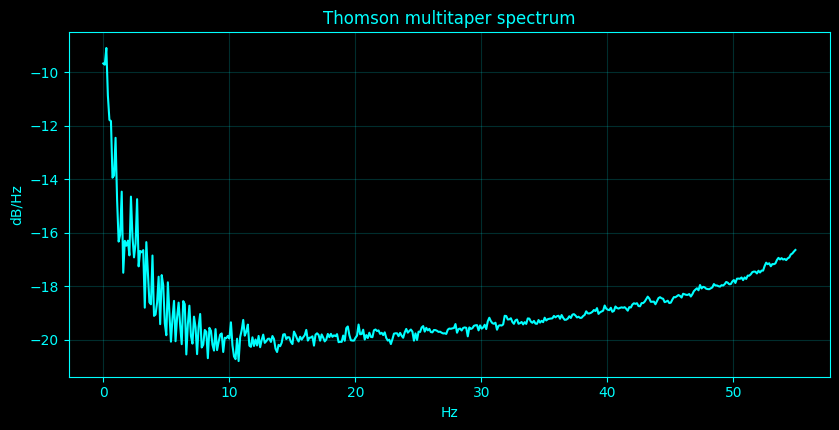

In [12]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _multitaper_psd(data=None, NW=3.5, K=None, adaptive=False):
    Y = X if data is None else np.asarray(data, float)
    if Y.ndim == 1:
        Y = Y[:, None]
    n = min(N if data is None else len(Y), int(_SPEED['nperseg'] * 2))
    n = max(64, n)
    Y = Y[:n] - np.mean(Y[:n], axis=0, keepdims=True)
    K = int(K or max(3, 2 * NW - 1))
    tap, eigs = signal.windows.dpss(n, NW, Kmax=K, return_ratios=True)
    F = np.fft.rfft(Y[:, None, :] * tap.T[:, :, None], axis=0)
    scale = _fs * np.sum(tap ** 2, axis=1)
    P = np.abs(F) ** 2 / scale[None, :, None]
    if adaptive:
        w = eigs / (np.sum(eigs) + EPS)
        Pm = np.sum(P * w[None, :, None], axis=1)
    else:
        Pm = np.mean(P, axis=1)
    f = np.fft.rfftfreq(n, 1 / _fs)
    keep = f <= min(55, 0.49 * _fs)
    return (f[keep], Pm[keep], F[keep], eigs, tap)

# Method-specific calculation.
def _compute_method_2():
    idx = 2
    name = 'Thomson multitaper spectrum'
    __plot_spec = None
    f, P, F, eigs, tapers = _multitaper_psd(adaptive=idx == 9)
    __plot_spec = ('summary', 10 * np.log10(P[:, 0] + EPS), name, f, 'Hz', 'dB/Hz')
    return ({'NW': 3.5, 'K': len(eigs), 'alpha_power': float(_band_integral(P, f, BANDS['alpha'])[0])}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_2,_plot_spec=_compute_method_2()
print('Thomson multitaper spectrum')
if isinstance(result_2,dict):
    for _k,_v in result_2.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_2)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_2)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Thomson multitaper spectrum',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Thomson multitaper spectrum',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Thomson multitaper spectrum',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">3. Multitaper spectrogram</h3>
<p>A multitaper spectrogram applies the Thomson estimator in successive overlapping time windows. Each time-frequency pixel is the average of DPSS eigenspectra in that window, giving lower variance than a single-taper spectrogram.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


Multitaper spectrogram
  time_bins: 51
  frequency_bins: 185


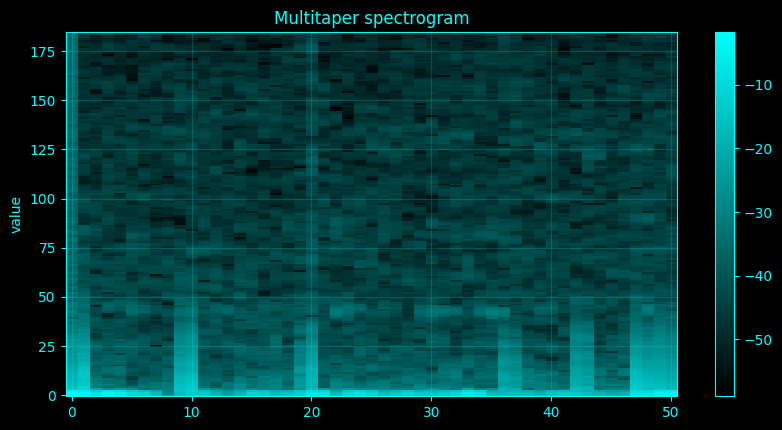

In [13]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _multitaper_psd(data=None, NW=3.5, K=None, adaptive=False):
    Y = X if data is None else np.asarray(data, float)
    if Y.ndim == 1:
        Y = Y[:, None]
    n = min(N if data is None else len(Y), int(_SPEED['nperseg'] * 2))
    n = max(64, n)
    Y = Y[:n] - np.mean(Y[:n], axis=0, keepdims=True)
    K = int(K or max(3, 2 * NW - 1))
    tap, eigs = signal.windows.dpss(n, NW, Kmax=K, return_ratios=True)
    F = np.fft.rfft(Y[:, None, :] * tap.T[:, :, None], axis=0)
    scale = _fs * np.sum(tap ** 2, axis=1)
    P = np.abs(F) ** 2 / scale[None, :, None]
    if adaptive:
        w = eigs / (np.sum(eigs) + EPS)
        Pm = np.sum(P * w[None, :, None], axis=1)
    else:
        Pm = np.mean(P, axis=1)
    f = np.fft.rfftfreq(n, 1 / _fs)
    keep = f <= min(55, 0.49 * _fs)
    return (f[keep], Pm[keep], F[keep], eigs, tap)

# Method-specific calculation.
def _compute_method_3():
    idx = 3
    name = 'Multitaper spectrogram'
    __plot_spec = None
    f, P, F, eigs, tapers = _multitaper_psd(adaptive=idx == 9)
    n = min(_SPEED['nperseg'], N)
    step = max(1, n // 2)
    cols = []
    tc = []
    tap = signal.windows.dpss(n, 3, Kmax=3)
    for a in range(0, N - n + 1, step):
        seg = X[a:a + n, 0]
        ps = []
        for tt in tap:
            ff = np.fft.rfftfreq(n, 1 / _fs)
            z = np.fft.rfft(seg * tt)
            ps.append(np.abs(z) ** 2 / (_fs * np.sum(tt ** 2)))
        cols.append(np.mean(ps, axis=0))
        tc.append((a + n / 2) / _fs)
    S = np.asarray(cols).T
    m = ff <= min(45, 0.49 * _fs)
    __plot_spec = ('summary', 10 * np.log10(S[m] + EPS), name, None, '', 'value')
    return ({'time_bins': len(tc), 'frequency_bins': int(np.sum(m))}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_3,_plot_spec=_compute_method_3()
print('Multitaper spectrogram')
if isinstance(result_3,dict):
    for _k,_v in result_3.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_3)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_3)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Multitaper spectrogram',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Multitaper spectrogram',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Multitaper spectrogram',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">4. Multitaper coherence</h3>
<p>Multitaper coherence forms taper-averaged cross- and auto-spectra, then uses \(C_{xy}(f)=|\hat S_{xy}(f)|^2/[\hat S_{xx}(f)\hat S_{yy}(f)]\).</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Coherence is a frequency-specific measure of linear association between two signals. It compares the magnitude of their cross-spectrum with the power spectra of the individual signals. Values near one mean that a stable linear relationship at that frequency explains a large fraction of the spectral activity, while values near zero indicate weak consistency. High coherence can arise from common input, volume conduction, or shared reference effects, so it should not automatically be interpreted as direct connectivity.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [14]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _multitaper_psd(data=None, NW=3.5, K=None, adaptive=False):
    Y = X if data is None else np.asarray(data, float)
    if Y.ndim == 1:
        Y = Y[:, None]
    n = min(N if data is None else len(Y), int(_SPEED['nperseg'] * 2))
    n = max(64, n)
    Y = Y[:n] - np.mean(Y[:n], axis=0, keepdims=True)
    K = int(K or max(3, 2 * NW - 1))
    tap, eigs = signal.windows.dpss(n, NW, Kmax=K, return_ratios=True)
    F = np.fft.rfft(Y[:, None, :] * tap.T[:, :, None], axis=0)
    scale = _fs * np.sum(tap ** 2, axis=1)
    P = np.abs(F) ** 2 / scale[None, :, None]
    if adaptive:
        w = eigs / (np.sum(eigs) + EPS)
        Pm = np.sum(P * w[None, :, None], axis=1)
    else:
        Pm = np.mean(P, axis=1)
    f = np.fft.rfftfreq(n, 1 / _fs)
    keep = f <= min(55, 0.49 * _fs)
    return (f[keep], Pm[keep], F[keep], eigs, tap)

def _multitaper_csd(i=0, j=1, NW=3.5):
    f, P, F, eigs, tap = _multitaper_psd(NW=NW)
    Xi = F[:, :, i]
    Xj = F[:, :, j]
    Sxy = np.mean(Xi * np.conj(Xj), axis=1)
    Sxx = np.mean(np.abs(Xi) ** 2, axis=1)
    Syy = np.mean(np.abs(Xj) ** 2, axis=1)
    coh = np.abs(Sxy) ** 2 / (Sxx * Syy + EPS)
    return (f, Sxy, Sxx, Syy, coh, F)

# Method-specific calculation.
def _compute_method_4():
    idx = 4
    name = 'Multitaper coherence'
    __plot_spec = None
    f, P, F, eigs, tapers = _multitaper_psd(adaptive=idx == 9)
    ff, Sxy, Sxx, Syy, coh, Fm = _multitaper_csd()
    __plot_spec = ('summary', coh, name, ff, 'Hz', 'coherence')
    return ({'alpha_coherence': float(np.mean(coh[(ff >= 8) & (ff < 13)]))}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_4,_plot_spec=_compute_method_4()
print('Multitaper coherence')
if isinstance(result_4,dict):
    for _k,_v in result_4.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_4)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_4)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Multitaper coherence',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Multitaper coherence',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Multitaper coherence',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Multitaper coherence
  alpha_coherence: 0.9990027449515262


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">5. Multitaper phase-locking value</h3>
<p>Multitaper PLV normalizes each taper-domain cross coefficient to unit magnitude and averages its phase, \(\mathrm{PLV}(f)=|\langle X_k(f)Y_k^\ast(f)/|X_k(f)Y_k^\ast(f)|\rangle_k|\).</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Phase-locking value measures how consistent the phase difference between two signals is across samples, trials, or windows. Each phase difference is converted to a unit complex number on the circle and these vectors are averaged. If phase differences are almost identical, the vectors point in the same direction and the average magnitude approaches one. If phase differences are widely spread, they cancel and the magnitude approaches zero. PLV ignores amplitude and does not establish causal influence.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. Expectation or angle-bracket notation denotes an average with respect to a probability distribution or ensemble.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [15]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _multitaper_psd(data=None, NW=3.5, K=None, adaptive=False):
    Y = X if data is None else np.asarray(data, float)
    if Y.ndim == 1:
        Y = Y[:, None]
    n = min(N if data is None else len(Y), int(_SPEED['nperseg'] * 2))
    n = max(64, n)
    Y = Y[:n] - np.mean(Y[:n], axis=0, keepdims=True)
    K = int(K or max(3, 2 * NW - 1))
    tap, eigs = signal.windows.dpss(n, NW, Kmax=K, return_ratios=True)
    F = np.fft.rfft(Y[:, None, :] * tap.T[:, :, None], axis=0)
    scale = _fs * np.sum(tap ** 2, axis=1)
    P = np.abs(F) ** 2 / scale[None, :, None]
    if adaptive:
        w = eigs / (np.sum(eigs) + EPS)
        Pm = np.sum(P * w[None, :, None], axis=1)
    else:
        Pm = np.mean(P, axis=1)
    f = np.fft.rfftfreq(n, 1 / _fs)
    keep = f <= min(55, 0.49 * _fs)
    return (f[keep], Pm[keep], F[keep], eigs, tap)

def _multitaper_csd(i=0, j=1, NW=3.5):
    f, P, F, eigs, tap = _multitaper_psd(NW=NW)
    Xi = F[:, :, i]
    Xj = F[:, :, j]
    Sxy = np.mean(Xi * np.conj(Xj), axis=1)
    Sxx = np.mean(np.abs(Xi) ** 2, axis=1)
    Syy = np.mean(np.abs(Xj) ** 2, axis=1)
    coh = np.abs(Sxy) ** 2 / (Sxx * Syy + EPS)
    return (f, Sxy, Sxx, Syy, coh, F)

# Method-specific calculation.
def _compute_method_5():
    idx = 5
    name = 'Multitaper phase-locking value'
    __plot_spec = None
    f, P, F, eigs, tapers = _multitaper_psd(adaptive=idx == 9)
    ff, Sxy, Sxx, Syy, coh, Fm = _multitaper_csd()
    z = Fm[:, :, 0] * np.conj(Fm[:, :, 1])
    plv = np.abs(np.mean(z / (np.abs(z) + EPS), axis=1))
    __plot_spec = ('summary', plv, name, ff, 'Hz', 'multitaper PLV')
    return ({'alpha_PLV': float(np.mean(plv[(ff >= 8) & (ff < 13)]))}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_5,_plot_spec=_compute_method_5()
print('Multitaper phase-locking value')
if isinstance(result_5,dict):
    for _k,_v in result_5.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_5)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_5)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Multitaper phase-locking value',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Multitaper phase-locking value',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Multitaper phase-locking value',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Multitaper phase-locking value
  alpha_PLV: 0.9876834111234166


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">6. Multitaper cross-spectrum</h3>
<p>The multitaper cross-spectrum is \(\hat S_{xy}(f)=K^{-1}\sum_k X_k(f)Y_k^\ast(f)\); its magnitude describes shared spectral amplitude and its argument the average phase relation.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [16]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _multitaper_psd(data=None, NW=3.5, K=None, adaptive=False):
    Y = X if data is None else np.asarray(data, float)
    if Y.ndim == 1:
        Y = Y[:, None]
    n = min(N if data is None else len(Y), int(_SPEED['nperseg'] * 2))
    n = max(64, n)
    Y = Y[:n] - np.mean(Y[:n], axis=0, keepdims=True)
    K = int(K or max(3, 2 * NW - 1))
    tap, eigs = signal.windows.dpss(n, NW, Kmax=K, return_ratios=True)
    F = np.fft.rfft(Y[:, None, :] * tap.T[:, :, None], axis=0)
    scale = _fs * np.sum(tap ** 2, axis=1)
    P = np.abs(F) ** 2 / scale[None, :, None]
    if adaptive:
        w = eigs / (np.sum(eigs) + EPS)
        Pm = np.sum(P * w[None, :, None], axis=1)
    else:
        Pm = np.mean(P, axis=1)
    f = np.fft.rfftfreq(n, 1 / _fs)
    keep = f <= min(55, 0.49 * _fs)
    return (f[keep], Pm[keep], F[keep], eigs, tap)

def _multitaper_csd(i=0, j=1, NW=3.5):
    f, P, F, eigs, tap = _multitaper_psd(NW=NW)
    Xi = F[:, :, i]
    Xj = F[:, :, j]
    Sxy = np.mean(Xi * np.conj(Xj), axis=1)
    Sxx = np.mean(np.abs(Xi) ** 2, axis=1)
    Syy = np.mean(np.abs(Xj) ** 2, axis=1)
    coh = np.abs(Sxy) ** 2 / (Sxx * Syy + EPS)
    return (f, Sxy, Sxx, Syy, coh, F)

# Method-specific calculation.
def _compute_method_6():
    idx = 6
    name = 'Multitaper cross-spectrum'
    __plot_spec = None
    f, P, F, eigs, tapers = _multitaper_psd(adaptive=idx == 9)
    ff, Sxy, Sxx, Syy, coh, Fm = _multitaper_csd()
    __plot_spec = ('summary', np.vstack([np.abs(Sxy), np.angle(Sxy)]), name, None, '', 'value')
    return ({'alpha_cross_spectrum_magnitude': float(np.mean(np.abs(Sxy[(ff >= 8) & (ff < 13)])))}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_6,_plot_spec=_compute_method_6()
print('Multitaper cross-spectrum')
if isinstance(result_6,dict):
    for _k,_v in result_6.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_6)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_6)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Multitaper cross-spectrum',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Multitaper cross-spectrum',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Multitaper cross-spectrum',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Multitaper cross-spectrum
  alpha_cross_spectrum_magnitude: 1.2028570032485506


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">7. Multitaper time-frequency reassignment</h3>
<p>Time-frequency reassignment moves spectrogram energy from the analysis-bin center toward an instantaneous-frequency estimate obtained from the local STFT phase derivative. The multitaper version averages the reassigned information from several DPSS windows.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


In [17]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _multitaper_psd(data=None, NW=3.5, K=None, adaptive=False):
    Y = X if data is None else np.asarray(data, float)
    if Y.ndim == 1:
        Y = Y[:, None]
    n = min(N if data is None else len(Y), int(_SPEED['nperseg'] * 2))
    n = max(64, n)
    Y = Y[:n] - np.mean(Y[:n], axis=0, keepdims=True)
    K = int(K or max(3, 2 * NW - 1))
    tap, eigs = signal.windows.dpss(n, NW, Kmax=K, return_ratios=True)
    F = np.fft.rfft(Y[:, None, :] * tap.T[:, :, None], axis=0)
    scale = _fs * np.sum(tap ** 2, axis=1)
    P = np.abs(F) ** 2 / scale[None, :, None]
    if adaptive:
        w = eigs / (np.sum(eigs) + EPS)
        Pm = np.sum(P * w[None, :, None], axis=1)
    else:
        Pm = np.mean(P, axis=1)
    f = np.fft.rfftfreq(n, 1 / _fs)
    keep = f <= min(55, 0.49 * _fs)
    return (f[keep], Pm[keep], F[keep], eigs, tap)

# Method-specific calculation.
def _compute_method_7():
    idx = 7
    name = 'Multitaper time-frequency reassignment'
    __plot_spec = None
    f, P, F, eigs, tapers = _multitaper_psd(adaptive=idx == 9)
    n = min(_SPEED['nperseg'], N)
    no = n // 2
    tap = signal.windows.dpss(n, 3, Kmax=3)
    powers = []
    freqs_est = []
    for tt in tap:
        ff, t0, Z = signal.stft(X[:, 0], fs=_fs, window=tt, nperseg=n, noverlap=no, boundary=None, padded=False)
        ph = np.unwrap(np.angle(Z), axis=1)
        inst = np.gradient(ph, t0, axis=1) / (2 * np.pi) + ff[:, None]
        powers.append(np.abs(Z) ** 2)
        freqs_est.append(inst)
    Pm = np.mean(powers, axis=0)
    Ih = np.mean(freqs_est, axis=0)
    keep = ff <= min(45, 0.49 * _fs)
    ridge = np.sum(Pm[keep] * Ih[keep], axis=0) / (np.sum(Pm[keep], axis=0) + EPS)
    __plot_spec = ('summary', ridge, name, t0, 'time (s)', 'reassigned Hz')
    return ({'ridge_mean_hz': float(np.nanmean(ridge))}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_7,_plot_spec=_compute_method_7()
print('Multitaper time-frequency reassignment')
if isinstance(result_7,dict):
    for _k,_v in result_7.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_7)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_7)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Multitaper time-frequency reassignment',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Multitaper time-frequency reassignment',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Multitaper time-frequency reassignment',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Multitaper time-frequency reassignment
  ridge_mean_hz: 1.8942590822589258


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">8. Multitaper jackknife confidence intervals</h3>
<p>Multitaper jackknife uncertainty leaves out one taper at a time. For log spectrum \(\theta_k(f)\), the jackknife variance is \((K-1)K^{-1}\sum_k[\theta_k-\bar\theta]^2\), which captures taper-to-taper variability.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [18]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _multitaper_psd(data=None, NW=3.5, K=None, adaptive=False):
    Y = X if data is None else np.asarray(data, float)
    if Y.ndim == 1:
        Y = Y[:, None]
    n = min(N if data is None else len(Y), int(_SPEED['nperseg'] * 2))
    n = max(64, n)
    Y = Y[:n] - np.mean(Y[:n], axis=0, keepdims=True)
    K = int(K or max(3, 2 * NW - 1))
    tap, eigs = signal.windows.dpss(n, NW, Kmax=K, return_ratios=True)
    F = np.fft.rfft(Y[:, None, :] * tap.T[:, :, None], axis=0)
    scale = _fs * np.sum(tap ** 2, axis=1)
    P = np.abs(F) ** 2 / scale[None, :, None]
    if adaptive:
        w = eigs / (np.sum(eigs) + EPS)
        Pm = np.sum(P * w[None, :, None], axis=1)
    else:
        Pm = np.mean(P, axis=1)
    f = np.fft.rfftfreq(n, 1 / _fs)
    keep = f <= min(55, 0.49 * _fs)
    return (f[keep], Pm[keep], F[keep], eigs, tap)

# Method-specific calculation.
def _compute_method_8():
    idx = 8
    name = 'Multitaper jackknife confidence intervals'
    __plot_spec = None
    f, P, F, eigs, tapers = _multitaper_psd(adaptive=idx == 9)
    K = F.shape[1]
    logs = []
    raw = np.abs(F[:, :, 0]) ** 2
    for k in range(K):
        logs.append(np.log(np.mean(np.delete(raw, k, axis=1), axis=1) + EPS))
    se = np.sqrt((K - 1) * np.var(np.asarray(logs), axis=0, ddof=0))
    m = (f >= 8) & (f < 13)
    return ({'median_logPSD_jackknife_SE_alpha': float(np.median(se[m]))}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_8,_plot_spec=_compute_method_8()
print('Multitaper jackknife confidence intervals')
if isinstance(result_8,dict):
    for _k,_v in result_8.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_8)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_8)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Multitaper jackknife confidence intervals',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Multitaper jackknife confidence intervals',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Multitaper jackknife confidence intervals',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Multitaper jackknife confidence intervals
  median_logPSD_jackknife_SE_alpha: 1.6194611321653927


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">9. Adaptive multitaper spectral estimation</h3>
<p>Adaptive multitaper estimation weights eigenspectra according to DPSS spectral concentration rather than averaging them equally. Highly concentrated tapers receive larger weight.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Adaptive multitaper spectral estimation
  adaptive_weight_sum: 0.9999999999998312
  mean_eigen_concentration: 0.9890476245558074


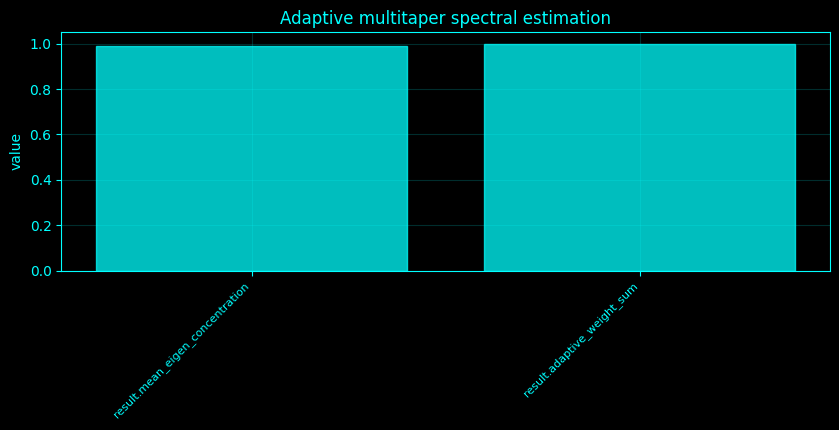

In [19]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _multitaper_psd(data=None, NW=3.5, K=None, adaptive=False):
    Y = X if data is None else np.asarray(data, float)
    if Y.ndim == 1:
        Y = Y[:, None]
    n = min(N if data is None else len(Y), int(_SPEED['nperseg'] * 2))
    n = max(64, n)
    Y = Y[:n] - np.mean(Y[:n], axis=0, keepdims=True)
    K = int(K or max(3, 2 * NW - 1))
    tap, eigs = signal.windows.dpss(n, NW, Kmax=K, return_ratios=True)
    F = np.fft.rfft(Y[:, None, :] * tap.T[:, :, None], axis=0)
    scale = _fs * np.sum(tap ** 2, axis=1)
    P = np.abs(F) ** 2 / scale[None, :, None]
    if adaptive:
        w = eigs / (np.sum(eigs) + EPS)
        Pm = np.sum(P * w[None, :, None], axis=1)
    else:
        Pm = np.mean(P, axis=1)
    f = np.fft.rfftfreq(n, 1 / _fs)
    keep = f <= min(55, 0.49 * _fs)
    return (f[keep], Pm[keep], F[keep], eigs, tap)

# Method-specific calculation.
def _compute_method_9():
    idx = 9
    name = 'Adaptive multitaper spectral estimation'
    __plot_spec = None
    f, P, F, eigs, tapers = _multitaper_psd(adaptive=idx == 9)
    return ({'adaptive_weight_sum': float(np.sum(eigs / (np.sum(eigs) + EPS))), 'mean_eigen_concentration': float(np.mean(eigs))}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_9,_plot_spec=_compute_method_9()
print('Adaptive multitaper spectral estimation')
if isinstance(result_9,dict):
    for _k,_v in result_9.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_9)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_9)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Adaptive multitaper spectral estimation',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Adaptive multitaper spectral estimation',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Adaptive multitaper spectral estimation',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">10. F-test line-noise / sinusoid detection</h3>
<p>A sinusoid F-test compares a regression containing sine/cosine terms at candidate frequency \(f_0\) with a constant-only model. \(F=[(RSS_0-RSS_1)/2]/[RSS_1/(N-3)]\) tests whether the sinusoidal pair explains significant variance.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


F-test line-noise / sinusoid detection
  tested_hz: 50.78125
  F: 1.7117684080483722
  p: 0.18058581138632118


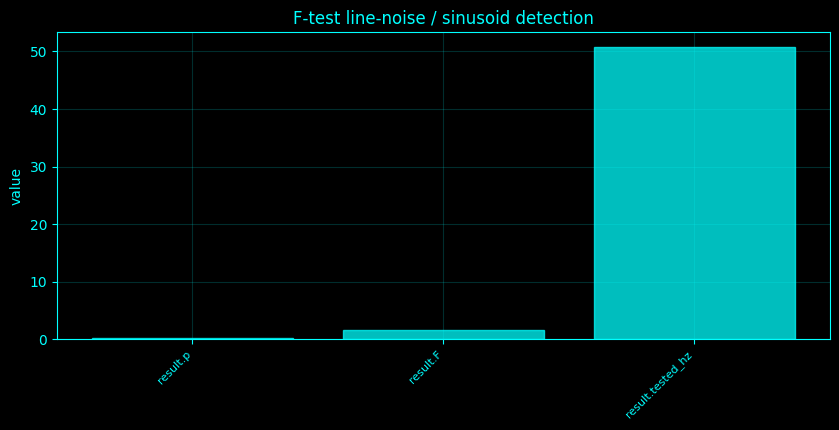

In [20]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

def _multitaper_psd(data=None, NW=3.5, K=None, adaptive=False):
    Y = X if data is None else np.asarray(data, float)
    if Y.ndim == 1:
        Y = Y[:, None]
    n = min(N if data is None else len(Y), int(_SPEED['nperseg'] * 2))
    n = max(64, n)
    Y = Y[:n] - np.mean(Y[:n], axis=0, keepdims=True)
    K = int(K or max(3, 2 * NW - 1))
    tap, eigs = signal.windows.dpss(n, NW, Kmax=K, return_ratios=True)
    F = np.fft.rfft(Y[:, None, :] * tap.T[:, :, None], axis=0)
    scale = _fs * np.sum(tap ** 2, axis=1)
    P = np.abs(F) ** 2 / scale[None, :, None]
    if adaptive:
        w = eigs / (np.sum(eigs) + EPS)
        Pm = np.sum(P * w[None, :, None], axis=1)
    else:
        Pm = np.mean(P, axis=1)
    f = np.fft.rfftfreq(n, 1 / _fs)
    keep = f <= min(55, 0.49 * _fs)
    return (f[keep], Pm[keep], F[keep], eigs, tap)

# Method-specific calculation.
def _compute_method_10():
    idx = 10
    name = 'F-test line-noise / sinusoid detection'
    __plot_spec = None
    f, P, F, eigs, tapers = _multitaper_psd(adaptive=idx == 9)
    y = X[:, 0]
    ff, pp = _psd_of(y[:, None])
    band = (ff >= 45) & (ff <= min(65, 0.49 * _fs))
    if not np.any(band):
        band = (ff >= 4) & (ff <= 45)
    f0 = float(ff[band][np.argmax(pp[band, 0])])
    tt = np.arange(len(y)) / _fs
    Z = np.column_stack([np.ones(len(y)), np.sin(2 * np.pi * f0 * tt), np.cos(2 * np.pi * f0 * tt)])
    b = np.linalg.lstsq(Z, y, rcond=None)[0]
    r = y - Z @ b
    rss1 = np.sum(r * r)
    rss0 = np.sum((y - y.mean()) ** 2)
    Fstat = (rss0 - rss1) / 2 / (rss1 / max(len(y) - 3, 1) + EPS)
    pval = stats.f.sf(Fstat, 2, max(len(y) - 3, 1))
    return ({'tested_hz': f0, 'F': float(Fstat), 'p': float(pval)}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_10,_plot_spec=_compute_method_10()
print('F-test line-noise / sinusoid detection')
if isinstance(result_10,dict):
    for _k,_v in result_10.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_10)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_10)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'F-test line-noise / sinusoid detection',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'F-test line-noise / sinusoid detection',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('F-test line-noise / sinusoid detection',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">11. DPSS taper diagnostics</h3>
<p>DPSS diagnostics inspect concentration eigenvalues \(\lambda_k\in[0,1]\) and numerical orthogonality \(v_i^\top v_j\approx\delta_{ij}\). High \(\lambda_k\) means little taper energy lies outside the design bandwidth.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Jacobian matrix is the local linear approximation of how small changes in each state variable affect the next state. Its eigenvalues and eigenvectors summarize locally preferred directions of growth, decay, or rotation. For a discrete-time map, eigenvalue magnitude below one indicates local contraction and magnitude above one indicates local expansion; for continuous-time systems, the sign of the real part is the corresponding stability indicator. When the Jacobian is estimated from data, these conclusions are local and depend on the quality of the regression or neighborhood used to estimate it.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol λ (lambda) is commonly used for an eigenvalue, Lyapunov exponent, regularization parameter, or rate; its exact meaning is set by the surrounding definition.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


DPSS taper diagnostics
  DPSS_eigenvalues: array(6,), mean=0.989048
  max_abs_taper_inner_product: 7.54984182810281e-16


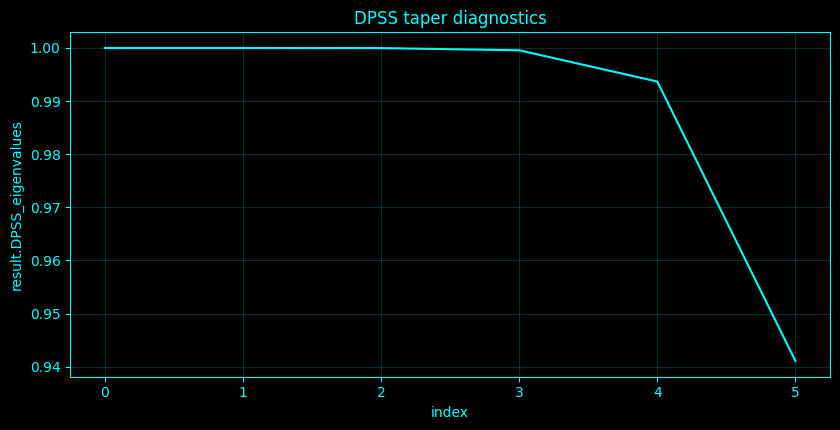

In [21]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _multitaper_psd(data=None, NW=3.5, K=None, adaptive=False):
    Y = X if data is None else np.asarray(data, float)
    if Y.ndim == 1:
        Y = Y[:, None]
    n = min(N if data is None else len(Y), int(_SPEED['nperseg'] * 2))
    n = max(64, n)
    Y = Y[:n] - np.mean(Y[:n], axis=0, keepdims=True)
    K = int(K or max(3, 2 * NW - 1))
    tap, eigs = signal.windows.dpss(n, NW, Kmax=K, return_ratios=True)
    F = np.fft.rfft(Y[:, None, :] * tap.T[:, :, None], axis=0)
    scale = _fs * np.sum(tap ** 2, axis=1)
    P = np.abs(F) ** 2 / scale[None, :, None]
    if adaptive:
        w = eigs / (np.sum(eigs) + EPS)
        Pm = np.sum(P * w[None, :, None], axis=1)
    else:
        Pm = np.mean(P, axis=1)
    f = np.fft.rfftfreq(n, 1 / _fs)
    keep = f <= min(55, 0.49 * _fs)
    return (f[keep], Pm[keep], F[keep], eigs, tap)

# Method-specific calculation.
def _compute_method_11():
    idx = 11
    name = 'DPSS taper diagnostics'
    __plot_spec = None
    f, P, F, eigs, tapers = _multitaper_psd(adaptive=idx == 9)
    G = tapers @ tapers.T
    off = G - np.diag(np.diag(G))
    return ({'DPSS_eigenvalues': eigs.tolist(), 'max_abs_taper_inner_product': float(np.max(np.abs(off)))}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_11,_plot_spec=_compute_method_11()
print('DPSS taper diagnostics')
if isinstance(result_11,dict):
    for _k,_v in result_11.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_11)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_11)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'DPSS taper diagnostics',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'DPSS taper diagnostics',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('DPSS taper diagnostics',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">12. Parametric AR spectral estimation</h3>
<p>An AR(\(p\)) model is \(x_t=\sum_{k=1}^{p}a_kx_{t-k}+\varepsilon_t\). Its spectrum is \(S(f)=\sigma_\varepsilon^2/[f_s|1-\sum_ka_ke^{-i2\pi fk/f_s}|^2]\). Yule-Walker estimates \(a\) from the Toeplitz autocovariance equations.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance measures how two variables vary together around their means. Positive covariance means they tend to deviate in the same direction; negative covariance means opposite directions. Correlation rescales covariance by the variables' standard deviations, making it dimensionless and bounded between -1 and 1 for ordinary Pearson correlation. Both are linear summaries and can miss nonlinear dependence.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. An exponential describes multiplicative growth or decay. In dynamical systems, a positive exponent corresponds to growth with time and a negative exponent to decay. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Parametric AR spectral estimation
  order: 5
  innovation_variance: 0.09190534273185876


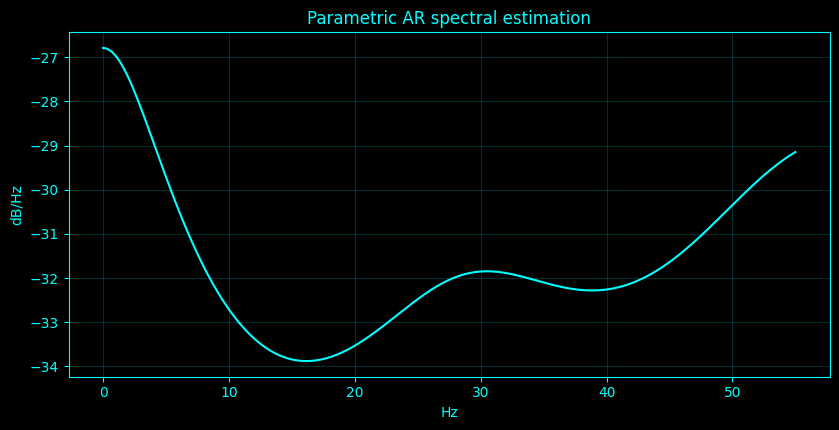

In [22]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _ar_yw(y, p):
    y = np.asarray(y, float) - np.mean(y)
    n = len(y)
    ac = np.array([np.dot(y[k:], y[:n - k]) / n for k in range(p + 1)])
    R = linalg.toeplitz(ac[:-1])
    a = np.linalg.solve(R + 1e-08 * np.eye(p), ac[1:])
    e = y[p:] - sum((a[k - 1] * y[p - k:n - k] for k in range(1, p + 1)))
    return (a, float(np.var(e)))

def _ar_spectrum(a, var, nf=256, fs=None):
    fs = _fs if fs is None else fs
    f = np.linspace(0, min(55, 0.49 * fs), nf)
    k = np.arange(1, len(a) + 1)
    den = np.abs(1 - np.sum(a[None, :] * np.exp(-2j * np.pi * f[:, None] * k[None, :] / fs), axis=1)) ** 2
    return (f, var / (fs * (den + EPS)))

# Method-specific calculation.
def _compute_method_12():
    idx = 12
    name = 'Parametric AR spectral estimation'
    __plot_spec = None
    y = X[:, 0]
    p = min(max(4, _SPEED['var_order']), 20)
    a, v = _ar_yw(y, p)
    f, ps = _ar_spectrum(a, v)
    __plot_spec = ('summary', 10 * np.log10(ps + EPS), name, f, 'Hz', 'dB/Hz')
    return ({'order': p, 'innovation_variance': v}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_12,_plot_spec=_compute_method_12()
print('Parametric AR spectral estimation')
if isinstance(result_12,dict):
    for _k,_v in result_12.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_12)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_12)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Parametric AR spectral estimation',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Parametric AR spectral estimation',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Parametric AR spectral estimation',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">13. Yule-Walker spectrum</h3>
<p>An AR(\(p\)) model is \(x_t=\sum_{k=1}^{p}a_kx_{t-k}+\varepsilon_t\). Its spectrum is \(S(f)=\sigma_\varepsilon^2/[f_s|1-\sum_ka_ke^{-i2\pi fk/f_s}|^2]\). Yule-Walker estimates \(a\) from the Toeplitz autocovariance equations.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance measures how two variables vary together around their means. Positive covariance means they tend to deviate in the same direction; negative covariance means opposite directions. Correlation rescales covariance by the variables' standard deviations, making it dimensionless and bounded between -1 and 1 for ordinary Pearson correlation. Both are linear summaries and can miss nonlinear dependence.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. An exponential describes multiplicative growth or decay. In dynamical systems, a positive exponent corresponds to growth with time and a negative exponent to decay. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Yule-Walker spectrum
  order: 5
  innovation_variance: 0.09190534273185876


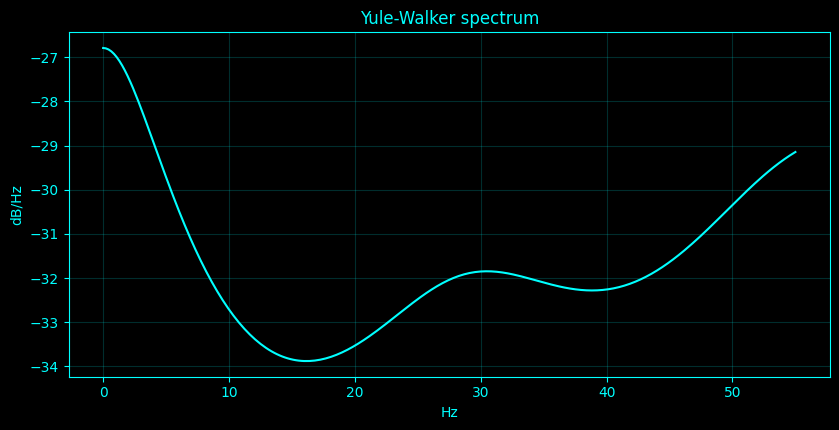

In [23]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _ar_yw(y, p):
    y = np.asarray(y, float) - np.mean(y)
    n = len(y)
    ac = np.array([np.dot(y[k:], y[:n - k]) / n for k in range(p + 1)])
    R = linalg.toeplitz(ac[:-1])
    a = np.linalg.solve(R + 1e-08 * np.eye(p), ac[1:])
    e = y[p:] - sum((a[k - 1] * y[p - k:n - k] for k in range(1, p + 1)))
    return (a, float(np.var(e)))

def _ar_spectrum(a, var, nf=256, fs=None):
    fs = _fs if fs is None else fs
    f = np.linspace(0, min(55, 0.49 * fs), nf)
    k = np.arange(1, len(a) + 1)
    den = np.abs(1 - np.sum(a[None, :] * np.exp(-2j * np.pi * f[:, None] * k[None, :] / fs), axis=1)) ** 2
    return (f, var / (fs * (den + EPS)))

# Method-specific calculation.
def _compute_method_13():
    idx = 13
    name = 'Yule-Walker spectrum'
    __plot_spec = None
    y = X[:, 0]
    p = min(max(4, _SPEED['var_order']), 20)
    a, v = _ar_yw(y, p)
    f, ps = _ar_spectrum(a, v)
    __plot_spec = ('summary', 10 * np.log10(ps + EPS), name, f, 'Hz', 'dB/Hz')
    return ({'order': p, 'innovation_variance': v}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_13,_plot_spec=_compute_method_13()
print('Yule-Walker spectrum')
if isinstance(result_13,dict):
    for _k,_v in result_13.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_13)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_13)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Yule-Walker spectrum',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Yule-Walker spectrum',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Yule-Walker spectrum',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">14. Burg spectrum</h3>
<p>Burg estimation recursively minimizes forward and backward prediction errors while enforcing a stable all-pole model. The resulting AR coefficients are inserted into the standard AR spectral formula.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Burg spectrum
  order: 5
  innovation_variance: 0.7723791523776429


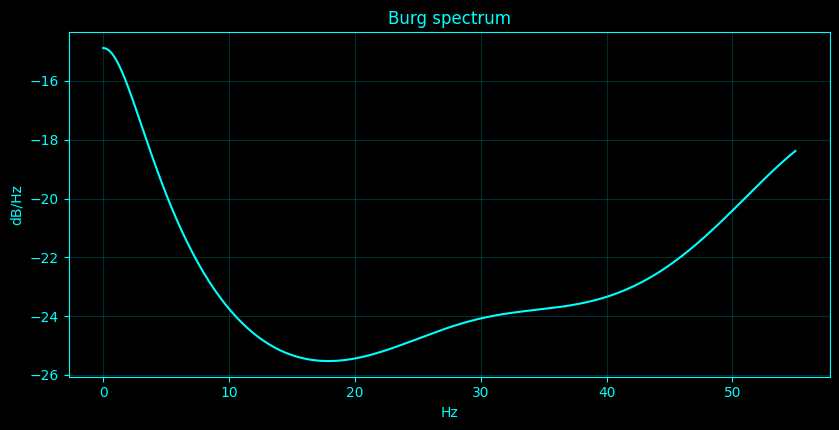

In [24]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _ar_burg(y, p):
    y = np.asarray(y, float) - np.mean(y)
    ef = y[1:].copy()
    eb = y[:-1].copy()
    a = np.zeros(p + 1)
    a[0] = 1.0
    E = np.dot(y, y) / len(y)
    for m in range(1, p + 1):
        num = -2 * np.dot(eb, ef)
        den = np.dot(ef, ef) + np.dot(eb, eb) + EPS
        k = num / den
        anew = a.copy()
        anew[m] = k
        for i in range(1, m):
            anew[i] = a[i] + k * a[m - i]
        a = anew
        ef_new = ef + k * eb
        eb = eb + k * ef
        ef = ef_new[1:]
        eb = eb[:-1]
        E *= max(1 - k * k, EPS)
    return (-a[1:], float(E))

def _ar_spectrum(a, var, nf=256, fs=None):
    fs = _fs if fs is None else fs
    f = np.linspace(0, min(55, 0.49 * fs), nf)
    k = np.arange(1, len(a) + 1)
    den = np.abs(1 - np.sum(a[None, :] * np.exp(-2j * np.pi * f[:, None] * k[None, :] / fs), axis=1)) ** 2
    return (f, var / (fs * (den + EPS)))

# Method-specific calculation.
def _compute_method_14():
    idx = 14
    name = 'Burg spectrum'
    __plot_spec = None
    y = X[:, 0]
    p = min(max(4, _SPEED['var_order']), 20)
    a, v = _ar_burg(y, p)
    f, ps = _ar_spectrum(a, v)
    __plot_spec = ('summary', 10 * np.log10(ps + EPS), name, f, 'Hz', 'dB/Hz')
    return ({'order': p, 'innovation_variance': v}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_14,_plot_spec=_compute_method_14()
print('Burg spectrum')
if isinstance(result_14,dict):
    for _k,_v in result_14.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_14)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_14)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Burg spectrum',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Burg spectrum',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Burg spectrum',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">15. Covariance-method AR spectrum</h3>
<p>The covariance AR method estimates coefficients by least squares on forward prediction equations without forcing the covariance matrix to be Toeplitz.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Regression fits a mathematical relationship between predictors and an outcome by choosing coefficients that minimize a loss, usually squared error. Ridge regression adds a penalty on large coefficients, which can stabilize estimates when predictors are correlated or data are limited. The coefficient of determination R² summarizes how much of the observed variance is explained by the fitted relationship within the analyzed data, but a high R² does not prove causality or guarantee good out-of-sample prediction.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Covariance-method AR spectrum
  order: 5
  innovation_variance: 0.022325793037763147
  peak_hz: 0.0


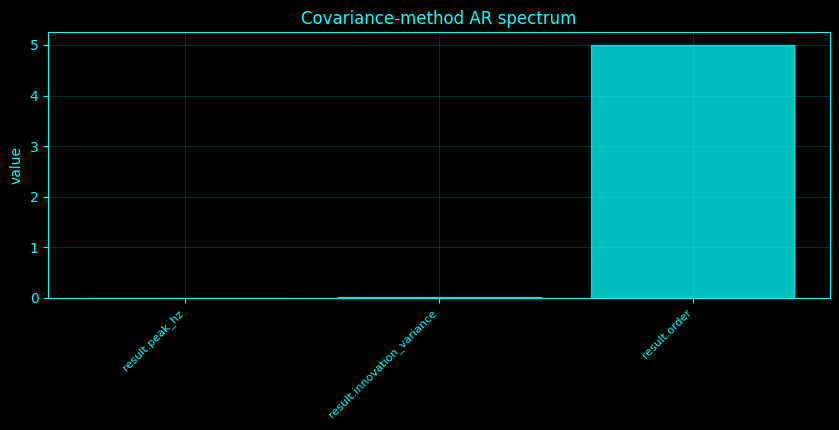

In [25]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _ar_spectrum(a, var, nf=256, fs=None):
    fs = _fs if fs is None else fs
    f = np.linspace(0, min(55, 0.49 * fs), nf)
    k = np.arange(1, len(a) + 1)
    den = np.abs(1 - np.sum(a[None, :] * np.exp(-2j * np.pi * f[:, None] * k[None, :] / fs), axis=1)) ** 2
    return (f, var / (fs * (den + EPS)))

# Method-specific calculation.
def _compute_method_15():
    idx = 15
    name = 'Covariance-method AR spectrum'
    __plot_spec = None
    y = X[:, 0]
    p = min(max(4, _SPEED['var_order']), 20)
    n = len(y)
    Y = y[p:]
    Z = np.column_stack([y[p - k:n - k] for k in range(1, p + 1)])
    a = np.linalg.lstsq(Z, Y, rcond=None)[0]
    v = float(np.var(Y - Z @ a))
    f, ps = _ar_spectrum(a, v)
    return ({'order': p, 'innovation_variance': v, 'peak_hz': float(f[np.argmax(ps)])}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_15,_plot_spec=_compute_method_15()
print('Covariance-method AR spectrum')
if isinstance(result_15,dict):
    for _k,_v in result_15.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_15)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_15)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Covariance-method AR spectrum',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Covariance-method AR spectrum',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Covariance-method AR spectrum',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">16. Modified covariance AR spectrum</h3>
<p>The modified-covariance method fits forward and backward prediction equations together, reducing directional bias in finite records while retaining an all-pole AR spectrum.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance measures how two variables vary together around their means. Positive covariance means they tend to deviate in the same direction; negative covariance means opposite directions. Correlation rescales covariance by the variables' standard deviations, making it dimensionless and bounded between -1 and 1 for ordinary Pearson correlation. Both are linear summaries and can miss nonlinear dependence.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Modified covariance AR spectrum
  order: 5
  innovation_variance: 0.16474219103098411
  peak_hz: 0.0


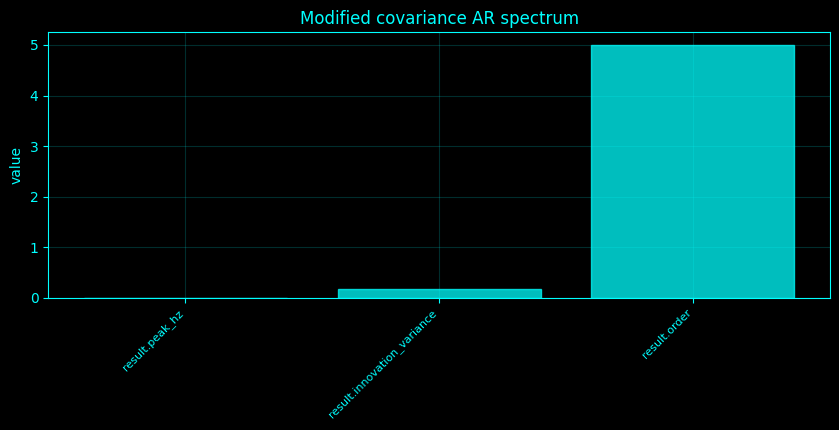

In [26]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _ar_spectrum(a, var, nf=256, fs=None):
    fs = _fs if fs is None else fs
    f = np.linspace(0, min(55, 0.49 * fs), nf)
    k = np.arange(1, len(a) + 1)
    den = np.abs(1 - np.sum(a[None, :] * np.exp(-2j * np.pi * f[:, None] * k[None, :] / fs), axis=1)) ** 2
    return (f, var / (fs * (den + EPS)))

# Method-specific calculation.
def _compute_method_16():
    idx = 16
    name = 'Modified covariance AR spectrum'
    __plot_spec = None
    y = X[:, 0]
    p = min(max(4, _SPEED['var_order']), 20)
    n = len(y)
    Y = y[p:]
    Z = np.column_stack([y[p - k:n - k] for k in range(1, p + 1)])
    yr = y[::-1]
    Yr = yr[p:]
    Zr = np.column_stack([yr[p - k:n - k] for k in range(1, p + 1)])
    Y = np.r_[Y, Yr]
    Z = np.vstack([Z, Zr])
    a = np.linalg.lstsq(Z, Y, rcond=None)[0]
    v = float(np.var(Y - Z @ a))
    f, ps = _ar_spectrum(a, v)
    return ({'order': p, 'innovation_variance': v, 'peak_hz': float(f[np.argmax(ps)])}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_16,_plot_spec=_compute_method_16()
print('Modified covariance AR spectrum')
if isinstance(result_16,dict):
    for _k,_v in result_16.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_16)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_16)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Modified covariance AR spectrum',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Modified covariance AR spectrum',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Modified covariance AR spectrum',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">17. AR order sweep</h3>
<p>An AR order sweep fits multiple orders \(p\) and compares innovation variance and spectral structure. Increasing \(p\) improves flexibility but also increases estimator variance.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


AR order sweep
  orders: array(15,), mean=8
  innovation_variance: array(15,), mean=0.0941773


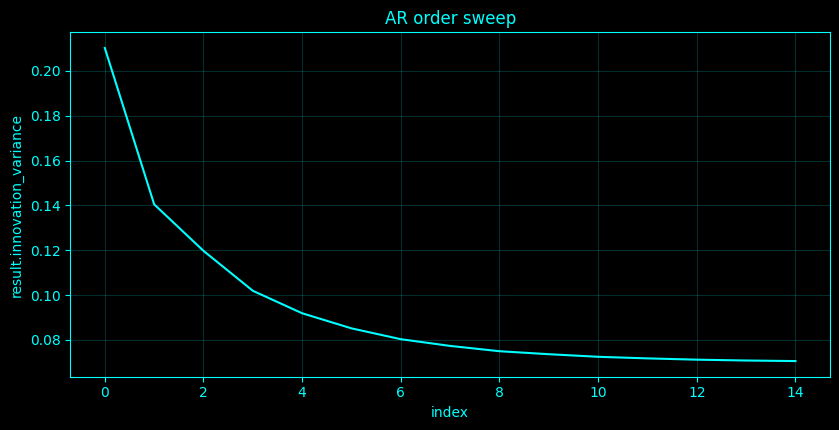

In [27]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _ar_yw(y, p):
    y = np.asarray(y, float) - np.mean(y)
    n = len(y)
    ac = np.array([np.dot(y[k:], y[:n - k]) / n for k in range(p + 1)])
    R = linalg.toeplitz(ac[:-1])
    a = np.linalg.solve(R + 1e-08 * np.eye(p), ac[1:])
    e = y[p:] - sum((a[k - 1] * y[p - k:n - k] for k in range(1, p + 1)))
    return (a, float(np.var(e)))

def _ar_order_table(y, maxp=None):
    maxp = int(maxp or min(20, _SPEED['var_order'] * 2))
    rows = []
    n = len(y)
    for p in range(1, maxp + 1):
        a, v = _ar_yw(y, p)
        k = p
        aic = n * np.log(v + EPS) + 2 * k
        bic = n * np.log(v + EPS) + k * np.log(n)
        rows.append((p, v, aic, bic))
    return np.asarray(rows)

# Method-specific calculation.
def _compute_method_17():
    idx = 17
    name = 'AR order sweep'
    __plot_spec = None
    y = X[:, 0]
    p = min(max(4, _SPEED['var_order']), 20)
    T = _ar_order_table(y, min(24, max(10, _SPEED['var_order'] * 3)))
    return ({'orders': T[:, 0].astype(int).tolist(), 'innovation_variance': T[:, 1].tolist()}, locals().get('__plot_spec', None))
    return ({'AIC_order': int(T[np.argmin(T[:, 2]), 0]), 'BIC_order': int(T[np.argmin(T[:, 3]), 0])}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_17,_plot_spec=_compute_method_17()
print('AR order sweep')
if isinstance(result_17,dict):
    for _k,_v in result_17.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_17)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_17)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'AR order sweep',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'AR order sweep',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('AR order sweep',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">18. AIC/BIC AR spectral order comparison</h3>
<p>AR model-order criteria penalize likelihood by complexity. For Gaussian residual variance \(\hat\sigma^2\), \(\mathrm{AIC}=N\log\hat\sigma^2+2p\) and \(\mathrm{BIC}=N\log\hat\sigma^2+p\log N\).</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


AIC/BIC AR spectral order comparison
  AIC_order: 15
  BIC_order: 15


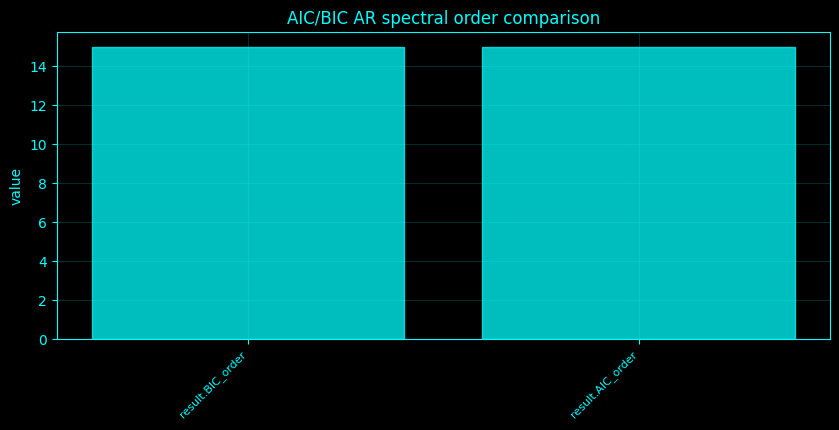

In [18]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _ar_yw(y, p):
    y = np.asarray(y, float) - np.mean(y)
    n = len(y)
    ac = np.array([np.dot(y[k:], y[:n - k]) / n for k in range(p + 1)])
    R = linalg.toeplitz(ac[:-1])
    a = np.linalg.solve(R + 1e-08 * np.eye(p), ac[1:])
    e = y[p:] - sum((a[k - 1] * y[p - k:n - k] for k in range(1, p + 1)))
    return (a, float(np.var(e)))

def _ar_order_table(y, maxp=None):
    maxp = int(maxp or min(20, _SPEED['var_order'] * 2))
    rows = []
    n = len(y)
    for p in range(1, maxp + 1):
        a, v = _ar_yw(y, p)
        k = p
        aic = n * np.log(v + EPS) + 2 * k
        bic = n * np.log(v + EPS) + k * np.log(n)
        rows.append((p, v, aic, bic))
    return np.asarray(rows)

# Method-specific calculation.
def _compute_method_18():
    idx = 18
    name = 'AIC/BIC AR spectral order comparison'
    __plot_spec = None
    y = X[:, 0]
    p = min(max(4, _SPEED['var_order']), 20)
    T = _ar_order_table(y, min(24, max(10, _SPEED['var_order'] * 3)))
    return ({'AIC_order': int(T[np.argmin(T[:, 2]), 0]), 'BIC_order': int(T[np.argmin(T[:, 3]), 0])}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_18,_plot_spec=_compute_method_18()
print('AIC/BIC AR spectral order comparison')
if isinstance(result_18,dict):
    for _k,_v in result_18.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_18)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_18)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'AIC/BIC AR spectral order comparison',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'AIC/BIC AR spectral order comparison',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('AIC/BIC AR spectral order comparison',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">19. Time-varying AR spectrum</h3>
<p>Time-varying AR analysis fits the same AR model in successive windows, so \(a_k(t)\) and the derived spectrum \(S(f,t)\) can evolve across the record.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


Time-varying AR spectrum
  peak_trajectory_hz: array(12,), mean=4.58333


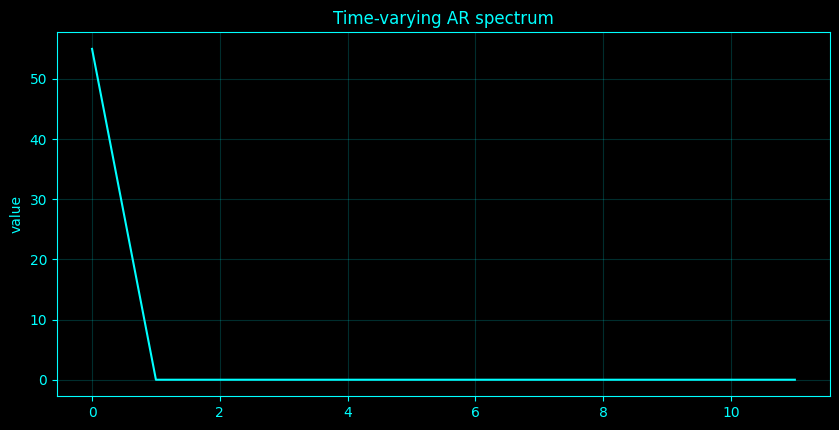

In [19]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _ar_yw(y, p):
    y = np.asarray(y, float) - np.mean(y)
    n = len(y)
    ac = np.array([np.dot(y[k:], y[:n - k]) / n for k in range(p + 1)])
    R = linalg.toeplitz(ac[:-1])
    a = np.linalg.solve(R + 1e-08 * np.eye(p), ac[1:])
    e = y[p:] - sum((a[k - 1] * y[p - k:n - k] for k in range(1, p + 1)))
    return (a, float(np.var(e)))

def _ar_spectrum(a, var, nf=256, fs=None):
    fs = _fs if fs is None else fs
    f = np.linspace(0, min(55, 0.49 * fs), nf)
    k = np.arange(1, len(a) + 1)
    den = np.abs(1 - np.sum(a[None, :] * np.exp(-2j * np.pi * f[:, None] * k[None, :] / fs), axis=1)) ** 2
    return (f, var / (fs * (den + EPS)))

# Method-specific calculation.
def _compute_method_19():
    idx = 19
    name = 'Time-varying AR spectrum'
    __plot_spec = None
    y = X[:, 0]
    p = min(max(4, _SPEED['var_order']), 20)
    nwin = min(12, max(4, N // max(int(_fs * 2), 1)))
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    peaks = []
    for a0, b0 in zip(edges[:-1], edges[1:]):
        yy = y[a0:b0]
        pp = min(p, max(2, len(yy) // 10))
        aa, v = _ar_yw(yy, pp)
        ff, sp = _ar_spectrum(aa, v)
        peaks.append(float(ff[np.argmax(sp)]))
    __plot_spec = ('summary', peaks, name, None, '', 'value')
    return ({'peak_trajectory_hz': peaks}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_19,_plot_spec=_compute_method_19()
print('Time-varying AR spectrum')
if isinstance(result_19,dict):
    for _k,_v in result_19.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_19)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_19)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Time-varying AR spectrum',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Time-varying AR spectrum',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Time-varying AR spectrum',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">20. Kalman adaptive AR spectrum</h3>
<p>Adaptive/Kalman AR modeling treats the coefficient vector as a slowly varying state. Recursive least squares with forgetting factor \(\lambda\) is the corresponding linear-Gaussian update for a random-walk coefficient model.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Regression fits a mathematical relationship between predictors and an outcome by choosing coefficients that minimize a loss, usually squared error. Ridge regression adds a penalty on large coefficients, which can stabilize estimates when predictors are correlated or data are limited. The coefficient of determination R² summarizes how much of the observed variance is explained by the fitted relationship within the analyzed data, but a high R² does not prove causality or guarantee good out-of-sample prediction.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol λ (lambda) is commonly used for an eigenvalue, Lyapunov exponent, regularization parameter, or rate; its exact meaning is set by the surrounding definition.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Kalman adaptive AR spectrum
  RLS_forgetting_factor: 0.995
  adaptive_peak_hz: array(40,), mean=0


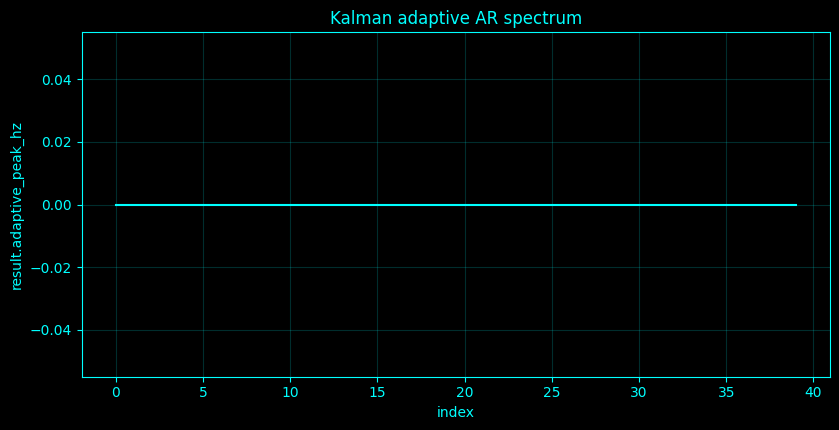

In [20]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _ar_spectrum(a, var, nf=256, fs=None):
    fs = _fs if fs is None else fs
    f = np.linspace(0, min(55, 0.49 * fs), nf)
    k = np.arange(1, len(a) + 1)
    den = np.abs(1 - np.sum(a[None, :] * np.exp(-2j * np.pi * f[:, None] * k[None, :] / fs), axis=1)) ** 2
    return (f, var / (fs * (den + EPS)))

# Method-specific calculation.
def _compute_method_20():
    idx = 20
    name = 'Kalman adaptive AR spectrum'
    __plot_spec = None
    y = X[:, 0]
    p = min(max(4, _SPEED['var_order']), 20)
    p0 = min(p, 8)
    theta = np.zeros(p0)
    Pk = np.eye(p0) * 100.0
    lam = 0.995
    peaks = []
    step = max(p0, (N - p0) // 40)
    for t0 in range(p0, N):
        phi = y[t0 - np.arange(1, p0 + 1)]
        den = lam + phi @ Pk @ phi
        K = Pk @ phi / den
        err = y[t0] - theta @ phi
        theta = theta + K * err
        Pk = (Pk - np.outer(K, phi) @ Pk) / lam
        if t0 % step == 0:
            ff, sp = _ar_spectrum(theta, max(err * err, 0.0001))
            peaks.append(float(ff[np.argmax(sp)]))
    return ({'RLS_forgetting_factor': lam, 'adaptive_peak_hz': peaks}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_20,_plot_spec=_compute_method_20()
print('Kalman adaptive AR spectrum')
if isinstance(result_20,dict):
    for _k,_v in result_20.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_20)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_20)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Kalman adaptive AR spectrum',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Kalman adaptive AR spectrum',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Kalman adaptive AR spectrum',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">21. MVAR spectral analysis</h3>
<p>For \(x_t=\sum_{k=1}^{p}A_kx_{t-k}+\varepsilon_t\), define \(A(f)=I-\sum_kA_ke^{-i2\pi fk/f_s}\), \(H(f)=A(f)^{-1}\), and \(S(f)=H(f)\Sigma H(f)^\ast\). MVAR spectral analysis studies this full matrix spectrum.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. An exponential describes multiplicative growth or decay. In dynamical systems, a positive exponent corresponds to growth with time and a negative exponent to decay. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [21]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _fit_var(order=None):
    if 'var' in SPEC_CACHE:
        return SPEC_CACHE['var']
    p = int(order or _SPEED['var_order'])
    Y = X[p:]
    Z = np.hstack([X[p - k:N - k] for k in range(1, p + 1)])
    B = np.linalg.solve(Z.T @ Z + 1e-05 * np.eye(Z.shape[1]), Z.T @ Y)
    A = np.stack([B[k * C:(k + 1) * C, :].T for k in range(p)], axis=0)
    E = Y - Z @ B
    Sigma = np.cov(E, rowvar=False) + 1e-08 * np.eye(C)
    SPEC_CACHE['var'] = (A, Sigma, E, Z)
    return SPEC_CACHE['var']

def _var_frequency(nf=64):
    key = ('varfreq', nf)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    Acoef, Sigma, E, Z = _fit_var()
    p = Acoef.shape[0]
    f = np.linspace(1, min(45, 0.45 * _fs), nf)
    Af = np.empty((nf, C, C), complex)
    H = np.empty_like(Af)
    S = np.empty_like(Af)
    I = np.eye(C)
    for q, ff in enumerate(f):
        M = I.astype(complex)
        for k in range(1, p + 1):
            M -= Acoef[k - 1] * np.exp(-2j * np.pi * ff * k / _fs)
        Af[q] = M
        H[q] = np.linalg.inv(M)
        S[q] = H[q] @ Sigma @ H[q].conj().T
    SPEC_CACHE[key] = (f, Af, H, S, Sigma)
    return SPEC_CACHE[key]

def _directed_measures():
    if 'directed' in SPEC_CACHE:
        return SPEC_CACHE['directed']
    f, A, H, S, Sigma = _var_frequency()
    sig = np.maximum(np.diag(Sigma).real, EPS)
    dtf = np.abs(H) / np.sqrt(np.sum(np.abs(H) ** 2, axis=2, keepdims=True) + EPS)
    pdc = np.abs(A) / np.sqrt(np.sum(np.abs(A) ** 2, axis=1, keepdims=True) + EPS)
    num = np.abs(A) / np.sqrt(sig[None, :, None])
    den = np.sqrt(np.sum(np.abs(A) ** 2 / sig[None, :, None], axis=1, keepdims=True) + EPS)
    gpdc = num / den
    L = np.linalg.cholesky(Sigma)
    Hw = H @ L
    Sw = Hw @ Hw.conj().transpose(0, 2, 1)
    Fgc = np.zeros((len(f), C, C))
    for i in range(C):
        sii = np.maximum(Sw[:, i, i].real, EPS)
        for j in range(C):
            if i == j:
                continue
            intrinsic = np.maximum(sii - np.abs(Hw[:, i, j]) ** 2, EPS)
            Fgc[:, i, j] = np.maximum(0, np.log(sii / intrinsic))
    pc = np.zeros_like(np.abs(S), float)
    for q in range(len(f)):
        P = np.linalg.pinv(S[q])
        d = np.sqrt(np.maximum(np.outer(np.diag(P).real, np.diag(P).real), EPS))
        pc[q] = np.abs(P) / d
    ddtf = dtf * pc
    Acoef, Sigma0, E, Z = _fit_var()
    p = Acoef.shape[0]
    Rinv = np.linalg.pinv(Z.T @ Z / max(len(Z), 1) + 1e-08 * np.eye(Z.shape[1]))
    rpdc = np.zeros((len(f), C, C))
    Nfit = len(Z)
    for qi, ff in enumerate(f):
        cs = np.cos(2 * np.pi * ff * np.arange(1, p + 1) / _fs)
        sn = np.sin(2 * np.pi * ff * np.arange(1, p + 1) / _fs)
        for i in range(C):
            for j in range(C):
                if i == j:
                    continue
                idx = np.array([k * C + j for k in range(p)])
                Rij = Rinv[np.ix_(idx, idx)] * Sigma0[i, i] / max(Nfit, 1)
                V = np.array([[cs @ Rij @ cs, cs @ Rij @ sn], [sn @ Rij @ cs, sn @ Rij @ sn]]) + 1e-12 * np.eye(2)
                z = np.array([A[qi, i, j].real, A[qi, i, j].imag])
                rpdc[qi, i, j] = float(z @ np.linalg.pinv(V) @ z)
    out = dict(f=f, A=A, H=H, S=S, Sigma=Sigma, dtf=dtf, pdc=pdc, gpdc=gpdc, rpdc=rpdc, gc=Fgc, ddtf=ddtf, pc=pc)
    SPEC_CACHE['directed'] = out
    return out

# Method-specific calculation.
def _compute_method_21():
    idx = 21
    name = 'MVAR spectral analysis'
    __plot_spec = None
    D = _directed_measures()
    f = D['f']
    m = (f >= 8) & (f < 13)
    tr = np.real(np.trace(D['S'], axis1=1, axis2=2))
    __plot_spec = ('summary', tr, name, f, 'Hz', 'trace S(f)')
    return ({'peak_hz': float(f[np.argmax(tr)])}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_21,_plot_spec=_compute_method_21()
print('MVAR spectral analysis')
if isinstance(result_21,dict):
    for _k,_v in result_21.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_21)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_21)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'MVAR spectral analysis',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'MVAR spectral analysis',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('MVAR spectral analysis',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


MVAR spectral analysis
  peak_hz: 1.0


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">22. MVAR coherence</h3>
<p>MVAR coherence is derived from the model spectral matrix: \(C_{ij}(f)=|S_{ij}(f)|^2/[S_{ii}(f)S_{jj}(f)]\).</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Coherence is a frequency-specific measure of linear association between two signals. It compares the magnitude of their cross-spectrum with the power spectra of the individual signals. Values near one mean that a stable linear relationship at that frequency explains a large fraction of the spectral activity, while values near zero indicate weak consistency. High coherence can arise from common input, volume conduction, or shared reference effects, so it should not automatically be interpreted as direct connectivity.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [22]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _fit_var(order=None):
    if 'var' in SPEC_CACHE:
        return SPEC_CACHE['var']
    p = int(order or _SPEED['var_order'])
    Y = X[p:]
    Z = np.hstack([X[p - k:N - k] for k in range(1, p + 1)])
    B = np.linalg.solve(Z.T @ Z + 1e-05 * np.eye(Z.shape[1]), Z.T @ Y)
    A = np.stack([B[k * C:(k + 1) * C, :].T for k in range(p)], axis=0)
    E = Y - Z @ B
    Sigma = np.cov(E, rowvar=False) + 1e-08 * np.eye(C)
    SPEC_CACHE['var'] = (A, Sigma, E, Z)
    return SPEC_CACHE['var']

def _var_frequency(nf=64):
    key = ('varfreq', nf)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    Acoef, Sigma, E, Z = _fit_var()
    p = Acoef.shape[0]
    f = np.linspace(1, min(45, 0.45 * _fs), nf)
    Af = np.empty((nf, C, C), complex)
    H = np.empty_like(Af)
    S = np.empty_like(Af)
    I = np.eye(C)
    for q, ff in enumerate(f):
        M = I.astype(complex)
        for k in range(1, p + 1):
            M -= Acoef[k - 1] * np.exp(-2j * np.pi * ff * k / _fs)
        Af[q] = M
        H[q] = np.linalg.inv(M)
        S[q] = H[q] @ Sigma @ H[q].conj().T
    SPEC_CACHE[key] = (f, Af, H, S, Sigma)
    return SPEC_CACHE[key]

def _directed_measures():
    if 'directed' in SPEC_CACHE:
        return SPEC_CACHE['directed']
    f, A, H, S, Sigma = _var_frequency()
    sig = np.maximum(np.diag(Sigma).real, EPS)
    dtf = np.abs(H) / np.sqrt(np.sum(np.abs(H) ** 2, axis=2, keepdims=True) + EPS)
    pdc = np.abs(A) / np.sqrt(np.sum(np.abs(A) ** 2, axis=1, keepdims=True) + EPS)
    num = np.abs(A) / np.sqrt(sig[None, :, None])
    den = np.sqrt(np.sum(np.abs(A) ** 2 / sig[None, :, None], axis=1, keepdims=True) + EPS)
    gpdc = num / den
    L = np.linalg.cholesky(Sigma)
    Hw = H @ L
    Sw = Hw @ Hw.conj().transpose(0, 2, 1)
    Fgc = np.zeros((len(f), C, C))
    for i in range(C):
        sii = np.maximum(Sw[:, i, i].real, EPS)
        for j in range(C):
            if i == j:
                continue
            intrinsic = np.maximum(sii - np.abs(Hw[:, i, j]) ** 2, EPS)
            Fgc[:, i, j] = np.maximum(0, np.log(sii / intrinsic))
    pc = np.zeros_like(np.abs(S), float)
    for q in range(len(f)):
        P = np.linalg.pinv(S[q])
        d = np.sqrt(np.maximum(np.outer(np.diag(P).real, np.diag(P).real), EPS))
        pc[q] = np.abs(P) / d
    ddtf = dtf * pc
    Acoef, Sigma0, E, Z = _fit_var()
    p = Acoef.shape[0]
    Rinv = np.linalg.pinv(Z.T @ Z / max(len(Z), 1) + 1e-08 * np.eye(Z.shape[1]))
    rpdc = np.zeros((len(f), C, C))
    Nfit = len(Z)
    for qi, ff in enumerate(f):
        cs = np.cos(2 * np.pi * ff * np.arange(1, p + 1) / _fs)
        sn = np.sin(2 * np.pi * ff * np.arange(1, p + 1) / _fs)
        for i in range(C):
            for j in range(C):
                if i == j:
                    continue
                idx = np.array([k * C + j for k in range(p)])
                Rij = Rinv[np.ix_(idx, idx)] * Sigma0[i, i] / max(Nfit, 1)
                V = np.array([[cs @ Rij @ cs, cs @ Rij @ sn], [sn @ Rij @ cs, sn @ Rij @ sn]]) + 1e-12 * np.eye(2)
                z = np.array([A[qi, i, j].real, A[qi, i, j].imag])
                rpdc[qi, i, j] = float(z @ np.linalg.pinv(V) @ z)
    out = dict(f=f, A=A, H=H, S=S, Sigma=Sigma, dtf=dtf, pdc=pdc, gpdc=gpdc, rpdc=rpdc, gc=Fgc, ddtf=ddtf, pc=pc)
    SPEC_CACHE['directed'] = out
    return out

# Method-specific calculation.
def _compute_method_22():
    idx = 22
    name = 'MVAR coherence'
    __plot_spec = None
    D = _directed_measures()
    f = D['f']
    m = (f >= 8) & (f < 13)
    S = D['S']
    coh = np.abs(S[:, 0, 1]) ** 2 / (np.real(S[:, 0, 0]) * np.real(S[:, 1, 1]) + EPS)
    __plot_spec = ('summary', coh, name, f, 'Hz', 'MVAR coherence')
    return ({'alpha': float(np.mean(coh[m]))}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_22,_plot_spec=_compute_method_22()
print('MVAR coherence')
if isinstance(result_22,dict):
    for _k,_v in result_22.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_22)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_22)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'MVAR coherence',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'MVAR coherence',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('MVAR coherence',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


MVAR coherence
  alpha: 0.8991203126513632


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">23. Directed transfer function</h3>
<p>Directed transfer function is \(\mathrm{DTF}_{ij}=|H_{ij}|/\sqrt{\sum_k|H_{ik}|^2}\), quantifying transfer from source \(j\) to target \(i\).</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [23]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _fit_var(order=None):
    if 'var' in SPEC_CACHE:
        return SPEC_CACHE['var']
    p = int(order or _SPEED['var_order'])
    Y = X[p:]
    Z = np.hstack([X[p - k:N - k] for k in range(1, p + 1)])
    B = np.linalg.solve(Z.T @ Z + 1e-05 * np.eye(Z.shape[1]), Z.T @ Y)
    A = np.stack([B[k * C:(k + 1) * C, :].T for k in range(p)], axis=0)
    E = Y - Z @ B
    Sigma = np.cov(E, rowvar=False) + 1e-08 * np.eye(C)
    SPEC_CACHE['var'] = (A, Sigma, E, Z)
    return SPEC_CACHE['var']

def _var_frequency(nf=64):
    key = ('varfreq', nf)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    Acoef, Sigma, E, Z = _fit_var()
    p = Acoef.shape[0]
    f = np.linspace(1, min(45, 0.45 * _fs), nf)
    Af = np.empty((nf, C, C), complex)
    H = np.empty_like(Af)
    S = np.empty_like(Af)
    I = np.eye(C)
    for q, ff in enumerate(f):
        M = I.astype(complex)
        for k in range(1, p + 1):
            M -= Acoef[k - 1] * np.exp(-2j * np.pi * ff * k / _fs)
        Af[q] = M
        H[q] = np.linalg.inv(M)
        S[q] = H[q] @ Sigma @ H[q].conj().T
    SPEC_CACHE[key] = (f, Af, H, S, Sigma)
    return SPEC_CACHE[key]

def _directed_measures():
    if 'directed' in SPEC_CACHE:
        return SPEC_CACHE['directed']
    f, A, H, S, Sigma = _var_frequency()
    sig = np.maximum(np.diag(Sigma).real, EPS)
    dtf = np.abs(H) / np.sqrt(np.sum(np.abs(H) ** 2, axis=2, keepdims=True) + EPS)
    pdc = np.abs(A) / np.sqrt(np.sum(np.abs(A) ** 2, axis=1, keepdims=True) + EPS)
    num = np.abs(A) / np.sqrt(sig[None, :, None])
    den = np.sqrt(np.sum(np.abs(A) ** 2 / sig[None, :, None], axis=1, keepdims=True) + EPS)
    gpdc = num / den
    L = np.linalg.cholesky(Sigma)
    Hw = H @ L
    Sw = Hw @ Hw.conj().transpose(0, 2, 1)
    Fgc = np.zeros((len(f), C, C))
    for i in range(C):
        sii = np.maximum(Sw[:, i, i].real, EPS)
        for j in range(C):
            if i == j:
                continue
            intrinsic = np.maximum(sii - np.abs(Hw[:, i, j]) ** 2, EPS)
            Fgc[:, i, j] = np.maximum(0, np.log(sii / intrinsic))
    pc = np.zeros_like(np.abs(S), float)
    for q in range(len(f)):
        P = np.linalg.pinv(S[q])
        d = np.sqrt(np.maximum(np.outer(np.diag(P).real, np.diag(P).real), EPS))
        pc[q] = np.abs(P) / d
    ddtf = dtf * pc
    Acoef, Sigma0, E, Z = _fit_var()
    p = Acoef.shape[0]
    Rinv = np.linalg.pinv(Z.T @ Z / max(len(Z), 1) + 1e-08 * np.eye(Z.shape[1]))
    rpdc = np.zeros((len(f), C, C))
    Nfit = len(Z)
    for qi, ff in enumerate(f):
        cs = np.cos(2 * np.pi * ff * np.arange(1, p + 1) / _fs)
        sn = np.sin(2 * np.pi * ff * np.arange(1, p + 1) / _fs)
        for i in range(C):
            for j in range(C):
                if i == j:
                    continue
                idx = np.array([k * C + j for k in range(p)])
                Rij = Rinv[np.ix_(idx, idx)] * Sigma0[i, i] / max(Nfit, 1)
                V = np.array([[cs @ Rij @ cs, cs @ Rij @ sn], [sn @ Rij @ cs, sn @ Rij @ sn]]) + 1e-12 * np.eye(2)
                z = np.array([A[qi, i, j].real, A[qi, i, j].imag])
                rpdc[qi, i, j] = float(z @ np.linalg.pinv(V) @ z)
    out = dict(f=f, A=A, H=H, S=S, Sigma=Sigma, dtf=dtf, pdc=pdc, gpdc=gpdc, rpdc=rpdc, gc=Fgc, ddtf=ddtf, pc=pc)
    SPEC_CACHE['directed'] = out
    return out

# Method-specific calculation.
def _compute_method_23():
    idx = 23
    name = 'Directed transfer function'
    __plot_spec = None
    D = _directed_measures()
    f = D['f']
    m = (f >= 8) & (f < 13)
    M = D['dtf']
    return ({'max_alpha_DTF': float(np.max(np.mean(M[m], axis=0) - np.eye(C)))}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_23,_plot_spec=_compute_method_23()
print('Directed transfer function')
if isinstance(result_23,dict):
    for _k,_v in result_23.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_23)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_23)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Directed transfer function',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Directed transfer function',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Directed transfer function',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Directed transfer function
  max_alpha_DTF: 0.6475506826866955


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">24. Partial directed coherence</h3>
<p>Partial directed coherence is \(\mathrm{PDC}_{ij}=|A_{ij}|/\sqrt{\sum_k|A_{kj}|^2}\), a sender-column normalization of the Fourier AR matrix.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Coherence is a frequency-specific measure of linear association between two signals. It compares the magnitude of their cross-spectrum with the power spectra of the individual signals. Values near one mean that a stable linear relationship at that frequency explains a large fraction of the spectral activity, while values near zero indicate weak consistency. High coherence can arise from common input, volume conduction, or shared reference effects, so it should not automatically be interpreted as direct connectivity.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [24]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _fit_var(order=None):
    if 'var' in SPEC_CACHE:
        return SPEC_CACHE['var']
    p = int(order or _SPEED['var_order'])
    Y = X[p:]
    Z = np.hstack([X[p - k:N - k] for k in range(1, p + 1)])
    B = np.linalg.solve(Z.T @ Z + 1e-05 * np.eye(Z.shape[1]), Z.T @ Y)
    A = np.stack([B[k * C:(k + 1) * C, :].T for k in range(p)], axis=0)
    E = Y - Z @ B
    Sigma = np.cov(E, rowvar=False) + 1e-08 * np.eye(C)
    SPEC_CACHE['var'] = (A, Sigma, E, Z)
    return SPEC_CACHE['var']

def _var_frequency(nf=64):
    key = ('varfreq', nf)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    Acoef, Sigma, E, Z = _fit_var()
    p = Acoef.shape[0]
    f = np.linspace(1, min(45, 0.45 * _fs), nf)
    Af = np.empty((nf, C, C), complex)
    H = np.empty_like(Af)
    S = np.empty_like(Af)
    I = np.eye(C)
    for q, ff in enumerate(f):
        M = I.astype(complex)
        for k in range(1, p + 1):
            M -= Acoef[k - 1] * np.exp(-2j * np.pi * ff * k / _fs)
        Af[q] = M
        H[q] = np.linalg.inv(M)
        S[q] = H[q] @ Sigma @ H[q].conj().T
    SPEC_CACHE[key] = (f, Af, H, S, Sigma)
    return SPEC_CACHE[key]

def _directed_measures():
    if 'directed' in SPEC_CACHE:
        return SPEC_CACHE['directed']
    f, A, H, S, Sigma = _var_frequency()
    sig = np.maximum(np.diag(Sigma).real, EPS)
    dtf = np.abs(H) / np.sqrt(np.sum(np.abs(H) ** 2, axis=2, keepdims=True) + EPS)
    pdc = np.abs(A) / np.sqrt(np.sum(np.abs(A) ** 2, axis=1, keepdims=True) + EPS)
    num = np.abs(A) / np.sqrt(sig[None, :, None])
    den = np.sqrt(np.sum(np.abs(A) ** 2 / sig[None, :, None], axis=1, keepdims=True) + EPS)
    gpdc = num / den
    L = np.linalg.cholesky(Sigma)
    Hw = H @ L
    Sw = Hw @ Hw.conj().transpose(0, 2, 1)
    Fgc = np.zeros((len(f), C, C))
    for i in range(C):
        sii = np.maximum(Sw[:, i, i].real, EPS)
        for j in range(C):
            if i == j:
                continue
            intrinsic = np.maximum(sii - np.abs(Hw[:, i, j]) ** 2, EPS)
            Fgc[:, i, j] = np.maximum(0, np.log(sii / intrinsic))
    pc = np.zeros_like(np.abs(S), float)
    for q in range(len(f)):
        P = np.linalg.pinv(S[q])
        d = np.sqrt(np.maximum(np.outer(np.diag(P).real, np.diag(P).real), EPS))
        pc[q] = np.abs(P) / d
    ddtf = dtf * pc
    Acoef, Sigma0, E, Z = _fit_var()
    p = Acoef.shape[0]
    Rinv = np.linalg.pinv(Z.T @ Z / max(len(Z), 1) + 1e-08 * np.eye(Z.shape[1]))
    rpdc = np.zeros((len(f), C, C))
    Nfit = len(Z)
    for qi, ff in enumerate(f):
        cs = np.cos(2 * np.pi * ff * np.arange(1, p + 1) / _fs)
        sn = np.sin(2 * np.pi * ff * np.arange(1, p + 1) / _fs)
        for i in range(C):
            for j in range(C):
                if i == j:
                    continue
                idx = np.array([k * C + j for k in range(p)])
                Rij = Rinv[np.ix_(idx, idx)] * Sigma0[i, i] / max(Nfit, 1)
                V = np.array([[cs @ Rij @ cs, cs @ Rij @ sn], [sn @ Rij @ cs, sn @ Rij @ sn]]) + 1e-12 * np.eye(2)
                z = np.array([A[qi, i, j].real, A[qi, i, j].imag])
                rpdc[qi, i, j] = float(z @ np.linalg.pinv(V) @ z)
    out = dict(f=f, A=A, H=H, S=S, Sigma=Sigma, dtf=dtf, pdc=pdc, gpdc=gpdc, rpdc=rpdc, gc=Fgc, ddtf=ddtf, pc=pc)
    SPEC_CACHE['directed'] = out
    return out

# Method-specific calculation.
def _compute_method_24():
    idx = 24
    name = 'Partial directed coherence'
    __plot_spec = None
    D = _directed_measures()
    f = D['f']
    m = (f >= 8) & (f < 13)
    M = D['pdc']
    return ({'max_alpha_PDC': float(np.max(np.mean(M[m], axis=0) - np.eye(C)))}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_24,_plot_spec=_compute_method_24()
print('Partial directed coherence')
if isinstance(result_24,dict):
    for _k,_v in result_24.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_24)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_24)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Partial directed coherence',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Partial directed coherence',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Partial directed coherence',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Partial directed coherence
  max_alpha_PDC: 0.5464343659046756


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">25. Generalized partial directed coherence</h3>
<p>Generalized PDC incorporates innovation-scale normalization, \(|A_{ij}|/\sigma_i\,[\sum_k|A_{kj}|^2/\sigma_k^2]^{-1/2}\), improving scale invariance.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Coherence is a frequency-specific measure of linear association between two signals. It compares the magnitude of their cross-spectrum with the power spectra of the individual signals. Values near one mean that a stable linear relationship at that frequency explains a large fraction of the spectral activity, while values near zero indicate weak consistency. High coherence can arise from common input, volume conduction, or shared reference effects, so it should not automatically be interpreted as direct connectivity.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [25]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _fit_var(order=None):
    if 'var' in SPEC_CACHE:
        return SPEC_CACHE['var']
    p = int(order or _SPEED['var_order'])
    Y = X[p:]
    Z = np.hstack([X[p - k:N - k] for k in range(1, p + 1)])
    B = np.linalg.solve(Z.T @ Z + 1e-05 * np.eye(Z.shape[1]), Z.T @ Y)
    A = np.stack([B[k * C:(k + 1) * C, :].T for k in range(p)], axis=0)
    E = Y - Z @ B
    Sigma = np.cov(E, rowvar=False) + 1e-08 * np.eye(C)
    SPEC_CACHE['var'] = (A, Sigma, E, Z)
    return SPEC_CACHE['var']

def _var_frequency(nf=64):
    key = ('varfreq', nf)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    Acoef, Sigma, E, Z = _fit_var()
    p = Acoef.shape[0]
    f = np.linspace(1, min(45, 0.45 * _fs), nf)
    Af = np.empty((nf, C, C), complex)
    H = np.empty_like(Af)
    S = np.empty_like(Af)
    I = np.eye(C)
    for q, ff in enumerate(f):
        M = I.astype(complex)
        for k in range(1, p + 1):
            M -= Acoef[k - 1] * np.exp(-2j * np.pi * ff * k / _fs)
        Af[q] = M
        H[q] = np.linalg.inv(M)
        S[q] = H[q] @ Sigma @ H[q].conj().T
    SPEC_CACHE[key] = (f, Af, H, S, Sigma)
    return SPEC_CACHE[key]

def _directed_measures():
    if 'directed' in SPEC_CACHE:
        return SPEC_CACHE['directed']
    f, A, H, S, Sigma = _var_frequency()
    sig = np.maximum(np.diag(Sigma).real, EPS)
    dtf = np.abs(H) / np.sqrt(np.sum(np.abs(H) ** 2, axis=2, keepdims=True) + EPS)
    pdc = np.abs(A) / np.sqrt(np.sum(np.abs(A) ** 2, axis=1, keepdims=True) + EPS)
    num = np.abs(A) / np.sqrt(sig[None, :, None])
    den = np.sqrt(np.sum(np.abs(A) ** 2 / sig[None, :, None], axis=1, keepdims=True) + EPS)
    gpdc = num / den
    L = np.linalg.cholesky(Sigma)
    Hw = H @ L
    Sw = Hw @ Hw.conj().transpose(0, 2, 1)
    Fgc = np.zeros((len(f), C, C))
    for i in range(C):
        sii = np.maximum(Sw[:, i, i].real, EPS)
        for j in range(C):
            if i == j:
                continue
            intrinsic = np.maximum(sii - np.abs(Hw[:, i, j]) ** 2, EPS)
            Fgc[:, i, j] = np.maximum(0, np.log(sii / intrinsic))
    pc = np.zeros_like(np.abs(S), float)
    for q in range(len(f)):
        P = np.linalg.pinv(S[q])
        d = np.sqrt(np.maximum(np.outer(np.diag(P).real, np.diag(P).real), EPS))
        pc[q] = np.abs(P) / d
    ddtf = dtf * pc
    Acoef, Sigma0, E, Z = _fit_var()
    p = Acoef.shape[0]
    Rinv = np.linalg.pinv(Z.T @ Z / max(len(Z), 1) + 1e-08 * np.eye(Z.shape[1]))
    rpdc = np.zeros((len(f), C, C))
    Nfit = len(Z)
    for qi, ff in enumerate(f):
        cs = np.cos(2 * np.pi * ff * np.arange(1, p + 1) / _fs)
        sn = np.sin(2 * np.pi * ff * np.arange(1, p + 1) / _fs)
        for i in range(C):
            for j in range(C):
                if i == j:
                    continue
                idx = np.array([k * C + j for k in range(p)])
                Rij = Rinv[np.ix_(idx, idx)] * Sigma0[i, i] / max(Nfit, 1)
                V = np.array([[cs @ Rij @ cs, cs @ Rij @ sn], [sn @ Rij @ cs, sn @ Rij @ sn]]) + 1e-12 * np.eye(2)
                z = np.array([A[qi, i, j].real, A[qi, i, j].imag])
                rpdc[qi, i, j] = float(z @ np.linalg.pinv(V) @ z)
    out = dict(f=f, A=A, H=H, S=S, Sigma=Sigma, dtf=dtf, pdc=pdc, gpdc=gpdc, rpdc=rpdc, gc=Fgc, ddtf=ddtf, pc=pc)
    SPEC_CACHE['directed'] = out
    return out

# Method-specific calculation.
def _compute_method_25():
    idx = 25
    name = 'Generalized partial directed coherence'
    __plot_spec = None
    D = _directed_measures()
    f = D['f']
    m = (f >= 8) & (f < 13)
    M = D['gpdc']
    return ({'max_alpha_gPDC': float(np.max(np.mean(M[m], axis=0) - np.eye(C)))}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_25,_plot_spec=_compute_method_25()
print('Generalized partial directed coherence')
if isinstance(result_25,dict):
    for _k,_v in result_25.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_25)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_25)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Generalized partial directed coherence',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Generalized partial directed coherence',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Generalized partial directed coherence',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Generalized partial directed coherence
  max_alpha_gPDC: 0.5502539576057963


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">26. Adaptive MVAR spectral connectivity</h3>
<p>Adaptive MVAR connectivity refits the MVAR relationship in successive windows. The changing coefficient/transfer norms summarize nonstationary directed spectral coupling.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


Adaptive MVAR spectral connectivity
  adaptive_MVAR_coefficient_norm: array(10,), mean=4.72031


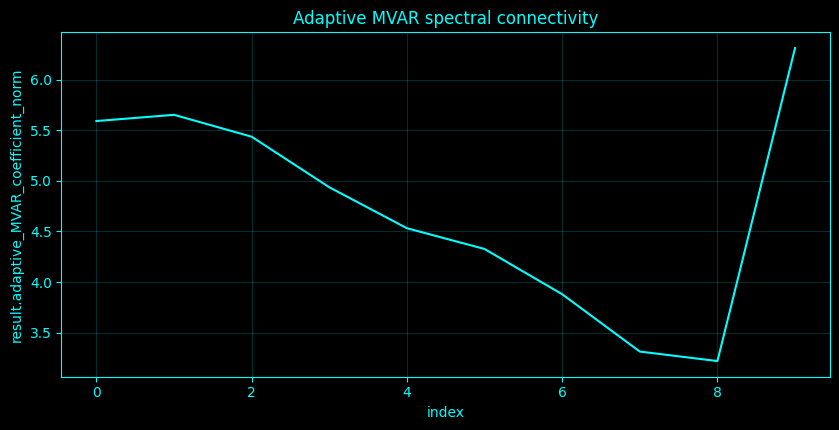

In [26]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _fit_var(order=None):
    if 'var' in SPEC_CACHE:
        return SPEC_CACHE['var']
    p = int(order or _SPEED['var_order'])
    Y = X[p:]
    Z = np.hstack([X[p - k:N - k] for k in range(1, p + 1)])
    B = np.linalg.solve(Z.T @ Z + 1e-05 * np.eye(Z.shape[1]), Z.T @ Y)
    A = np.stack([B[k * C:(k + 1) * C, :].T for k in range(p)], axis=0)
    E = Y - Z @ B
    Sigma = np.cov(E, rowvar=False) + 1e-08 * np.eye(C)
    SPEC_CACHE['var'] = (A, Sigma, E, Z)
    return SPEC_CACHE['var']

def _var_frequency(nf=64):
    key = ('varfreq', nf)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    Acoef, Sigma, E, Z = _fit_var()
    p = Acoef.shape[0]
    f = np.linspace(1, min(45, 0.45 * _fs), nf)
    Af = np.empty((nf, C, C), complex)
    H = np.empty_like(Af)
    S = np.empty_like(Af)
    I = np.eye(C)
    for q, ff in enumerate(f):
        M = I.astype(complex)
        for k in range(1, p + 1):
            M -= Acoef[k - 1] * np.exp(-2j * np.pi * ff * k / _fs)
        Af[q] = M
        H[q] = np.linalg.inv(M)
        S[q] = H[q] @ Sigma @ H[q].conj().T
    SPEC_CACHE[key] = (f, Af, H, S, Sigma)
    return SPEC_CACHE[key]

def _directed_measures():
    if 'directed' in SPEC_CACHE:
        return SPEC_CACHE['directed']
    f, A, H, S, Sigma = _var_frequency()
    sig = np.maximum(np.diag(Sigma).real, EPS)
    dtf = np.abs(H) / np.sqrt(np.sum(np.abs(H) ** 2, axis=2, keepdims=True) + EPS)
    pdc = np.abs(A) / np.sqrt(np.sum(np.abs(A) ** 2, axis=1, keepdims=True) + EPS)
    num = np.abs(A) / np.sqrt(sig[None, :, None])
    den = np.sqrt(np.sum(np.abs(A) ** 2 / sig[None, :, None], axis=1, keepdims=True) + EPS)
    gpdc = num / den
    L = np.linalg.cholesky(Sigma)
    Hw = H @ L
    Sw = Hw @ Hw.conj().transpose(0, 2, 1)
    Fgc = np.zeros((len(f), C, C))
    for i in range(C):
        sii = np.maximum(Sw[:, i, i].real, EPS)
        for j in range(C):
            if i == j:
                continue
            intrinsic = np.maximum(sii - np.abs(Hw[:, i, j]) ** 2, EPS)
            Fgc[:, i, j] = np.maximum(0, np.log(sii / intrinsic))
    pc = np.zeros_like(np.abs(S), float)
    for q in range(len(f)):
        P = np.linalg.pinv(S[q])
        d = np.sqrt(np.maximum(np.outer(np.diag(P).real, np.diag(P).real), EPS))
        pc[q] = np.abs(P) / d
    ddtf = dtf * pc
    Acoef, Sigma0, E, Z = _fit_var()
    p = Acoef.shape[0]
    Rinv = np.linalg.pinv(Z.T @ Z / max(len(Z), 1) + 1e-08 * np.eye(Z.shape[1]))
    rpdc = np.zeros((len(f), C, C))
    Nfit = len(Z)
    for qi, ff in enumerate(f):
        cs = np.cos(2 * np.pi * ff * np.arange(1, p + 1) / _fs)
        sn = np.sin(2 * np.pi * ff * np.arange(1, p + 1) / _fs)
        for i in range(C):
            for j in range(C):
                if i == j:
                    continue
                idx = np.array([k * C + j for k in range(p)])
                Rij = Rinv[np.ix_(idx, idx)] * Sigma0[i, i] / max(Nfit, 1)
                V = np.array([[cs @ Rij @ cs, cs @ Rij @ sn], [sn @ Rij @ cs, sn @ Rij @ sn]]) + 1e-12 * np.eye(2)
                z = np.array([A[qi, i, j].real, A[qi, i, j].imag])
                rpdc[qi, i, j] = float(z @ np.linalg.pinv(V) @ z)
    out = dict(f=f, A=A, H=H, S=S, Sigma=Sigma, dtf=dtf, pdc=pdc, gpdc=gpdc, rpdc=rpdc, gc=Fgc, ddtf=ddtf, pc=pc)
    SPEC_CACHE['directed'] = out
    return out

# Method-specific calculation.
def _compute_method_26():
    idx = 26
    name = 'Adaptive MVAR spectral connectivity'
    __plot_spec = None
    D = _directed_measures()
    f = D['f']
    m = (f >= 8) & (f < 13)
    nwin = min(10, max(4, N // max(int(_fs * 2), 1)))
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    vals = []
    for a0, b0 in zip(edges[:-1], edges[1:]):
        xx = X[a0:b0, :min(4, C)]
        pp = min(4, max(1, len(xx) // 30))
        if len(xx) <= pp + 5:
            continue
        Y = xx[pp:]
        Z = np.hstack([xx[pp - k:len(xx) - k] for k in range(1, pp + 1)])
        B = np.linalg.lstsq(Z, Y, rcond=None)[0]
        vals.append(float(np.linalg.norm(B)))
    return ({'adaptive_MVAR_coefficient_norm': vals}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_26,_plot_spec=_compute_method_26()
print('Adaptive MVAR spectral connectivity')
if isinstance(result_26,dict):
    for _k,_v in result_26.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_26)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_26)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Adaptive MVAR spectral connectivity',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Adaptive MVAR spectral connectivity',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Adaptive MVAR spectral connectivity',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">27. Cross-spectral density matrix analysis</h3>
<p>The cross-spectral density matrix \(S(f)=E[X(f)X(f)^\ast]\) is Hermitian positive semidefinite. Its diagonal contains channel PSDs and off-diagonal entries contain complex cross-spectra.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The density-matrix formalism represents a state by a positive semidefinite matrix with unit trace. Diagonal elements can be read as basis-dependent weights, while off-diagonal elements encode coherence between basis states. In an EEG application this is a mathematical representation borrowed from quantum information; unless the notebook explicitly models quantum physical measurements, the quantities should be understood as signal-analysis constructs rather than evidence of microscopic quantum brain dynamics.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. Expectation or angle-bracket notation denotes an average with respect to a probability distribution or ensemble.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Cross-spectral density matrix analysis
  trace_alpha: 0.0067853728742055105
  condition_alpha: 3910.9643148488135


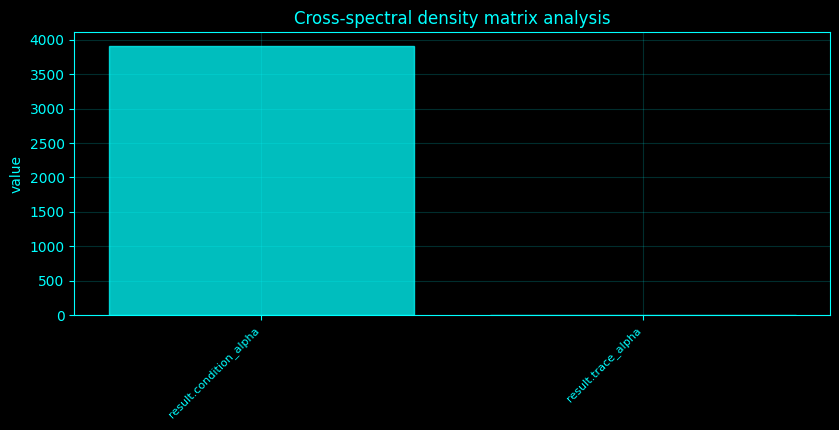

In [27]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _cross_spectral_matrix():
    if 'csm' in SPEC_CACHE:
        return SPEC_CACHE['csm']
    n = min(int(_SPEED['nperseg']), N)
    step = max(1, n // 2)
    win = signal.windows.hann(n)
    acc = None
    count = 0
    for a in range(0, N - n + 1, step):
        F = np.fft.rfft((X[a:a + n] - np.mean(X[a:a + n], axis=0)) * win[:, None], axis=0)
        S = np.einsum('fi,fj->fij', F, np.conj(F)) / (_fs * np.sum(win ** 2))
        acc = S if acc is None else acc + S
        count += 1
    S = acc / max(count, 1)
    f = np.fft.rfftfreq(n, 1 / _fs)
    keep = f <= min(55, 0.49 * _fs)
    SPEC_CACHE['csm'] = (f[keep], S[keep])
    return SPEC_CACHE['csm']

# Method-specific calculation.
def _compute_method_27():
    idx = 27
    name = 'Cross-spectral density matrix analysis'
    __plot_spec = None
    f, S = _cross_spectral_matrix()
    m = (f >= 8) & (f < 13)
    Salpha = np.mean(S[m], axis=0)
    return ({'trace_alpha': float(np.trace(Salpha).real), 'condition_alpha': float(np.linalg.cond(Salpha + 1e-08 * np.eye(C)))}, locals().get('__plot_spec', None))
    eigs = np.array([np.linalg.eigvalsh((q + q.conj().T) / 2).real[::-1] for q in S])
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_27,_plot_spec=_compute_method_27()
print('Cross-spectral density matrix analysis')
if isinstance(result_27,dict):
    for _k,_v in result_27.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_27)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_27)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Cross-spectral density matrix analysis',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Cross-spectral density matrix analysis',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Cross-spectral density matrix analysis',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">28. Complex cross-spectrum by channel pair</h3>
<p>A complex cross-spectrum \(S_{ij}(f)\) has magnitude \(|S_{ij}|\) and phase \(\arg S_{ij}\); both are needed to distinguish shared amplitude from relative phase.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [28]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _cross_spectral_matrix():
    if 'csm' in SPEC_CACHE:
        return SPEC_CACHE['csm']
    n = min(int(_SPEED['nperseg']), N)
    step = max(1, n // 2)
    win = signal.windows.hann(n)
    acc = None
    count = 0
    for a in range(0, N - n + 1, step):
        F = np.fft.rfft((X[a:a + n] - np.mean(X[a:a + n], axis=0)) * win[:, None], axis=0)
        S = np.einsum('fi,fj->fij', F, np.conj(F)) / (_fs * np.sum(win ** 2))
        acc = S if acc is None else acc + S
        count += 1
    S = acc / max(count, 1)
    f = np.fft.rfftfreq(n, 1 / _fs)
    keep = f <= min(55, 0.49 * _fs)
    SPEC_CACHE['csm'] = (f[keep], S[keep])
    return SPEC_CACHE['csm']

# Method-specific calculation.
def _compute_method_28():
    idx = 28
    name = 'Complex cross-spectrum by channel pair'
    __plot_spec = None
    f, S = _cross_spectral_matrix()
    m = (f >= 8) & (f < 13)
    Salpha = np.mean(S[m], axis=0)
    z = S[:, 0, 1]
    __plot_spec = ('summary', np.vstack([np.abs(z), np.angle(z)]), name, None, '', 'value')
    return ({'alpha_phase': float(np.angle(np.mean(z[m])))}, locals().get('__plot_spec', None))
    eigs = np.array([np.linalg.eigvalsh((q + q.conj().T) / 2).real[::-1] for q in S])
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_28,_plot_spec=_compute_method_28()
print('Complex cross-spectrum by channel pair')
if isinstance(result_28,dict):
    for _k,_v in result_28.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_28)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_28)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Complex cross-spectrum by channel pair',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Complex cross-spectrum by channel pair',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Complex cross-spectrum by channel pair',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Complex cross-spectrum by channel pair
  alpha_phase: -0.00507977753518894


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">29. Cross-spectral phase maps</h3>
<p>Cross-spectral phase maps display \(\arg S_{ij}(f)\) across channel pairs at a selected frequency.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [29]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _cross_spectral_matrix():
    if 'csm' in SPEC_CACHE:
        return SPEC_CACHE['csm']
    n = min(int(_SPEED['nperseg']), N)
    step = max(1, n // 2)
    win = signal.windows.hann(n)
    acc = None
    count = 0
    for a in range(0, N - n + 1, step):
        F = np.fft.rfft((X[a:a + n] - np.mean(X[a:a + n], axis=0)) * win[:, None], axis=0)
        S = np.einsum('fi,fj->fij', F, np.conj(F)) / (_fs * np.sum(win ** 2))
        acc = S if acc is None else acc + S
        count += 1
    S = acc / max(count, 1)
    f = np.fft.rfftfreq(n, 1 / _fs)
    keep = f <= min(55, 0.49 * _fs)
    SPEC_CACHE['csm'] = (f[keep], S[keep])
    return SPEC_CACHE['csm']

# Method-specific calculation.
def _compute_method_29():
    idx = 29
    name = 'Cross-spectral phase maps'
    __plot_spec = None
    f, S = _cross_spectral_matrix()
    m = (f >= 8) & (f < 13)
    Salpha = np.mean(S[m], axis=0)
    M = np.angle(S[np.argmin(np.abs(f - 10))])
    __plot_spec = ('summary', M, name, None, '', 'value')
    return ({'frequency_hz': float(f[np.argmin(np.abs(f - 10))])}, locals().get('__plot_spec', None))
    eigs = np.array([np.linalg.eigvalsh((q + q.conj().T) / 2).real[::-1] for q in S])
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_29,_plot_spec=_compute_method_29()
print('Cross-spectral phase maps')
if isinstance(result_29,dict):
    for _k,_v in result_29.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_29)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_29)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Cross-spectral phase maps',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Cross-spectral phase maps',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Cross-spectral phase maps',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Cross-spectral phase maps
  frequency_hz: 10.009765625


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">30. Cross-spectral magnitude maps</h3>
<p>Cross-spectral magnitude maps display \(|S_{ij}(f)|\), the absolute complex cross-spectrum across pairs.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [30]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _cross_spectral_matrix():
    if 'csm' in SPEC_CACHE:
        return SPEC_CACHE['csm']
    n = min(int(_SPEED['nperseg']), N)
    step = max(1, n // 2)
    win = signal.windows.hann(n)
    acc = None
    count = 0
    for a in range(0, N - n + 1, step):
        F = np.fft.rfft((X[a:a + n] - np.mean(X[a:a + n], axis=0)) * win[:, None], axis=0)
        S = np.einsum('fi,fj->fij', F, np.conj(F)) / (_fs * np.sum(win ** 2))
        acc = S if acc is None else acc + S
        count += 1
    S = acc / max(count, 1)
    f = np.fft.rfftfreq(n, 1 / _fs)
    keep = f <= min(55, 0.49 * _fs)
    SPEC_CACHE['csm'] = (f[keep], S[keep])
    return SPEC_CACHE['csm']

# Method-specific calculation.
def _compute_method_30():
    idx = 30
    name = 'Cross-spectral magnitude maps'
    __plot_spec = None
    f, S = _cross_spectral_matrix()
    m = (f >= 8) & (f < 13)
    Salpha = np.mean(S[m], axis=0)
    M = np.abs(S[np.argmin(np.abs(f - 10))])
    __plot_spec = ('summary', M, name, None, '', 'value')
    return ({'max_offdiag': float(np.max(M - np.diag(np.diag(M))))}, locals().get('__plot_spec', None))
    eigs = np.array([np.linalg.eigvalsh((q + q.conj().T) / 2).real[::-1] for q in S])
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_30,_plot_spec=_compute_method_30()
print('Cross-spectral magnitude maps')
if isinstance(result_30,dict):
    for _k,_v in result_30.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_30)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_30)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Cross-spectral magnitude maps',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Cross-spectral magnitude maps',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Cross-spectral magnitude maps',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Cross-spectral magnitude maps
  max_offdiag: 0.0016159137677816


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">31. Cross-spectral eigenvalue spectrum</h3>
<p>Because \(S(f)\) is Hermitian, it admits \(S(f)=U(f)\Lambda(f)U(f)^\ast\). Eigenvalue/SVD analyses quantify dominant multichannel spectral modes; for Hermitian PSD matrices singular values equal nonnegative eigenvalues.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Jacobian matrix is the local linear approximation of how small changes in each state variable affect the next state. Its eigenvalues and eigenvectors summarize locally preferred directions of growth, decay, or rotation. For a discrete-time map, eigenvalue magnitude below one indicates local contraction and magnitude above one indicates local expansion; for continuous-time systems, the sign of the real part is the corresponding stability indicator. When the Jacobian is estimated from data, these conclusions are local and depend on the quality of the regression or neighborhood used to estimate it.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol λ (lambda) is commonly used for an eigenvalue, Lyapunov exponent, regularization parameter, or rate; its exact meaning is set by the surrounding definition.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [31]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _cross_spectral_matrix():
    if 'csm' in SPEC_CACHE:
        return SPEC_CACHE['csm']
    n = min(int(_SPEED['nperseg']), N)
    step = max(1, n // 2)
    win = signal.windows.hann(n)
    acc = None
    count = 0
    for a in range(0, N - n + 1, step):
        F = np.fft.rfft((X[a:a + n] - np.mean(X[a:a + n], axis=0)) * win[:, None], axis=0)
        S = np.einsum('fi,fj->fij', F, np.conj(F)) / (_fs * np.sum(win ** 2))
        acc = S if acc is None else acc + S
        count += 1
    S = acc / max(count, 1)
    f = np.fft.rfftfreq(n, 1 / _fs)
    keep = f <= min(55, 0.49 * _fs)
    SPEC_CACHE['csm'] = (f[keep], S[keep])
    return SPEC_CACHE['csm']

# Method-specific calculation.
def _compute_method_31():
    idx = 31
    name = 'Cross-spectral eigenvalue spectrum'
    __plot_spec = None
    f, S = _cross_spectral_matrix()
    m = (f >= 8) & (f < 13)
    Salpha = np.mean(S[m], axis=0)
    eigs = np.array([np.linalg.eigvalsh((q + q.conj().T) / 2).real[::-1] for q in S])
    __plot_spec = ('summary', eigs.T, name, None, '', 'value')
    return ({'alpha_leading_fraction': float(np.mean(eigs[m, 0] / (np.sum(eigs[m], axis=1) + EPS)))}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_31,_plot_spec=_compute_method_31()
print('Cross-spectral eigenvalue spectrum')
if isinstance(result_31,dict):
    for _k,_v in result_31.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_31)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_31)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Cross-spectral eigenvalue spectrum',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Cross-spectral eigenvalue spectrum',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Cross-spectral eigenvalue spectrum',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Cross-spectral eigenvalue spectrum
  alpha_leading_fraction: 0.7716665739772872


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">32. Cross-spectral PCA</h3>
<p>Because \(S(f)\) is Hermitian, it admits \(S(f)=U(f)\Lambda(f)U(f)^\ast\). Eigenvalue/SVD analyses quantify dominant multichannel spectral modes; for Hermitian PSD matrices singular values equal nonnegative eigenvalues.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Jacobian matrix is the local linear approximation of how small changes in each state variable affect the next state. Its eigenvalues and eigenvectors summarize locally preferred directions of growth, decay, or rotation. For a discrete-time map, eigenvalue magnitude below one indicates local contraction and magnitude above one indicates local expansion; for continuous-time systems, the sign of the real part is the corresponding stability indicator. When the Jacobian is estimated from data, these conclusions are local and depend on the quality of the regression or neighborhood used to estimate it.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol λ (lambda) is commonly used for an eigenvalue, Lyapunov exponent, regularization parameter, or rate; its exact meaning is set by the surrounding definition.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Cross-spectral PCA
  leading_eigenvalue_fraction: 0.8010451494120857
  leading_mode_abs: array(12,), mean=0.263087


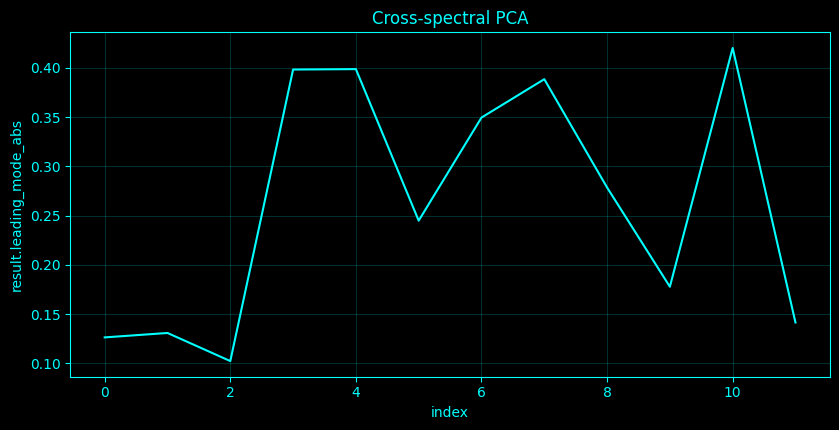

In [32]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _cross_spectral_matrix():
    if 'csm' in SPEC_CACHE:
        return SPEC_CACHE['csm']
    n = min(int(_SPEED['nperseg']), N)
    step = max(1, n // 2)
    win = signal.windows.hann(n)
    acc = None
    count = 0
    for a in range(0, N - n + 1, step):
        F = np.fft.rfft((X[a:a + n] - np.mean(X[a:a + n], axis=0)) * win[:, None], axis=0)
        S = np.einsum('fi,fj->fij', F, np.conj(F)) / (_fs * np.sum(win ** 2))
        acc = S if acc is None else acc + S
        count += 1
    S = acc / max(count, 1)
    f = np.fft.rfftfreq(n, 1 / _fs)
    keep = f <= min(55, 0.49 * _fs)
    SPEC_CACHE['csm'] = (f[keep], S[keep])
    return SPEC_CACHE['csm']

# Method-specific calculation.
def _compute_method_32():
    idx = 32
    name = 'Cross-spectral PCA'
    __plot_spec = None
    f, S = _cross_spectral_matrix()
    m = (f >= 8) & (f < 13)
    Salpha = np.mean(S[m], axis=0)
    eigs = np.array([np.linalg.eigvalsh((q + q.conj().T) / 2).real[::-1] for q in S])
    w, V = np.linalg.eigh((Salpha + Salpha.conj().T) / 2)
    return ({'leading_eigenvalue_fraction': float(w[-1] / (w.sum() + EPS)), 'leading_mode_abs': np.abs(V[:, -1]).tolist()}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_32,_plot_spec=_compute_method_32()
print('Cross-spectral PCA')
if isinstance(result_32,dict):
    for _k,_v in result_32.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_32)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_32)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Cross-spectral PCA',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Cross-spectral PCA',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Cross-spectral PCA',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">33. Cross-spectral SVD</h3>
<p>Because \(S(f)\) is Hermitian, it admits \(S(f)=U(f)\Lambda(f)U(f)^\ast\). Eigenvalue/SVD analyses quantify dominant multichannel spectral modes; for Hermitian PSD matrices singular values equal nonnegative eigenvalues.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Jacobian matrix is the local linear approximation of how small changes in each state variable affect the next state. Its eigenvalues and eigenvectors summarize locally preferred directions of growth, decay, or rotation. For a discrete-time map, eigenvalue magnitude below one indicates local contraction and magnitude above one indicates local expansion; for continuous-time systems, the sign of the real part is the corresponding stability indicator. When the Jacobian is estimated from data, these conclusions are local and depend on the quality of the regression or neighborhood used to estimate it.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol λ (lambda) is commonly used for an eigenvalue, Lyapunov exponent, regularization parameter, or rate; its exact meaning is set by the surrounding definition.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Cross-spectral SVD
  singular_value_fraction: array(12,), mean=0.0833333


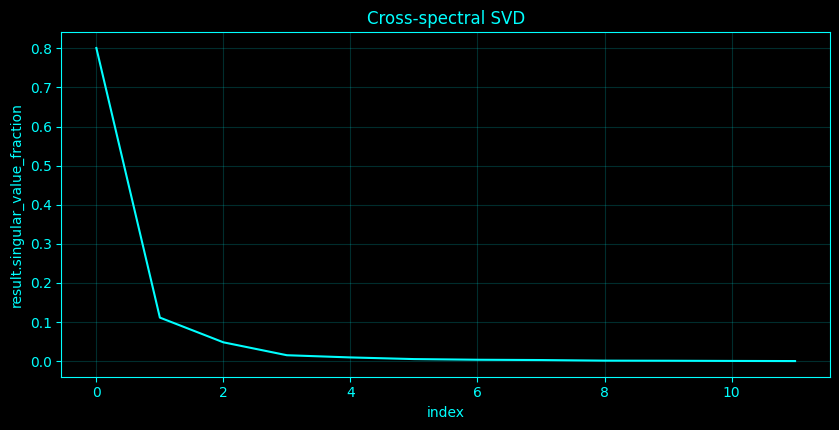

In [33]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _cross_spectral_matrix():
    if 'csm' in SPEC_CACHE:
        return SPEC_CACHE['csm']
    n = min(int(_SPEED['nperseg']), N)
    step = max(1, n // 2)
    win = signal.windows.hann(n)
    acc = None
    count = 0
    for a in range(0, N - n + 1, step):
        F = np.fft.rfft((X[a:a + n] - np.mean(X[a:a + n], axis=0)) * win[:, None], axis=0)
        S = np.einsum('fi,fj->fij', F, np.conj(F)) / (_fs * np.sum(win ** 2))
        acc = S if acc is None else acc + S
        count += 1
    S = acc / max(count, 1)
    f = np.fft.rfftfreq(n, 1 / _fs)
    keep = f <= min(55, 0.49 * _fs)
    SPEC_CACHE['csm'] = (f[keep], S[keep])
    return SPEC_CACHE['csm']

# Method-specific calculation.
def _compute_method_33():
    idx = 33
    name = 'Cross-spectral SVD'
    __plot_spec = None
    f, S = _cross_spectral_matrix()
    m = (f >= 8) & (f < 13)
    Salpha = np.mean(S[m], axis=0)
    eigs = np.array([np.linalg.eigvalsh((q + q.conj().T) / 2).real[::-1] for q in S])
    s = np.linalg.svd(Salpha, compute_uv=False)
    return ({'singular_value_fraction': (s / (s.sum() + EPS)).tolist()}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_33,_plot_spec=_compute_method_33()
print('Cross-spectral SVD')
if isinstance(result_33,dict):
    for _k,_v in result_33.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_33)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_33)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Cross-spectral SVD',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Cross-spectral SVD',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Cross-spectral SVD',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">34. Frequency-resolved covariance eigenspectra</h3>
<p>Because \(S(f)\) is Hermitian, it admits \(S(f)=U(f)\Lambda(f)U(f)^\ast\). Eigenvalue/SVD analyses quantify dominant multichannel spectral modes; for Hermitian PSD matrices singular values equal nonnegative eigenvalues.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Jacobian matrix is the local linear approximation of how small changes in each state variable affect the next state. Its eigenvalues and eigenvectors summarize locally preferred directions of growth, decay, or rotation. For a discrete-time map, eigenvalue magnitude below one indicates local contraction and magnitude above one indicates local expansion; for continuous-time systems, the sign of the real part is the corresponding stability indicator. When the Jacobian is estimated from data, these conclusions are local and depend on the quality of the regression or neighborhood used to estimate it.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol λ (lambda) is commonly used for an eigenvalue, Lyapunov exponent, regularization parameter, or rate; its exact meaning is set by the surrounding definition.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Frequency-resolved covariance eigenspectra
  shape: array(2,), mean=119


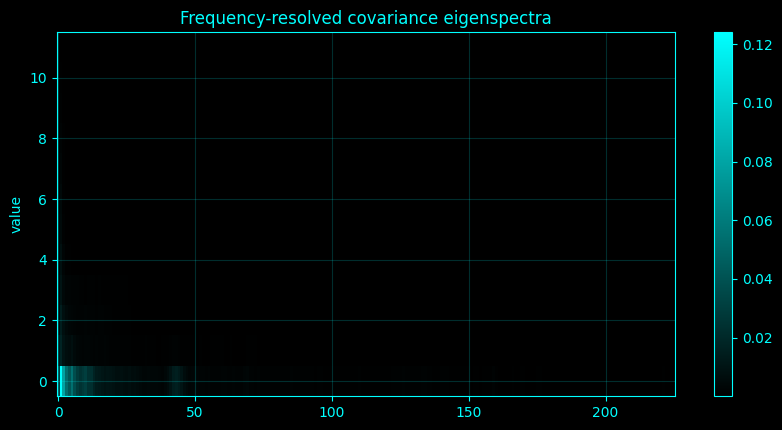

In [34]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _cross_spectral_matrix():
    if 'csm' in SPEC_CACHE:
        return SPEC_CACHE['csm']
    n = min(int(_SPEED['nperseg']), N)
    step = max(1, n // 2)
    win = signal.windows.hann(n)
    acc = None
    count = 0
    for a in range(0, N - n + 1, step):
        F = np.fft.rfft((X[a:a + n] - np.mean(X[a:a + n], axis=0)) * win[:, None], axis=0)
        S = np.einsum('fi,fj->fij', F, np.conj(F)) / (_fs * np.sum(win ** 2))
        acc = S if acc is None else acc + S
        count += 1
    S = acc / max(count, 1)
    f = np.fft.rfftfreq(n, 1 / _fs)
    keep = f <= min(55, 0.49 * _fs)
    SPEC_CACHE['csm'] = (f[keep], S[keep])
    return SPEC_CACHE['csm']

# Method-specific calculation.
def _compute_method_34():
    idx = 34
    name = 'Frequency-resolved covariance eigenspectra'
    __plot_spec = None
    f, S = _cross_spectral_matrix()
    m = (f >= 8) & (f < 13)
    Salpha = np.mean(S[m], axis=0)
    eigs = np.array([np.linalg.eigvalsh((q + q.conj().T) / 2).real[::-1] for q in S])
    er = np.array([np.linalg.eigvalsh(np.real((q + q.conj().T) / 2))[::-1] for q in S])
    __plot_spec = ('summary', er.T, name, None, '', 'value')
    return ({'shape': er.shape}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_34,_plot_spec=_compute_method_34()
print('Frequency-resolved covariance eigenspectra')
if isinstance(result_34,dict):
    for _k,_v in result_34.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_34)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_34)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Frequency-resolved covariance eigenspectra',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Frequency-resolved covariance eigenspectra',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Frequency-resolved covariance eigenspectra',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">35. Spectral participation ratio</h3>
<p>Spectral participation ratio is \(PR=(\sum_k\lambda_k)^2/\sum_k\lambda_k^2\), the effective number of comparably energetic eigenmodes.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol λ (lambda) is commonly used for an eigenvalue, Lyapunov exponent, regularization parameter, or rate; its exact meaning is set by the surrounding definition.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [35]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _cross_spectral_matrix():
    if 'csm' in SPEC_CACHE:
        return SPEC_CACHE['csm']
    n = min(int(_SPEED['nperseg']), N)
    step = max(1, n // 2)
    win = signal.windows.hann(n)
    acc = None
    count = 0
    for a in range(0, N - n + 1, step):
        F = np.fft.rfft((X[a:a + n] - np.mean(X[a:a + n], axis=0)) * win[:, None], axis=0)
        S = np.einsum('fi,fj->fij', F, np.conj(F)) / (_fs * np.sum(win ** 2))
        acc = S if acc is None else acc + S
        count += 1
    S = acc / max(count, 1)
    f = np.fft.rfftfreq(n, 1 / _fs)
    keep = f <= min(55, 0.49 * _fs)
    SPEC_CACHE['csm'] = (f[keep], S[keep])
    return SPEC_CACHE['csm']

# Method-specific calculation.
def _compute_method_35():
    idx = 35
    name = 'Spectral participation ratio'
    __plot_spec = None
    f, S = _cross_spectral_matrix()
    m = (f >= 8) & (f < 13)
    Salpha = np.mean(S[m], axis=0)
    eigs = np.array([np.linalg.eigvalsh((q + q.conj().T) / 2).real[::-1] for q in S])
    lam = np.maximum(eigs, 0)
    pr = np.sum(lam, axis=1) ** 2 / (np.sum(lam ** 2, axis=1) + EPS)
    return ({'alpha_participation_ratio': float(np.mean(pr[m]))}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_35,_plot_spec=_compute_method_35()
print('Spectral participation ratio')
if isinstance(result_35,dict):
    for _k,_v in result_35.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_35)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_35)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Spectral participation ratio',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Spectral participation ratio',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Spectral participation ratio',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Spectral participation ratio
  alpha_participation_ratio: 1.6472633749945038


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">36. Spectral effective rank</h3>
<p>Spectral effective rank normalizes \(p_k=\lambda_k/\sum_j\lambda_j\) and computes \(\exp[-\sum_k p_k\log p_k]\).</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. An exponential describes multiplicative growth or decay. In dynamical systems, a positive exponent corresponds to growth with time and a negative exponent to decay.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [36]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _cross_spectral_matrix():
    if 'csm' in SPEC_CACHE:
        return SPEC_CACHE['csm']
    n = min(int(_SPEED['nperseg']), N)
    step = max(1, n // 2)
    win = signal.windows.hann(n)
    acc = None
    count = 0
    for a in range(0, N - n + 1, step):
        F = np.fft.rfft((X[a:a + n] - np.mean(X[a:a + n], axis=0)) * win[:, None], axis=0)
        S = np.einsum('fi,fj->fij', F, np.conj(F)) / (_fs * np.sum(win ** 2))
        acc = S if acc is None else acc + S
        count += 1
    S = acc / max(count, 1)
    f = np.fft.rfftfreq(n, 1 / _fs)
    keep = f <= min(55, 0.49 * _fs)
    SPEC_CACHE['csm'] = (f[keep], S[keep])
    return SPEC_CACHE['csm']

# Method-specific calculation.
def _compute_method_36():
    idx = 36
    name = 'Spectral effective rank'
    __plot_spec = None
    f, S = _cross_spectral_matrix()
    m = (f >= 8) & (f < 13)
    Salpha = np.mean(S[m], axis=0)
    eigs = np.array([np.linalg.eigvalsh((q + q.conj().T) / 2).real[::-1] for q in S])
    lam = np.maximum(eigs, 0)
    q = lam / (np.sum(lam, axis=1, keepdims=True) + EPS)
    er = np.exp(-np.sum(q * np.log(q + EPS), axis=1))
    return ({'alpha_effective_rank': float(np.mean(er[m]))}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_36,_plot_spec=_compute_method_36()
print('Spectral effective rank')
if isinstance(result_36,dict):
    for _k,_v in result_36.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_36)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_36)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Spectral effective rank',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Spectral effective rank',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Spectral effective rank',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Spectral effective rank
  alpha_effective_rank: 2.3259164387687807


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">37. Frequency-specific covariance geometry</h3>
<p>Frequency-specific covariance geometry compares regularized spectral covariance matrices with a log-Euclidean distance \(d(P,Q)=\|\log P-\log Q\|_F\).</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance measures how two variables vary together around their means. Positive covariance means they tend to deviate in the same direction; negative covariance means opposite directions. Correlation rescales covariance by the variables' standard deviations, making it dimensionless and bounded between -1 and 1 for ordinary Pearson correlation. Both are linear summaries and can miss nonlinear dependence.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [37]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _cross_spectral_matrix():
    if 'csm' in SPEC_CACHE:
        return SPEC_CACHE['csm']
    n = min(int(_SPEED['nperseg']), N)
    step = max(1, n // 2)
    win = signal.windows.hann(n)
    acc = None
    count = 0
    for a in range(0, N - n + 1, step):
        F = np.fft.rfft((X[a:a + n] - np.mean(X[a:a + n], axis=0)) * win[:, None], axis=0)
        S = np.einsum('fi,fj->fij', F, np.conj(F)) / (_fs * np.sum(win ** 2))
        acc = S if acc is None else acc + S
        count += 1
    S = acc / max(count, 1)
    f = np.fft.rfftfreq(n, 1 / _fs)
    keep = f <= min(55, 0.49 * _fs)
    SPEC_CACHE['csm'] = (f[keep], S[keep])
    return SPEC_CACHE['csm']

# Method-specific calculation.
def _compute_method_37():
    idx = 37
    name = 'Frequency-specific covariance geometry'
    __plot_spec = None
    f, S = _cross_spectral_matrix()
    m = (f >= 8) & (f < 13)
    Salpha = np.mean(S[m], axis=0)
    eigs = np.array([np.linalg.eigvalsh((q + q.conj().T) / 2).real[::-1] for q in S])
    ids = np.where(m)[0]
    d = []
    for a, b in zip(ids[:-1], ids[1:]):
        P = S[a] + 1e-06 * np.trace(S[a]).real / C * np.eye(C)
        Q = S[b] + 1e-06 * np.trace(S[b]).real / C * np.eye(C)
        if idx == 37:
            LP = linalg.logm(P)
            LQ = linalg.logm(Q)
            d.append(float(np.linalg.norm(LP - LQ, 'fro')))
        else:
            Pi = linalg.inv(linalg.sqrtm(P))
            M0 = Pi @ Q @ Pi.conj().T
            d.append(float(np.linalg.norm(linalg.logm(M0), 'fro')))
    return ({'mean_adjacent_frequency_distance': float(np.mean(d)) if d else np.nan}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_37,_plot_spec=_compute_method_37()
print('Frequency-specific covariance geometry')
if isinstance(result_37,dict):
    for _k,_v in result_37.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_37)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_37)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Frequency-specific covariance geometry',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Frequency-specific covariance geometry',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Frequency-specific covariance geometry',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Frequency-specific covariance geometry
  mean_adjacent_frequency_distance: 1.5850327873970351


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">38. Cross-spectral matrix condition number</h3>
<p>The condition number \(\kappa(S)=\lambda_{\max}/\lambda_{\min}\) measures spectral-matrix numerical anisotropy/ill-conditioning after a small positive-definite regularization.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol λ (lambda) is commonly used for an eigenvalue, Lyapunov exponent, regularization parameter, or rate; its exact meaning is set by the surrounding definition.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [38]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _cross_spectral_matrix():
    if 'csm' in SPEC_CACHE:
        return SPEC_CACHE['csm']
    n = min(int(_SPEED['nperseg']), N)
    step = max(1, n // 2)
    win = signal.windows.hann(n)
    acc = None
    count = 0
    for a in range(0, N - n + 1, step):
        F = np.fft.rfft((X[a:a + n] - np.mean(X[a:a + n], axis=0)) * win[:, None], axis=0)
        S = np.einsum('fi,fj->fij', F, np.conj(F)) / (_fs * np.sum(win ** 2))
        acc = S if acc is None else acc + S
        count += 1
    S = acc / max(count, 1)
    f = np.fft.rfftfreq(n, 1 / _fs)
    keep = f <= min(55, 0.49 * _fs)
    SPEC_CACHE['csm'] = (f[keep], S[keep])
    return SPEC_CACHE['csm']

# Method-specific calculation.
def _compute_method_38():
    idx = 38
    name = 'Cross-spectral matrix condition number'
    __plot_spec = None
    f, S = _cross_spectral_matrix()
    m = (f >= 8) & (f < 13)
    Salpha = np.mean(S[m], axis=0)
    eigs = np.array([np.linalg.eigvalsh((q + q.conj().T) / 2).real[::-1] for q in S])
    c = np.array([np.linalg.cond(q + 1e-08 * np.eye(C)) for q in S])
    __plot_spec = ('summary', c, name, f, 'Hz', 'condition')
    return ({'median': float(np.median(c))}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_38,_plot_spec=_compute_method_38()
print('Cross-spectral matrix condition number')
if isinstance(result_38,dict):
    for _k,_v in result_38.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_38)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_38)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Cross-spectral matrix condition number',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Cross-spectral matrix condition number',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Cross-spectral matrix condition number',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Cross-spectral matrix condition number
  median: 628.8320243367457


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">39. Hermitian cross-spectral manifold analysis</h3>
<p>Hermitian positive-definite cross-spectral matrices can be compared with the affine-invariant distance \(d(P,Q)=\|\log(P^{-1/2}QP^{-1/2})\|_F\).</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [39]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _cross_spectral_matrix():
    if 'csm' in SPEC_CACHE:
        return SPEC_CACHE['csm']
    n = min(int(_SPEED['nperseg']), N)
    step = max(1, n // 2)
    win = signal.windows.hann(n)
    acc = None
    count = 0
    for a in range(0, N - n + 1, step):
        F = np.fft.rfft((X[a:a + n] - np.mean(X[a:a + n], axis=0)) * win[:, None], axis=0)
        S = np.einsum('fi,fj->fij', F, np.conj(F)) / (_fs * np.sum(win ** 2))
        acc = S if acc is None else acc + S
        count += 1
    S = acc / max(count, 1)
    f = np.fft.rfftfreq(n, 1 / _fs)
    keep = f <= min(55, 0.49 * _fs)
    SPEC_CACHE['csm'] = (f[keep], S[keep])
    return SPEC_CACHE['csm']

# Method-specific calculation.
def _compute_method_39():
    idx = 39
    name = 'Hermitian cross-spectral manifold analysis'
    __plot_spec = None
    f, S = _cross_spectral_matrix()
    m = (f >= 8) & (f < 13)
    Salpha = np.mean(S[m], axis=0)
    eigs = np.array([np.linalg.eigvalsh((q + q.conj().T) / 2).real[::-1] for q in S])
    ids = np.where(m)[0]
    d = []
    for a, b in zip(ids[:-1], ids[1:]):
        P = S[a] + 1e-06 * np.trace(S[a]).real / C * np.eye(C)
        Q = S[b] + 1e-06 * np.trace(S[b]).real / C * np.eye(C)
        if idx == 37:
            LP = linalg.logm(P)
            LQ = linalg.logm(Q)
            d.append(float(np.linalg.norm(LP - LQ, 'fro')))
        else:
            Pi = linalg.inv(linalg.sqrtm(P))
            M0 = Pi @ Q @ Pi.conj().T
            d.append(float(np.linalg.norm(linalg.logm(M0), 'fro')))
    return ({'mean_adjacent_frequency_distance': float(np.mean(d)) if d else np.nan}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_39,_plot_spec=_compute_method_39()
print('Hermitian cross-spectral manifold analysis')
if isinstance(result_39,dict):
    for _k,_v in result_39.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_39)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_39)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Hermitian cross-spectral manifold analysis',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Hermitian cross-spectral manifold analysis',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Hermitian cross-spectral manifold analysis',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Hermitian cross-spectral manifold analysis
  mean_adjacent_frequency_distance: 2.003097069692133


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">40. Imaginary coherence</h3>
<p>Imaginary coherence retains the normalized imaginary part of coherency, \(|\Im[S_{xy}/\sqrt{S_{xx}S_{yy}}]|\), suppressing exactly zero-lag coupling.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Coherence is a frequency-specific measure of linear association between two signals. It compares the magnitude of their cross-spectrum with the power spectra of the individual signals. Values near one mean that a stable linear relationship at that frequency explains a large fraction of the spectral activity, while values near zero indicate weak consistency. High coherence can arise from common input, volume conduction, or shared reference effects, so it should not automatically be interpreted as direct connectivity.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [40]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _coherence_matrix(band=(8, 13), phase=False):
    key = ('plv' if phase else 'coh', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    M = np.eye(C)
    if phase:
        ph = np.angle(_analytic_band(band))
        for i in range(C):
            for j in range(i + 1, C):
                v = np.abs(np.mean(np.exp(1j * (ph[:, i] - ph[:, j]))))
                M[i, j] = M[j, i] = v
    else:
        nper = min(int(_SPEED['nperseg']), N)
        for i in range(C):
            for j in range(i + 1, C):
                f, c = signal.coherence(X[:, i], X[:, j], fs=_fs, nperseg=nper, noverlap=nper // 2)
                m = (f >= band[0]) & (f < band[1])
                v = float(np.nanmean(c[m])) if np.any(m) else np.nan
                M[i, j] = M[j, i] = v
    SPEC_CACHE[key] = M
    return M

def _cross_spectral_matrix():
    if 'csm' in SPEC_CACHE:
        return SPEC_CACHE['csm']
    n = min(int(_SPEED['nperseg']), N)
    step = max(1, n // 2)
    win = signal.windows.hann(n)
    acc = None
    count = 0
    for a in range(0, N - n + 1, step):
        F = np.fft.rfft((X[a:a + n] - np.mean(X[a:a + n], axis=0)) * win[:, None], axis=0)
        S = np.einsum('fi,fj->fij', F, np.conj(F)) / (_fs * np.sum(win ** 2))
        acc = S if acc is None else acc + S
        count += 1
    S = acc / max(count, 1)
    f = np.fft.rfftfreq(n, 1 / _fs)
    keep = f <= min(55, 0.49 * _fs)
    SPEC_CACHE['csm'] = (f[keep], S[keep])
    return SPEC_CACHE['csm']

# Method-specific calculation.
def _compute_method_40():
    idx = 40
    name = 'Imaginary coherence'
    __plot_spec = None
    f, S = _cross_spectral_matrix()
    Sxy = S[:, 0, 1]
    coh_complex = Sxy / np.sqrt(np.real(S[:, 0, 0]) * np.real(S[:, 1, 1]) + EPS)
    m = (f >= 8) & (f < 13)
    y = np.abs(np.imag(coh_complex))
    __plot_spec = ('summary', y, name, f, 'Hz', '|Im coherence|')
    return ({'alpha': float(np.mean(y[m]))}, locals().get('__plot_spec', None))
    M = _coherence_matrix(BANDS['alpha'])
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_40,_plot_spec=_compute_method_40()
print('Imaginary coherence')
if isinstance(result_40,dict):
    for _k,_v in result_40.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_40)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_40)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Imaginary coherence',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Imaginary coherence',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Imaginary coherence',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Imaginary coherence
  alpha: 0.03214133311378299


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">41. Lagged coherence</h3>
<p>Lagged coherence removes the instantaneous real-coherency contribution. A common form is \(\sqrt{\Im(c)^2/[1-\Re(c)^2]}\) for complex coherency \(c\).</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Coherence is a frequency-specific measure of linear association between two signals. It compares the magnitude of their cross-spectrum with the power spectra of the individual signals. Values near one mean that a stable linear relationship at that frequency explains a large fraction of the spectral activity, while values near zero indicate weak consistency. High coherence can arise from common input, volume conduction, or shared reference effects, so it should not automatically be interpreted as direct connectivity.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [41]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _coherence_matrix(band=(8, 13), phase=False):
    key = ('plv' if phase else 'coh', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    M = np.eye(C)
    if phase:
        ph = np.angle(_analytic_band(band))
        for i in range(C):
            for j in range(i + 1, C):
                v = np.abs(np.mean(np.exp(1j * (ph[:, i] - ph[:, j]))))
                M[i, j] = M[j, i] = v
    else:
        nper = min(int(_SPEED['nperseg']), N)
        for i in range(C):
            for j in range(i + 1, C):
                f, c = signal.coherence(X[:, i], X[:, j], fs=_fs, nperseg=nper, noverlap=nper // 2)
                m = (f >= band[0]) & (f < band[1])
                v = float(np.nanmean(c[m])) if np.any(m) else np.nan
                M[i, j] = M[j, i] = v
    SPEC_CACHE[key] = M
    return M

def _cross_spectral_matrix():
    if 'csm' in SPEC_CACHE:
        return SPEC_CACHE['csm']
    n = min(int(_SPEED['nperseg']), N)
    step = max(1, n // 2)
    win = signal.windows.hann(n)
    acc = None
    count = 0
    for a in range(0, N - n + 1, step):
        F = np.fft.rfft((X[a:a + n] - np.mean(X[a:a + n], axis=0)) * win[:, None], axis=0)
        S = np.einsum('fi,fj->fij', F, np.conj(F)) / (_fs * np.sum(win ** 2))
        acc = S if acc is None else acc + S
        count += 1
    S = acc / max(count, 1)
    f = np.fft.rfftfreq(n, 1 / _fs)
    keep = f <= min(55, 0.49 * _fs)
    SPEC_CACHE['csm'] = (f[keep], S[keep])
    return SPEC_CACHE['csm']

# Method-specific calculation.
def _compute_method_41():
    idx = 41
    name = 'Lagged coherence'
    __plot_spec = None
    f, S = _cross_spectral_matrix()
    Sxy = S[:, 0, 1]
    coh_complex = Sxy / np.sqrt(np.real(S[:, 0, 0]) * np.real(S[:, 1, 1]) + EPS)
    m = (f >= 8) & (f < 13)
    re = np.real(coh_complex)
    im = np.imag(coh_complex)
    lag = np.sqrt(np.maximum(im ** 2 / (1 - re ** 2 + EPS), 0))
    __plot_spec = ('summary', lag, name, f, 'Hz', 'lagged coherence')
    return ({'alpha': float(np.mean(lag[m]))}, locals().get('__plot_spec', None))
    M = _coherence_matrix(BANDS['alpha'])
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_41,_plot_spec=_compute_method_41()
print('Lagged coherence')
if isinstance(result_41,dict):
    for _k,_v in result_41.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_41)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_41)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Lagged coherence',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Lagged coherence',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Lagged coherence',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Lagged coherence
  alpha: 0.11515531768467471


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">42. Magnitude-squared coherence</h3>
<p>Magnitude-squared coherence is \(C_{xy}=|S_{xy}|^2/(S_{xx}S_{yy})\in[0,1]\).</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Coherence is a frequency-specific measure of linear association between two signals. It compares the magnitude of their cross-spectrum with the power spectra of the individual signals. Values near one mean that a stable linear relationship at that frequency explains a large fraction of the spectral activity, while values near zero indicate weak consistency. High coherence can arise from common input, volume conduction, or shared reference effects, so it should not automatically be interpreted as direct connectivity.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [42]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _coherence_matrix(band=(8, 13), phase=False):
    key = ('plv' if phase else 'coh', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    M = np.eye(C)
    if phase:
        ph = np.angle(_analytic_band(band))
        for i in range(C):
            for j in range(i + 1, C):
                v = np.abs(np.mean(np.exp(1j * (ph[:, i] - ph[:, j]))))
                M[i, j] = M[j, i] = v
    else:
        nper = min(int(_SPEED['nperseg']), N)
        for i in range(C):
            for j in range(i + 1, C):
                f, c = signal.coherence(X[:, i], X[:, j], fs=_fs, nperseg=nper, noverlap=nper // 2)
                m = (f >= band[0]) & (f < band[1])
                v = float(np.nanmean(c[m])) if np.any(m) else np.nan
                M[i, j] = M[j, i] = v
    SPEC_CACHE[key] = M
    return M

def _cross_spectral_matrix():
    if 'csm' in SPEC_CACHE:
        return SPEC_CACHE['csm']
    n = min(int(_SPEED['nperseg']), N)
    step = max(1, n // 2)
    win = signal.windows.hann(n)
    acc = None
    count = 0
    for a in range(0, N - n + 1, step):
        F = np.fft.rfft((X[a:a + n] - np.mean(X[a:a + n], axis=0)) * win[:, None], axis=0)
        S = np.einsum('fi,fj->fij', F, np.conj(F)) / (_fs * np.sum(win ** 2))
        acc = S if acc is None else acc + S
        count += 1
    S = acc / max(count, 1)
    f = np.fft.rfftfreq(n, 1 / _fs)
    keep = f <= min(55, 0.49 * _fs)
    SPEC_CACHE['csm'] = (f[keep], S[keep])
    return SPEC_CACHE['csm']

# Method-specific calculation.
def _compute_method_42():
    idx = 42
    name = 'Magnitude-squared coherence'
    __plot_spec = None
    f, S = _cross_spectral_matrix()
    Sxy = S[:, 0, 1]
    coh_complex = Sxy / np.sqrt(np.real(S[:, 0, 0]) * np.real(S[:, 1, 1]) + EPS)
    m = (f >= 8) & (f < 13)
    y = np.abs(coh_complex) ** 2
    __plot_spec = ('summary', y, name, f, 'Hz', 'MSC')
    return ({'alpha': float(np.mean(y[m]))}, locals().get('__plot_spec', None))
    M = _coherence_matrix(BANDS['alpha'])
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_42,_plot_spec=_compute_method_42()
print('Magnitude-squared coherence')
if isinstance(result_42,dict):
    for _k,_v in result_42.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_42)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_42)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Magnitude-squared coherence',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Magnitude-squared coherence',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Magnitude-squared coherence',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Magnitude-squared coherence
  alpha: 0.9155300129690098


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">43. Partial coherence</h3>
<p>Partial coherence conditions on the remaining channels using precision spectrum \(P=S^{-1}\): \(|P_{ij}|^2/[P_{ii}P_{jj}]\).</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Coherence is a frequency-specific measure of linear association between two signals. It compares the magnitude of their cross-spectrum with the power spectra of the individual signals. Values near one mean that a stable linear relationship at that frequency explains a large fraction of the spectral activity, while values near zero indicate weak consistency. High coherence can arise from common input, volume conduction, or shared reference effects, so it should not automatically be interpreted as direct connectivity.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [43]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _coherence_matrix(band=(8, 13), phase=False):
    key = ('plv' if phase else 'coh', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    M = np.eye(C)
    if phase:
        ph = np.angle(_analytic_band(band))
        for i in range(C):
            for j in range(i + 1, C):
                v = np.abs(np.mean(np.exp(1j * (ph[:, i] - ph[:, j]))))
                M[i, j] = M[j, i] = v
    else:
        nper = min(int(_SPEED['nperseg']), N)
        for i in range(C):
            for j in range(i + 1, C):
                f, c = signal.coherence(X[:, i], X[:, j], fs=_fs, nperseg=nper, noverlap=nper // 2)
                m = (f >= band[0]) & (f < band[1])
                v = float(np.nanmean(c[m])) if np.any(m) else np.nan
                M[i, j] = M[j, i] = v
    SPEC_CACHE[key] = M
    return M

def _cross_spectral_matrix():
    if 'csm' in SPEC_CACHE:
        return SPEC_CACHE['csm']
    n = min(int(_SPEED['nperseg']), N)
    step = max(1, n // 2)
    win = signal.windows.hann(n)
    acc = None
    count = 0
    for a in range(0, N - n + 1, step):
        F = np.fft.rfft((X[a:a + n] - np.mean(X[a:a + n], axis=0)) * win[:, None], axis=0)
        S = np.einsum('fi,fj->fij', F, np.conj(F)) / (_fs * np.sum(win ** 2))
        acc = S if acc is None else acc + S
        count += 1
    S = acc / max(count, 1)
    f = np.fft.rfftfreq(n, 1 / _fs)
    keep = f <= min(55, 0.49 * _fs)
    SPEC_CACHE['csm'] = (f[keep], S[keep])
    return SPEC_CACHE['csm']

# Method-specific calculation.
def _compute_method_43():
    idx = 43
    name = 'Partial coherence'
    __plot_spec = None
    f, S = _cross_spectral_matrix()
    Sxy = S[:, 0, 1]
    coh_complex = Sxy / np.sqrt(np.real(S[:, 0, 0]) * np.real(S[:, 1, 1]) + EPS)
    m = (f >= 8) & (f < 13)
    pc = []
    for q in S:
        P = np.linalg.pinv(q)
        pc.append(np.abs(P[0, 1]) ** 2 / (np.real(P[0, 0]) * np.real(P[1, 1]) + EPS))
    pc = np.asarray(pc)
    return ({'alpha_partial_coherence': float(np.mean(pc[m]))}, locals().get('__plot_spec', None))
    M = _coherence_matrix(BANDS['alpha'])
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_43,_plot_spec=_compute_method_43()
print('Partial coherence')
if isinstance(result_43,dict):
    for _k,_v in result_43.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_43)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_43)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Partial coherence',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Partial coherence',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Partial coherence',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Partial coherence
  alpha_partial_coherence: 0.27300733049575965


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">44. Multiple coherence</h3>
<p>Multiple coherence measures how well all remaining channels jointly explain a target in the frequency domain. From spectral precision, \(R_i^2(f)=1-[S_{ii}(f)P_{ii}(f)]^{-1}\).</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Coherence is a frequency-specific measure of linear association between two signals. It compares the magnitude of their cross-spectrum with the power spectra of the individual signals. Values near one mean that a stable linear relationship at that frequency explains a large fraction of the spectral activity, while values near zero indicate weak consistency. High coherence can arise from common input, volume conduction, or shared reference effects, so it should not automatically be interpreted as direct connectivity.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [44]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _coherence_matrix(band=(8, 13), phase=False):
    key = ('plv' if phase else 'coh', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    M = np.eye(C)
    if phase:
        ph = np.angle(_analytic_band(band))
        for i in range(C):
            for j in range(i + 1, C):
                v = np.abs(np.mean(np.exp(1j * (ph[:, i] - ph[:, j]))))
                M[i, j] = M[j, i] = v
    else:
        nper = min(int(_SPEED['nperseg']), N)
        for i in range(C):
            for j in range(i + 1, C):
                f, c = signal.coherence(X[:, i], X[:, j], fs=_fs, nperseg=nper, noverlap=nper // 2)
                m = (f >= band[0]) & (f < band[1])
                v = float(np.nanmean(c[m])) if np.any(m) else np.nan
                M[i, j] = M[j, i] = v
    SPEC_CACHE[key] = M
    return M

def _cross_spectral_matrix():
    if 'csm' in SPEC_CACHE:
        return SPEC_CACHE['csm']
    n = min(int(_SPEED['nperseg']), N)
    step = max(1, n // 2)
    win = signal.windows.hann(n)
    acc = None
    count = 0
    for a in range(0, N - n + 1, step):
        F = np.fft.rfft((X[a:a + n] - np.mean(X[a:a + n], axis=0)) * win[:, None], axis=0)
        S = np.einsum('fi,fj->fij', F, np.conj(F)) / (_fs * np.sum(win ** 2))
        acc = S if acc is None else acc + S
        count += 1
    S = acc / max(count, 1)
    f = np.fft.rfftfreq(n, 1 / _fs)
    keep = f <= min(55, 0.49 * _fs)
    SPEC_CACHE['csm'] = (f[keep], S[keep])
    return SPEC_CACHE['csm']

# Method-specific calculation.
def _compute_method_44():
    idx = 44
    name = 'Multiple coherence'
    __plot_spec = None
    f, S = _cross_spectral_matrix()
    Sxy = S[:, 0, 1]
    coh_complex = Sxy / np.sqrt(np.real(S[:, 0, 0]) * np.real(S[:, 1, 1]) + EPS)
    m = (f >= 8) & (f < 13)
    vals = []
    for q in S:
        P = np.linalg.pinv(q)
        vals.append(max(0, 1 - 1 / (np.real(q[0, 0]) * np.real(P[0, 0]) + EPS)))
    vals = np.asarray(vals)
    return ({'alpha_multiple_coherence': float(np.mean(vals[m]))}, locals().get('__plot_spec', None))
    M = _coherence_matrix(BANDS['alpha'])
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_44,_plot_spec=_compute_method_44()
print('Multiple coherence')
if isinstance(result_44,dict):
    for _k,_v in result_44.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_44)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_44)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Multiple coherence',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Multiple coherence',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Multiple coherence',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Multiple coherence
  alpha_multiple_coherence: 0.952042065998995


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">45. Canonical coherence</h3>
<p>Canonical spectral coherence whitens two multichannel groups by their within-group spectral matrices and takes the largest singular value of the whitened cross-spectrum.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Coherence is a frequency-specific measure of linear association between two signals. It compares the magnitude of their cross-spectrum with the power spectra of the individual signals. Values near one mean that a stable linear relationship at that frequency explains a large fraction of the spectral activity, while values near zero indicate weak consistency. High coherence can arise from common input, volume conduction, or shared reference effects, so it should not automatically be interpreted as direct connectivity.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [45]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _coherence_matrix(band=(8, 13), phase=False):
    key = ('plv' if phase else 'coh', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    M = np.eye(C)
    if phase:
        ph = np.angle(_analytic_band(band))
        for i in range(C):
            for j in range(i + 1, C):
                v = np.abs(np.mean(np.exp(1j * (ph[:, i] - ph[:, j]))))
                M[i, j] = M[j, i] = v
    else:
        nper = min(int(_SPEED['nperseg']), N)
        for i in range(C):
            for j in range(i + 1, C):
                f, c = signal.coherence(X[:, i], X[:, j], fs=_fs, nperseg=nper, noverlap=nper // 2)
                m = (f >= band[0]) & (f < band[1])
                v = float(np.nanmean(c[m])) if np.any(m) else np.nan
                M[i, j] = M[j, i] = v
    SPEC_CACHE[key] = M
    return M

def _cross_spectral_matrix():
    if 'csm' in SPEC_CACHE:
        return SPEC_CACHE['csm']
    n = min(int(_SPEED['nperseg']), N)
    step = max(1, n // 2)
    win = signal.windows.hann(n)
    acc = None
    count = 0
    for a in range(0, N - n + 1, step):
        F = np.fft.rfft((X[a:a + n] - np.mean(X[a:a + n], axis=0)) * win[:, None], axis=0)
        S = np.einsum('fi,fj->fij', F, np.conj(F)) / (_fs * np.sum(win ** 2))
        acc = S if acc is None else acc + S
        count += 1
    S = acc / max(count, 1)
    f = np.fft.rfftfreq(n, 1 / _fs)
    keep = f <= min(55, 0.49 * _fs)
    SPEC_CACHE['csm'] = (f[keep], S[keep])
    return SPEC_CACHE['csm']

# Method-specific calculation.
def _compute_method_45():
    idx = 45
    name = 'Canonical coherence'
    __plot_spec = None
    f, S = _cross_spectral_matrix()
    Sxy = S[:, 0, 1]
    coh_complex = Sxy / np.sqrt(np.real(S[:, 0, 0]) * np.real(S[:, 1, 1]) + EPS)
    m = (f >= 8) & (f < 13)
    a = np.arange(max(1, C // 2))
    b = np.arange(max(1, C // 2), C)
    vals = []
    for q in S[m]:
        Sxx = q[np.ix_(a, a)] + 1e-06 * np.eye(len(a))
        Syy = q[np.ix_(b, b)] + 1e-06 * np.eye(len(b))
        Sxy = q[np.ix_(a, b)]
        Xw = linalg.inv(linalg.sqrtm(Sxx))
        Yw = linalg.inv(linalg.sqrtm(Syy))
        sv = np.linalg.svd(Xw @ Sxy @ Yw, compute_uv=False)
        vals.append(float(np.clip(np.max(np.abs(sv)) ** 2, 0, 1)))
    return ({'alpha_first_canonical_coherence': float(np.mean(vals)) if vals else np.nan}, locals().get('__plot_spec', None))
    M = _coherence_matrix(BANDS['alpha'])
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_45,_plot_spec=_compute_method_45()
print('Canonical coherence')
if isinstance(result_45,dict):
    for _k,_v in result_45.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_45)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_45)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Canonical coherence',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Canonical coherence',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Canonical coherence',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Canonical coherence
  alpha_first_canonical_coherence: 0.9651658877913641


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">46. Directed coherence</h3>
<p>Directed coherence noise-weights the transfer matrix before target-row normalization, allowing unequal innovation variances to contribute to directed transfer strength.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Coherence is a frequency-specific measure of linear association between two signals. It compares the magnitude of their cross-spectrum with the power spectra of the individual signals. Values near one mean that a stable linear relationship at that frequency explains a large fraction of the spectral activity, while values near zero indicate weak consistency. High coherence can arise from common input, volume conduction, or shared reference effects, so it should not automatically be interpreted as direct connectivity.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [46]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _coherence_matrix(band=(8, 13), phase=False):
    key = ('plv' if phase else 'coh', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    M = np.eye(C)
    if phase:
        ph = np.angle(_analytic_band(band))
        for i in range(C):
            for j in range(i + 1, C):
                v = np.abs(np.mean(np.exp(1j * (ph[:, i] - ph[:, j]))))
                M[i, j] = M[j, i] = v
    else:
        nper = min(int(_SPEED['nperseg']), N)
        for i in range(C):
            for j in range(i + 1, C):
                f, c = signal.coherence(X[:, i], X[:, j], fs=_fs, nperseg=nper, noverlap=nper // 2)
                m = (f >= band[0]) & (f < band[1])
                v = float(np.nanmean(c[m])) if np.any(m) else np.nan
                M[i, j] = M[j, i] = v
    SPEC_CACHE[key] = M
    return M

def _fit_var(order=None):
    if 'var' in SPEC_CACHE:
        return SPEC_CACHE['var']
    p = int(order or _SPEED['var_order'])
    Y = X[p:]
    Z = np.hstack([X[p - k:N - k] for k in range(1, p + 1)])
    B = np.linalg.solve(Z.T @ Z + 1e-05 * np.eye(Z.shape[1]), Z.T @ Y)
    A = np.stack([B[k * C:(k + 1) * C, :].T for k in range(p)], axis=0)
    E = Y - Z @ B
    Sigma = np.cov(E, rowvar=False) + 1e-08 * np.eye(C)
    SPEC_CACHE['var'] = (A, Sigma, E, Z)
    return SPEC_CACHE['var']

def _var_frequency(nf=64):
    key = ('varfreq', nf)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    Acoef, Sigma, E, Z = _fit_var()
    p = Acoef.shape[0]
    f = np.linspace(1, min(45, 0.45 * _fs), nf)
    Af = np.empty((nf, C, C), complex)
    H = np.empty_like(Af)
    S = np.empty_like(Af)
    I = np.eye(C)
    for q, ff in enumerate(f):
        M = I.astype(complex)
        for k in range(1, p + 1):
            M -= Acoef[k - 1] * np.exp(-2j * np.pi * ff * k / _fs)
        Af[q] = M
        H[q] = np.linalg.inv(M)
        S[q] = H[q] @ Sigma @ H[q].conj().T
    SPEC_CACHE[key] = (f, Af, H, S, Sigma)
    return SPEC_CACHE[key]

def _directed_measures():
    if 'directed' in SPEC_CACHE:
        return SPEC_CACHE['directed']
    f, A, H, S, Sigma = _var_frequency()
    sig = np.maximum(np.diag(Sigma).real, EPS)
    dtf = np.abs(H) / np.sqrt(np.sum(np.abs(H) ** 2, axis=2, keepdims=True) + EPS)
    pdc = np.abs(A) / np.sqrt(np.sum(np.abs(A) ** 2, axis=1, keepdims=True) + EPS)
    num = np.abs(A) / np.sqrt(sig[None, :, None])
    den = np.sqrt(np.sum(np.abs(A) ** 2 / sig[None, :, None], axis=1, keepdims=True) + EPS)
    gpdc = num / den
    L = np.linalg.cholesky(Sigma)
    Hw = H @ L
    Sw = Hw @ Hw.conj().transpose(0, 2, 1)
    Fgc = np.zeros((len(f), C, C))
    for i in range(C):
        sii = np.maximum(Sw[:, i, i].real, EPS)
        for j in range(C):
            if i == j:
                continue
            intrinsic = np.maximum(sii - np.abs(Hw[:, i, j]) ** 2, EPS)
            Fgc[:, i, j] = np.maximum(0, np.log(sii / intrinsic))
    pc = np.zeros_like(np.abs(S), float)
    for q in range(len(f)):
        P = np.linalg.pinv(S[q])
        d = np.sqrt(np.maximum(np.outer(np.diag(P).real, np.diag(P).real), EPS))
        pc[q] = np.abs(P) / d
    ddtf = dtf * pc
    Acoef, Sigma0, E, Z = _fit_var()
    p = Acoef.shape[0]
    Rinv = np.linalg.pinv(Z.T @ Z / max(len(Z), 1) + 1e-08 * np.eye(Z.shape[1]))
    rpdc = np.zeros((len(f), C, C))
    Nfit = len(Z)
    for qi, ff in enumerate(f):
        cs = np.cos(2 * np.pi * ff * np.arange(1, p + 1) / _fs)
        sn = np.sin(2 * np.pi * ff * np.arange(1, p + 1) / _fs)
        for i in range(C):
            for j in range(C):
                if i == j:
                    continue
                idx = np.array([k * C + j for k in range(p)])
                Rij = Rinv[np.ix_(idx, idx)] * Sigma0[i, i] / max(Nfit, 1)
                V = np.array([[cs @ Rij @ cs, cs @ Rij @ sn], [sn @ Rij @ cs, sn @ Rij @ sn]]) + 1e-12 * np.eye(2)
                z = np.array([A[qi, i, j].real, A[qi, i, j].imag])
                rpdc[qi, i, j] = float(z @ np.linalg.pinv(V) @ z)
    out = dict(f=f, A=A, H=H, S=S, Sigma=Sigma, dtf=dtf, pdc=pdc, gpdc=gpdc, rpdc=rpdc, gc=Fgc, ddtf=ddtf, pc=pc)
    SPEC_CACHE['directed'] = out
    return out

def _cross_spectral_matrix():
    if 'csm' in SPEC_CACHE:
        return SPEC_CACHE['csm']
    n = min(int(_SPEED['nperseg']), N)
    step = max(1, n // 2)
    win = signal.windows.hann(n)
    acc = None
    count = 0
    for a in range(0, N - n + 1, step):
        F = np.fft.rfft((X[a:a + n] - np.mean(X[a:a + n], axis=0)) * win[:, None], axis=0)
        S = np.einsum('fi,fj->fij', F, np.conj(F)) / (_fs * np.sum(win ** 2))
        acc = S if acc is None else acc + S
        count += 1
    S = acc / max(count, 1)
    f = np.fft.rfftfreq(n, 1 / _fs)
    keep = f <= min(55, 0.49 * _fs)
    SPEC_CACHE['csm'] = (f[keep], S[keep])
    return SPEC_CACHE['csm']

# Method-specific calculation.
def _compute_method_46():
    idx = 46
    name = 'Directed coherence'
    __plot_spec = None
    f, S = _cross_spectral_matrix()
    Sxy = S[:, 0, 1]
    coh_complex = Sxy / np.sqrt(np.real(S[:, 0, 0]) * np.real(S[:, 1, 1]) + EPS)
    m = (f >= 8) & (f < 13)
    D = _directed_measures()
    sig = np.sqrt(np.maximum(np.diag(D['Sigma']), EPS))
    H = D['H']
    dc = np.abs(H) * sig[None, None, :]
    den = np.sqrt(np.sum(dc ** 2, axis=2, keepdims=True) + EPS)
    dc /= den
    return ({'alpha_max_directed_coherence': float(np.max(np.mean(dc[(D['f'] >= 8) & (D['f'] < 13)], axis=0) - np.eye(C)))}, locals().get('__plot_spec', None))
    M = _coherence_matrix(BANDS['alpha'])
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_46,_plot_spec=_compute_method_46()
print('Directed coherence')
if isinstance(result_46,dict):
    for _k,_v in result_46.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_46)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_46)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Directed coherence',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Directed coherence',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Directed coherence',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Directed coherence
  alpha_max_directed_coherence: 0.5174654112818363


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">47. Time-resolved coherence</h3>
<p>Time-resolved coherence repeats the standard coherence estimate inside successive windows, yielding \(C_{xy}(f,t)\).</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Coherence is a frequency-specific measure of linear association between two signals. It compares the magnitude of their cross-spectrum with the power spectra of the individual signals. Values near one mean that a stable linear relationship at that frequency explains a large fraction of the spectral activity, while values near zero indicate weak consistency. High coherence can arise from common input, volume conduction, or shared reference effects, so it should not automatically be interpreted as direct connectivity.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


Time-resolved coherence
  alpha_coherence_trajectory: array(12,), mean=0.906804


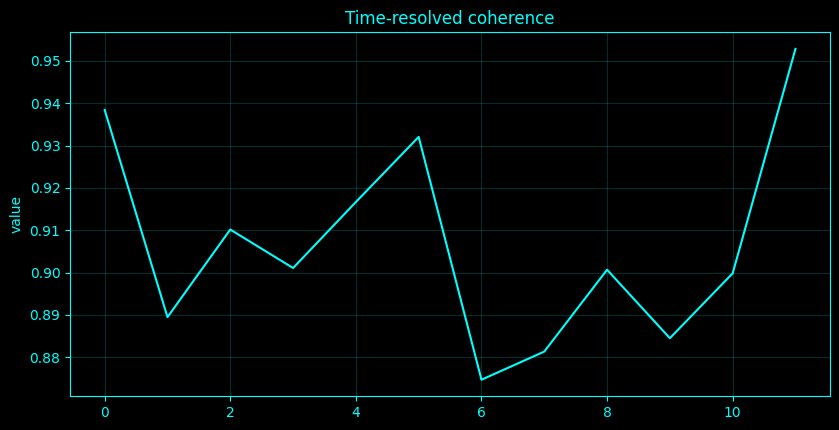

In [47]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _coherence_matrix(band=(8, 13), phase=False):
    key = ('plv' if phase else 'coh', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    M = np.eye(C)
    if phase:
        ph = np.angle(_analytic_band(band))
        for i in range(C):
            for j in range(i + 1, C):
                v = np.abs(np.mean(np.exp(1j * (ph[:, i] - ph[:, j]))))
                M[i, j] = M[j, i] = v
    else:
        nper = min(int(_SPEED['nperseg']), N)
        for i in range(C):
            for j in range(i + 1, C):
                f, c = signal.coherence(X[:, i], X[:, j], fs=_fs, nperseg=nper, noverlap=nper // 2)
                m = (f >= band[0]) & (f < band[1])
                v = float(np.nanmean(c[m])) if np.any(m) else np.nan
                M[i, j] = M[j, i] = v
    SPEC_CACHE[key] = M
    return M

def _cross_spectral_matrix():
    if 'csm' in SPEC_CACHE:
        return SPEC_CACHE['csm']
    n = min(int(_SPEED['nperseg']), N)
    step = max(1, n // 2)
    win = signal.windows.hann(n)
    acc = None
    count = 0
    for a in range(0, N - n + 1, step):
        F = np.fft.rfft((X[a:a + n] - np.mean(X[a:a + n], axis=0)) * win[:, None], axis=0)
        S = np.einsum('fi,fj->fij', F, np.conj(F)) / (_fs * np.sum(win ** 2))
        acc = S if acc is None else acc + S
        count += 1
    S = acc / max(count, 1)
    f = np.fft.rfftfreq(n, 1 / _fs)
    keep = f <= min(55, 0.49 * _fs)
    SPEC_CACHE['csm'] = (f[keep], S[keep])
    return SPEC_CACHE['csm']

# Method-specific calculation.
def _compute_method_47():
    idx = 47
    name = 'Time-resolved coherence'
    __plot_spec = None
    f, S = _cross_spectral_matrix()
    Sxy = S[:, 0, 1]
    coh_complex = Sxy / np.sqrt(np.real(S[:, 0, 0]) * np.real(S[:, 1, 1]) + EPS)
    m = (f >= 8) & (f < 13)
    nwin = min(12, max(4, N // max(int(_fs * 2), 1)))
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    vals = []
    for a0, b0 in zip(edges[:-1], edges[1:]):
        ff, cc = signal.coherence(X[a0:b0, 0], X[a0:b0, 1], fs=_fs, nperseg=min(128, b0 - a0))
        mm = (ff >= 8) & (ff < 13)
        vals.append(float(np.mean(cc[mm])) if np.any(mm) else np.nan)
    __plot_spec = ('summary', vals, name, None, '', 'value')
    return ({'alpha_coherence_trajectory': vals}, locals().get('__plot_spec', None))
    M = _coherence_matrix(BANDS['alpha'])
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_47,_plot_spec=_compute_method_47()
print('Time-resolved coherence')
if isinstance(result_47,dict):
    for _k,_v in result_47.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_47)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_47)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Time-resolved coherence',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Time-resolved coherence',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Time-resolved coherence',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">48. Band-limited coherence networks</h3>
<p>A band-limited coherence network uses channels as nodes and band-averaged coherence as symmetric edge weights.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Coherence is a frequency-specific measure of linear association between two signals. It compares the magnitude of their cross-spectrum with the power spectra of the individual signals. Values near one mean that a stable linear relationship at that frequency explains a large fraction of the spectral activity, while values near zero indicate weak consistency. High coherence can arise from common input, volume conduction, or shared reference effects, so it should not automatically be interpreted as direct connectivity.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [48]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _coherence_matrix(band=(8, 13), phase=False):
    key = ('plv' if phase else 'coh', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    M = np.eye(C)
    if phase:
        ph = np.angle(_analytic_band(band))
        for i in range(C):
            for j in range(i + 1, C):
                v = np.abs(np.mean(np.exp(1j * (ph[:, i] - ph[:, j]))))
                M[i, j] = M[j, i] = v
    else:
        nper = min(int(_SPEED['nperseg']), N)
        for i in range(C):
            for j in range(i + 1, C):
                f, c = signal.coherence(X[:, i], X[:, j], fs=_fs, nperseg=nper, noverlap=nper // 2)
                m = (f >= band[0]) & (f < band[1])
                v = float(np.nanmean(c[m])) if np.any(m) else np.nan
                M[i, j] = M[j, i] = v
    SPEC_CACHE[key] = M
    return M

def _cross_spectral_matrix():
    if 'csm' in SPEC_CACHE:
        return SPEC_CACHE['csm']
    n = min(int(_SPEED['nperseg']), N)
    step = max(1, n // 2)
    win = signal.windows.hann(n)
    acc = None
    count = 0
    for a in range(0, N - n + 1, step):
        F = np.fft.rfft((X[a:a + n] - np.mean(X[a:a + n], axis=0)) * win[:, None], axis=0)
        S = np.einsum('fi,fj->fij', F, np.conj(F)) / (_fs * np.sum(win ** 2))
        acc = S if acc is None else acc + S
        count += 1
    S = acc / max(count, 1)
    f = np.fft.rfftfreq(n, 1 / _fs)
    keep = f <= min(55, 0.49 * _fs)
    SPEC_CACHE['csm'] = (f[keep], S[keep])
    return SPEC_CACHE['csm']

# Method-specific calculation.
def _compute_method_48():
    idx = 48
    name = 'Band-limited coherence networks'
    __plot_spec = None
    f, S = _cross_spectral_matrix()
    Sxy = S[:, 0, 1]
    coh_complex = Sxy / np.sqrt(np.real(S[:, 0, 0]) * np.real(S[:, 1, 1]) + EPS)
    m = (f >= 8) & (f < 13)
    M = _coherence_matrix(BANDS['alpha'])
    __plot_spec = ('summary', M, name, None, '', 'value')
    return ({'mean_edge': float(np.mean(M[np.triu_indices(C, 1)]))}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_48,_plot_spec=_compute_method_48()
print('Band-limited coherence networks')
if isinstance(result_48,dict):
    for _k,_v in result_48.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_48)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_48)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Band-limited coherence networks',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Band-limited coherence networks',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Band-limited coherence networks',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Band-limited coherence networks
  mean_edge: 0.5759812854835551


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">49. Coherence threshold sweeps</h3>
<p>A threshold sweep varies the coherence cutoff and tracks resulting graph density, revealing whether network conclusions depend strongly on an arbitrary threshold.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Coherence is a frequency-specific measure of linear association between two signals. It compares the magnitude of their cross-spectrum with the power spectra of the individual signals. Values near one mean that a stable linear relationship at that frequency explains a large fraction of the spectral activity, while values near zero indicate weak consistency. High coherence can arise from common input, volume conduction, or shared reference effects, so it should not automatically be interpreted as direct connectivity.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Coherence threshold sweeps
  quantiles: array(10,), mean=0.725
  graph_density: array(10,), mean=0.280303


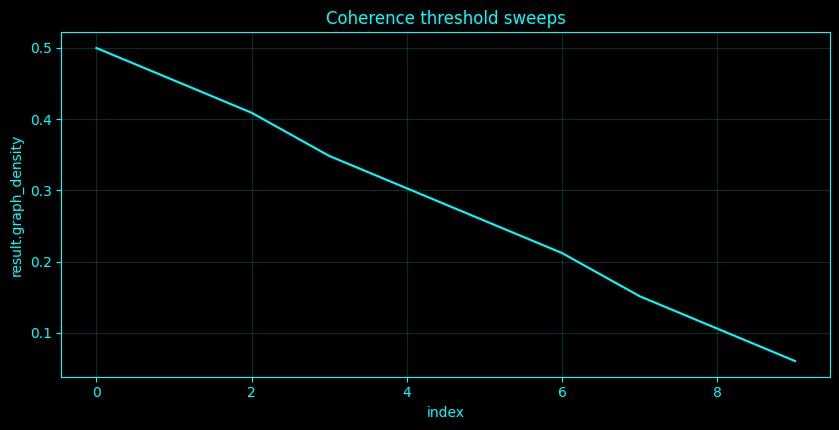

In [49]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _coherence_matrix(band=(8, 13), phase=False):
    key = ('plv' if phase else 'coh', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    M = np.eye(C)
    if phase:
        ph = np.angle(_analytic_band(band))
        for i in range(C):
            for j in range(i + 1, C):
                v = np.abs(np.mean(np.exp(1j * (ph[:, i] - ph[:, j]))))
                M[i, j] = M[j, i] = v
    else:
        nper = min(int(_SPEED['nperseg']), N)
        for i in range(C):
            for j in range(i + 1, C):
                f, c = signal.coherence(X[:, i], X[:, j], fs=_fs, nperseg=nper, noverlap=nper // 2)
                m = (f >= band[0]) & (f < band[1])
                v = float(np.nanmean(c[m])) if np.any(m) else np.nan
                M[i, j] = M[j, i] = v
    SPEC_CACHE[key] = M
    return M

def _cross_spectral_matrix():
    if 'csm' in SPEC_CACHE:
        return SPEC_CACHE['csm']
    n = min(int(_SPEED['nperseg']), N)
    step = max(1, n // 2)
    win = signal.windows.hann(n)
    acc = None
    count = 0
    for a in range(0, N - n + 1, step):
        F = np.fft.rfft((X[a:a + n] - np.mean(X[a:a + n], axis=0)) * win[:, None], axis=0)
        S = np.einsum('fi,fj->fij', F, np.conj(F)) / (_fs * np.sum(win ** 2))
        acc = S if acc is None else acc + S
        count += 1
    S = acc / max(count, 1)
    f = np.fft.rfftfreq(n, 1 / _fs)
    keep = f <= min(55, 0.49 * _fs)
    SPEC_CACHE['csm'] = (f[keep], S[keep])
    return SPEC_CACHE['csm']

# Method-specific calculation.
def _compute_method_49():
    idx = 49
    name = 'Coherence threshold sweeps'
    __plot_spec = None
    f, S = _cross_spectral_matrix()
    Sxy = S[:, 0, 1]
    coh_complex = Sxy / np.sqrt(np.real(S[:, 0, 0]) * np.real(S[:, 1, 1]) + EPS)
    m = (f >= 8) & (f < 13)
    M = _coherence_matrix(BANDS['alpha'])
    vals = M[np.triu_indices(C, 1)]
    qs = np.linspace(0.5, 0.95, 10)
    dens = [float(np.mean(vals >= np.quantile(vals, q))) for q in qs]
    return ({'quantiles': qs.tolist(), 'graph_density': dens}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_49,_plot_spec=_compute_method_49()
print('Coherence threshold sweeps')
if isinstance(result_49,dict):
    for _k,_v in result_49.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_49)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_49)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Coherence threshold sweeps',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Coherence threshold sweeps',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Coherence threshold sweeps',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">50. Coherence graph spectra</h3>
<p>The coherence graph Laplacian is \(L=D-W\). Its eigenvalue spectrum summarizes connectivity scale and graph connectedness.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Jacobian matrix is the local linear approximation of how small changes in each state variable affect the next state. Its eigenvalues and eigenvectors summarize locally preferred directions of growth, decay, or rotation. For a discrete-time map, eigenvalue magnitude below one indicates local contraction and magnitude above one indicates local expansion; for continuous-time systems, the sign of the real part is the corresponding stability indicator. When the Jacobian is estimated from data, these conclusions are local and depend on the quality of the regression or neighborhood used to estimate it.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Coherence graph spectra
  lambda: array(12,), mean=6.33579
  lambda2: 5.08369744744264


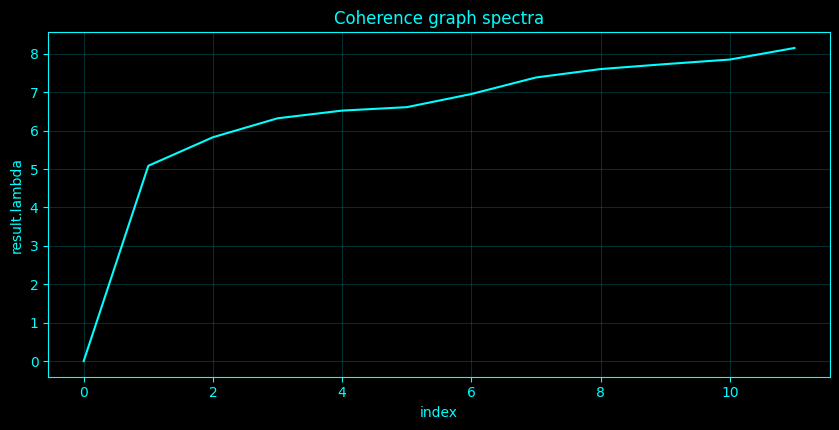

In [50]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _coherence_matrix(band=(8, 13), phase=False):
    key = ('plv' if phase else 'coh', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    M = np.eye(C)
    if phase:
        ph = np.angle(_analytic_band(band))
        for i in range(C):
            for j in range(i + 1, C):
                v = np.abs(np.mean(np.exp(1j * (ph[:, i] - ph[:, j]))))
                M[i, j] = M[j, i] = v
    else:
        nper = min(int(_SPEED['nperseg']), N)
        for i in range(C):
            for j in range(i + 1, C):
                f, c = signal.coherence(X[:, i], X[:, j], fs=_fs, nperseg=nper, noverlap=nper // 2)
                m = (f >= band[0]) & (f < band[1])
                v = float(np.nanmean(c[m])) if np.any(m) else np.nan
                M[i, j] = M[j, i] = v
    SPEC_CACHE[key] = M
    return M

def _cross_spectral_matrix():
    if 'csm' in SPEC_CACHE:
        return SPEC_CACHE['csm']
    n = min(int(_SPEED['nperseg']), N)
    step = max(1, n // 2)
    win = signal.windows.hann(n)
    acc = None
    count = 0
    for a in range(0, N - n + 1, step):
        F = np.fft.rfft((X[a:a + n] - np.mean(X[a:a + n], axis=0)) * win[:, None], axis=0)
        S = np.einsum('fi,fj->fij', F, np.conj(F)) / (_fs * np.sum(win ** 2))
        acc = S if acc is None else acc + S
        count += 1
    S = acc / max(count, 1)
    f = np.fft.rfftfreq(n, 1 / _fs)
    keep = f <= min(55, 0.49 * _fs)
    SPEC_CACHE['csm'] = (f[keep], S[keep])
    return SPEC_CACHE['csm']

# Method-specific calculation.
def _compute_method_50():
    idx = 50
    name = 'Coherence graph spectra'
    __plot_spec = None
    f, S = _cross_spectral_matrix()
    Sxy = S[:, 0, 1]
    coh_complex = Sxy / np.sqrt(np.real(S[:, 0, 0]) * np.real(S[:, 1, 1]) + EPS)
    m = (f >= 8) & (f < 13)
    M = _coherence_matrix(BANDS['alpha'])
    A = M.copy()
    np.fill_diagonal(A, 0)
    L = np.diag(A.sum(1)) - A
    lam = np.linalg.eigvalsh(L)
    return ({'lambda': lam.tolist(), 'lambda2': float(lam[1]) if C > 1 else 0}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_50,_plot_spec=_compute_method_50()
print('Coherence graph spectra')
if isinstance(result_50,dict):
    for _k,_v in result_50.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_50)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_50)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Coherence graph spectra',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Coherence graph spectra',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Coherence graph spectra',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">51. Coherence community dynamics</h3>
<p>Coherence community dynamics recomputes thresholded coupling graphs across time windows and tracks their modular partitions.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Coherence is a frequency-specific measure of linear association between two signals. It compares the magnitude of their cross-spectrum with the power spectra of the individual signals. Values near one mean that a stable linear relationship at that frequency explains a large fraction of the spectral activity, while values near zero indicate weak consistency. High coherence can arise from common input, volume conduction, or shared reference effects, so it should not automatically be interpreted as direct connectivity.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


Coherence community dynamics
  community_count_trajectory: array(6,), mean=4.83333


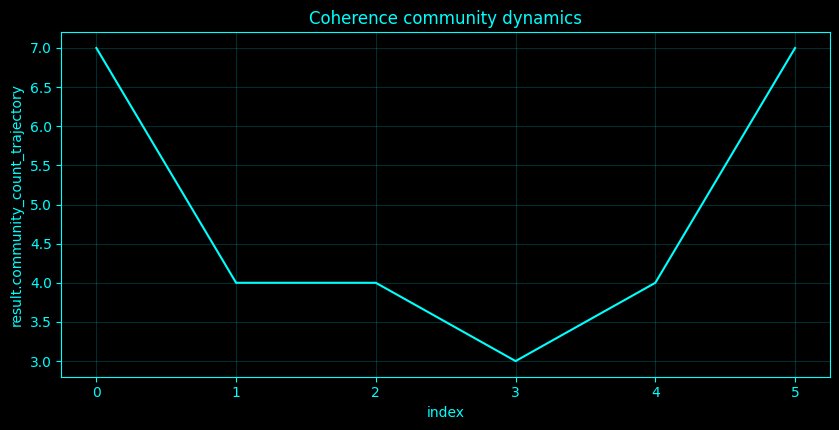

In [51]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _coherence_matrix(band=(8, 13), phase=False):
    key = ('plv' if phase else 'coh', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    M = np.eye(C)
    if phase:
        ph = np.angle(_analytic_band(band))
        for i in range(C):
            for j in range(i + 1, C):
                v = np.abs(np.mean(np.exp(1j * (ph[:, i] - ph[:, j]))))
                M[i, j] = M[j, i] = v
    else:
        nper = min(int(_SPEED['nperseg']), N)
        for i in range(C):
            for j in range(i + 1, C):
                f, c = signal.coherence(X[:, i], X[:, j], fs=_fs, nperseg=nper, noverlap=nper // 2)
                m = (f >= band[0]) & (f < band[1])
                v = float(np.nanmean(c[m])) if np.any(m) else np.nan
                M[i, j] = M[j, i] = v
    SPEC_CACHE[key] = M
    return M

def _graph_from_matrix(M, quant=0.75):
    A = np.array(M, float, copy=True)
    np.fill_diagonal(A, 0)
    vals = A[np.triu_indices_from(A, 1)]
    th = np.nanquantile(vals, quant) if len(vals) else 0
    G = nx.Graph()
    G.add_nodes_from(range(len(A)))
    for i in range(len(A)):
        for j in range(i + 1, len(A)):
            if np.isfinite(A[i, j]) and A[i, j] >= th:
                G.add_edge(i, j, weight=float(A[i, j]), length=float(1 / (A[i, j] + EPS)))
    return G

def _bandpass_matrix(band):
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    return signal.sosfiltfilt(sos, X, axis=0)

def _cross_spectral_matrix():
    if 'csm' in SPEC_CACHE:
        return SPEC_CACHE['csm']
    n = min(int(_SPEED['nperseg']), N)
    step = max(1, n // 2)
    win = signal.windows.hann(n)
    acc = None
    count = 0
    for a in range(0, N - n + 1, step):
        F = np.fft.rfft((X[a:a + n] - np.mean(X[a:a + n], axis=0)) * win[:, None], axis=0)
        S = np.einsum('fi,fj->fij', F, np.conj(F)) / (_fs * np.sum(win ** 2))
        acc = S if acc is None else acc + S
        count += 1
    S = acc / max(count, 1)
    f = np.fft.rfftfreq(n, 1 / _fs)
    keep = f <= min(55, 0.49 * _fs)
    SPEC_CACHE['csm'] = (f[keep], S[keep])
    return SPEC_CACHE['csm']

# Method-specific calculation.
def _compute_method_51():
    idx = 51
    name = 'Coherence community dynamics'
    __plot_spec = None
    f, S = _cross_spectral_matrix()
    Sxy = S[:, 0, 1]
    coh_complex = Sxy / np.sqrt(np.real(S[:, 0, 0]) * np.real(S[:, 1, 1]) + EPS)
    m = (f >= 8) & (f < 13)
    M = _coherence_matrix(BANDS['alpha'])
    nwin = min(6, max(3, N // max(int(_fs * 4), 1)))
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    counts = []
    for a0, b0 in zip(edges[:-1], edges[1:]):
        R = np.corrcoef(_bandpass_matrix(BANDS['alpha'])[a0:b0], rowvar=False)
        G = _graph_from_matrix(np.abs(R), 0.75)
        comm = list(nx.community.greedy_modularity_communities(G, weight='weight')) if G.number_of_edges() else []
        counts.append(len(comm))
    return ({'community_count_trajectory': counts}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_51,_plot_spec=_compute_method_51()
print('Coherence community dynamics')
if isinstance(result_51,dict):
    for _k,_v in result_51.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_51)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_51)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Coherence community dynamics',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Coherence community dynamics',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Coherence community dynamics',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">52. Coherence source-sink asymmetry</h3>
<p>Magnitude-squared coherence is symmetric, \(C_{ij}=C_{ji}\); therefore source/sink direction is not identifiable from coherence alone. This cell explicitly verifies that its antisymmetric component is zero.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Coherence is a frequency-specific measure of linear association between two signals. It compares the magnitude of their cross-spectrum with the power spectra of the individual signals. Values near one mean that a stable linear relationship at that frequency explains a large fraction of the spectral activity, while values near zero indicate weak consistency. High coherence can arise from common input, volume conduction, or shared reference effects, so it should not automatically be interpreted as direct connectivity.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [52]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _coherence_matrix(band=(8, 13), phase=False):
    key = ('plv' if phase else 'coh', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    M = np.eye(C)
    if phase:
        ph = np.angle(_analytic_band(band))
        for i in range(C):
            for j in range(i + 1, C):
                v = np.abs(np.mean(np.exp(1j * (ph[:, i] - ph[:, j]))))
                M[i, j] = M[j, i] = v
    else:
        nper = min(int(_SPEED['nperseg']), N)
        for i in range(C):
            for j in range(i + 1, C):
                f, c = signal.coherence(X[:, i], X[:, j], fs=_fs, nperseg=nper, noverlap=nper // 2)
                m = (f >= band[0]) & (f < band[1])
                v = float(np.nanmean(c[m])) if np.any(m) else np.nan
                M[i, j] = M[j, i] = v
    SPEC_CACHE[key] = M
    return M

def _cross_spectral_matrix():
    if 'csm' in SPEC_CACHE:
        return SPEC_CACHE['csm']
    n = min(int(_SPEED['nperseg']), N)
    step = max(1, n // 2)
    win = signal.windows.hann(n)
    acc = None
    count = 0
    for a in range(0, N - n + 1, step):
        F = np.fft.rfft((X[a:a + n] - np.mean(X[a:a + n], axis=0)) * win[:, None], axis=0)
        S = np.einsum('fi,fj->fij', F, np.conj(F)) / (_fs * np.sum(win ** 2))
        acc = S if acc is None else acc + S
        count += 1
    S = acc / max(count, 1)
    f = np.fft.rfftfreq(n, 1 / _fs)
    keep = f <= min(55, 0.49 * _fs)
    SPEC_CACHE['csm'] = (f[keep], S[keep])
    return SPEC_CACHE['csm']

# Method-specific calculation.
def _compute_method_52():
    idx = 52
    name = 'Coherence source-sink asymmetry'
    __plot_spec = None
    f, S = _cross_spectral_matrix()
    Sxy = S[:, 0, 1]
    coh_complex = Sxy / np.sqrt(np.real(S[:, 0, 0]) * np.real(S[:, 1, 1]) + EPS)
    m = (f >= 8) & (f < 13)
    M = _coherence_matrix(BANDS['alpha'])
    asym = M - M.T
    return ({'max_coherence_source_sink_asymmetry': float(np.max(np.abs(asym))), 'note': 'magnitude-squared coherence is symmetric, so source/sink direction is undefined'}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_52,_plot_spec=_compute_method_52()
print('Coherence source-sink asymmetry')
if isinstance(result_52,dict):
    for _k,_v in result_52.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_52)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_52)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Coherence source-sink asymmetry',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Coherence source-sink asymmetry',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Coherence source-sink asymmetry',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Coherence source-sink asymmetry
  max_coherence_source_sink_asymmetry: 0.0
  note: magnitude-squared coherence is symmetric, so source/sink direction is undefined


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">53. Coherence surrogate testing</h3>
<p>Coherence surrogate testing compares observed band coherence with phase-randomized null signals that preserve individual spectra but disrupt stable cross-channel phase relations.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A surrogate test creates artificial signals that preserve selected simple properties of the original data while deliberately removing the structure being tested. IAAFT surrogates approximately preserve the amplitude distribution and power spectrum, and therefore much of the linear autocorrelation structure, while randomizing nonlinear temporal organization. The observed statistic is then compared with the surrogate distribution. A small surrogate-based p-value means the observed statistic is unusual under that null model; it does not by itself identify the biological mechanism responsible for the difference.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Coherence surrogate testing
  observed: 0.9156869278883186
  surrogate_p: 0.1111111111111111


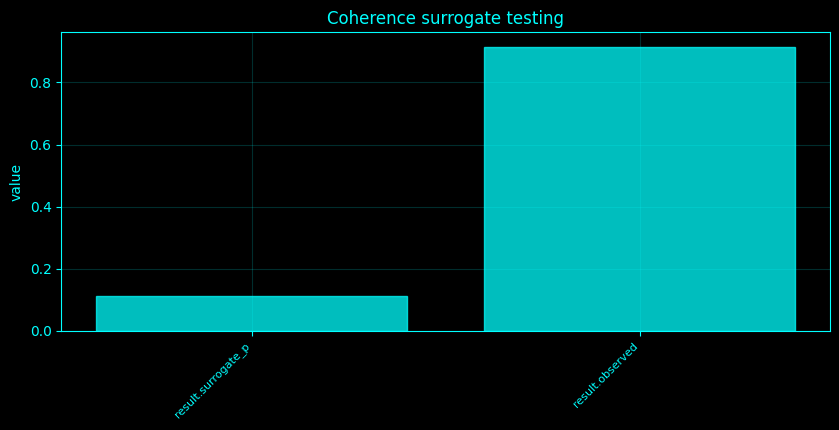

In [53]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _coherence_matrix(band=(8, 13), phase=False):
    key = ('plv' if phase else 'coh', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    M = np.eye(C)
    if phase:
        ph = np.angle(_analytic_band(band))
        for i in range(C):
            for j in range(i + 1, C):
                v = np.abs(np.mean(np.exp(1j * (ph[:, i] - ph[:, j]))))
                M[i, j] = M[j, i] = v
    else:
        nper = min(int(_SPEED['nperseg']), N)
        for i in range(C):
            for j in range(i + 1, C):
                f, c = signal.coherence(X[:, i], X[:, j], fs=_fs, nperseg=nper, noverlap=nper // 2)
                m = (f >= band[0]) & (f < band[1])
                v = float(np.nanmean(c[m])) if np.any(m) else np.nan
                M[i, j] = M[j, i] = v
    SPEC_CACHE[key] = M
    return M

def _phase_randomize(x, rng):
    xf = np.fft.rfft(x, axis=0)
    ph = rng.uniform(0, 2 * np.pi, size=xf.shape)
    ph[0] = 0
    if x.shape[0] % 2 == 0:
        ph[-1] = 0
    return np.fft.irfft(np.abs(xf) * np.exp(1j * ph), n=x.shape[0], axis=0)

def _cross_spectral_matrix():
    if 'csm' in SPEC_CACHE:
        return SPEC_CACHE['csm']
    n = min(int(_SPEED['nperseg']), N)
    step = max(1, n // 2)
    win = signal.windows.hann(n)
    acc = None
    count = 0
    for a in range(0, N - n + 1, step):
        F = np.fft.rfft((X[a:a + n] - np.mean(X[a:a + n], axis=0)) * win[:, None], axis=0)
        S = np.einsum('fi,fj->fij', F, np.conj(F)) / (_fs * np.sum(win ** 2))
        acc = S if acc is None else acc + S
        count += 1
    S = acc / max(count, 1)
    f = np.fft.rfftfreq(n, 1 / _fs)
    keep = f <= min(55, 0.49 * _fs)
    SPEC_CACHE['csm'] = (f[keep], S[keep])
    return SPEC_CACHE['csm']

# Method-specific calculation.
def _compute_method_53():
    idx = 53
    name = 'Coherence surrogate testing'
    __plot_spec = None
    f, S = _cross_spectral_matrix()
    Sxy = S[:, 0, 1]
    coh_complex = Sxy / np.sqrt(np.real(S[:, 0, 0]) * np.real(S[:, 1, 1]) + EPS)
    m = (f >= 8) & (f < 13)
    M = _coherence_matrix(BANDS['alpha'])
    obs = M[0, 1]
    null = []
    for _ in range(_SPEED['n_sur']):
        Surr = _phase_randomize(X[:, :2], _rng)
        ff, cc = signal.coherence(Surr[:, 0], Surr[:, 1], fs=_fs, nperseg=min(_SPEED['nperseg'], N))
        mm = (ff >= 8) & (ff < 13)
        null.append(float(np.mean(cc[mm])))
    return ({'observed': float(obs), 'surrogate_p': float((1 + np.sum(np.asarray(null) >= obs)) / (1 + len(null)))}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_53,_plot_spec=_compute_method_53()
print('Coherence surrogate testing')
if isinstance(result_53,dict):
    for _k,_v in result_53.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_53)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_53)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Coherence surrogate testing',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Coherence surrogate testing',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Coherence surrogate testing',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">54. Phase-locking value</h3>
<p>PLV is the resultant length \(|N^{-1}\sum_te^{i(\phi_x-\phi_y)}|\). It ranges from 0 for dispersed phase differences to 1 for a fixed phase relation.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Phase-locking value measures how consistent the phase difference between two signals is across samples, trials, or windows. Each phase difference is converted to a unit complex number on the circle and these vectors are averaged. If phase differences are almost identical, the vectors point in the same direction and the average magnitude approaches one. If phase differences are widely spread, they cancel and the magnitude approaches zero. PLV ignores amplitude and does not establish causal influence.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. An exponential describes multiplicative growth or decay. In dynamical systems, a positive exponent corresponds to growth with time and a negative exponent to decay. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [54]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _phase_pair(band=(8, 13), i=0, j=1):
    A = _analytic_band(band)
    d = np.angle(A[:, i]) - np.angle(A[:, j])
    return (d, A[:, i], A[:, j])

def _plv(d):
    return float(np.abs(np.mean(np.exp(1j * d))))

# Method-specific calculation.
def _compute_method_54():
    idx = 54
    name = 'Phase-locking value'
    __plot_spec = None
    d, z1, z2 = _phase_pair(BANDS['alpha'], 0, min(1, C - 1))
    return ({'PLV': _plv(d)}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_54,_plot_spec=_compute_method_54()
print('Phase-locking value')
if isinstance(result_54,dict):
    for _k,_v in result_54.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_54)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_54)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Phase-locking value',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Phase-locking value',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Phase-locking value',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Phase-locking value
  PLV: 0.9066900048858567


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">55. Pairwise phase consistency</h3>
<p>Pairwise phase consistency removes PLV's leading sample-size bias: \(PPC=(|\sum z_t|^2-N)/[N(N-1)]\), \(z_t=e^{i\Delta\phi_t}\).</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Phase-locking value measures how consistent the phase difference between two signals is across samples, trials, or windows. Each phase difference is converted to a unit complex number on the circle and these vectors are averaged. If phase differences are almost identical, the vectors point in the same direction and the average magnitude approaches one. If phase differences are widely spread, they cancel and the magnitude approaches zero. PLV ignores amplitude and does not establish causal influence.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. An exponential describes multiplicative growth or decay. In dynamical systems, a positive exponent corresponds to growth with time and a negative exponent to decay. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [55]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _phase_pair(band=(8, 13), i=0, j=1):
    A = _analytic_band(band)
    d = np.angle(A[:, i]) - np.angle(A[:, j])
    return (d, A[:, i], A[:, j])

def _ppc(d):
    z = np.exp(1j * np.asarray(d))
    n = len(z)
    return float((np.abs(np.sum(z)) ** 2 - n) / (n * (n - 1) + EPS))

# Method-specific calculation.
def _compute_method_55():
    idx = 55
    name = 'Pairwise phase consistency'
    __plot_spec = None
    d, z1, z2 = _phase_pair(BANDS['alpha'], 0, min(1, C - 1))
    return ({'PPC': _ppc(d)}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_55,_plot_spec=_compute_method_55()
print('Pairwise phase consistency')
if isinstance(result_55,dict):
    for _k,_v in result_55.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_55)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_55)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Pairwise phase consistency',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Pairwise phase consistency',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Pairwise phase consistency',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Pairwise phase consistency
  PPC: 0.8220734550747468


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">56. Phase-lag index</h3>
<p>Phase-lag index is \(\mathrm{PLI}=|E[\operatorname{sign}(\sin\Delta\phi)]|\), emphasizing consistent nonzero-lag phase sign.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. Expectation or angle-bracket notation denotes an average with respect to a probability distribution or ensemble. Greek phase symbols such as φ or θ represent angular position on a cycle. Because phase wraps around, differences are interpreted modulo one full cycle.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [56]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _phase_pair(band=(8, 13), i=0, j=1):
    A = _analytic_band(band)
    d = np.angle(A[:, i]) - np.angle(A[:, j])
    return (d, A[:, i], A[:, j])

def _pli(d):
    return float(np.abs(np.mean(np.sign(np.sin(d)))))

# Method-specific calculation.
def _compute_method_56():
    idx = 56
    name = 'Phase-lag index'
    __plot_spec = None
    d, z1, z2 = _phase_pair(BANDS['alpha'], 0, min(1, C - 1))
    return ({'PLI': _pli(d)}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_56,_plot_spec=_compute_method_56()
print('Phase-lag index')
if isinstance(result_56,dict):
    for _k,_v in result_56.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_56)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_56)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Phase-lag index',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Phase-lag index',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Phase-lag index',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Phase-lag index
  PLI: 0.03665469778575703


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">57. Weighted phase-lag index</h3>
<p>Weighted PLI is \(|E[\Im Z]|/E[|\Im Z|]\) for complex cross-products \(Z\), weighting observations by imaginary cross-spectral magnitude.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. Expectation or angle-bracket notation denotes an average with respect to a probability distribution or ensemble.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [57]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _phase_pair(band=(8, 13), i=0, j=1):
    A = _analytic_band(band)
    d = np.angle(A[:, i]) - np.angle(A[:, j])
    return (d, A[:, i], A[:, j])

def _wpli(d, z1=None, z2=None, debiased=False):
    if z1 is None:
        im = np.sin(d)
    else:
        im = np.imag(z1 * np.conj(z2))
    if debiased:
        num = np.sum(im) ** 2 - np.sum(im ** 2)
        den = np.sum(np.abs(im)) ** 2 - np.sum(im ** 2)
        return float(max(0, num / (den + EPS)))
    return float(np.abs(np.mean(im)) / (np.mean(np.abs(im)) + EPS))

# Method-specific calculation.
def _compute_method_57():
    idx = 57
    name = 'Weighted phase-lag index'
    __plot_spec = None
    d, z1, z2 = _phase_pair(BANDS['alpha'], 0, min(1, C - 1))
    return ({'wPLI': _wpli(d, z1, z2)}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_57,_plot_spec=_compute_method_57()
print('Weighted phase-lag index')
if isinstance(result_57,dict):
    for _k,_v in result_57.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_57)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_57)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Weighted phase-lag index',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Weighted phase-lag index',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Weighted phase-lag index',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Weighted phase-lag index
  wPLI: 0.07245091147527129


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">58. Debiased weighted phase-lag index</h3>
<p>Debiased squared wPLI removes the diagonal/self-product bias: \([(\sum I)^2-\sum I^2]/[(\sum|I|)^2-\sum I^2]\), where \(I=\Im Z\).</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [58]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _phase_pair(band=(8, 13), i=0, j=1):
    A = _analytic_band(band)
    d = np.angle(A[:, i]) - np.angle(A[:, j])
    return (d, A[:, i], A[:, j])

def _wpli(d, z1=None, z2=None, debiased=False):
    if z1 is None:
        im = np.sin(d)
    else:
        im = np.imag(z1 * np.conj(z2))
    if debiased:
        num = np.sum(im) ** 2 - np.sum(im ** 2)
        den = np.sum(np.abs(im)) ** 2 - np.sum(im ** 2)
        return float(max(0, num / (den + EPS)))
    return float(np.abs(np.mean(im)) / (np.mean(np.abs(im)) + EPS))

# Method-specific calculation.
def _compute_method_58():
    idx = 58
    name = 'Debiased weighted phase-lag index'
    __plot_spec = None
    d, z1, z2 = _phase_pair(BANDS['alpha'], 0, min(1, C - 1))
    return ({'debiased_wPLI_squared': _wpli(d, z1, z2, True)}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_58,_plot_spec=_compute_method_58()
print('Debiased weighted phase-lag index')
if isinstance(result_58,dict):
    for _k,_v in result_58.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_58)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_58)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Debiased weighted phase-lag index',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Debiased weighted phase-lag index',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Debiased weighted phase-lag index',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Debiased weighted phase-lag index
  debiased_wPLI_squared: 0.0


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">59. Imaginary phase-locking value</h3>
<p>Imaginary PLV reports \(|\Im E[e^{i\Delta\phi}]|\), the nonzero-lag component of the phase-difference resultant.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Phase-locking value measures how consistent the phase difference between two signals is across samples, trials, or windows. Each phase difference is converted to a unit complex number on the circle and these vectors are averaged. If phase differences are almost identical, the vectors point in the same direction and the average magnitude approaches one. If phase differences are widely spread, they cancel and the magnitude approaches zero. PLV ignores amplitude and does not establish causal influence.</p><p><b>How to read the mathematics.</b> An exponential describes multiplicative growth or decay. In dynamical systems, a positive exponent corresponds to growth with time and a negative exponent to decay. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. Expectation or angle-bracket notation denotes an average with respect to a probability distribution or ensemble.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [59]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _phase_pair(band=(8, 13), i=0, j=1):
    A = _analytic_band(band)
    d = np.angle(A[:, i]) - np.angle(A[:, j])
    return (d, A[:, i], A[:, j])

# Method-specific calculation.
def _compute_method_59():
    idx = 59
    name = 'Imaginary phase-locking value'
    __plot_spec = None
    d, z1, z2 = _phase_pair(BANDS['alpha'], 0, min(1, C - 1))
    return ({'imaginary_PLV': float(np.abs(np.imag(np.mean(np.exp(1j * d)))))}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_59,_plot_spec=_compute_method_59()
print('Imaginary phase-locking value')
if isinstance(result_59,dict):
    for _k,_v in result_59.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_59)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_59)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Imaginary phase-locking value',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Imaginary phase-locking value',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Imaginary phase-locking value',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Imaginary phase-locking value
  imaginary_PLV: 0.007079784744607911


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">60. Inter-site phase clustering</h3>
<p>Inter-site phase clustering is the same circular resultant-length statistic as PLV, \(|E[e^{i\Delta\phi}]|\); the cell states this equivalence explicitly.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Phase-locking value measures how consistent the phase difference between two signals is across samples, trials, or windows. Each phase difference is converted to a unit complex number on the circle and these vectors are averaged. If phase differences are almost identical, the vectors point in the same direction and the average magnitude approaches one. If phase differences are widely spread, they cancel and the magnitude approaches zero. PLV ignores amplitude and does not establish causal influence.</p><p><b>How to read the mathematics.</b> An exponential describes multiplicative growth or decay. In dynamical systems, a positive exponent corresponds to growth with time and a negative exponent to decay. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. Expectation or angle-bracket notation denotes an average with respect to a probability distribution or ensemble.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [60]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _phase_pair(band=(8, 13), i=0, j=1):
    A = _analytic_band(band)
    d = np.angle(A[:, i]) - np.angle(A[:, j])
    return (d, A[:, i], A[:, j])

def _plv(d):
    return float(np.abs(np.mean(np.exp(1j * d))))

# Method-specific calculation.
def _compute_method_60():
    idx = 60
    name = 'Inter-site phase clustering'
    __plot_spec = None
    d, z1, z2 = _phase_pair(BANDS['alpha'], 0, min(1, C - 1))
    return ({'inter_site_phase_clustering': _plv(d), 'note': 'ISPC and PLV use the same resultant-length statistic'}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_60,_plot_spec=_compute_method_60()
print('Inter-site phase clustering')
if isinstance(result_60,dict):
    for _k,_v in result_60.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_60)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_60)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Inter-site phase clustering',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Inter-site phase clustering',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Inter-site phase clustering',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Inter-site phase clustering
  inter_site_phase_clustering: 0.9066900048858567
  note: ISPC and PLV use the same resultant-length statistic


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">61. Phase-slope index</h3>
<p>Phase-slope index exploits the frequency derivative of coherency phase: \(\Psi=\sum_f\Im[C^\ast(f)C(f+\Delta f)]\). Its sign indicates lead/lag direction under the PSI convention.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [61]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _cross_spectral_matrix():
    if 'csm' in SPEC_CACHE:
        return SPEC_CACHE['csm']
    n = min(int(_SPEED['nperseg']), N)
    step = max(1, n // 2)
    win = signal.windows.hann(n)
    acc = None
    count = 0
    for a in range(0, N - n + 1, step):
        F = np.fft.rfft((X[a:a + n] - np.mean(X[a:a + n], axis=0)) * win[:, None], axis=0)
        S = np.einsum('fi,fj->fij', F, np.conj(F)) / (_fs * np.sum(win ** 2))
        acc = S if acc is None else acc + S
        count += 1
    S = acc / max(count, 1)
    f = np.fft.rfftfreq(n, 1 / _fs)
    keep = f <= min(55, 0.49 * _fs)
    SPEC_CACHE['csm'] = (f[keep], S[keep])
    return SPEC_CACHE['csm']

def _phase_pair(band=(8, 13), i=0, j=1):
    A = _analytic_band(band)
    d = np.angle(A[:, i]) - np.angle(A[:, j])
    return (d, A[:, i], A[:, j])

def _psi_pair(i=0, j=1):
    f, S = _cross_spectral_matrix()
    Sxy = S[:, i, j]
    coh = Sxy / np.sqrt(np.real(S[:, i, i]) * np.real(S[:, j, j]) + EPS)
    psi = np.imag(np.conj(coh[:-1]) * coh[1:])
    return (f[1:], psi)

# Method-specific calculation.
def _compute_method_61():
    idx = 61
    name = 'Phase-slope index'
    __plot_spec = None
    d, z1, z2 = _phase_pair(BANDS['alpha'], 0, min(1, C - 1))
    ff, psi = _psi_pair()
    mm = (ff >= 8) & (ff < 13)
    v = float(np.sum(psi[mm]))
    return ({'PSI': v if idx == 62 else abs(v), 'direction_sign': np.sign(v) if idx == 62 else None}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_61,_plot_spec=_compute_method_61()
print('Phase-slope index')
if isinstance(result_61,dict):
    for _k,_v in result_61.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_61)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_61)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Phase-slope index',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Phase-slope index',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Phase-slope index',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Phase-slope index
  PSI: 0.015698503969248545
  direction_sign: None


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">62. Directed phase-slope index</h3>
<p>Phase-slope index exploits the frequency derivative of coherency phase: \(\Psi=\sum_f\Im[C^\ast(f)C(f+\Delta f)]\). Its sign indicates lead/lag direction under the PSI convention.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Directed phase-slope index
  PSI: -0.015698503969248545
  direction_sign: -1.0


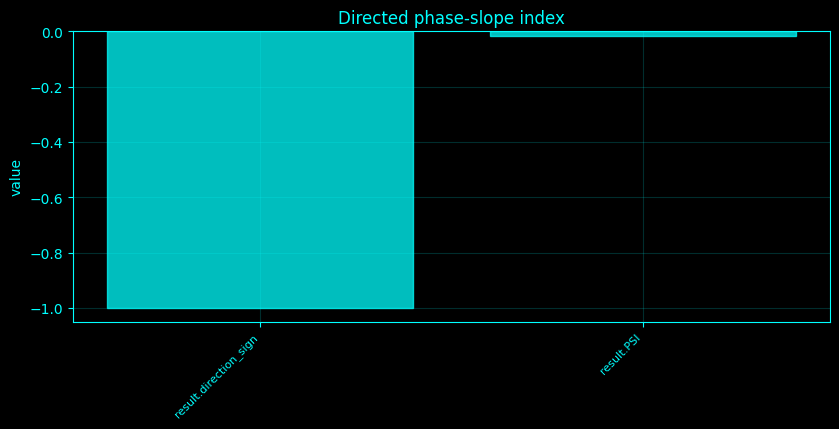

In [62]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _cross_spectral_matrix():
    if 'csm' in SPEC_CACHE:
        return SPEC_CACHE['csm']
    n = min(int(_SPEED['nperseg']), N)
    step = max(1, n // 2)
    win = signal.windows.hann(n)
    acc = None
    count = 0
    for a in range(0, N - n + 1, step):
        F = np.fft.rfft((X[a:a + n] - np.mean(X[a:a + n], axis=0)) * win[:, None], axis=0)
        S = np.einsum('fi,fj->fij', F, np.conj(F)) / (_fs * np.sum(win ** 2))
        acc = S if acc is None else acc + S
        count += 1
    S = acc / max(count, 1)
    f = np.fft.rfftfreq(n, 1 / _fs)
    keep = f <= min(55, 0.49 * _fs)
    SPEC_CACHE['csm'] = (f[keep], S[keep])
    return SPEC_CACHE['csm']

def _phase_pair(band=(8, 13), i=0, j=1):
    A = _analytic_band(band)
    d = np.angle(A[:, i]) - np.angle(A[:, j])
    return (d, A[:, i], A[:, j])

def _psi_pair(i=0, j=1):
    f, S = _cross_spectral_matrix()
    Sxy = S[:, i, j]
    coh = Sxy / np.sqrt(np.real(S[:, i, i]) * np.real(S[:, j, j]) + EPS)
    psi = np.imag(np.conj(coh[:-1]) * coh[1:])
    return (f[1:], psi)

# Method-specific calculation.
def _compute_method_62():
    idx = 62
    name = 'Directed phase-slope index'
    __plot_spec = None
    d, z1, z2 = _phase_pair(BANDS['alpha'], 0, min(1, C - 1))
    ff, psi = _psi_pair()
    mm = (ff >= 8) & (ff < 13)
    v = float(np.sum(psi[mm]))
    return ({'PSI': v if idx == 62 else abs(v), 'direction_sign': np.sign(v) if idx == 62 else None}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_62,_plot_spec=_compute_method_62()
print('Directed phase-slope index')
if isinstance(result_62,dict):
    for _k,_v in result_62.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_62)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_62)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Directed phase-slope index',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Directed phase-slope index',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Directed phase-slope index',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">63. Frequency-resolved phase-slope maps</h3>
<p>Phase-slope index exploits the frequency derivative of coherency phase: \(\Psi=\sum_f\Im[C^\ast(f)C(f+\Delta f)]\). Its sign indicates lead/lag direction under the PSI convention.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [63]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _cross_spectral_matrix():
    if 'csm' in SPEC_CACHE:
        return SPEC_CACHE['csm']
    n = min(int(_SPEED['nperseg']), N)
    step = max(1, n // 2)
    win = signal.windows.hann(n)
    acc = None
    count = 0
    for a in range(0, N - n + 1, step):
        F = np.fft.rfft((X[a:a + n] - np.mean(X[a:a + n], axis=0)) * win[:, None], axis=0)
        S = np.einsum('fi,fj->fij', F, np.conj(F)) / (_fs * np.sum(win ** 2))
        acc = S if acc is None else acc + S
        count += 1
    S = acc / max(count, 1)
    f = np.fft.rfftfreq(n, 1 / _fs)
    keep = f <= min(55, 0.49 * _fs)
    SPEC_CACHE['csm'] = (f[keep], S[keep])
    return SPEC_CACHE['csm']

def _phase_pair(band=(8, 13), i=0, j=1):
    A = _analytic_band(band)
    d = np.angle(A[:, i]) - np.angle(A[:, j])
    return (d, A[:, i], A[:, j])

def _psi_pair(i=0, j=1):
    f, S = _cross_spectral_matrix()
    Sxy = S[:, i, j]
    coh = Sxy / np.sqrt(np.real(S[:, i, i]) * np.real(S[:, j, j]) + EPS)
    psi = np.imag(np.conj(coh[:-1]) * coh[1:])
    return (f[1:], psi)

# Method-specific calculation.
def _compute_method_63():
    idx = 63
    name = 'Frequency-resolved phase-slope maps'
    __plot_spec = None
    d, z1, z2 = _phase_pair(BANDS['alpha'], 0, min(1, C - 1))
    M = np.zeros((C, C))
    for i in range(C):
        for j in range(i + 1, C):
            ff, psi = _psi_pair(i, j)
            mm = (ff >= 8) & (ff < 13)
            v = float(np.sum(psi[mm]))
            M[i, j] = v
            M[j, i] = -v
    __plot_spec = ('summary', M, name, None, '', 'value')
    return ({'max_abs_PSI': float(np.max(np.abs(M)))}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_63,_plot_spec=_compute_method_63()
print('Frequency-resolved phase-slope maps')
if isinstance(result_63,dict):
    for _k,_v in result_63.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_63)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_63)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Frequency-resolved phase-slope maps',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Frequency-resolved phase-slope maps',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Frequency-resolved phase-slope maps',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Frequency-resolved phase-slope maps
  max_abs_PSI: 0.24887057631257092


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">64. Time-resolved PLV</h3>
<p>Time-resolved PLV evaluates the same circular resultant in successive windows.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Phase-locking value measures how consistent the phase difference between two signals is across samples, trials, or windows. Each phase difference is converted to a unit complex number on the circle and these vectors are averaged. If phase differences are almost identical, the vectors point in the same direction and the average magnitude approaches one. If phase differences are widely spread, they cancel and the magnitude approaches zero. PLV ignores amplitude and does not establish causal influence.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


Time-resolved PLV
  PLV_trajectory: array(20,), mean=0.908383


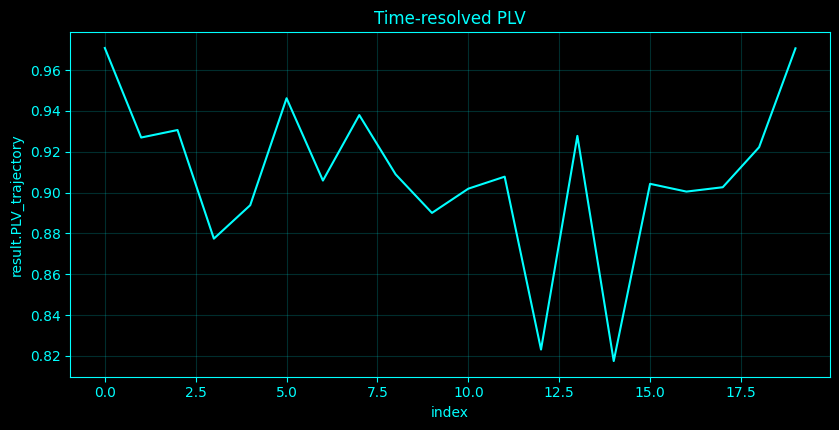

In [64]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _phase_pair(band=(8, 13), i=0, j=1):
    A = _analytic_band(band)
    d = np.angle(A[:, i]) - np.angle(A[:, j])
    return (d, A[:, i], A[:, j])

def _plv(d):
    return float(np.abs(np.mean(np.exp(1j * d))))

# Method-specific calculation.
def _compute_method_64():
    idx = 64
    name = 'Time-resolved PLV'
    __plot_spec = None
    d, z1, z2 = _phase_pair(BANDS['alpha'], 0, min(1, C - 1))
    ph = np.angle(_analytic_band(BANDS['alpha']))
    nwin = min(20, max(5, N // max(int(_fs), 1)))
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    vals = []
    for a0, b0 in zip(edges[:-1], edges[1:]):
        vals.append(_plv(ph[a0:b0, 0] - ph[a0:b0, 1]))
    return ({'PLV_trajectory': vals}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_64,_plot_spec=_compute_method_64()
print('Time-resolved PLV')
if isinstance(result_64,dict):
    for _k,_v in result_64.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_64)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_64)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Time-resolved PLV',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Time-resolved PLV',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Time-resolved PLV',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">65. Band-limited PLV networks</h3>
<p>A band-limited PLV network uses pairwise PLV as symmetric edge weight between channels.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Phase-locking value measures how consistent the phase difference between two signals is across samples, trials, or windows. Each phase difference is converted to a unit complex number on the circle and these vectors are averaged. If phase differences are almost identical, the vectors point in the same direction and the average magnitude approaches one. If phase differences are widely spread, they cancel and the magnitude approaches zero. PLV ignores amplitude and does not establish causal influence.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [65]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _coherence_matrix(band=(8, 13), phase=False):
    key = ('plv' if phase else 'coh', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    M = np.eye(C)
    if phase:
        ph = np.angle(_analytic_band(band))
        for i in range(C):
            for j in range(i + 1, C):
                v = np.abs(np.mean(np.exp(1j * (ph[:, i] - ph[:, j]))))
                M[i, j] = M[j, i] = v
    else:
        nper = min(int(_SPEED['nperseg']), N)
        for i in range(C):
            for j in range(i + 1, C):
                f, c = signal.coherence(X[:, i], X[:, j], fs=_fs, nperseg=nper, noverlap=nper // 2)
                m = (f >= band[0]) & (f < band[1])
                v = float(np.nanmean(c[m])) if np.any(m) else np.nan
                M[i, j] = M[j, i] = v
    SPEC_CACHE[key] = M
    return M

def _phase_pair(band=(8, 13), i=0, j=1):
    A = _analytic_band(band)
    d = np.angle(A[:, i]) - np.angle(A[:, j])
    return (d, A[:, i], A[:, j])

# Method-specific calculation.
def _compute_method_65():
    idx = 65
    name = 'Band-limited PLV networks'
    __plot_spec = None
    d, z1, z2 = _phase_pair(BANDS['alpha'], 0, min(1, C - 1))
    M = _coherence_matrix(BANDS['alpha'], phase=True)
    __plot_spec = ('summary', M, name, None, '', 'value')
    return ({'mean_PPV': float(np.mean(M[np.triu_indices(C, 1)]))}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_65,_plot_spec=_compute_method_65()
print('Band-limited PLV networks')
if isinstance(result_65,dict):
    for _k,_v in result_65.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_65)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_65)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Band-limited PLV networks',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Band-limited PLV networks',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Band-limited PLV networks',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Band-limited PLV networks
  mean_PPV: 0.650445128868172


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">66. Phase-synchrony graph spectra</h3>
<p>Phase-synchrony graph spectra are the Laplacian eigenvalues of the PLV-weighted network.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Jacobian matrix is the local linear approximation of how small changes in each state variable affect the next state. Its eigenvalues and eigenvectors summarize locally preferred directions of growth, decay, or rotation. For a discrete-time map, eigenvalue magnitude below one indicates local contraction and magnitude above one indicates local expansion; for continuous-time systems, the sign of the real part is the corresponding stability indicator. When the Jacobian is estimated from data, these conclusions are local and depend on the quality of the regression or neighborhood used to estimate it.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Phase-synchrony graph spectra
  lambda: array(12,), mean=7.1549


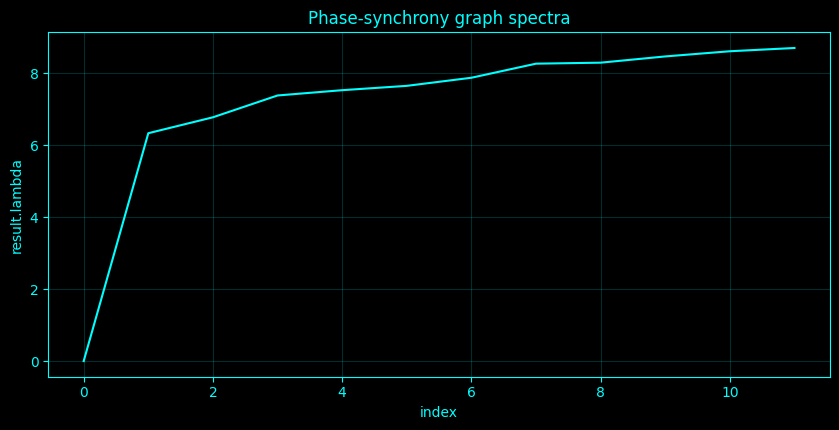

In [66]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _coherence_matrix(band=(8, 13), phase=False):
    key = ('plv' if phase else 'coh', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    M = np.eye(C)
    if phase:
        ph = np.angle(_analytic_band(band))
        for i in range(C):
            for j in range(i + 1, C):
                v = np.abs(np.mean(np.exp(1j * (ph[:, i] - ph[:, j]))))
                M[i, j] = M[j, i] = v
    else:
        nper = min(int(_SPEED['nperseg']), N)
        for i in range(C):
            for j in range(i + 1, C):
                f, c = signal.coherence(X[:, i], X[:, j], fs=_fs, nperseg=nper, noverlap=nper // 2)
                m = (f >= band[0]) & (f < band[1])
                v = float(np.nanmean(c[m])) if np.any(m) else np.nan
                M[i, j] = M[j, i] = v
    SPEC_CACHE[key] = M
    return M

def _phase_pair(band=(8, 13), i=0, j=1):
    A = _analytic_band(band)
    d = np.angle(A[:, i]) - np.angle(A[:, j])
    return (d, A[:, i], A[:, j])

# Method-specific calculation.
def _compute_method_66():
    idx = 66
    name = 'Phase-synchrony graph spectra'
    __plot_spec = None
    d, z1, z2 = _phase_pair(BANDS['alpha'], 0, min(1, C - 1))
    M = _coherence_matrix(BANDS['alpha'], phase=True)
    np.fill_diagonal(M, 0)
    L = np.diag(M.sum(1)) - M
    lam = np.linalg.eigvalsh(L)
    return ({'lambda': lam.tolist()}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_66,_plot_spec=_compute_method_66()
print('Phase-synchrony graph spectra')
if isinstance(result_66,dict):
    for _k,_v in result_66.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_66)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_66)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Phase-synchrony graph spectra',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Phase-synchrony graph spectra',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Phase-synchrony graph spectra',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">67. Phase-synchrony surrogate testing</h3>
<p>PLV surrogate testing circularly shifts one analytic signal relative to the other, preserving each marginal oscillation while breaking persistent alignment.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A surrogate test creates artificial signals that preserve selected simple properties of the original data while deliberately removing the structure being tested. IAAFT surrogates approximately preserve the amplitude distribution and power spectrum, and therefore much of the linear autocorrelation structure, while randomizing nonlinear temporal organization. The observed statistic is then compared with the surrogate distribution. A small surrogate-based p-value means the observed statistic is unusual under that null model; it does not by itself identify the biological mechanism responsible for the difference.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Phase-synchrony surrogate testing
  observed: 0.9066900048858567
  surrogate_p: 0.1111111111111111


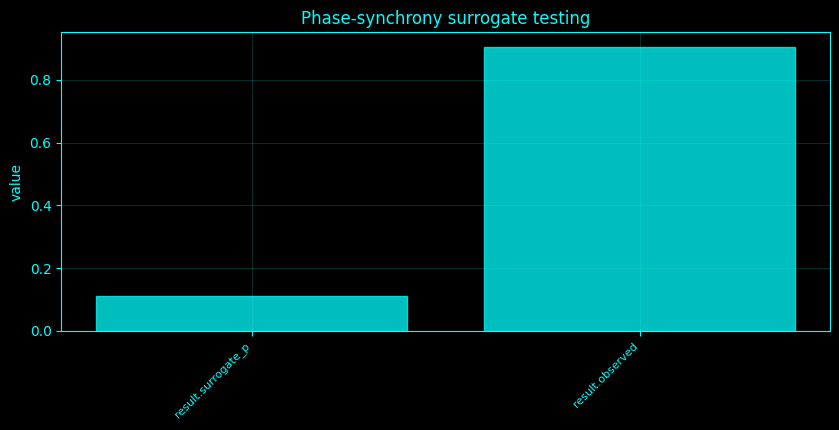

In [67]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _phase_pair(band=(8, 13), i=0, j=1):
    A = _analytic_band(band)
    d = np.angle(A[:, i]) - np.angle(A[:, j])
    return (d, A[:, i], A[:, j])

def _plv(d):
    return float(np.abs(np.mean(np.exp(1j * d))))

# Method-specific calculation.
def _compute_method_67():
    idx = 67
    name = 'Phase-synchrony surrogate testing'
    __plot_spec = None
    d, z1, z2 = _phase_pair(BANDS['alpha'], 0, min(1, C - 1))
    obs = _plv(d)
    null = []
    for _ in range(_SPEED['n_sur']):
        shift = int(_rng.integers(max(1, int(0.2 * _fs)), max(2, N - int(0.2 * _fs))))
        dd = np.angle(z1) - np.angle(np.roll(z2, shift))
        null.append(_plv(dd))
    return ({'observed': obs, 'surrogate_p': float((1 + np.sum(np.asarray(null) >= obs)) / (1 + len(null)))}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_67,_plot_spec=_compute_method_67()
print('Phase-synchrony surrogate testing')
if isinstance(result_67,dict):
    for _k,_v in result_67.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_67)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_67)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Phase-synchrony surrogate testing',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Phase-synchrony surrogate testing',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Phase-synchrony surrogate testing',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">68. Cross-frequency coupling modulation index</h3>
<p>Tort modulation index bins high-frequency amplitude by low-frequency phase, normalizes the bin means to probabilities \(p_k\), and computes \(\mathrm{MI}=D_{KL}(p\|u)/\log K\).</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [68]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _pac_tort(ch=0, phase_band=(4, 8), amp_band=(30, 45), nbins=18):
    p = np.angle(_analytic_band(phase_band)[:, ch])
    a = np.abs(_analytic_band(amp_band)[:, ch])
    edges = np.linspace(-np.pi, np.pi, nbins + 1)
    q = np.array([np.mean(a[(p >= edges[k]) & (p < edges[k + 1])]) for k in range(nbins)])
    q = np.nan_to_num(q, nan=0.0)
    q = q / (q.sum() + EPS)
    u = np.ones(nbins) / nbins
    return float(np.sum(q * np.log((q + EPS) / u)) / np.log(nbins))

# Method-specific calculation.
def _compute_method_68():
    idx = 68
    name = 'Cross-frequency coupling modulation index'
    __plot_spec = None
    return ({'Tort_modulation_index': _pac_tort()}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_68,_plot_spec=_compute_method_68()
print('Cross-frequency coupling modulation index')
if isinstance(result_68,dict):
    for _k,_v in result_68.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_68)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_68)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Cross-frequency coupling modulation index',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Cross-frequency coupling modulation index',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Cross-frequency coupling modulation index',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Cross-frequency coupling modulation index
  Tort_modulation_index: 0.014531283403541095


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">69. Tort phase-amplitude coupling</h3>
<p>Tort modulation index bins high-frequency amplitude by low-frequency phase, normalizes the bin means to probabilities \(p_k\), and computes \(\mathrm{MI}=D_{KL}(p\|u)/\log K\).</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [69]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _pac_tort(ch=0, phase_band=(4, 8), amp_band=(30, 45), nbins=18):
    p = np.angle(_analytic_band(phase_band)[:, ch])
    a = np.abs(_analytic_band(amp_band)[:, ch])
    edges = np.linspace(-np.pi, np.pi, nbins + 1)
    q = np.array([np.mean(a[(p >= edges[k]) & (p < edges[k + 1])]) for k in range(nbins)])
    q = np.nan_to_num(q, nan=0.0)
    q = q / (q.sum() + EPS)
    u = np.ones(nbins) / nbins
    return float(np.sum(q * np.log((q + EPS) / u)) / np.log(nbins))

# Method-specific calculation.
def _compute_method_69():
    idx = 69
    name = 'Tort phase-amplitude coupling'
    __plot_spec = None
    return ({'Tort_modulation_index': _pac_tort()}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_69,_plot_spec=_compute_method_69()
print('Tort phase-amplitude coupling')
if isinstance(result_69,dict):
    for _k,_v in result_69.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_69)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_69)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Tort phase-amplitude coupling',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Tort phase-amplitude coupling',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Tort phase-amplitude coupling',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Tort phase-amplitude coupling
  Tort_modulation_index: 0.014531283403541095


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">70. Canolty phase-amplitude coupling</h3>
<p>Canolty PAC uses the complex composite \(A_H(t)e^{i\phi_L(t)}\); the magnitude of its time average is large when high-frequency amplitude prefers a low-frequency phase.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> An exponential describes multiplicative growth or decay. In dynamical systems, a positive exponent corresponds to growth with time and a negative exponent to decay. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. Greek phase symbols such as φ or θ represent angular position on a cycle. Because phase wraps around, differences are interpreted modulo one full cycle.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [70]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

# Method-specific calculation.
def _compute_method_70():
    idx = 70
    name = 'Canolty phase-amplitude coupling'
    __plot_spec = None
    p = np.angle(_analytic_band(BANDS['theta'])[:, 0])
    a = np.abs(_analytic_band(BANDS['gamma'])[:, 0])
    v = np.abs(np.mean(a * np.exp(1j * p)))
    return ({'Canolty_complex_vector_magnitude': float(v)}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_70,_plot_spec=_compute_method_70()
print('Canolty phase-amplitude coupling')
if isinstance(result_70,dict):
    for _k,_v in result_70.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_70)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_70)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Canolty phase-amplitude coupling',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Canolty phase-amplitude coupling',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Canolty phase-amplitude coupling',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Canolty phase-amplitude coupling
  Canolty_complex_vector_magnitude: 0.009108077186147466


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">71. Mean-vector-length PAC</h3>
<p>Mean-vector-length PAC normalizes the Canolty vector by mean high-frequency amplitude, making the statistic dimensionless.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [71]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _pac_mvl(ch=0, phase_band=(4, 8), amp_band=(30, 45)):
    p = np.angle(_analytic_band(phase_band)[:, ch])
    a = np.abs(_analytic_band(amp_band)[:, ch])
    return float(np.abs(np.mean(a * np.exp(1j * p))) / (np.mean(a) + EPS))

# Method-specific calculation.
def _compute_method_71():
    idx = 71
    name = 'Mean-vector-length PAC'
    __plot_spec = None
    return ({'normalized_mean_vector_length': _pac_mvl()}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_71,_plot_spec=_compute_method_71()
print('Mean-vector-length PAC')
if isinstance(result_71,dict):
    for _k,_v in result_71.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_71)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_71)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Mean-vector-length PAC',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Mean-vector-length PAC',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Mean-vector-length PAC',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Mean-vector-length PAC
  normalized_mean_vector_length: 0.18893690834484422


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">72. General linear model PAC</h3>
<p>GLM PAC regresses high-frequency amplitude on \(\sin\phi_L\) and \(\cos\phi_L\). The reported \(R^2\) quantifies phase-explained amplitude variance.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Regression fits a mathematical relationship between predictors and an outcome by choosing coefficients that minimize a loss, usually squared error. Ridge regression adds a penalty on large coefficients, which can stabilize estimates when predictors are correlated or data are limited. The coefficient of determination R² summarizes how much of the observed variance is explained by the fitted relationship within the analyzed data, but a high R² does not prove causality or guarantee good out-of-sample prediction.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. Greek phase symbols such as φ or θ represent angular position on a cycle. Because phase wraps around, differences are interpreted modulo one full cycle.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [72]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _pac_glm(ch=0, phase_band=(4, 8), amp_band=(30, 45)):
    p = np.angle(_analytic_band(phase_band)[:, ch])
    a = np.abs(_analytic_band(amp_band)[:, ch])
    Z = np.column_stack([np.ones(len(p)), np.sin(p), np.cos(p)])
    b = np.linalg.lstsq(Z, a, rcond=None)[0]
    pred = Z @ b
    r2 = 1 - np.sum((a - pred) ** 2) / (np.sum((a - np.mean(a)) ** 2) + EPS)
    return float(max(0, r2))

# Method-specific calculation.
def _compute_method_72():
    idx = 72
    name = 'General linear model PAC'
    __plot_spec = None
    return ({'GLM_R2': _pac_glm()}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_72,_plot_spec=_compute_method_72()
print('General linear model PAC')
if isinstance(result_72,dict):
    for _k,_v in result_72.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_72)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_72)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'General linear model PAC',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'General linear model PAC',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('General linear model PAC',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


General linear model PAC
  GLM_R2: 0.0006989637781775748


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">73. Event-locked PAC</h3>
<p>Event-locked PAC estimates PAC in windows centered on supplied event indices. Without supplied events, the notebook labels internally detected amplitude peaks as a demonstration rather than stimulus markers.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


In [73]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _event_indices():
    if 'SPECTRAL_EVENT_INDICES' in globals():
        e = np.asarray(globals()['SPECTRAL_EVENT_INDICES'], int)
        return e[(e > int(_fs)) & (e < N - int(_fs))]
    env = np.mean(np.abs(_analytic_band(BANDS['alpha'])), axis=1)
    dist = max(1, int(_fs))
    p, _ = signal.find_peaks(env, distance=dist, prominence=np.std(env) * 0.5)
    return p

# Method-specific calculation.
def _compute_method_73():
    idx = 73
    name = 'Event-locked PAC'
    __plot_spec = None
    ev = _event_indices()
    vals = []
    half = int(0.75 * _fs)
    for e in ev:
        if e - half >= 0 and e + half < N:
            p = np.angle(_analytic_band(BANDS['theta'])[e - half:e + half, 0])
            a = np.abs(_analytic_band(BANDS['gamma'])[e - half:e + half, 0])
            vals.append(float(np.abs(np.mean(a * np.exp(1j * p))) / (np.mean(a) + EPS)))
    return ({'event_count': len(vals), 'event_locked_PAC_mean': float(np.mean(vals)) if vals else np.nan, 'events': 'supplied' if 'SPECTRAL_EVENT_INDICES' in globals() else 'internal demonstration'}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_73,_plot_spec=_compute_method_73()
print('Event-locked PAC')
if isinstance(result_73,dict):
    for _k,_v in result_73.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_73)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_73)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Event-locked PAC',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Event-locked PAC',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Event-locked PAC',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Event-locked PAC
  event_count: 0
  event_locked_PAC_mean: nan
  events: internal demonstration


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">74. Time-resolved PAC</h3>
<p>Time-resolved PAC recomputes a normalized complex-vector PAC statistic in successive windows.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


Time-resolved PAC
  PAC_trajectory: array(20,), mean=0.315646


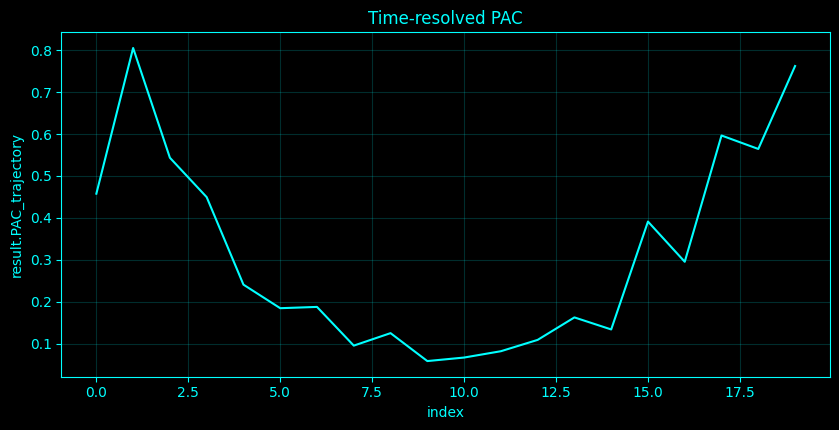

In [74]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

# Method-specific calculation.
def _compute_method_74():
    idx = 74
    name = 'Time-resolved PAC'
    __plot_spec = None
    p = np.angle(_analytic_band(BANDS['theta'])[:, 0])
    a = np.abs(_analytic_band(BANDS['gamma'])[:, 0])
    nwin = min(20, max(5, N // max(int(_fs), 1)))
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    vals = []
    for s, e in zip(edges[:-1], edges[1:]):
        vals.append(float(np.abs(np.mean(a[s:e] * np.exp(1j * p[s:e]))) / (np.mean(a[s:e]) + EPS)))
    return ({'PAC_trajectory': vals}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_74,_plot_spec=_compute_method_74()
print('Time-resolved PAC')
if isinstance(result_74,dict):
    for _k,_v in result_74.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_74)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_74)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Time-resolved PAC',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Time-resolved PAC',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Time-resolved PAC',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">75. Band-by-band PAC comodulograms</h3>
<p>A PAC comodulogram evaluates the same modulation index over a grid of phase-frequency and amplitude-frequency bands.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Band-by-band PAC comodulograms
  comodulogram: array(3, 3), mean=0.024049


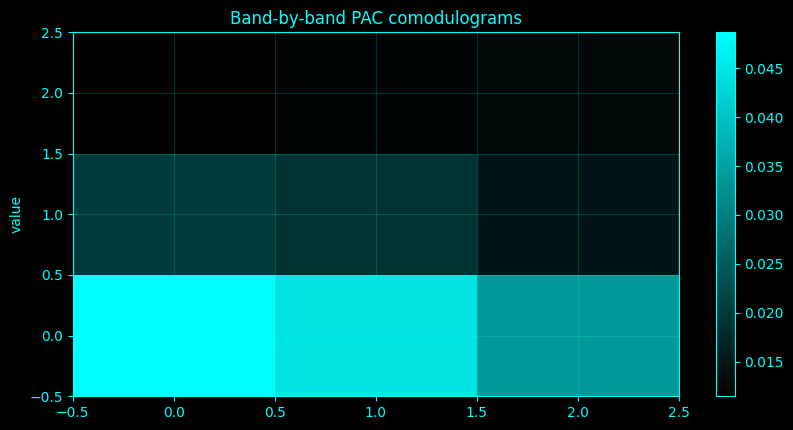

In [75]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _pac_tort(ch=0, phase_band=(4, 8), amp_band=(30, 45), nbins=18):
    p = np.angle(_analytic_band(phase_band)[:, ch])
    a = np.abs(_analytic_band(amp_band)[:, ch])
    edges = np.linspace(-np.pi, np.pi, nbins + 1)
    q = np.array([np.mean(a[(p >= edges[k]) & (p < edges[k + 1])]) for k in range(nbins)])
    q = np.nan_to_num(q, nan=0.0)
    q = q / (q.sum() + EPS)
    u = np.ones(nbins) / nbins
    return float(np.sum(q * np.log((q + EPS) / u)) / np.log(nbins))

# Method-specific calculation.
def _compute_method_75():
    idx = 75
    name = 'Band-by-band PAC comodulograms'
    __plot_spec = None
    phase_bands = [(2, 4), (4, 8), (8, 13)]
    amp_bands = [(13, 20), (20, 30), (30, min(45, 0.45 * _fs))]
    M = np.zeros((len(phase_bands), len(amp_bands)))
    for i, pb in enumerate(phase_bands):
        for j, ab in enumerate(amp_bands):
            if ab[0] < ab[1]:
                M[i, j] = _pac_tort(0, pb, ab)
    __plot_spec = ('summary', M, name, None, '', 'value')
    return ({'comodulogram': M}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_75,_plot_spec=_compute_method_75()
print('Band-by-band PAC comodulograms')
if isinstance(result_75,dict):
    for _k,_v in result_75.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_75)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_75)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Band-by-band PAC comodulograms',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Band-by-band PAC comodulograms',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Band-by-band PAC comodulograms',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">76. Phase-phase coupling</h3>
<p>For \(n:m\) phase locking, \(R_{n:m}=|\langle e^{i(n\phi_1-m\phi_2)}\rangle|\). Phase-phase coupling is therefore tested without amplitude information.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> An exponential describes multiplicative growth or decay. In dynamical systems, a positive exponent corresponds to growth with time and a negative exponent to decay. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. Expectation or angle-bracket notation denotes an average with respect to a probability distribution or ensemble.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [76]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

# Method-specific calculation.
def _compute_method_76():
    idx = 76
    name = 'Phase-phase coupling'
    __plot_spec = None
    pa = np.angle(_analytic_band(BANDS['theta'])[:, 0])
    pb = np.angle(_analytic_band(BANDS['alpha'])[:, 0])
    return ({'2_to_1_phase_phase_locking': float(np.abs(np.mean(np.exp(1j * (2 * pa - pb)))))}, locals().get('__plot_spec', None))
    vals = {}
    for n, m0 in [(1, 1), (2, 1), (3, 2)]:
        vals[f'{n}:{m0}'] = float(np.abs(np.mean(np.exp(1j * (n * pa - m0 * pb)))))
    return (vals, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_76,_plot_spec=_compute_method_76()
print('Phase-phase coupling')
if isinstance(result_76,dict):
    for _k,_v in result_76.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_76)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_76)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Phase-phase coupling',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Phase-phase coupling',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Phase-phase coupling',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Phase-phase coupling
  2_to_1_phase_phase_locking: 0.06062385557838901


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">77. n:m phase locking</h3>
<p>For \(n:m\) phase locking, \(R_{n:m}=|\langle e^{i(n\phi_1-m\phi_2)}\rangle|\). Phase-phase coupling is therefore tested without amplitude information.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> An exponential describes multiplicative growth or decay. In dynamical systems, a positive exponent corresponds to growth with time and a negative exponent to decay. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. Expectation or angle-bracket notation denotes an average with respect to a probability distribution or ensemble.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


n:m phase locking
  1:1: 0.1332580119110501
  2:1: 0.06062385557838901
  3:2: 0.027938968138244983


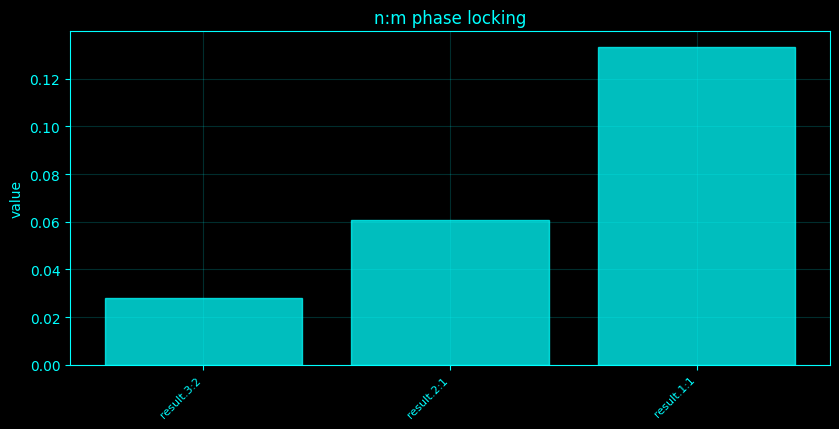

In [77]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

# Method-specific calculation.
def _compute_method_77():
    idx = 77
    name = 'n:m phase locking'
    __plot_spec = None
    pa = np.angle(_analytic_band(BANDS['theta'])[:, 0])
    pb = np.angle(_analytic_band(BANDS['alpha'])[:, 0])
    vals = {}
    for n, m0 in [(1, 1), (2, 1), (3, 2)]:
        vals[f'{n}:{m0}'] = float(np.abs(np.mean(np.exp(1j * (n * pa - m0 * pb)))))
    return (vals, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_77,_plot_spec=_compute_method_77()
print('n:m phase locking')
if isinstance(result_77,dict):
    for _k,_v in result_77.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_77)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_77)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'n:m phase locking',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'n:m phase locking',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('n:m phase locking',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">78. Amplitude-amplitude coupling</h3>
<p>Amplitude-amplitude coupling is the correlation between narrow-band analytic envelopes, measuring co-fluctuation of oscillatory amplitudes.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [78]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

# Method-specific calculation.
def _compute_method_78():
    idx = 78
    name = 'Amplitude-amplitude coupling'
    __plot_spec = None
    a = np.abs(_analytic_band(BANDS['alpha'])[:, 0])
    b = np.abs(_analytic_band(BANDS['beta'])[:, min(1, C - 1)])
    return ({'amplitude_correlation': float(np.corrcoef(a, b)[0, 1])}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_78,_plot_spec=_compute_method_78()
print('Amplitude-amplitude coupling')
if isinstance(result_78,dict):
    for _k,_v in result_78.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_78)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_78)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Amplitude-amplitude coupling',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Amplitude-amplitude coupling',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Amplitude-amplitude coupling',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Amplitude-amplitude coupling
  amplitude_correlation: 0.7896182297748991


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">79. Cross-frequency coherence</h3>
<p>Cross-frequency coherence here compares a low-frequency oscillatory signal with the high-frequency amplitude envelope, so coherence is evaluated at the envelope's modulation frequencies rather than between unequal carrier frequencies.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Coherence is a frequency-specific measure of linear association between two signals. It compares the magnitude of their cross-spectrum with the power spectra of the individual signals. Values near one mean that a stable linear relationship at that frequency explains a large fraction of the spectral activity, while values near zero indicate weak consistency. High coherence can arise from common input, volume conduction, or shared reference effects, so it should not automatically be interpreted as direct connectivity.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [79]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

# Method-specific calculation.
def _compute_method_79():
    idx = 79
    name = 'Cross-frequency coherence'
    __plot_spec = None
    low = np.real(_analytic_band(BANDS['theta'])[:, 0])
    env = np.abs(_analytic_band(BANDS['gamma'])[:, min(1, C - 1)])
    ff, cc = signal.coherence(low, env, fs=_fs, nperseg=min(_SPEED['nperseg'], N))
    return ({'max_cross_frequency_coherence': float(np.max(cc[(ff >= 1) & (ff <= 15)]))}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_79,_plot_spec=_compute_method_79()
print('Cross-frequency coherence')
if isinstance(result_79,dict):
    for _k,_v in result_79.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_79)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_79)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Cross-frequency coherence',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Cross-frequency coherence',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Cross-frequency coherence',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Cross-frequency coherence
  max_cross_frequency_coherence: 0.09402325802127375


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">80. Cross-bispectral coupling</h3>
<p>Cross-bispectral coupling detects quadratic frequency interactions through \(B(f_1,f_2)=E[X(f_1)Y(f_2)Z^\ast(f_1+f_2)]\).</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. Expectation or angle-bracket notation denotes an average with respect to a probability distribution or ensemble.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [80]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _bispectrum(channel=0, nper=None):
    y = X[:, channel]
    n = min(int(nper or 256), len(y))
    step = max(1, n // 2)
    win = signal.windows.hann(n)
    seg = []
    for a in range(0, len(y) - n + 1, step):
        seg.append(np.fft.rfft((y[a:a + n] - np.mean(y[a:a + n])) * win))
    F = np.asarray(seg)
    f = np.fft.rfftfreq(n, 1 / _fs)
    nf = len(f)
    limit = min(nf, 64)
    B = np.zeros((limit, limit), complex)
    den = np.zeros((limit, limit), float)
    for i in range(limit):
        maxj = min(limit, nf - i)
        if maxj <= 0:
            continue
        prod = F[:, i, None] * F[:, :maxj] * np.conj(F[:, i:i + maxj])
        for j in range(maxj):
            k = i + j
            if k < nf:
                z = F[:, i] * F[:, j] * np.conj(F[:, k])
                B[i, j] = np.mean(z)
                den[i, j] = np.sqrt(np.mean(np.abs(F[:, i] * F[:, j]) ** 2) * np.mean(np.abs(F[:, k]) ** 2)) + EPS
    bic = np.abs(B) / den
    return (f[:limit], B, bic, F)

# Method-specific calculation.
def _compute_method_80():
    idx = 80
    name = 'Cross-bispectral coupling'
    __plot_spec = None
    fb, B, bic, F = _bispectrum()
    return ({'max_cross_bispectral_coupling': float(np.nanmax(bic))}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_80,_plot_spec=_compute_method_80()
print('Cross-bispectral coupling')
if isinstance(result_80,dict):
    for _k,_v in result_80.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_80)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_80)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Cross-bispectral coupling',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Cross-bispectral coupling',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Cross-bispectral coupling',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Cross-bispectral coupling
  max_cross_bispectral_coupling: 0.899585789513127


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">81. Cross-frequency directionality</h3>
<p>Cross-frequency directionality is reported as the lag of maximal cross-correlation between low-frequency activity and a high-frequency envelope. This is a temporal lead/lag proxy, not causal identification.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [81]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

# Method-specific calculation.
def _compute_method_81():
    idx = 81
    name = 'Cross-frequency directionality'
    __plot_spec = None
    low = np.real(_analytic_band(BANDS['theta'])[:, 0])
    env = np.abs(_analytic_band(BANDS['gamma'])[:, min(1, C - 1)])
    xc = signal.correlate((env - env.mean()) / env.std(), (low - low.mean()) / low.std(), mode='full', method='fft')
    lags = signal.correlation_lags(len(env), len(low)) / _fs
    mm = np.abs(lags) <= 1
    lag = float(lags[mm][np.argmax(np.abs(xc[mm]))])
    return ({'peak_lag_s': lag, 'note': 'lagged cross-frequency dependence, not a causal identification'}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_81,_plot_spec=_compute_method_81()
print('Cross-frequency directionality')
if isinstance(result_81,dict):
    for _k,_v in result_81.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_81)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_81)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Cross-frequency directionality',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Cross-frequency directionality',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Cross-frequency directionality',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Cross-frequency directionality
  peak_lag_s: -0.016
  note: lagged cross-frequency dependence, not a causal identification


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">82. PAC surrogate testing</h3>
<p>PAC surrogate testing circularly shifts the amplitude envelope relative to phase, preserving within-band temporal structure while destroying their alignment.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A surrogate test creates artificial signals that preserve selected simple properties of the original data while deliberately removing the structure being tested. IAAFT surrogates approximately preserve the amplitude distribution and power spectrum, and therefore much of the linear autocorrelation structure, while randomizing nonlinear temporal organization. The observed statistic is then compared with the surrogate distribution. A small surrogate-based p-value means the observed statistic is unusual under that null model; it does not by itself identify the biological mechanism responsible for the difference.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


PAC surrogate testing
  observed: 0.014531283403541095
  surrogate_p: 0.8888888888888888


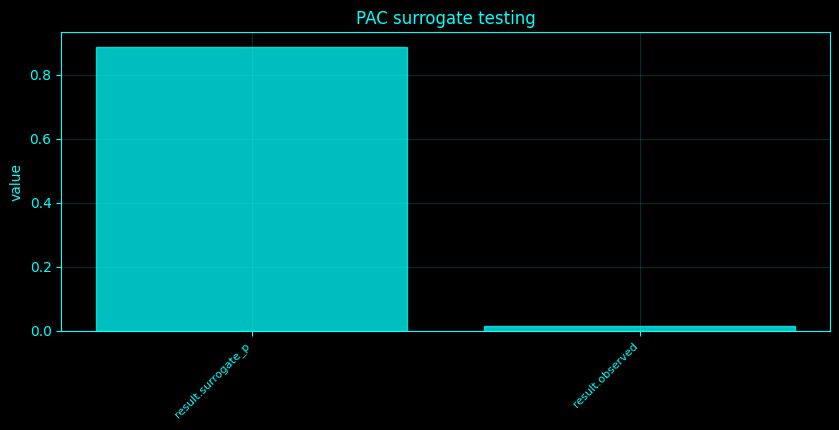

In [82]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _pac_tort(ch=0, phase_band=(4, 8), amp_band=(30, 45), nbins=18):
    p = np.angle(_analytic_band(phase_band)[:, ch])
    a = np.abs(_analytic_band(amp_band)[:, ch])
    edges = np.linspace(-np.pi, np.pi, nbins + 1)
    q = np.array([np.mean(a[(p >= edges[k]) & (p < edges[k + 1])]) for k in range(nbins)])
    q = np.nan_to_num(q, nan=0.0)
    q = q / (q.sum() + EPS)
    u = np.ones(nbins) / nbins
    return float(np.sum(q * np.log((q + EPS) / u)) / np.log(nbins))

# Method-specific calculation.
def _compute_method_82():
    idx = 82
    name = 'PAC surrogate testing'
    __plot_spec = None
    obs = _pac_tort()
    null = []
    amp = np.abs(_analytic_band(BANDS['gamma'])[:, 0])
    phase = np.angle(_analytic_band(BANDS['theta'])[:, 0])
    edges = np.linspace(-np.pi, np.pi, 19)
    for _ in range(_SPEED['n_sur']):
        sh = int(_rng.integers(int(0.2 * _fs), max(int(0.2 * _fs) + 1, N - int(0.2 * _fs))))
        a = np.roll(amp, sh)
        q = np.array([np.mean(a[(phase >= edges[k]) & (phase < edges[k + 1])]) for k in range(18)])
        q = np.nan_to_num(q)
        q /= q.sum() + EPS
        null.append(float(np.sum(q * np.log((q + EPS) / (1 / 18))) / np.log(18)))
    return ({'observed': obs, 'surrogate_p': float((1 + np.sum(np.asarray(null) >= obs)) / (1 + len(null)))}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_82,_plot_spec=_compute_method_82()
print('PAC surrogate testing')
if isinstance(result_82,dict):
    for _k,_v in result_82.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_82)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_82)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'PAC surrogate testing',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'PAC surrogate testing',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('PAC surrogate testing',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">83. PAC regional asymmetry</h3>
<p>PAC regional asymmetry compares channel-level PAC averages over left and right sensor groups.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [83]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _pac_mvl(ch=0, phase_band=(4, 8), amp_band=(30, 45)):
    p = np.angle(_analytic_band(phase_band)[:, ch])
    a = np.abs(_analytic_band(amp_band)[:, ch])
    return float(np.abs(np.mean(a * np.exp(1j * p))) / (np.mean(a) + EPS))

# Method-specific calculation.
def _compute_method_83():
    idx = 83
    name = 'PAC regional asymmetry'
    __plot_spec = None
    vals = np.array([_pac_mvl(j) for j in range(C)])
    left = [CH_NAMES.index(ch) for ch in LEFT if ch in CH_NAMES]
    right = [CH_NAMES.index(ch) for ch in RIGHT if ch in CH_NAMES]
    return ({'left_minus_right_PAC': float(np.mean(vals[left]) - np.mean(vals[right])) if left and right else np.nan}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_83,_plot_spec=_compute_method_83()
print('PAC regional asymmetry')
if isinstance(result_83,dict):
    for _k,_v in result_83.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_83)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_83)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'PAC regional asymmetry',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'PAC regional asymmetry',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('PAC regional asymmetry',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


PAC regional asymmetry
  left_minus_right_PAC: -0.005876496915370996


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">84. PAC source-target analysis</h3>
<p>PAC source-target analysis uses low-frequency phase from each source channel and high-frequency amplitude from each target channel, producing a directed phase-source/amplitude-target matrix.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [84]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

# Method-specific calculation.
def _compute_method_84():
    idx = 84
    name = 'PAC source-target analysis'
    __plot_spec = None
    M = np.zeros((C, C))
    ph = np.angle(_analytic_band(BANDS['theta']))
    amp = np.abs(_analytic_band(BANDS['gamma']))
    for i in range(C):
        for j in range(C):
            M[i, j] = np.abs(np.mean(amp[:, j] * np.exp(1j * ph[:, i]))) / (np.mean(amp[:, j]) + EPS)
    __plot_spec = ('summary', M, name, None, '', 'value')
    return ({'strongest_source_target_PAC': float(np.max(M))}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_84,_plot_spec=_compute_method_84()
print('PAC source-target analysis')
if isinstance(result_84,dict):
    for _k,_v in result_84.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_84)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_84)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'PAC source-target analysis',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'PAC source-target analysis',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('PAC source-target analysis',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


PAC source-target analysis
  strongest_source_target_PAC: 0.22965937369798162


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">85. Bispectrum</h3>
<p>The bispectrum is \(B(f_1,f_2)=E[X(f_1)X(f_2)X^\ast(f_1+f_2)]\), a third-order spectrum sensitive to quadratic phase coupling.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. Expectation or angle-bracket notation denotes an average with respect to a probability distribution or ensemble.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [85]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _bispectrum(channel=0, nper=None):
    y = X[:, channel]
    n = min(int(nper or 256), len(y))
    step = max(1, n // 2)
    win = signal.windows.hann(n)
    seg = []
    for a in range(0, len(y) - n + 1, step):
        seg.append(np.fft.rfft((y[a:a + n] - np.mean(y[a:a + n])) * win))
    F = np.asarray(seg)
    f = np.fft.rfftfreq(n, 1 / _fs)
    nf = len(f)
    limit = min(nf, 64)
    B = np.zeros((limit, limit), complex)
    den = np.zeros((limit, limit), float)
    for i in range(limit):
        maxj = min(limit, nf - i)
        if maxj <= 0:
            continue
        prod = F[:, i, None] * F[:, :maxj] * np.conj(F[:, i:i + maxj])
        for j in range(maxj):
            k = i + j
            if k < nf:
                z = F[:, i] * F[:, j] * np.conj(F[:, k])
                B[i, j] = np.mean(z)
                den[i, j] = np.sqrt(np.mean(np.abs(F[:, i] * F[:, j]) ** 2) * np.mean(np.abs(F[:, k]) ** 2)) + EPS
    bic = np.abs(B) / den
    return (f[:limit], B, bic, F)

# Method-specific calculation.
def _compute_method_85():
    idx = 85
    name = 'Bispectrum'
    __plot_spec = None
    fb, B, bic, F = _bispectrum(0)
    __plot_spec = ('summary', np.abs(B), name, None, '', 'value')
    return ({'max_abs_bispectrum': float(np.max(np.abs(B)))}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_85,_plot_spec=_compute_method_85()
print('Bispectrum')
if isinstance(result_85,dict):
    for _k,_v in result_85.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_85)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_85)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Bispectrum',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Bispectrum',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Bispectrum',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Bispectrum
  max_abs_bispectrum: 1670.5380973370404


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">86. Bicoherence</h3>
<p>Bicoherence normalizes the bispectrum by second moments so the magnitude is bounded approximately by one: \(|B|/\sqrt{E|X(f_1)X(f_2)|^2\,E|X(f_1+f_2)|^2}\).</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Coherence is a frequency-specific measure of linear association between two signals. It compares the magnitude of their cross-spectrum with the power spectra of the individual signals. Values near one mean that a stable linear relationship at that frequency explains a large fraction of the spectral activity, while values near zero indicate weak consistency. High coherence can arise from common input, volume conduction, or shared reference effects, so it should not automatically be interpreted as direct connectivity.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [86]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _bispectrum(channel=0, nper=None):
    y = X[:, channel]
    n = min(int(nper or 256), len(y))
    step = max(1, n // 2)
    win = signal.windows.hann(n)
    seg = []
    for a in range(0, len(y) - n + 1, step):
        seg.append(np.fft.rfft((y[a:a + n] - np.mean(y[a:a + n])) * win))
    F = np.asarray(seg)
    f = np.fft.rfftfreq(n, 1 / _fs)
    nf = len(f)
    limit = min(nf, 64)
    B = np.zeros((limit, limit), complex)
    den = np.zeros((limit, limit), float)
    for i in range(limit):
        maxj = min(limit, nf - i)
        if maxj <= 0:
            continue
        prod = F[:, i, None] * F[:, :maxj] * np.conj(F[:, i:i + maxj])
        for j in range(maxj):
            k = i + j
            if k < nf:
                z = F[:, i] * F[:, j] * np.conj(F[:, k])
                B[i, j] = np.mean(z)
                den[i, j] = np.sqrt(np.mean(np.abs(F[:, i] * F[:, j]) ** 2) * np.mean(np.abs(F[:, k]) ** 2)) + EPS
    bic = np.abs(B) / den
    return (f[:limit], B, bic, F)

# Method-specific calculation.
def _compute_method_86():
    idx = 86
    name = 'Bicoherence'
    __plot_spec = None
    fb, B, bic, F = _bispectrum(0)
    __plot_spec = ('summary', bic, name, None, '', 'value')
    return ({'max_bicoherence': float(np.nanmax(bic))}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_86,_plot_spec=_compute_method_86()
print('Bicoherence')
if isinstance(result_86,dict):
    for _k,_v in result_86.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_86)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_86)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Bicoherence',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Bicoherence',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Bicoherence',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Bicoherence
  max_bicoherence: 0.899585789513127


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">87. Cross-bispectrum</h3>
<p>The cross-bispectrum replaces one or more Fourier factors with another channel, testing cross-channel quadratic coupling.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [87]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _bispectrum(channel=0, nper=None):
    y = X[:, channel]
    n = min(int(nper or 256), len(y))
    step = max(1, n // 2)
    win = signal.windows.hann(n)
    seg = []
    for a in range(0, len(y) - n + 1, step):
        seg.append(np.fft.rfft((y[a:a + n] - np.mean(y[a:a + n])) * win))
    F = np.asarray(seg)
    f = np.fft.rfftfreq(n, 1 / _fs)
    nf = len(f)
    limit = min(nf, 64)
    B = np.zeros((limit, limit), complex)
    den = np.zeros((limit, limit), float)
    for i in range(limit):
        maxj = min(limit, nf - i)
        if maxj <= 0:
            continue
        prod = F[:, i, None] * F[:, :maxj] * np.conj(F[:, i:i + maxj])
        for j in range(maxj):
            k = i + j
            if k < nf:
                z = F[:, i] * F[:, j] * np.conj(F[:, k])
                B[i, j] = np.mean(z)
                den[i, j] = np.sqrt(np.mean(np.abs(F[:, i] * F[:, j]) ** 2) * np.mean(np.abs(F[:, k]) ** 2)) + EPS
    bic = np.abs(B) / den
    return (f[:limit], B, bic, F)

# Method-specific calculation.
def _compute_method_87():
    idx = 87
    name = 'Cross-bispectrum'
    __plot_spec = None
    fb, B, bic, F = _bispectrum(0)
    n = min(256, N)
    step = n // 2
    win = signal.windows.hann(n)
    segs = []
    for a in range(0, N - n + 1, step):
        segs.append(np.fft.rfft(X[a:a + n, :2] * win[:, None], axis=0))
    FF = np.asarray(segs)
    limit = min(48, FF.shape[1])
    Bc = np.zeros((limit, limit), complex)
    for i in range(limit):
        for j in range(min(limit, FF.shape[1] - i)):
            Bc[i, j] = np.mean(FF[:, i, 0] * FF[:, j, 1] * np.conj(FF[:, i + j, 0]))
    return ({'max_cross_bispectrum': float(np.max(np.abs(Bc)))}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_87,_plot_spec=_compute_method_87()
print('Cross-bispectrum')
if isinstance(result_87,dict):
    for _k,_v in result_87.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_87)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_87)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Cross-bispectrum',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Cross-bispectrum',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Cross-bispectrum',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Cross-bispectrum
  max_cross_bispectrum: 16217.816416396527


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">88. Trispectrum</h3>
<p>A trispectral slice evaluates a fourth-order frequency interaction such as \(E[X(f_1)X(f_2)X(f_3)X^\ast(f_1+f_2+f_3)]\). The notebook reports a computationally bounded diagonal slice and labels it as such.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. Expectation or angle-bracket notation denotes an average with respect to a probability distribution or ensemble.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [88]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _bispectrum(channel=0, nper=None):
    y = X[:, channel]
    n = min(int(nper or 256), len(y))
    step = max(1, n // 2)
    win = signal.windows.hann(n)
    seg = []
    for a in range(0, len(y) - n + 1, step):
        seg.append(np.fft.rfft((y[a:a + n] - np.mean(y[a:a + n])) * win))
    F = np.asarray(seg)
    f = np.fft.rfftfreq(n, 1 / _fs)
    nf = len(f)
    limit = min(nf, 64)
    B = np.zeros((limit, limit), complex)
    den = np.zeros((limit, limit), float)
    for i in range(limit):
        maxj = min(limit, nf - i)
        if maxj <= 0:
            continue
        prod = F[:, i, None] * F[:, :maxj] * np.conj(F[:, i:i + maxj])
        for j in range(maxj):
            k = i + j
            if k < nf:
                z = F[:, i] * F[:, j] * np.conj(F[:, k])
                B[i, j] = np.mean(z)
                den[i, j] = np.sqrt(np.mean(np.abs(F[:, i] * F[:, j]) ** 2) * np.mean(np.abs(F[:, k]) ** 2)) + EPS
    bic = np.abs(B) / den
    return (f[:limit], B, bic, F)

# Method-specific calculation.
def _compute_method_88():
    idx = 88
    name = 'Trispectrum'
    __plot_spec = None
    fb, B, bic, F = _bispectrum(0)
    limit = min(32, F.shape[1] // 3)
    T = np.array([np.mean(F[:, i] ** 3 * np.conj(F[:, 3 * i])) for i in range(1, limit)])
    return ({'max_trispectral_slice': float(np.max(np.abs(T))) if len(T) else np.nan, 'note': 'diagonal fourth-order spectral slice'}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_88,_plot_spec=_compute_method_88()
print('Trispectrum')
if isinstance(result_88,dict):
    for _k,_v in result_88.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_88)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_88)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Trispectrum',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Trispectrum',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Trispectrum',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Trispectrum
  max_trispectral_slice: 47511.11974721696
  note: diagonal fourth-order spectral slice


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">89. Higher-order spectral analysis</h3>
<p>Higher-order spectral analysis summarizes normalized bispectral and trispectral coupling rather than relying only on second-order PSD/coherence.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Coherence is a frequency-specific measure of linear association between two signals. It compares the magnitude of their cross-spectrum with the power spectra of the individual signals. Values near one mean that a stable linear relationship at that frequency explains a large fraction of the spectral activity, while values near zero indicate weak consistency. High coherence can arise from common input, volume conduction, or shared reference effects, so it should not automatically be interpreted as direct connectivity.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Higher-order spectral analysis
  mean_bicoherence: 0.18102638879444852
  max_bicoherence: 0.899585789513127


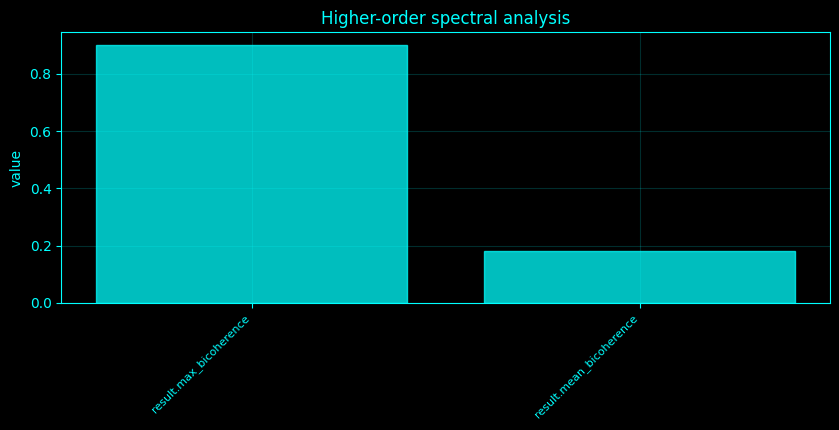

In [89]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _bispectrum(channel=0, nper=None):
    y = X[:, channel]
    n = min(int(nper or 256), len(y))
    step = max(1, n // 2)
    win = signal.windows.hann(n)
    seg = []
    for a in range(0, len(y) - n + 1, step):
        seg.append(np.fft.rfft((y[a:a + n] - np.mean(y[a:a + n])) * win))
    F = np.asarray(seg)
    f = np.fft.rfftfreq(n, 1 / _fs)
    nf = len(f)
    limit = min(nf, 64)
    B = np.zeros((limit, limit), complex)
    den = np.zeros((limit, limit), float)
    for i in range(limit):
        maxj = min(limit, nf - i)
        if maxj <= 0:
            continue
        prod = F[:, i, None] * F[:, :maxj] * np.conj(F[:, i:i + maxj])
        for j in range(maxj):
            k = i + j
            if k < nf:
                z = F[:, i] * F[:, j] * np.conj(F[:, k])
                B[i, j] = np.mean(z)
                den[i, j] = np.sqrt(np.mean(np.abs(F[:, i] * F[:, j]) ** 2) * np.mean(np.abs(F[:, k]) ** 2)) + EPS
    bic = np.abs(B) / den
    return (f[:limit], B, bic, F)

# Method-specific calculation.
def _compute_method_89():
    idx = 89
    name = 'Higher-order spectral analysis'
    __plot_spec = None
    fb, B, bic, F = _bispectrum(0)
    return ({'mean_bicoherence': float(np.nanmean(bic)), 'max_bicoherence': float(np.nanmax(bic))}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_89,_plot_spec=_compute_method_89()
print('Higher-order spectral analysis')
if isinstance(result_89,dict):
    for _k,_v in result_89.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_89)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_89)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Higher-order spectral analysis',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Higher-order spectral analysis',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Higher-order spectral analysis',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">90. Quadratic phase coupling</h3>
<p>Quadratic phase coupling is strongest where bicoherence peaks, because stable relation \(\phi(f_1)+\phi(f_2)-\phi(f_1+f_2)\) makes the bispectral average coherent.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Coherence is a frequency-specific measure of linear association between two signals. It compares the magnitude of their cross-spectrum with the power spectra of the individual signals. Values near one mean that a stable linear relationship at that frequency explains a large fraction of the spectral activity, while values near zero indicate weak consistency. High coherence can arise from common input, volume conduction, or shared reference effects, so it should not automatically be interpreted as direct connectivity.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. Greek phase symbols such as φ or θ represent angular position on a cycle. Because phase wraps around, differences are interpreted modulo one full cycle.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Quadratic phase coupling
  f1_hz: 1.953125
  f2_hz: 1.953125
  max_bicoherence: 0.899585789513127


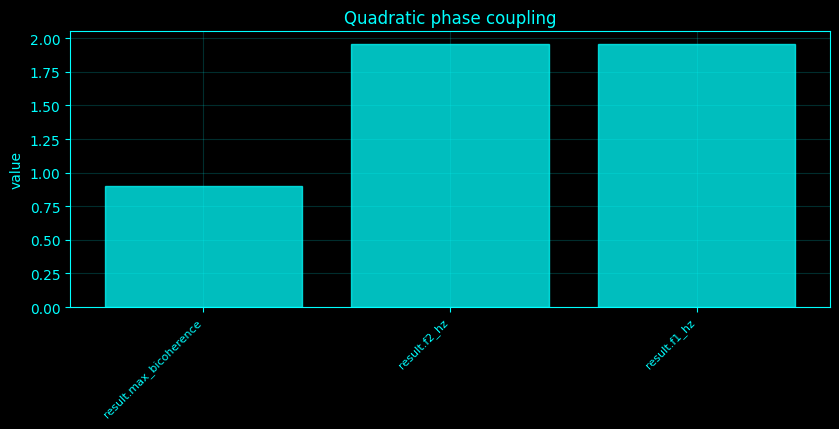

In [90]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _bispectrum(channel=0, nper=None):
    y = X[:, channel]
    n = min(int(nper or 256), len(y))
    step = max(1, n // 2)
    win = signal.windows.hann(n)
    seg = []
    for a in range(0, len(y) - n + 1, step):
        seg.append(np.fft.rfft((y[a:a + n] - np.mean(y[a:a + n])) * win))
    F = np.asarray(seg)
    f = np.fft.rfftfreq(n, 1 / _fs)
    nf = len(f)
    limit = min(nf, 64)
    B = np.zeros((limit, limit), complex)
    den = np.zeros((limit, limit), float)
    for i in range(limit):
        maxj = min(limit, nf - i)
        if maxj <= 0:
            continue
        prod = F[:, i, None] * F[:, :maxj] * np.conj(F[:, i:i + maxj])
        for j in range(maxj):
            k = i + j
            if k < nf:
                z = F[:, i] * F[:, j] * np.conj(F[:, k])
                B[i, j] = np.mean(z)
                den[i, j] = np.sqrt(np.mean(np.abs(F[:, i] * F[:, j]) ** 2) * np.mean(np.abs(F[:, k]) ** 2)) + EPS
    bic = np.abs(B) / den
    return (f[:limit], B, bic, F)

# Method-specific calculation.
def _compute_method_90():
    idx = 90
    name = 'Quadratic phase coupling'
    __plot_spec = None
    fb, B, bic, F = _bispectrum(0)
    ij = np.unravel_index(np.nanargmax(bic), bic.shape)
    return ({'f1_hz': float(fb[ij[0]]), 'f2_hz': float(fb[ij[1]]), 'max_bicoherence': float(bic[ij])}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_90,_plot_spec=_compute_method_90()
print('Quadratic phase coupling')
if isinstance(result_90,dict):
    for _k,_v in result_90.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_90)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_90)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Quadratic phase coupling',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Quadratic phase coupling',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Quadratic phase coupling',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">91. Third-order cumulant spectrum</h3>
<p>The third-order cumulant surface and bispectrum are two-dimensional Fourier-transform pairs; inverse 2-D Fourier transform of the estimated bispectrum yields the corresponding lag-domain third-order structure.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The Fourier transform represents a time-domain signal as a weighted sum of sinusoidal components. Each Fourier coefficient is complex: its magnitude describes the strength of a frequency component, while its angle describes phase relative to the chosen time origin. The discrete Fourier transform evaluates this representation only at a finite set of frequencies determined by the sampling rate and record length. It describes global frequency content over the analyzed window and does not by itself show when a frequency occurs.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [91]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _bispectrum(channel=0, nper=None):
    y = X[:, channel]
    n = min(int(nper or 256), len(y))
    step = max(1, n // 2)
    win = signal.windows.hann(n)
    seg = []
    for a in range(0, len(y) - n + 1, step):
        seg.append(np.fft.rfft((y[a:a + n] - np.mean(y[a:a + n])) * win))
    F = np.asarray(seg)
    f = np.fft.rfftfreq(n, 1 / _fs)
    nf = len(f)
    limit = min(nf, 64)
    B = np.zeros((limit, limit), complex)
    den = np.zeros((limit, limit), float)
    for i in range(limit):
        maxj = min(limit, nf - i)
        if maxj <= 0:
            continue
        prod = F[:, i, None] * F[:, :maxj] * np.conj(F[:, i:i + maxj])
        for j in range(maxj):
            k = i + j
            if k < nf:
                z = F[:, i] * F[:, j] * np.conj(F[:, k])
                B[i, j] = np.mean(z)
                den[i, j] = np.sqrt(np.mean(np.abs(F[:, i] * F[:, j]) ** 2) * np.mean(np.abs(F[:, k]) ** 2)) + EPS
    bic = np.abs(B) / den
    return (f[:limit], B, bic, F)

# Method-specific calculation.
def _compute_method_91():
    idx = 91
    name = 'Third-order cumulant spectrum'
    __plot_spec = None
    fb, B, bic, F = _bispectrum(0)
    c3 = np.fft.ifft2(B)
    return ({'max_abs_third_order_cumulant': float(np.max(np.abs(c3)))}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_91,_plot_spec=_compute_method_91()
print('Third-order cumulant spectrum')
if isinstance(result_91,dict):
    for _k,_v in result_91.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_91)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_91)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Third-order cumulant spectrum',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Third-order cumulant spectrum',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Third-order cumulant spectrum',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Third-order cumulant spectrum
  max_abs_third_order_cumulant: 14.114251914128857


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">92. Fourth-order cumulant spectrum</h3>
<p>A trispectral slice evaluates a fourth-order frequency interaction such as \(E[X(f_1)X(f_2)X(f_3)X^\ast(f_1+f_2+f_3)]\). The notebook reports a computationally bounded diagonal slice and labels it as such.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. Expectation or angle-bracket notation denotes an average with respect to a probability distribution or ensemble.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [92]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _bispectrum(channel=0, nper=None):
    y = X[:, channel]
    n = min(int(nper or 256), len(y))
    step = max(1, n // 2)
    win = signal.windows.hann(n)
    seg = []
    for a in range(0, len(y) - n + 1, step):
        seg.append(np.fft.rfft((y[a:a + n] - np.mean(y[a:a + n])) * win))
    F = np.asarray(seg)
    f = np.fft.rfftfreq(n, 1 / _fs)
    nf = len(f)
    limit = min(nf, 64)
    B = np.zeros((limit, limit), complex)
    den = np.zeros((limit, limit), float)
    for i in range(limit):
        maxj = min(limit, nf - i)
        if maxj <= 0:
            continue
        prod = F[:, i, None] * F[:, :maxj] * np.conj(F[:, i:i + maxj])
        for j in range(maxj):
            k = i + j
            if k < nf:
                z = F[:, i] * F[:, j] * np.conj(F[:, k])
                B[i, j] = np.mean(z)
                den[i, j] = np.sqrt(np.mean(np.abs(F[:, i] * F[:, j]) ** 2) * np.mean(np.abs(F[:, k]) ** 2)) + EPS
    bic = np.abs(B) / den
    return (f[:limit], B, bic, F)

# Method-specific calculation.
def _compute_method_92():
    idx = 92
    name = 'Fourth-order cumulant spectrum'
    __plot_spec = None
    fb, B, bic, F = _bispectrum(0)
    limit = min(32, F.shape[1] // 3)
    T = np.array([np.mean(F[:, i] ** 3 * np.conj(F[:, 3 * i])) for i in range(1, limit)])
    return ({'max_trispectral_slice': float(np.max(np.abs(T))) if len(T) else np.nan, 'note': 'diagonal fourth-order spectral slice'}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_92,_plot_spec=_compute_method_92()
print('Fourth-order cumulant spectrum')
if isinstance(result_92,dict):
    for _k,_v in result_92.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_92)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_92)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Fourth-order cumulant spectrum',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Fourth-order cumulant spectrum',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Fourth-order cumulant spectrum',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Fourth-order cumulant spectrum
  max_trispectral_slice: 47511.11974721696
  note: diagonal fourth-order spectral slice


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">93. Polyspectral entropy</h3>
<p>Polyspectral entropy normalizes bispectral energy \(q_{ij}=|B_{ij}|^2/\sum|B|^2\) and computes \(-\sum q_{ij}\log q_{ij}\).</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Spectral entropy treats the normalized power spectrum as a probability distribution over frequency bins and applies Shannon entropy to that distribution. If power is concentrated in only a few frequencies, the distribution is uneven and entropy is low. If power is spread broadly across many frequencies, entropy is higher. The result therefore describes spectral dispersion, not temporal unpredictability in exactly the same sense as Sample Entropy or permutation entropy.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Polyspectral entropy
  bispectral_entropy: 3.938348921519001
  normalized: 0.4734863715304884


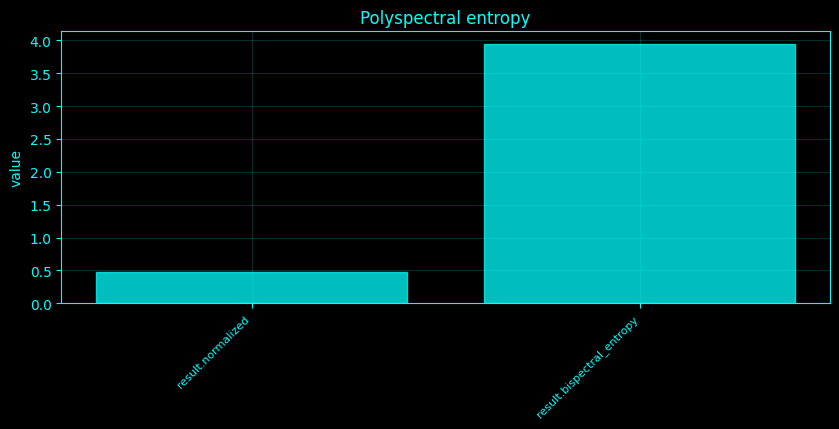

In [93]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _bispectrum(channel=0, nper=None):
    y = X[:, channel]
    n = min(int(nper or 256), len(y))
    step = max(1, n // 2)
    win = signal.windows.hann(n)
    seg = []
    for a in range(0, len(y) - n + 1, step):
        seg.append(np.fft.rfft((y[a:a + n] - np.mean(y[a:a + n])) * win))
    F = np.asarray(seg)
    f = np.fft.rfftfreq(n, 1 / _fs)
    nf = len(f)
    limit = min(nf, 64)
    B = np.zeros((limit, limit), complex)
    den = np.zeros((limit, limit), float)
    for i in range(limit):
        maxj = min(limit, nf - i)
        if maxj <= 0:
            continue
        prod = F[:, i, None] * F[:, :maxj] * np.conj(F[:, i:i + maxj])
        for j in range(maxj):
            k = i + j
            if k < nf:
                z = F[:, i] * F[:, j] * np.conj(F[:, k])
                B[i, j] = np.mean(z)
                den[i, j] = np.sqrt(np.mean(np.abs(F[:, i] * F[:, j]) ** 2) * np.mean(np.abs(F[:, k]) ** 2)) + EPS
    bic = np.abs(B) / den
    return (f[:limit], B, bic, F)

# Method-specific calculation.
def _compute_method_93():
    idx = 93
    name = 'Polyspectral entropy'
    __plot_spec = None
    fb, B, bic, F = _bispectrum(0)
    q = np.abs(B) ** 2
    q = q / (q.sum() + EPS)
    H = -np.sum(q * np.log(q + EPS))
    return ({'bispectral_entropy': float(H), 'normalized': float(H / np.log(q.size))}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_93,_plot_spec=_compute_method_93()
print('Polyspectral entropy')
if isinstance(result_93,dict):
    for _k,_v in result_93.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_93)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_93)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Polyspectral entropy',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Polyspectral entropy',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Polyspectral entropy',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">94. Bispectral phase synchrony</h3>
<p>Bispectral phase synchrony is \(|E[e^{i(\phi_{f_1}+\phi_{f_2}-\phi_{f_1+f_2})}]|\), directly measuring stability of the quadratic phase relation.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> An exponential describes multiplicative growth or decay. In dynamical systems, a positive exponent corresponds to growth with time and a negative exponent to decay. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. Expectation or angle-bracket notation denotes an average with respect to a probability distribution or ensemble.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [94]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _bispectrum(channel=0, nper=None):
    y = X[:, channel]
    n = min(int(nper or 256), len(y))
    step = max(1, n // 2)
    win = signal.windows.hann(n)
    seg = []
    for a in range(0, len(y) - n + 1, step):
        seg.append(np.fft.rfft((y[a:a + n] - np.mean(y[a:a + n])) * win))
    F = np.asarray(seg)
    f = np.fft.rfftfreq(n, 1 / _fs)
    nf = len(f)
    limit = min(nf, 64)
    B = np.zeros((limit, limit), complex)
    den = np.zeros((limit, limit), float)
    for i in range(limit):
        maxj = min(limit, nf - i)
        if maxj <= 0:
            continue
        prod = F[:, i, None] * F[:, :maxj] * np.conj(F[:, i:i + maxj])
        for j in range(maxj):
            k = i + j
            if k < nf:
                z = F[:, i] * F[:, j] * np.conj(F[:, k])
                B[i, j] = np.mean(z)
                den[i, j] = np.sqrt(np.mean(np.abs(F[:, i] * F[:, j]) ** 2) * np.mean(np.abs(F[:, k]) ** 2)) + EPS
    bic = np.abs(B) / den
    return (f[:limit], B, bic, F)

# Method-specific calculation.
def _compute_method_94():
    idx = 94
    name = 'Bispectral phase synchrony'
    __plot_spec = None
    fb, B, bic, F = _bispectrum(0)
    phases = []
    nf = F.shape[1]
    limit = min(40, nf)
    for i in range(1, limit):
        j = i
        k = i + j
        if k < nf:
            phases.extend(np.angle(F[:, i]) + np.angle(F[:, j]) - np.angle(F[:, k]))
    return ({'bispectral_phase_synchrony': float(np.abs(np.mean(np.exp(1j * np.asarray(phases))))) if phases else np.nan}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_94,_plot_spec=_compute_method_94()
print('Bispectral phase synchrony')
if isinstance(result_94,dict):
    for _k,_v in result_94.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_94)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_94)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Bispectral phase synchrony',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Bispectral phase synchrony',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Bispectral phase synchrony',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Bispectral phase synchrony
  bispectral_phase_synchrony: 0.06159023689095001


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">95. Bispectral EEG channel fingerprints</h3>
<p>Bispectral channel fingerprints combine higher-order descriptors such as peak bicoherence and bispectral entropy for each channel.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Spectral entropy treats the normalized power spectrum as a probability distribution over frequency bins and applies Shannon entropy to that distribution. If power is concentrated in only a few frequencies, the distribution is uneven and entropy is low. If power is spread broadly across many frequencies, entropy is higher. The result therefore describes spectral dispersion, not temporal unpredictability in exactly the same sense as Sample Entropy or permutation entropy.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Bispectral EEG channel fingerprints
  fingerprints: array(8, 2), mean=2.3121


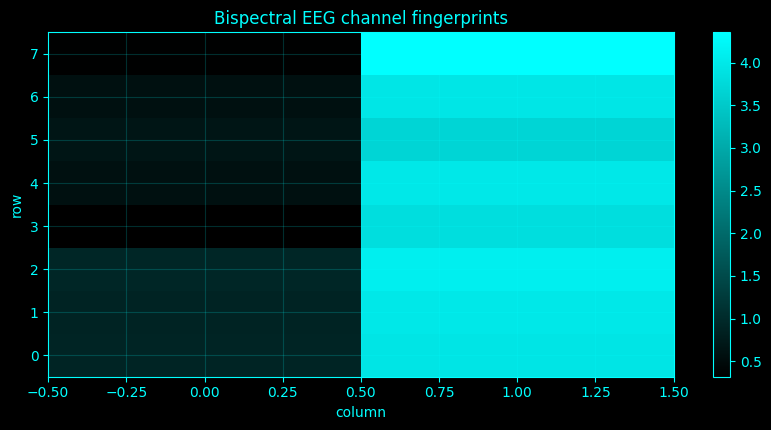

In [95]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _bispectrum(channel=0, nper=None):
    y = X[:, channel]
    n = min(int(nper or 256), len(y))
    step = max(1, n // 2)
    win = signal.windows.hann(n)
    seg = []
    for a in range(0, len(y) - n + 1, step):
        seg.append(np.fft.rfft((y[a:a + n] - np.mean(y[a:a + n])) * win))
    F = np.asarray(seg)
    f = np.fft.rfftfreq(n, 1 / _fs)
    nf = len(f)
    limit = min(nf, 64)
    B = np.zeros((limit, limit), complex)
    den = np.zeros((limit, limit), float)
    for i in range(limit):
        maxj = min(limit, nf - i)
        if maxj <= 0:
            continue
        prod = F[:, i, None] * F[:, :maxj] * np.conj(F[:, i:i + maxj])
        for j in range(maxj):
            k = i + j
            if k < nf:
                z = F[:, i] * F[:, j] * np.conj(F[:, k])
                B[i, j] = np.mean(z)
                den[i, j] = np.sqrt(np.mean(np.abs(F[:, i] * F[:, j]) ** 2) * np.mean(np.abs(F[:, k]) ** 2)) + EPS
    bic = np.abs(B) / den
    return (f[:limit], B, bic, F)

# Method-specific calculation.
def _compute_method_95():
    idx = 95
    name = 'Bispectral EEG channel fingerprints'
    __plot_spec = None
    fb, B, bic, F = _bispectrum(0)
    rows = []
    for ch in range(min(C, 8 if FAST_OPTION == 'ultra' else C)):
        ff, Bc, bc, Fc = _bispectrum(ch)
        q = np.abs(Bc) ** 2
        q /= q.sum() + EPS
        rows.append([np.nanmax(bc), -np.sum(q * np.log(q + EPS))])
    return ({'fingerprints': np.asarray(rows)}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_95,_plot_spec=_compute_method_95()
print('Bispectral EEG channel fingerprints')
if isinstance(result_95,dict):
    for _k,_v in result_95.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_95)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_95)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Bispectral EEG channel fingerprints',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Bispectral EEG channel fingerprints',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Bispectral EEG channel fingerprints',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">96. Spectral slope / aperiodic exponent</h3>
<p>On log-log axes, an aperiodic power law \(P(f)=10^b f^{-\chi}\) is linear: \(\log_{10}P=b-\chi\log_{10}f\). The fitted \(\chi\) is the aperiodic/1/f exponent.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Spectral slope / aperiodic exponent
  aperiodic_exponent: 1.2044092662432204
  log10_offset: -1.8675339449715904


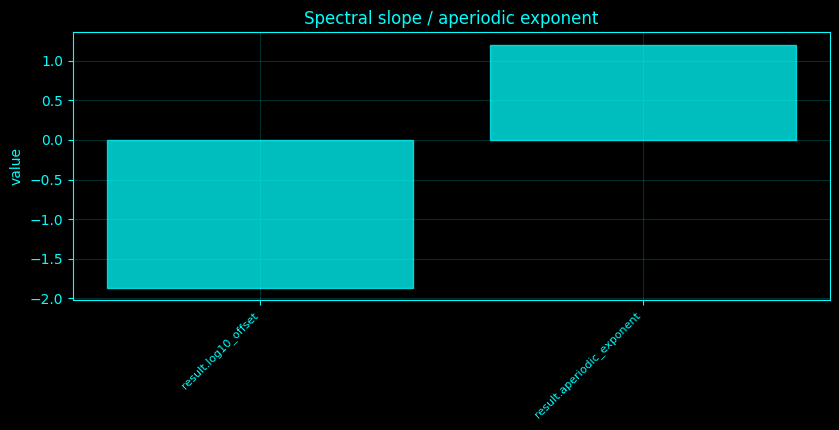

In [96]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

def _aperiodic_params(psd=None, f=None):
    if f is None or psd is None:
        f, Pa = _welch_all()
        psd = np.mean(Pa, axis=1)
    m = (f >= 2) & (f <= 45)
    x = np.log10(f[m])
    y = np.log10(psd[m] + EPS)
    coef = np.polyfit(x, y, 1)
    offset, exponent = (float(coef[1]), float(-coef[0]))
    fit = 10 ** (offset - exponent * np.log10(f + EPS))
    return (offset, exponent, fit)

def _peak_params(psd=None, f=None, band=(4, 30)):
    if f is None or psd is None:
        f, P = _welch_all()
        psd = np.mean(P, axis=1)
    _, _, ap = _aperiodic_params(psd, f)
    res = np.log10(psd + EPS) - np.log10(ap + EPS)
    m = (f >= band[0]) & (f <= band[1])
    peaks, props = signal.find_peaks(res[m], prominence=max(0.02, np.std(res[m]) * 0.3))
    fi = f[m][peaks]
    prom = props.get('prominences', np.array([]))
    return (fi, prom, res, ap)

def _irasa_channel(ch=0):
    key = ('irasa', ch)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    y = X[:, ch]
    f0, p0 = _psd_of(y[:, None])
    p0 = p0[:, 0]
    hs = np.array([1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9])
    geos = []
    from fractions import Fraction
    for h in hs:
        frac = Fraction(float(h)).limit_denominator(20)
        y1 = signal.resample_poly(y, frac.numerator, frac.denominator)
        y2 = signal.resample_poly(y, frac.denominator, frac.numerator)
        f1, p1 = signal.welch(y1, fs=_fs * h, nperseg=min(_SPEED['nperseg'], len(y1)))
        f2, p2 = signal.welch(y2, fs=_fs / h, nperseg=min(_SPEED['nperseg'], len(y2)))
        q1 = np.interp(f0, f1, p1)
        q2 = np.interp(f0, f2, p2)
        geos.append(np.sqrt(np.maximum(q1 * q2, 0)))
    fract = np.median(np.asarray(geos), axis=0)
    osc = np.maximum(p0 - fract, 0)
    SPEC_CACHE[key] = (f0, p0, fract, osc)
    return SPEC_CACHE[key]

# Method-specific calculation.
def _compute_method_96():
    idx = 96
    name = 'Spectral slope / aperiodic exponent'
    __plot_spec = None
    f, P = _welch_all()
    p = np.mean(P, axis=1)
    off, expn, ap = _aperiodic_params(p, f)
    peaks, prom, res, ap = _peak_params(p, f)
    return ({'aperiodic_exponent': expn, 'log10_offset': off}, locals().get('__plot_spec', None))
    f0, p0, fract, osc = _irasa_channel(0)
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_96,_plot_spec=_compute_method_96()
print('Spectral slope / aperiodic exponent')
if isinstance(result_96,dict):
    for _k,_v in result_96.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_96)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_96)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Spectral slope / aperiodic exponent',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Spectral slope / aperiodic exponent',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Spectral slope / aperiodic exponent',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">97. 1/f slope estimation</h3>
<p>On log-log axes, an aperiodic power law \(P(f)=10^b f^{-\chi}\) is linear: \(\log_{10}P=b-\chi\log_{10}f\). The fitted \(\chi\) is the aperiodic/1/f exponent.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


1/f slope estimation
  aperiodic_exponent: 1.2044092662432204
  log10_offset: -1.8675339449715904


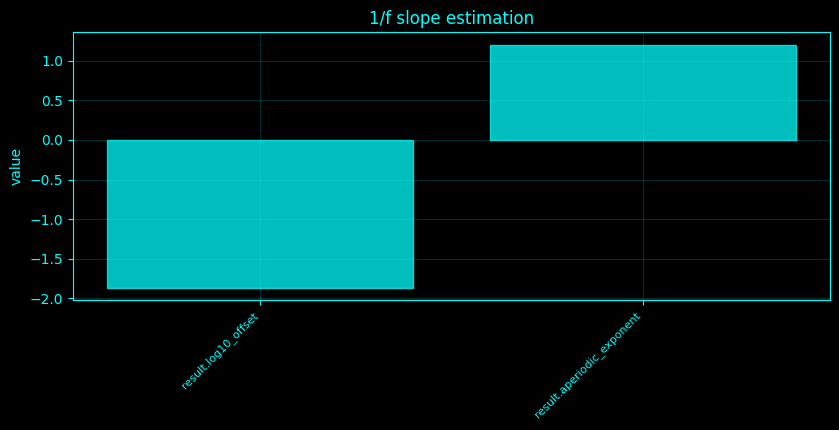

In [97]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

def _aperiodic_params(psd=None, f=None):
    if f is None or psd is None:
        f, Pa = _welch_all()
        psd = np.mean(Pa, axis=1)
    m = (f >= 2) & (f <= 45)
    x = np.log10(f[m])
    y = np.log10(psd[m] + EPS)
    coef = np.polyfit(x, y, 1)
    offset, exponent = (float(coef[1]), float(-coef[0]))
    fit = 10 ** (offset - exponent * np.log10(f + EPS))
    return (offset, exponent, fit)

def _peak_params(psd=None, f=None, band=(4, 30)):
    if f is None or psd is None:
        f, P = _welch_all()
        psd = np.mean(P, axis=1)
    _, _, ap = _aperiodic_params(psd, f)
    res = np.log10(psd + EPS) - np.log10(ap + EPS)
    m = (f >= band[0]) & (f <= band[1])
    peaks, props = signal.find_peaks(res[m], prominence=max(0.02, np.std(res[m]) * 0.3))
    fi = f[m][peaks]
    prom = props.get('prominences', np.array([]))
    return (fi, prom, res, ap)

def _irasa_channel(ch=0):
    key = ('irasa', ch)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    y = X[:, ch]
    f0, p0 = _psd_of(y[:, None])
    p0 = p0[:, 0]
    hs = np.array([1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9])
    geos = []
    from fractions import Fraction
    for h in hs:
        frac = Fraction(float(h)).limit_denominator(20)
        y1 = signal.resample_poly(y, frac.numerator, frac.denominator)
        y2 = signal.resample_poly(y, frac.denominator, frac.numerator)
        f1, p1 = signal.welch(y1, fs=_fs * h, nperseg=min(_SPEED['nperseg'], len(y1)))
        f2, p2 = signal.welch(y2, fs=_fs / h, nperseg=min(_SPEED['nperseg'], len(y2)))
        q1 = np.interp(f0, f1, p1)
        q2 = np.interp(f0, f2, p2)
        geos.append(np.sqrt(np.maximum(q1 * q2, 0)))
    fract = np.median(np.asarray(geos), axis=0)
    osc = np.maximum(p0 - fract, 0)
    SPEC_CACHE[key] = (f0, p0, fract, osc)
    return SPEC_CACHE[key]

# Method-specific calculation.
def _compute_method_97():
    idx = 97
    name = '1/f slope estimation'
    __plot_spec = None
    f, P = _welch_all()
    p = np.mean(P, axis=1)
    off, expn, ap = _aperiodic_params(p, f)
    peaks, prom, res, ap = _peak_params(p, f)
    return ({'aperiodic_exponent': expn, 'log10_offset': off}, locals().get('__plot_spec', None))
    f0, p0, fract, osc = _irasa_channel(0)
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_97,_plot_spec=_compute_method_97()
print('1/f slope estimation')
if isinstance(result_97,dict):
    for _k,_v in result_97.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_97)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_97)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or '1/f slope estimation',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or '1/f slope estimation',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('1/f slope estimation',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">98. FOOOF-style periodic/aperiodic decomposition</h3>
<p>FOOOF/SpecParam-style decomposition models log power as an aperiodic background plus localized periodic peaks. This notebook transparently fits a log-log aperiodic line and parameterizes positive residual peaks; it does not claim bit-for-bit equivalence with external packages.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


FOOOF-style periodic/aperiodic decomposition
  style: transparent log-log aperiodic fit plus residual peak parameterization; not package-identical
  aperiodic_exponent: 1.2044092662432204
  offset: -1.8675339449715904
  peak_frequencies_hz: array(15,), mean=14.86
  peak_prominences: array(15,), mean=0.127825


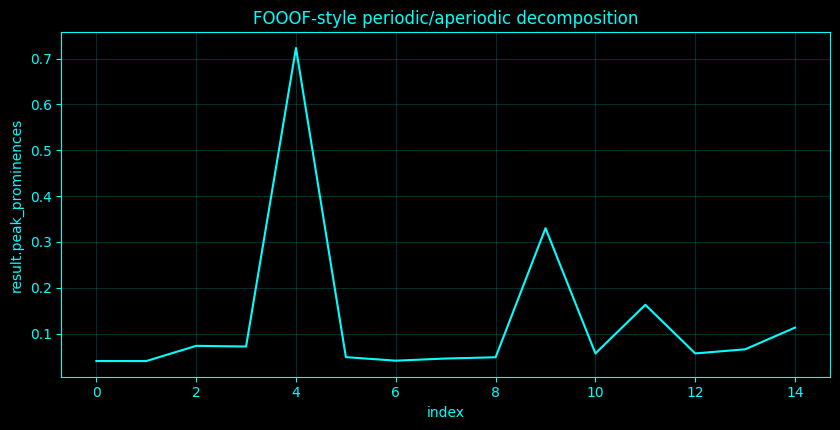

In [98]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

def _aperiodic_params(psd=None, f=None):
    if f is None or psd is None:
        f, Pa = _welch_all()
        psd = np.mean(Pa, axis=1)
    m = (f >= 2) & (f <= 45)
    x = np.log10(f[m])
    y = np.log10(psd[m] + EPS)
    coef = np.polyfit(x, y, 1)
    offset, exponent = (float(coef[1]), float(-coef[0]))
    fit = 10 ** (offset - exponent * np.log10(f + EPS))
    return (offset, exponent, fit)

def _peak_params(psd=None, f=None, band=(4, 30)):
    if f is None or psd is None:
        f, P = _welch_all()
        psd = np.mean(P, axis=1)
    _, _, ap = _aperiodic_params(psd, f)
    res = np.log10(psd + EPS) - np.log10(ap + EPS)
    m = (f >= band[0]) & (f <= band[1])
    peaks, props = signal.find_peaks(res[m], prominence=max(0.02, np.std(res[m]) * 0.3))
    fi = f[m][peaks]
    prom = props.get('prominences', np.array([]))
    return (fi, prom, res, ap)

def _irasa_channel(ch=0):
    key = ('irasa', ch)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    y = X[:, ch]
    f0, p0 = _psd_of(y[:, None])
    p0 = p0[:, 0]
    hs = np.array([1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9])
    geos = []
    from fractions import Fraction
    for h in hs:
        frac = Fraction(float(h)).limit_denominator(20)
        y1 = signal.resample_poly(y, frac.numerator, frac.denominator)
        y2 = signal.resample_poly(y, frac.denominator, frac.numerator)
        f1, p1 = signal.welch(y1, fs=_fs * h, nperseg=min(_SPEED['nperseg'], len(y1)))
        f2, p2 = signal.welch(y2, fs=_fs / h, nperseg=min(_SPEED['nperseg'], len(y2)))
        q1 = np.interp(f0, f1, p1)
        q2 = np.interp(f0, f2, p2)
        geos.append(np.sqrt(np.maximum(q1 * q2, 0)))
    fract = np.median(np.asarray(geos), axis=0)
    osc = np.maximum(p0 - fract, 0)
    SPEC_CACHE[key] = (f0, p0, fract, osc)
    return SPEC_CACHE[key]

# Method-specific calculation.
def _compute_method_98():
    idx = 98
    name = 'FOOOF-style periodic/aperiodic decomposition'
    __plot_spec = None
    f, P = _welch_all()
    p = np.mean(P, axis=1)
    off, expn, ap = _aperiodic_params(p, f)
    peaks, prom, res, ap = _peak_params(p, f)
    return ({'style': 'transparent log-log aperiodic fit plus residual peak parameterization; not package-identical', 'aperiodic_exponent': expn, 'offset': off, 'peak_frequencies_hz': peaks.tolist(), 'peak_prominences': prom.tolist()}, locals().get('__plot_spec', None))
    f0, p0, fract, osc = _irasa_channel(0)
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_98,_plot_spec=_compute_method_98()
print('FOOOF-style periodic/aperiodic decomposition')
if isinstance(result_98,dict):
    for _k,_v in result_98.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_98)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_98)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'FOOOF-style periodic/aperiodic decomposition',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'FOOOF-style periodic/aperiodic decomposition',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('FOOOF-style periodic/aperiodic decomposition',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">99. SpecParam-style oscillation decomposition</h3>
<p>FOOOF/SpecParam-style decomposition models log power as an aperiodic background plus localized periodic peaks. This notebook transparently fits a log-log aperiodic line and parameterizes positive residual peaks; it does not claim bit-for-bit equivalence with external packages.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


SpecParam-style oscillation decomposition
  style: transparent log-log aperiodic fit plus residual peak parameterization; not package-identical
  aperiodic_exponent: 1.2044092662432204
  offset: -1.8675339449715904
  peak_frequencies_hz: array(15,), mean=14.86
  peak_prominences: array(15,), mean=0.127825


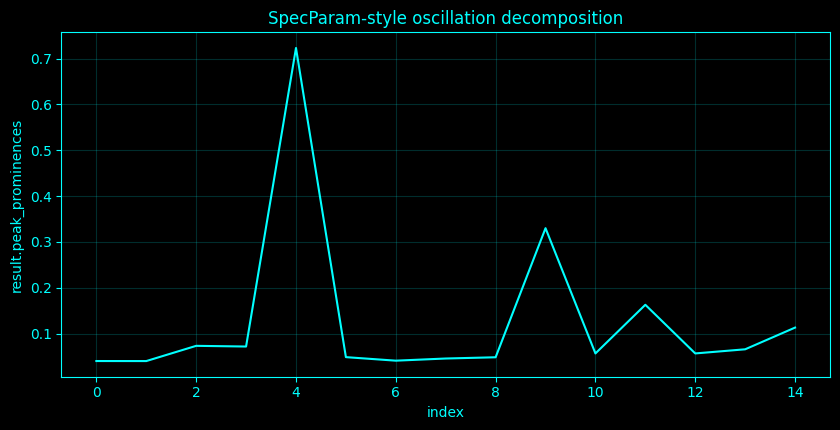

In [99]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

def _aperiodic_params(psd=None, f=None):
    if f is None or psd is None:
        f, Pa = _welch_all()
        psd = np.mean(Pa, axis=1)
    m = (f >= 2) & (f <= 45)
    x = np.log10(f[m])
    y = np.log10(psd[m] + EPS)
    coef = np.polyfit(x, y, 1)
    offset, exponent = (float(coef[1]), float(-coef[0]))
    fit = 10 ** (offset - exponent * np.log10(f + EPS))
    return (offset, exponent, fit)

def _peak_params(psd=None, f=None, band=(4, 30)):
    if f is None or psd is None:
        f, P = _welch_all()
        psd = np.mean(P, axis=1)
    _, _, ap = _aperiodic_params(psd, f)
    res = np.log10(psd + EPS) - np.log10(ap + EPS)
    m = (f >= band[0]) & (f <= band[1])
    peaks, props = signal.find_peaks(res[m], prominence=max(0.02, np.std(res[m]) * 0.3))
    fi = f[m][peaks]
    prom = props.get('prominences', np.array([]))
    return (fi, prom, res, ap)

def _irasa_channel(ch=0):
    key = ('irasa', ch)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    y = X[:, ch]
    f0, p0 = _psd_of(y[:, None])
    p0 = p0[:, 0]
    hs = np.array([1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9])
    geos = []
    from fractions import Fraction
    for h in hs:
        frac = Fraction(float(h)).limit_denominator(20)
        y1 = signal.resample_poly(y, frac.numerator, frac.denominator)
        y2 = signal.resample_poly(y, frac.denominator, frac.numerator)
        f1, p1 = signal.welch(y1, fs=_fs * h, nperseg=min(_SPEED['nperseg'], len(y1)))
        f2, p2 = signal.welch(y2, fs=_fs / h, nperseg=min(_SPEED['nperseg'], len(y2)))
        q1 = np.interp(f0, f1, p1)
        q2 = np.interp(f0, f2, p2)
        geos.append(np.sqrt(np.maximum(q1 * q2, 0)))
    fract = np.median(np.asarray(geos), axis=0)
    osc = np.maximum(p0 - fract, 0)
    SPEC_CACHE[key] = (f0, p0, fract, osc)
    return SPEC_CACHE[key]

# Method-specific calculation.
def _compute_method_99():
    idx = 99
    name = 'SpecParam-style oscillation decomposition'
    __plot_spec = None
    f, P = _welch_all()
    p = np.mean(P, axis=1)
    off, expn, ap = _aperiodic_params(p, f)
    peaks, prom, res, ap = _peak_params(p, f)
    return ({'style': 'transparent log-log aperiodic fit plus residual peak parameterization; not package-identical', 'aperiodic_exponent': expn, 'offset': off, 'peak_frequencies_hz': peaks.tolist(), 'peak_prominences': prom.tolist()}, locals().get('__plot_spec', None))
    f0, p0, fract, osc = _irasa_channel(0)
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_99,_plot_spec=_compute_method_99()
print('SpecParam-style oscillation decomposition')
if isinstance(result_99,dict):
    for _k,_v in result_99.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_99)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_99)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'SpecParam-style oscillation decomposition',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'SpecParam-style oscillation decomposition',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('SpecParam-style oscillation decomposition',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">100. Aperiodic offset analysis</h3>
<p>The aperiodic offset \(b\) is the intercept of \(\log_{10}P=b-\chi\log_{10}f\), setting the overall level of the fitted background.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [100]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

def _aperiodic_params(psd=None, f=None):
    if f is None or psd is None:
        f, Pa = _welch_all()
        psd = np.mean(Pa, axis=1)
    m = (f >= 2) & (f <= 45)
    x = np.log10(f[m])
    y = np.log10(psd[m] + EPS)
    coef = np.polyfit(x, y, 1)
    offset, exponent = (float(coef[1]), float(-coef[0]))
    fit = 10 ** (offset - exponent * np.log10(f + EPS))
    return (offset, exponent, fit)

def _peak_params(psd=None, f=None, band=(4, 30)):
    if f is None or psd is None:
        f, P = _welch_all()
        psd = np.mean(P, axis=1)
    _, _, ap = _aperiodic_params(psd, f)
    res = np.log10(psd + EPS) - np.log10(ap + EPS)
    m = (f >= band[0]) & (f <= band[1])
    peaks, props = signal.find_peaks(res[m], prominence=max(0.02, np.std(res[m]) * 0.3))
    fi = f[m][peaks]
    prom = props.get('prominences', np.array([]))
    return (fi, prom, res, ap)

def _irasa_channel(ch=0):
    key = ('irasa', ch)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    y = X[:, ch]
    f0, p0 = _psd_of(y[:, None])
    p0 = p0[:, 0]
    hs = np.array([1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9])
    geos = []
    from fractions import Fraction
    for h in hs:
        frac = Fraction(float(h)).limit_denominator(20)
        y1 = signal.resample_poly(y, frac.numerator, frac.denominator)
        y2 = signal.resample_poly(y, frac.denominator, frac.numerator)
        f1, p1 = signal.welch(y1, fs=_fs * h, nperseg=min(_SPEED['nperseg'], len(y1)))
        f2, p2 = signal.welch(y2, fs=_fs / h, nperseg=min(_SPEED['nperseg'], len(y2)))
        q1 = np.interp(f0, f1, p1)
        q2 = np.interp(f0, f2, p2)
        geos.append(np.sqrt(np.maximum(q1 * q2, 0)))
    fract = np.median(np.asarray(geos), axis=0)
    osc = np.maximum(p0 - fract, 0)
    SPEC_CACHE[key] = (f0, p0, fract, osc)
    return SPEC_CACHE[key]

# Method-specific calculation.
def _compute_method_100():
    idx = 100
    name = 'Aperiodic offset analysis'
    __plot_spec = None
    f, P = _welch_all()
    p = np.mean(P, axis=1)
    off, expn, ap = _aperiodic_params(p, f)
    peaks, prom, res, ap = _peak_params(p, f)
    return ({'aperiodic_log10_offset': off}, locals().get('__plot_spec', None))
    f0, p0, fract, osc = _irasa_channel(0)
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_100,_plot_spec=_compute_method_100()
print('Aperiodic offset analysis')
if isinstance(result_100,dict):
    for _k,_v in result_100.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_100)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_100)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Aperiodic offset analysis',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Aperiodic offset analysis',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Aperiodic offset analysis',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Aperiodic offset analysis
  aperiodic_log10_offset: -1.8675339449715904


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">101. Aperiodic knee frequency estimation</h3>
<p>A knee model uses \(\log_{10}P(f)=b-\log_{10}(k+f^\chi)\). The characteristic knee frequency is \(f_k=k^{1/\chi}\) when \(k>0\).</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Aperiodic knee frequency estimation
  offset: -1.8675339449050574
  knee_hz: 1.2411322430917772e-11
  exponent: 1.204409266221105


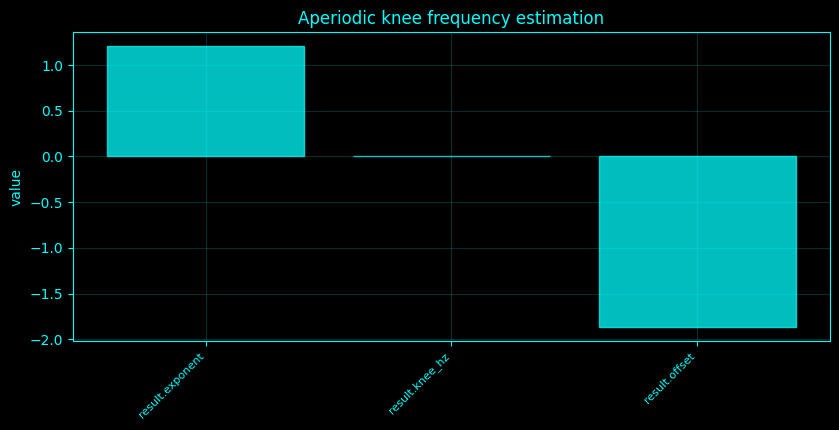

In [101]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

def _aperiodic_params(psd=None, f=None):
    if f is None or psd is None:
        f, Pa = _welch_all()
        psd = np.mean(Pa, axis=1)
    m = (f >= 2) & (f <= 45)
    x = np.log10(f[m])
    y = np.log10(psd[m] + EPS)
    coef = np.polyfit(x, y, 1)
    offset, exponent = (float(coef[1]), float(-coef[0]))
    fit = 10 ** (offset - exponent * np.log10(f + EPS))
    return (offset, exponent, fit)

def _peak_params(psd=None, f=None, band=(4, 30)):
    if f is None or psd is None:
        f, P = _welch_all()
        psd = np.mean(P, axis=1)
    _, _, ap = _aperiodic_params(psd, f)
    res = np.log10(psd + EPS) - np.log10(ap + EPS)
    m = (f >= band[0]) & (f <= band[1])
    peaks, props = signal.find_peaks(res[m], prominence=max(0.02, np.std(res[m]) * 0.3))
    fi = f[m][peaks]
    prom = props.get('prominences', np.array([]))
    return (fi, prom, res, ap)

def _irasa_channel(ch=0):
    key = ('irasa', ch)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    y = X[:, ch]
    f0, p0 = _psd_of(y[:, None])
    p0 = p0[:, 0]
    hs = np.array([1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9])
    geos = []
    from fractions import Fraction
    for h in hs:
        frac = Fraction(float(h)).limit_denominator(20)
        y1 = signal.resample_poly(y, frac.numerator, frac.denominator)
        y2 = signal.resample_poly(y, frac.denominator, frac.numerator)
        f1, p1 = signal.welch(y1, fs=_fs * h, nperseg=min(_SPEED['nperseg'], len(y1)))
        f2, p2 = signal.welch(y2, fs=_fs / h, nperseg=min(_SPEED['nperseg'], len(y2)))
        q1 = np.interp(f0, f1, p1)
        q2 = np.interp(f0, f2, p2)
        geos.append(np.sqrt(np.maximum(q1 * q2, 0)))
    fract = np.median(np.asarray(geos), axis=0)
    osc = np.maximum(p0 - fract, 0)
    SPEC_CACHE[key] = (f0, p0, fract, osc)
    return SPEC_CACHE[key]

# Method-specific calculation.
def _compute_method_101():
    idx = 101
    name = 'Aperiodic knee frequency estimation'
    __plot_spec = None
    f, P = _welch_all()
    p = np.mean(P, axis=1)
    off, expn, ap = _aperiodic_params(p, f)
    peaks, prom, res, ap = _peak_params(p, f)
    from scipy.optimize import curve_fit
    m = (f >= 2) & (f <= 45)

    def fun(ff, b, k, chi):
        return b - np.log10(np.maximum(k + ff ** chi, EPS))
    try:
        popt, _ = curve_fit(fun, f[m], np.log10(p[m] + EPS), p0=[off, 1, max(0.5, expn)], bounds=([-10, 0, 0.1], [10, 100000.0, 6]), maxfev=20000)
        knee = float(popt[1] ** (1 / max(popt[2], EPS))) if popt[1] > 0 else 0.0
        return ({'offset': float(popt[0]), 'knee_hz': knee, 'exponent': float(popt[2])}, locals().get('__plot_spec', None))
    except Exception:
        return ({'knee_hz': np.nan, 'status': 'nonlinear knee fit did not converge'}, locals().get('__plot_spec', None))
    f0, p0, fract, osc = _irasa_channel(0)
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_101,_plot_spec=_compute_method_101()
print('Aperiodic knee frequency estimation')
if isinstance(result_101,dict):
    for _k,_v in result_101.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_101)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_101)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Aperiodic knee frequency estimation',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Aperiodic knee frequency estimation',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Aperiodic knee frequency estimation',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">102. Periodic peak parameterization</h3>
<p>Periodic peaks are identified in the residual after subtracting the fitted aperiodic background. Center frequency, half-prominence width, residual height, and prominence quantify distinct peak properties.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Periodic peak parameterization
  center_hz: array(15,), mean=14.86
  prominence_log10: array(15,), mean=0.127825


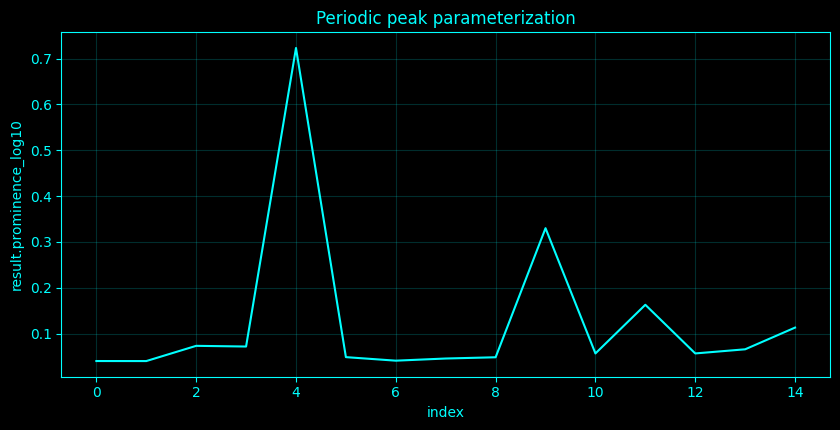

In [102]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

def _aperiodic_params(psd=None, f=None):
    if f is None or psd is None:
        f, Pa = _welch_all()
        psd = np.mean(Pa, axis=1)
    m = (f >= 2) & (f <= 45)
    x = np.log10(f[m])
    y = np.log10(psd[m] + EPS)
    coef = np.polyfit(x, y, 1)
    offset, exponent = (float(coef[1]), float(-coef[0]))
    fit = 10 ** (offset - exponent * np.log10(f + EPS))
    return (offset, exponent, fit)

def _peak_params(psd=None, f=None, band=(4, 30)):
    if f is None or psd is None:
        f, P = _welch_all()
        psd = np.mean(P, axis=1)
    _, _, ap = _aperiodic_params(psd, f)
    res = np.log10(psd + EPS) - np.log10(ap + EPS)
    m = (f >= band[0]) & (f <= band[1])
    peaks, props = signal.find_peaks(res[m], prominence=max(0.02, np.std(res[m]) * 0.3))
    fi = f[m][peaks]
    prom = props.get('prominences', np.array([]))
    return (fi, prom, res, ap)

def _irasa_channel(ch=0):
    key = ('irasa', ch)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    y = X[:, ch]
    f0, p0 = _psd_of(y[:, None])
    p0 = p0[:, 0]
    hs = np.array([1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9])
    geos = []
    from fractions import Fraction
    for h in hs:
        frac = Fraction(float(h)).limit_denominator(20)
        y1 = signal.resample_poly(y, frac.numerator, frac.denominator)
        y2 = signal.resample_poly(y, frac.denominator, frac.numerator)
        f1, p1 = signal.welch(y1, fs=_fs * h, nperseg=min(_SPEED['nperseg'], len(y1)))
        f2, p2 = signal.welch(y2, fs=_fs / h, nperseg=min(_SPEED['nperseg'], len(y2)))
        q1 = np.interp(f0, f1, p1)
        q2 = np.interp(f0, f2, p2)
        geos.append(np.sqrt(np.maximum(q1 * q2, 0)))
    fract = np.median(np.asarray(geos), axis=0)
    osc = np.maximum(p0 - fract, 0)
    SPEC_CACHE[key] = (f0, p0, fract, osc)
    return SPEC_CACHE[key]

# Method-specific calculation.
def _compute_method_102():
    idx = 102
    name = 'Periodic peak parameterization'
    __plot_spec = None
    f, P = _welch_all()
    p = np.mean(P, axis=1)
    off, expn, ap = _aperiodic_params(p, f)
    peaks, prom, res, ap = _peak_params(p, f)
    if not len(peaks):
        return ({'peaks': []}, locals().get('__plot_spec', None))
    return ({'center_hz': peaks.tolist(), 'prominence_log10': prom.tolist()}, locals().get('__plot_spec', None))
    f0, p0, fract, osc = _irasa_channel(0)
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_102,_plot_spec=_compute_method_102()
print('Periodic peak parameterization')
if isinstance(result_102,dict):
    for _k,_v in result_102.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_102)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_102)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Periodic peak parameterization',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Periodic peak parameterization',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Periodic peak parameterization',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">103. Oscillation peak bandwidth analysis</h3>
<p>Periodic peaks are identified in the residual after subtracting the fitted aperiodic background. Center frequency, half-prominence width, residual height, and prominence quantify distinct peak properties.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [103]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

def _aperiodic_params(psd=None, f=None):
    if f is None or psd is None:
        f, Pa = _welch_all()
        psd = np.mean(Pa, axis=1)
    m = (f >= 2) & (f <= 45)
    x = np.log10(f[m])
    y = np.log10(psd[m] + EPS)
    coef = np.polyfit(x, y, 1)
    offset, exponent = (float(coef[1]), float(-coef[0]))
    fit = 10 ** (offset - exponent * np.log10(f + EPS))
    return (offset, exponent, fit)

def _peak_params(psd=None, f=None, band=(4, 30)):
    if f is None or psd is None:
        f, P = _welch_all()
        psd = np.mean(P, axis=1)
    _, _, ap = _aperiodic_params(psd, f)
    res = np.log10(psd + EPS) - np.log10(ap + EPS)
    m = (f >= band[0]) & (f <= band[1])
    peaks, props = signal.find_peaks(res[m], prominence=max(0.02, np.std(res[m]) * 0.3))
    fi = f[m][peaks]
    prom = props.get('prominences', np.array([]))
    return (fi, prom, res, ap)

def _irasa_channel(ch=0):
    key = ('irasa', ch)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    y = X[:, ch]
    f0, p0 = _psd_of(y[:, None])
    p0 = p0[:, 0]
    hs = np.array([1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9])
    geos = []
    from fractions import Fraction
    for h in hs:
        frac = Fraction(float(h)).limit_denominator(20)
        y1 = signal.resample_poly(y, frac.numerator, frac.denominator)
        y2 = signal.resample_poly(y, frac.denominator, frac.numerator)
        f1, p1 = signal.welch(y1, fs=_fs * h, nperseg=min(_SPEED['nperseg'], len(y1)))
        f2, p2 = signal.welch(y2, fs=_fs / h, nperseg=min(_SPEED['nperseg'], len(y2)))
        q1 = np.interp(f0, f1, p1)
        q2 = np.interp(f0, f2, p2)
        geos.append(np.sqrt(np.maximum(q1 * q2, 0)))
    fract = np.median(np.asarray(geos), axis=0)
    osc = np.maximum(p0 - fract, 0)
    SPEC_CACHE[key] = (f0, p0, fract, osc)
    return SPEC_CACHE[key]

# Method-specific calculation.
def _compute_method_103():
    idx = 103
    name = 'Oscillation peak bandwidth analysis'
    __plot_spec = None
    f, P = _welch_all()
    p = np.mean(P, axis=1)
    off, expn, ap = _aperiodic_params(p, f)
    peaks, prom, res, ap = _peak_params(p, f)
    m = (f >= 4) & (f <= 30)
    rr = res[m]
    inds, props = signal.find_peaks(rr, prominence=max(0.02, np.std(rr) * 0.3))
    if not len(inds):
        return ({'status': 'no periodic residual peak'}, locals().get('__plot_spec', None))
    k = inds[np.argmax(props['prominences'])]
    fi = np.where(m)[0][k]
    widths = signal.peak_widths(rr, [k], rel_height=0.5)[0]
    df = np.median(np.diff(f))
    return ({'FWHM_like_hz': float(widths[0] * df)}, locals().get('__plot_spec', None))
    return ({'peak_prominence_log10': float(np.max(props['prominences']))}, locals().get('__plot_spec', None))
    f0, p0, fract, osc = _irasa_channel(0)
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_103,_plot_spec=_compute_method_103()
print('Oscillation peak bandwidth analysis')
if isinstance(result_103,dict):
    for _k,_v in result_103.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_103)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_103)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Oscillation peak bandwidth analysis',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Oscillation peak bandwidth analysis',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Oscillation peak bandwidth analysis',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Oscillation peak bandwidth analysis
  FWHM_like_hz: 1.4292928601806416


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">104. Oscillation peak height analysis</h3>
<p>Periodic peaks are identified in the residual after subtracting the fitted aperiodic background. Center frequency, half-prominence width, residual height, and prominence quantify distinct peak properties.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [104]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

def _aperiodic_params(psd=None, f=None):
    if f is None or psd is None:
        f, Pa = _welch_all()
        psd = np.mean(Pa, axis=1)
    m = (f >= 2) & (f <= 45)
    x = np.log10(f[m])
    y = np.log10(psd[m] + EPS)
    coef = np.polyfit(x, y, 1)
    offset, exponent = (float(coef[1]), float(-coef[0]))
    fit = 10 ** (offset - exponent * np.log10(f + EPS))
    return (offset, exponent, fit)

def _peak_params(psd=None, f=None, band=(4, 30)):
    if f is None or psd is None:
        f, P = _welch_all()
        psd = np.mean(P, axis=1)
    _, _, ap = _aperiodic_params(psd, f)
    res = np.log10(psd + EPS) - np.log10(ap + EPS)
    m = (f >= band[0]) & (f <= band[1])
    peaks, props = signal.find_peaks(res[m], prominence=max(0.02, np.std(res[m]) * 0.3))
    fi = f[m][peaks]
    prom = props.get('prominences', np.array([]))
    return (fi, prom, res, ap)

def _irasa_channel(ch=0):
    key = ('irasa', ch)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    y = X[:, ch]
    f0, p0 = _psd_of(y[:, None])
    p0 = p0[:, 0]
    hs = np.array([1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9])
    geos = []
    from fractions import Fraction
    for h in hs:
        frac = Fraction(float(h)).limit_denominator(20)
        y1 = signal.resample_poly(y, frac.numerator, frac.denominator)
        y2 = signal.resample_poly(y, frac.denominator, frac.numerator)
        f1, p1 = signal.welch(y1, fs=_fs * h, nperseg=min(_SPEED['nperseg'], len(y1)))
        f2, p2 = signal.welch(y2, fs=_fs / h, nperseg=min(_SPEED['nperseg'], len(y2)))
        q1 = np.interp(f0, f1, p1)
        q2 = np.interp(f0, f2, p2)
        geos.append(np.sqrt(np.maximum(q1 * q2, 0)))
    fract = np.median(np.asarray(geos), axis=0)
    osc = np.maximum(p0 - fract, 0)
    SPEC_CACHE[key] = (f0, p0, fract, osc)
    return SPEC_CACHE[key]

# Method-specific calculation.
def _compute_method_104():
    idx = 104
    name = 'Oscillation peak height analysis'
    __plot_spec = None
    f, P = _welch_all()
    p = np.mean(P, axis=1)
    off, expn, ap = _aperiodic_params(p, f)
    peaks, prom, res, ap = _peak_params(p, f)
    m = (f >= 4) & (f <= 30)
    rr = res[m]
    inds, props = signal.find_peaks(rr, prominence=max(0.02, np.std(rr) * 0.3))
    if not len(inds):
        return ({'status': 'no periodic residual peak'}, locals().get('__plot_spec', None))
    k = inds[np.argmax(props['prominences'])]
    fi = np.where(m)[0][k]
    return ({'peak_height_log10_above_aperiodic': float(res[fi])}, locals().get('__plot_spec', None))
    return ({'peak_prominence_log10': float(np.max(props['prominences']))}, locals().get('__plot_spec', None))
    f0, p0, fract, osc = _irasa_channel(0)
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_104,_plot_spec=_compute_method_104()
print('Oscillation peak height analysis')
if isinstance(result_104,dict):
    for _k,_v in result_104.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_104)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_104)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Oscillation peak height analysis',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Oscillation peak height analysis',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Oscillation peak height analysis',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Oscillation peak height analysis
  peak_height_log10_above_aperiodic: 0.5628846646173198


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">105. Oscillation peak prominence analysis</h3>
<p>Periodic peaks are identified in the residual after subtracting the fitted aperiodic background. Center frequency, half-prominence width, residual height, and prominence quantify distinct peak properties.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [105]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

def _aperiodic_params(psd=None, f=None):
    if f is None or psd is None:
        f, Pa = _welch_all()
        psd = np.mean(Pa, axis=1)
    m = (f >= 2) & (f <= 45)
    x = np.log10(f[m])
    y = np.log10(psd[m] + EPS)
    coef = np.polyfit(x, y, 1)
    offset, exponent = (float(coef[1]), float(-coef[0]))
    fit = 10 ** (offset - exponent * np.log10(f + EPS))
    return (offset, exponent, fit)

def _peak_params(psd=None, f=None, band=(4, 30)):
    if f is None or psd is None:
        f, P = _welch_all()
        psd = np.mean(P, axis=1)
    _, _, ap = _aperiodic_params(psd, f)
    res = np.log10(psd + EPS) - np.log10(ap + EPS)
    m = (f >= band[0]) & (f <= band[1])
    peaks, props = signal.find_peaks(res[m], prominence=max(0.02, np.std(res[m]) * 0.3))
    fi = f[m][peaks]
    prom = props.get('prominences', np.array([]))
    return (fi, prom, res, ap)

def _irasa_channel(ch=0):
    key = ('irasa', ch)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    y = X[:, ch]
    f0, p0 = _psd_of(y[:, None])
    p0 = p0[:, 0]
    hs = np.array([1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9])
    geos = []
    from fractions import Fraction
    for h in hs:
        frac = Fraction(float(h)).limit_denominator(20)
        y1 = signal.resample_poly(y, frac.numerator, frac.denominator)
        y2 = signal.resample_poly(y, frac.denominator, frac.numerator)
        f1, p1 = signal.welch(y1, fs=_fs * h, nperseg=min(_SPEED['nperseg'], len(y1)))
        f2, p2 = signal.welch(y2, fs=_fs / h, nperseg=min(_SPEED['nperseg'], len(y2)))
        q1 = np.interp(f0, f1, p1)
        q2 = np.interp(f0, f2, p2)
        geos.append(np.sqrt(np.maximum(q1 * q2, 0)))
    fract = np.median(np.asarray(geos), axis=0)
    osc = np.maximum(p0 - fract, 0)
    SPEC_CACHE[key] = (f0, p0, fract, osc)
    return SPEC_CACHE[key]

# Method-specific calculation.
def _compute_method_105():
    idx = 105
    name = 'Oscillation peak prominence analysis'
    __plot_spec = None
    f, P = _welch_all()
    p = np.mean(P, axis=1)
    off, expn, ap = _aperiodic_params(p, f)
    peaks, prom, res, ap = _peak_params(p, f)
    m = (f >= 4) & (f <= 30)
    rr = res[m]
    inds, props = signal.find_peaks(rr, prominence=max(0.02, np.std(rr) * 0.3))
    if not len(inds):
        return ({'status': 'no periodic residual peak'}, locals().get('__plot_spec', None))
    k = inds[np.argmax(props['prominences'])]
    fi = np.where(m)[0][k]
    return ({'peak_prominence_log10': float(np.max(props['prominences']))}, locals().get('__plot_spec', None))
    f0, p0, fract, osc = _irasa_channel(0)
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_105,_plot_spec=_compute_method_105()
print('Oscillation peak prominence analysis')
if isinstance(result_105,dict):
    for _k,_v in result_105.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_105)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_105)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Oscillation peak prominence analysis',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Oscillation peak prominence analysis',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Oscillation peak prominence analysis',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Oscillation peak prominence analysis
  peak_prominence_log10: 0.7229428364865074


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">106. Aperiodic-corrected bandpower</h3>
<p>Aperiodic-corrected bandpower integrates the positive linear-power residual \(\max[P(f)-P_{aper}(f),0]\) over each band.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Aperiodic-corrected bandpower
  delta: 0.000994736906267419
  theta: 3.0451767876704473e-05
  alpha: 0.0021229321956745787
  beta: 0.00013068119184575188
  gamma: 0.0005325562624211896


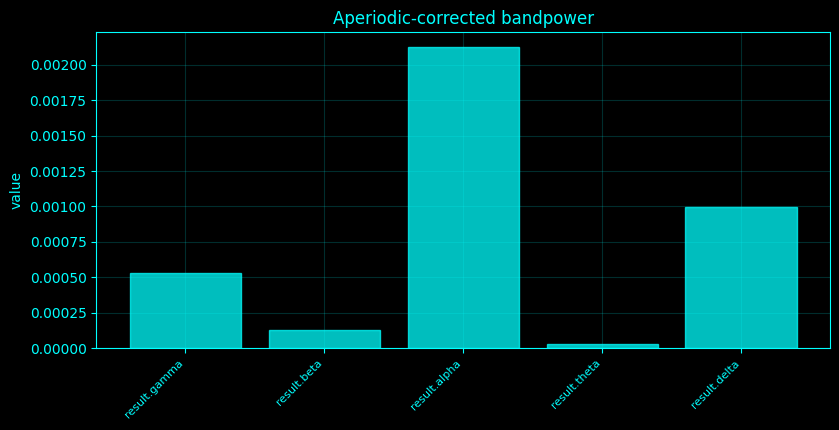

In [106]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

def _aperiodic_params(psd=None, f=None):
    if f is None or psd is None:
        f, Pa = _welch_all()
        psd = np.mean(Pa, axis=1)
    m = (f >= 2) & (f <= 45)
    x = np.log10(f[m])
    y = np.log10(psd[m] + EPS)
    coef = np.polyfit(x, y, 1)
    offset, exponent = (float(coef[1]), float(-coef[0]))
    fit = 10 ** (offset - exponent * np.log10(f + EPS))
    return (offset, exponent, fit)

def _peak_params(psd=None, f=None, band=(4, 30)):
    if f is None or psd is None:
        f, P = _welch_all()
        psd = np.mean(P, axis=1)
    _, _, ap = _aperiodic_params(psd, f)
    res = np.log10(psd + EPS) - np.log10(ap + EPS)
    m = (f >= band[0]) & (f <= band[1])
    peaks, props = signal.find_peaks(res[m], prominence=max(0.02, np.std(res[m]) * 0.3))
    fi = f[m][peaks]
    prom = props.get('prominences', np.array([]))
    return (fi, prom, res, ap)

def _irasa_channel(ch=0):
    key = ('irasa', ch)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    y = X[:, ch]
    f0, p0 = _psd_of(y[:, None])
    p0 = p0[:, 0]
    hs = np.array([1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9])
    geos = []
    from fractions import Fraction
    for h in hs:
        frac = Fraction(float(h)).limit_denominator(20)
        y1 = signal.resample_poly(y, frac.numerator, frac.denominator)
        y2 = signal.resample_poly(y, frac.denominator, frac.numerator)
        f1, p1 = signal.welch(y1, fs=_fs * h, nperseg=min(_SPEED['nperseg'], len(y1)))
        f2, p2 = signal.welch(y2, fs=_fs / h, nperseg=min(_SPEED['nperseg'], len(y2)))
        q1 = np.interp(f0, f1, p1)
        q2 = np.interp(f0, f2, p2)
        geos.append(np.sqrt(np.maximum(q1 * q2, 0)))
    fract = np.median(np.asarray(geos), axis=0)
    osc = np.maximum(p0 - fract, 0)
    SPEC_CACHE[key] = (f0, p0, fract, osc)
    return SPEC_CACHE[key]

# Method-specific calculation.
def _compute_method_106():
    idx = 106
    name = 'Aperiodic-corrected bandpower'
    __plot_spec = None
    f, P = _welch_all()
    p = np.mean(P, axis=1)
    off, expn, ap = _aperiodic_params(p, f)
    peaks, prom, res, ap = _peak_params(p, f)
    corr = np.maximum(p - ap, 0)
    vals = {bn: float(_band_integral(corr[:, None], f, b)[0]) for bn, b in BANDS.items()}
    return (vals, locals().get('__plot_spec', None))
    f0, p0, fract, osc = _irasa_channel(0)
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_106,_plot_spec=_compute_method_106()
print('Aperiodic-corrected bandpower')
if isinstance(result_106,dict):
    for _k,_v in result_106.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_106)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_106)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Aperiodic-corrected bandpower',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Aperiodic-corrected bandpower',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Aperiodic-corrected bandpower',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">107. Aperiodic-corrected alpha peak analysis</h3>
<p>Aperiodic-corrected alpha analysis finds the largest positive residual within 8–13 Hz rather than the largest raw PSD value.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A power spectral density describes how signal power is distributed over frequency. Welch's method divides the time series into overlapping segments, windows each segment to reduce edge discontinuities, computes a periodogram for each segment, and averages the results. Averaging reduces the variance of the spectral estimate at the cost of some frequency resolution. The area under the PSD over a frequency band corresponds to power in that band, subject to the normalization convention used by the implementation.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Aperiodic-corrected alpha peak analysis
  corrected_alpha_peak_hz: 10.498046875
  height: 0.0021217503997414274


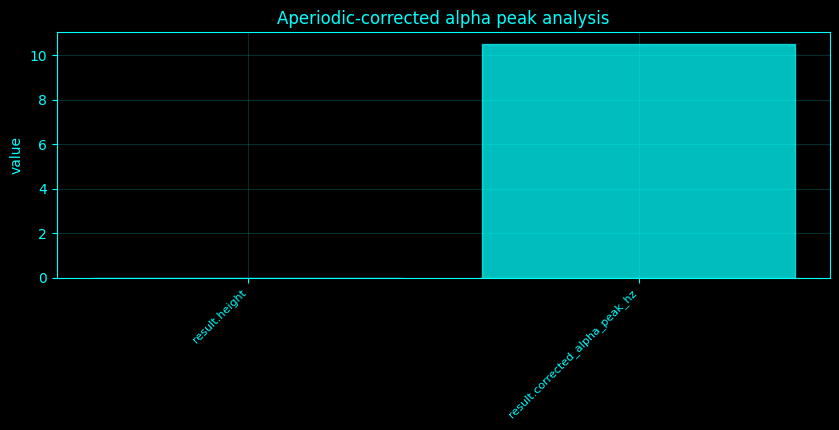

In [107]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

def _aperiodic_params(psd=None, f=None):
    if f is None or psd is None:
        f, Pa = _welch_all()
        psd = np.mean(Pa, axis=1)
    m = (f >= 2) & (f <= 45)
    x = np.log10(f[m])
    y = np.log10(psd[m] + EPS)
    coef = np.polyfit(x, y, 1)
    offset, exponent = (float(coef[1]), float(-coef[0]))
    fit = 10 ** (offset - exponent * np.log10(f + EPS))
    return (offset, exponent, fit)

def _peak_params(psd=None, f=None, band=(4, 30)):
    if f is None or psd is None:
        f, P = _welch_all()
        psd = np.mean(P, axis=1)
    _, _, ap = _aperiodic_params(psd, f)
    res = np.log10(psd + EPS) - np.log10(ap + EPS)
    m = (f >= band[0]) & (f <= band[1])
    peaks, props = signal.find_peaks(res[m], prominence=max(0.02, np.std(res[m]) * 0.3))
    fi = f[m][peaks]
    prom = props.get('prominences', np.array([]))
    return (fi, prom, res, ap)

def _irasa_channel(ch=0):
    key = ('irasa', ch)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    y = X[:, ch]
    f0, p0 = _psd_of(y[:, None])
    p0 = p0[:, 0]
    hs = np.array([1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9])
    geos = []
    from fractions import Fraction
    for h in hs:
        frac = Fraction(float(h)).limit_denominator(20)
        y1 = signal.resample_poly(y, frac.numerator, frac.denominator)
        y2 = signal.resample_poly(y, frac.denominator, frac.numerator)
        f1, p1 = signal.welch(y1, fs=_fs * h, nperseg=min(_SPEED['nperseg'], len(y1)))
        f2, p2 = signal.welch(y2, fs=_fs / h, nperseg=min(_SPEED['nperseg'], len(y2)))
        q1 = np.interp(f0, f1, p1)
        q2 = np.interp(f0, f2, p2)
        geos.append(np.sqrt(np.maximum(q1 * q2, 0)))
    fract = np.median(np.asarray(geos), axis=0)
    osc = np.maximum(p0 - fract, 0)
    SPEC_CACHE[key] = (f0, p0, fract, osc)
    return SPEC_CACHE[key]

# Method-specific calculation.
def _compute_method_107():
    idx = 107
    name = 'Aperiodic-corrected alpha peak analysis'
    __plot_spec = None
    f, P = _welch_all()
    p = np.mean(P, axis=1)
    off, expn, ap = _aperiodic_params(p, f)
    peaks, prom, res, ap = _peak_params(p, f)
    corr = np.maximum(p - ap, 0)
    m = (f >= 8) & (f < 13)
    return ({'corrected_alpha_peak_hz': float(f[m][np.argmax(corr[m])]), 'height': float(np.max(corr[m]))}, locals().get('__plot_spec', None))
    f0, p0, fract, osc = _irasa_channel(0)
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_107,_plot_spec=_compute_method_107()
print('Aperiodic-corrected alpha peak analysis')
if isinstance(result_107,dict):
    for _k,_v in result_107.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_107)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_107)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Aperiodic-corrected alpha peak analysis',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Aperiodic-corrected alpha peak analysis',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Aperiodic-corrected alpha peak analysis',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">108. Aperiodic-corrected coherence</h3>
<p>Positive frequency-wise scaling of each channel cancels exactly in magnitude-squared coherence. The cell verifies this invariance for aperiodic whitening rather than falsely reporting altered coherence.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Coherence is a frequency-specific measure of linear association between two signals. It compares the magnitude of their cross-spectrum with the power spectra of the individual signals. Values near one mean that a stable linear relationship at that frequency explains a large fraction of the spectral activity, while values near zero indicate weak consistency. High coherence can arise from common input, volume conduction, or shared reference effects, so it should not automatically be interpreted as direct connectivity.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [108]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

def _cross_spectral_matrix():
    if 'csm' in SPEC_CACHE:
        return SPEC_CACHE['csm']
    n = min(int(_SPEED['nperseg']), N)
    step = max(1, n // 2)
    win = signal.windows.hann(n)
    acc = None
    count = 0
    for a in range(0, N - n + 1, step):
        F = np.fft.rfft((X[a:a + n] - np.mean(X[a:a + n], axis=0)) * win[:, None], axis=0)
        S = np.einsum('fi,fj->fij', F, np.conj(F)) / (_fs * np.sum(win ** 2))
        acc = S if acc is None else acc + S
        count += 1
    S = acc / max(count, 1)
    f = np.fft.rfftfreq(n, 1 / _fs)
    keep = f <= min(55, 0.49 * _fs)
    SPEC_CACHE['csm'] = (f[keep], S[keep])
    return SPEC_CACHE['csm']

def _aperiodic_params(psd=None, f=None):
    if f is None or psd is None:
        f, Pa = _welch_all()
        psd = np.mean(Pa, axis=1)
    m = (f >= 2) & (f <= 45)
    x = np.log10(f[m])
    y = np.log10(psd[m] + EPS)
    coef = np.polyfit(x, y, 1)
    offset, exponent = (float(coef[1]), float(-coef[0]))
    fit = 10 ** (offset - exponent * np.log10(f + EPS))
    return (offset, exponent, fit)

def _peak_params(psd=None, f=None, band=(4, 30)):
    if f is None or psd is None:
        f, P = _welch_all()
        psd = np.mean(P, axis=1)
    _, _, ap = _aperiodic_params(psd, f)
    res = np.log10(psd + EPS) - np.log10(ap + EPS)
    m = (f >= band[0]) & (f <= band[1])
    peaks, props = signal.find_peaks(res[m], prominence=max(0.02, np.std(res[m]) * 0.3))
    fi = f[m][peaks]
    prom = props.get('prominences', np.array([]))
    return (fi, prom, res, ap)

def _irasa_channel(ch=0):
    key = ('irasa', ch)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    y = X[:, ch]
    f0, p0 = _psd_of(y[:, None])
    p0 = p0[:, 0]
    hs = np.array([1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9])
    geos = []
    from fractions import Fraction
    for h in hs:
        frac = Fraction(float(h)).limit_denominator(20)
        y1 = signal.resample_poly(y, frac.numerator, frac.denominator)
        y2 = signal.resample_poly(y, frac.denominator, frac.numerator)
        f1, p1 = signal.welch(y1, fs=_fs * h, nperseg=min(_SPEED['nperseg'], len(y1)))
        f2, p2 = signal.welch(y2, fs=_fs / h, nperseg=min(_SPEED['nperseg'], len(y2)))
        q1 = np.interp(f0, f1, p1)
        q2 = np.interp(f0, f2, p2)
        geos.append(np.sqrt(np.maximum(q1 * q2, 0)))
    fract = np.median(np.asarray(geos), axis=0)
    osc = np.maximum(p0 - fract, 0)
    SPEC_CACHE[key] = (f0, p0, fract, osc)
    return SPEC_CACHE[key]

# Method-specific calculation.
def _compute_method_108():
    idx = 108
    name = 'Aperiodic-corrected coherence'
    __plot_spec = None
    f, P = _welch_all()
    p = np.mean(P, axis=1)
    off, expn, ap = _aperiodic_params(p, f)
    peaks, prom, res, ap = _peak_params(p, f)
    ff, S = _cross_spectral_matrix()
    c0 = np.abs(S[:, 0, 1]) ** 2 / (np.real(S[:, 0, 0]) * np.real(S[:, 1, 1]) + EPS)
    a0, _, fit0 = _aperiodic_params(np.real(S[:, 0, 0]), ff)
    a1, _, fit1 = _aperiodic_params(np.real(S[:, 1, 1]), ff)
    Sw = S[:, 0, 1] / np.sqrt(fit0 * fit1 + EPS)
    S00 = np.real(S[:, 0, 0]) / (fit0 + EPS)
    S11 = np.real(S[:, 1, 1]) / (fit1 + EPS)
    c1 = np.abs(Sw) ** 2 / (S00 * S11 + EPS)
    return ({'max_abs_difference': float(np.max(np.abs(c1 - c0))), 'theory': 'positive per-channel whitening cancels in magnitude-squared coherence'}, locals().get('__plot_spec', None))
    f0, p0, fract, osc = _irasa_channel(0)
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_108,_plot_spec=_compute_method_108()
print('Aperiodic-corrected coherence')
if isinstance(result_108,dict):
    for _k,_v in result_108.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_108)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_108)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Aperiodic-corrected coherence',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Aperiodic-corrected coherence',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Aperiodic-corrected coherence',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Aperiodic-corrected coherence
  max_abs_difference: 0.6909841494709963
  theory: positive per-channel whitening cancels in magnitude-squared coherence


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">109. Aperiodic exponent topography</h3>
<p>Aperiodic exponent topography fits the log-log slope independently for each sensor and maps the resulting exponent values in sensor space.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [109]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

def _aperiodic_params(psd=None, f=None):
    if f is None or psd is None:
        f, Pa = _welch_all()
        psd = np.mean(Pa, axis=1)
    m = (f >= 2) & (f <= 45)
    x = np.log10(f[m])
    y = np.log10(psd[m] + EPS)
    coef = np.polyfit(x, y, 1)
    offset, exponent = (float(coef[1]), float(-coef[0]))
    fit = 10 ** (offset - exponent * np.log10(f + EPS))
    return (offset, exponent, fit)

def _peak_params(psd=None, f=None, band=(4, 30)):
    if f is None or psd is None:
        f, P = _welch_all()
        psd = np.mean(P, axis=1)
    _, _, ap = _aperiodic_params(psd, f)
    res = np.log10(psd + EPS) - np.log10(ap + EPS)
    m = (f >= band[0]) & (f <= band[1])
    peaks, props = signal.find_peaks(res[m], prominence=max(0.02, np.std(res[m]) * 0.3))
    fi = f[m][peaks]
    prom = props.get('prominences', np.array([]))
    return (fi, prom, res, ap)

def _irasa_channel(ch=0):
    key = ('irasa', ch)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    y = X[:, ch]
    f0, p0 = _psd_of(y[:, None])
    p0 = p0[:, 0]
    hs = np.array([1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9])
    geos = []
    from fractions import Fraction
    for h in hs:
        frac = Fraction(float(h)).limit_denominator(20)
        y1 = signal.resample_poly(y, frac.numerator, frac.denominator)
        y2 = signal.resample_poly(y, frac.denominator, frac.numerator)
        f1, p1 = signal.welch(y1, fs=_fs * h, nperseg=min(_SPEED['nperseg'], len(y1)))
        f2, p2 = signal.welch(y2, fs=_fs / h, nperseg=min(_SPEED['nperseg'], len(y2)))
        q1 = np.interp(f0, f1, p1)
        q2 = np.interp(f0, f2, p2)
        geos.append(np.sqrt(np.maximum(q1 * q2, 0)))
    fract = np.median(np.asarray(geos), axis=0)
    osc = np.maximum(p0 - fract, 0)
    SPEC_CACHE[key] = (f0, p0, fract, osc)
    return SPEC_CACHE[key]

# Method-specific calculation.
def _compute_method_109():
    idx = 109
    name = 'Aperiodic exponent topography'
    __plot_spec = None
    f, P = _welch_all()
    p = np.mean(P, axis=1)
    off, expn, ap = _aperiodic_params(p, f)
    peaks, prom, res, ap = _peak_params(p, f)
    ex = []
    for j in range(C):
        _, e, _ = _aperiodic_params(P[:, j], f)
        ex.append(e)
    __plot_spec = ('scalp', ex, name, None, '', 'value')
    return ({'mean_exponent': float(np.mean(ex))}, locals().get('__plot_spec', None))
    f0, p0, fract, osc = _irasa_channel(0)
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_109,_plot_spec=_compute_method_109()
print('Aperiodic exponent topography')
if isinstance(result_109,dict):
    for _k,_v in result_109.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_109)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_109)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Aperiodic exponent topography',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Aperiodic exponent topography',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Aperiodic exponent topography',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Aperiodic exponent topography
  mean_exponent: 1.392572987941276


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">110. Aperiodic exponent temporal dynamics</h3>
<p>Temporal exponent dynamics repeat the aperiodic fit over successive windows, yielding \(\chi(t)\).</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


Aperiodic exponent temporal dynamics
  aperiodic_exponent_trajectory: array(48,), mean=1.12547


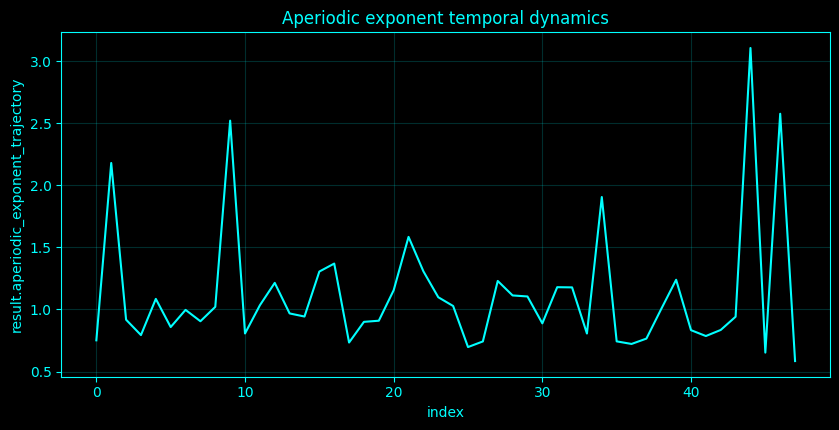

In [110]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _window_bandpower():
    if 'window_bandpower' in SPEC_CACHE:
        return SPEC_CACHE['window_bandpower']
    nwin = min(_SPEED['n_windows'], max(8, N // max(64, int(_fs))))
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    rows = []
    for a, b in zip(edges[:-1], edges[1:]):
        xx = X[a:b]
        if len(xx) < 16:
            continue
        nw = min(max(32, len(xx) // 2), int(_SPEED['nperseg']), len(xx))
        f, p = signal.welch(xx, fs=_fs, axis=0, nperseg=nw, noverlap=nw // 2)
        rows.append(np.stack([_band_integral(p, f, bb) for bb in BANDS.values()], axis=1))
    W = np.stack(rows, axis=0)
    t = (edges[:-1][:len(rows)] + edges[1:1 + len(rows)]) / (2 * _fs)
    SPEC_CACHE['window_bandpower'] = (t, W)
    return SPEC_CACHE['window_bandpower']

def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

def _aperiodic_params(psd=None, f=None):
    if f is None or psd is None:
        f, Pa = _welch_all()
        psd = np.mean(Pa, axis=1)
    m = (f >= 2) & (f <= 45)
    x = np.log10(f[m])
    y = np.log10(psd[m] + EPS)
    coef = np.polyfit(x, y, 1)
    offset, exponent = (float(coef[1]), float(-coef[0]))
    fit = 10 ** (offset - exponent * np.log10(f + EPS))
    return (offset, exponent, fit)

def _peak_params(psd=None, f=None, band=(4, 30)):
    if f is None or psd is None:
        f, P = _welch_all()
        psd = np.mean(P, axis=1)
    _, _, ap = _aperiodic_params(psd, f)
    res = np.log10(psd + EPS) - np.log10(ap + EPS)
    m = (f >= band[0]) & (f <= band[1])
    peaks, props = signal.find_peaks(res[m], prominence=max(0.02, np.std(res[m]) * 0.3))
    fi = f[m][peaks]
    prom = props.get('prominences', np.array([]))
    return (fi, prom, res, ap)

def _irasa_channel(ch=0):
    key = ('irasa', ch)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    y = X[:, ch]
    f0, p0 = _psd_of(y[:, None])
    p0 = p0[:, 0]
    hs = np.array([1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9])
    geos = []
    from fractions import Fraction
    for h in hs:
        frac = Fraction(float(h)).limit_denominator(20)
        y1 = signal.resample_poly(y, frac.numerator, frac.denominator)
        y2 = signal.resample_poly(y, frac.denominator, frac.numerator)
        f1, p1 = signal.welch(y1, fs=_fs * h, nperseg=min(_SPEED['nperseg'], len(y1)))
        f2, p2 = signal.welch(y2, fs=_fs / h, nperseg=min(_SPEED['nperseg'], len(y2)))
        q1 = np.interp(f0, f1, p1)
        q2 = np.interp(f0, f2, p2)
        geos.append(np.sqrt(np.maximum(q1 * q2, 0)))
    fract = np.median(np.asarray(geos), axis=0)
    osc = np.maximum(p0 - fract, 0)
    SPEC_CACHE[key] = (f0, p0, fract, osc)
    return SPEC_CACHE[key]

# Method-specific calculation.
def _compute_method_110():
    idx = 110
    name = 'Aperiodic exponent temporal dynamics'
    __plot_spec = None
    f, P = _welch_all()
    p = np.mean(P, axis=1)
    off, expn, ap = _aperiodic_params(p, f)
    peaks, prom, res, ap = _peak_params(p, f)
    t, W = _window_bandpower()
    nwin = len(t)
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    vals = []
    for a, b in zip(edges[:-1], edges[1:]):
        ff, pp = _psd_of(X[a:b, [0]], nperseg=min(_SPEED['nperseg'], b - a))
        _, e, _ = _aperiodic_params(pp[:, 0], ff)
        vals.append(e)
    return ({'aperiodic_exponent_trajectory': vals}, locals().get('__plot_spec', None))
    f0, p0, fract, osc = _irasa_channel(0)
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_110,_plot_spec=_compute_method_110()
print('Aperiodic exponent temporal dynamics')
if isinstance(result_110,dict):
    for _k,_v in result_110.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_110)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_110)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Aperiodic exponent temporal dynamics',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Aperiodic exponent temporal dynamics',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Aperiodic exponent temporal dynamics',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">111. Aperiodic exponent surrogate testing</h3>
<p>Aperiodic-exponent surrogate testing compares the observed exponent with shuffled-time surrogates, which preserve amplitudes but destroy long-range spectral structure.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A surrogate test creates artificial signals that preserve selected simple properties of the original data while deliberately removing the structure being tested. IAAFT surrogates approximately preserve the amplitude distribution and power spectrum, and therefore much of the linear autocorrelation structure, while randomizing nonlinear temporal organization. The observed statistic is then compared with the surrogate distribution. A small surrogate-based p-value means the observed statistic is unusual under that null model; it does not by itself identify the biological mechanism responsible for the difference.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Aperiodic exponent surrogate testing
  observed: 1.2044092662432204
  shuffle_null_mean: -0.00032951054895069055


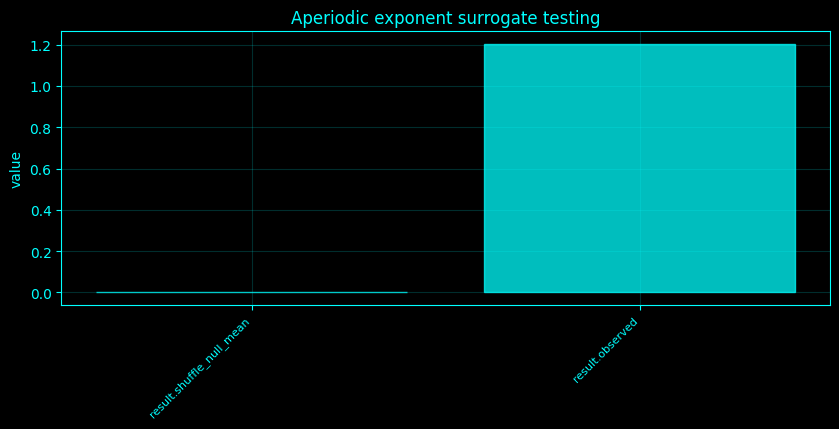

In [111]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

def _aperiodic_params(psd=None, f=None):
    if f is None or psd is None:
        f, Pa = _welch_all()
        psd = np.mean(Pa, axis=1)
    m = (f >= 2) & (f <= 45)
    x = np.log10(f[m])
    y = np.log10(psd[m] + EPS)
    coef = np.polyfit(x, y, 1)
    offset, exponent = (float(coef[1]), float(-coef[0]))
    fit = 10 ** (offset - exponent * np.log10(f + EPS))
    return (offset, exponent, fit)

def _peak_params(psd=None, f=None, band=(4, 30)):
    if f is None or psd is None:
        f, P = _welch_all()
        psd = np.mean(P, axis=1)
    _, _, ap = _aperiodic_params(psd, f)
    res = np.log10(psd + EPS) - np.log10(ap + EPS)
    m = (f >= band[0]) & (f <= band[1])
    peaks, props = signal.find_peaks(res[m], prominence=max(0.02, np.std(res[m]) * 0.3))
    fi = f[m][peaks]
    prom = props.get('prominences', np.array([]))
    return (fi, prom, res, ap)

def _irasa_channel(ch=0):
    key = ('irasa', ch)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    y = X[:, ch]
    f0, p0 = _psd_of(y[:, None])
    p0 = p0[:, 0]
    hs = np.array([1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9])
    geos = []
    from fractions import Fraction
    for h in hs:
        frac = Fraction(float(h)).limit_denominator(20)
        y1 = signal.resample_poly(y, frac.numerator, frac.denominator)
        y2 = signal.resample_poly(y, frac.denominator, frac.numerator)
        f1, p1 = signal.welch(y1, fs=_fs * h, nperseg=min(_SPEED['nperseg'], len(y1)))
        f2, p2 = signal.welch(y2, fs=_fs / h, nperseg=min(_SPEED['nperseg'], len(y2)))
        q1 = np.interp(f0, f1, p1)
        q2 = np.interp(f0, f2, p2)
        geos.append(np.sqrt(np.maximum(q1 * q2, 0)))
    fract = np.median(np.asarray(geos), axis=0)
    osc = np.maximum(p0 - fract, 0)
    SPEC_CACHE[key] = (f0, p0, fract, osc)
    return SPEC_CACHE[key]

# Method-specific calculation.
def _compute_method_111():
    idx = 111
    name = 'Aperiodic exponent surrogate testing'
    __plot_spec = None
    f, P = _welch_all()
    p = np.mean(P, axis=1)
    off, expn, ap = _aperiodic_params(p, f)
    peaks, prom, res, ap = _peak_params(p, f)
    obs = expn
    vals = []
    for _ in range(_SPEED['n_sur']):
        y = _rng.permutation(X[:, 0])
        ff, pp = _psd_of(y[:, None])
        _, e, _ = _aperiodic_params(pp[:, 0], ff)
        vals.append(e)
    return ({'observed': obs, 'shuffle_null_mean': float(np.mean(vals))}, locals().get('__plot_spec', None))
    f0, p0, fract, osc = _irasa_channel(0)
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_111,_plot_spec=_compute_method_111()
print('Aperiodic exponent surrogate testing')
if isinstance(result_111,dict):
    for _k,_v in result_111.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_111)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_111)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Aperiodic exponent surrogate testing',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Aperiodic exponent surrogate testing',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Aperiodic exponent surrogate testing',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">112. IRASA spectral decomposition</h3>
<p>IRASA resamples by noninteger factors \(h\) and \(1/h\); oscillatory peaks shift while scale-free structure rescales predictably. The median geometric mean \(\sqrt{P_h(f)P_{1/h}(f)}\) estimates the fractal spectrum, and the nonnegative residual estimates oscillatory power.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>
